In [2]:


import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import os, warnings, numpy as np, pandas as pd
from pathlib import Path
from datetime import datetime

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [1]:
# === Unified preprocessing (BOTH datasets) -> 3 tracks, each fixed at 400 features ===
import os, sys, time, warnings, numpy as np, pandas as pd
from datetime import datetime
from pathlib import Path

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import joblib

# ---------- CONFIG: Paths ----------
MORDRED_TRAIN = r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\ic50_train_mordred.csv"
MORDRED_TEST  = r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\ic50_test_mordred.csv"   # dept test (Mordred)
HYBRID_TRAIN  = r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\train_hybrid.csv"
HYBRID_TEST   = r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\test_hybrid.csv"


# Output root
OUT_ROOT = Path("./prep")
N_KEEP = 400                     # target dimensionality for all 3 tracks
MISSING_DROP_THR = 0.50          # drop columns with >50% missing in TRAIN
ID_LIKE = {"name","id","mol_id","molecule","smiles"}  # dropped before modeling

# ---------- helpers ----------
def log(msg):
    print(f"[{datetime.now().strftime('%H:%M:%S')}] {msg}")
    sys.stdout.flush()

def detect_target(df):
    cand = ["cls","class","label","active","activity","y","target"]
    for c in df.columns:
        if c.lower() in cand:
            return c
    # fallback: last column
    return df.columns[-1]

def clean_numeric(df, target_col):
    # drop ID-like and over-missing & constant cols based on TRAIN only
    missing = df.isna().mean()
    drop_missing = set(missing[missing > MISSING_DROP_THR].index)
    const = set(df.drop(columns=[target_col]).nunique(dropna=False)[lambda s: s <= 1].index)
    id_like = {c for c in df.columns if c.lower() in ID_LIKE}
    to_drop = (drop_missing | const | id_like) - {target_col}
    keep = [c for c in df.columns if c not in to_drop and c != target_col]
    X = df[keep].apply(pd.to_numeric, errors="coerce")
    return X, keep

def align_like_train(X_test_raw, train_cols):
    # create a test frame with same columns as train
    Xt = pd.DataFrame(columns=train_cols, index=X_test_raw.index, dtype=float)
    for c in train_cols:
        if c in X_test_raw.columns:
            Xt[c] = pd.to_numeric(X_test_raw[c], errors="coerce")
        else:
            Xt[c] = np.nan
    return Xt

def ensure_dir(p: Path):
    p.mkdir(parents=True, exist_ok=True)

def save_df(df, path: Path):
    ensure_dir(path.parent)
    df.to_csv(path, index=False)

# ---------- core routine per dataset ----------
def preprocess_dataset(name, train_path, test_path, out_root: Path):
    if not os.path.exists(train_path):
        log(f"⚠  {name}: train file not found: {train_path}")
        return

    # Load train
    log(f"=== [{name}] Loading TRAIN …")
    df_tr = pd.read_csv(train_path)
    target = detect_target(df_tr)
    y = df_tr[target].astype(int)
    X_raw, kept_cols = clean_numeric(df_tr, target)
    log(f"[{name}] Target: {target} | Kept cols (pre-impute): {len(kept_cols)}")

    # Impute (fit on TRAIN)
    imp = SimpleImputer(strategy="median")
    X_imp = pd.DataFrame(imp.fit_transform(X_raw), columns=kept_cols, index=X_raw.index)
    log(f"[{name}] After impute: {X_imp.shape}")

    # Prepare TEST if available
    X_test_imp = None
    if test_path and os.path.exists(test_path):
        log(f"[{name}] Loading TEST …")
        df_te = pd.read_csv(test_path)
        # if test has target, drop it; we never fit on test
        if detect_target(df_te) in df_te.columns:
            df_te = df_te.drop(columns=[detect_target(df_te)], errors="ignore")
        X_te_raw = df_te.apply(pd.to_numeric, errors="coerce")
        X_te_aligned = align_like_train(X_te_raw, kept_cols)
        X_test_imp = pd.DataFrame(imp.transform(X_te_aligned), columns=kept_cols, index=X_te_aligned.index)
        log(f"[{name}] Test aligned+imputed: {X_test_imp.shape}")
    else:
        log(f"[{name}] TEST not provided (skipping test transforms).")

    # Common variance filter (>0 variance)
    vt = VarianceThreshold(0.0)
    X_vt = vt.fit_transform(X_imp)
    vt_cols = np.array(kept_cols)[vt.get_support()]
    X_vt = pd.DataFrame(X_vt, columns=vt_cols, index=X_imp.index)
    X_test_vt = None
    if X_test_imp is not None:
        X_test_vt = pd.DataFrame(vt.transform(X_test_imp), columns=vt_cols, index=X_test_imp.index)
    log(f"[{name}] After VarianceThreshold: {X_vt.shape[1]} features")

    # ==================== Track A: MI-400 ====================
    outA = out_root / name.lower() / "mi400"
    ensure_dir(outA)

    kA = min(N_KEEP, X_vt.shape[1])
    sel = SelectKBest(mutual_info_classif, k=kA).fit(X_vt, y)
    mi_cols = vt_cols[sel.get_support()]
    X_A_tr = pd.DataFrame(sel.transform(X_vt), columns=mi_cols, index=X_vt.index)
    save_df(pd.concat([X_A_tr, y], axis=1), outA / "train_mi400.csv")
    if X_test_vt is not None:
        X_A_te = pd.DataFrame(sel.transform(X_test_vt), columns=mi_cols, index=X_test_vt.index)
        save_df(X_A_te, outA / "test_mi400.csv")
    pd.Series(mi_cols).to_csv(outA / "feature_names.txt", index=False, header=False)
    joblib.dump({"imputer": imp, "vt": vt, "selector": sel}, outA / "artifacts.joblib")
    log(f"[{name}] Track A (MI-400): saved → {outA}")

    # ==================== Track B: L1+RF-400 ====================
    outB = out_root / name.lower() / "alt400"
    ensure_dir(outB)

    # L1 Logistic for sparsity
    l1 = LogisticRegression(
        penalty="l1", solver="saga", max_iter=5000, random_state=42, C=1.0
    )
    l1.fit(X_vt, y)
    coef_mask = np.abs(l1.coef_).ravel() > 1e-8
    if not np.any(coef_mask):
        # fallback: keep all vt_cols if L1 prunes everything
        lasso_cols = vt_cols
        X_l1 = X_vt.copy()
        log(f"[{name}] L1 yielded 0 features → fallback to VT set ({len(vt_cols)})")
    else:
        lasso_cols = vt_cols[coef_mask]
        X_l1 = X_vt[lasso_cols]
        log(f"[{name}] L1 kept {len(lasso_cols)} features")

    rf = RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1)
    rf.fit(X_l1, y)
    importances = pd.Series(rf.feature_importances_, index=lasso_cols).sort_values(ascending=False)
    topB = importances.head(min(N_KEEP, len(importances))).index.tolist()

    X_B_tr = X_l1[topB]
    save_df(pd.concat([X_B_tr, y], axis=1), outB / "train_alt400.csv")
    if X_test_vt is not None:
        # build X_test_l1 in same lasso space
        X_test_l1 = X_test_vt.reindex(columns=lasso_cols, fill_value=0.0)
        X_B_te = X_test_l1[topB]
        save_df(X_B_te, outB / "test_alt400.csv")
    pd.Series(topB).to_csv(outB / "feature_names.txt", index=False, header=False)
    joblib.dump({"imputer": imp, "vt": vt, "l1": l1, "rf": rf, "lasso_cols": lasso_cols}, outB / "artifacts.joblib")
    log(f"[{name}] Track B (L1+RF-400): saved → {outB}")

    # ==================== Track C: PCA-400 ====================
    outC = out_root / name.lower() / "pca400"
    ensure_dir(outC)

    scaler = StandardScaler(with_mean=True, with_std=True)
    X_std = scaler.fit_transform(X_imp)     # PCA works best on standardized data
    pca = PCA(n_components=min(N_KEEP, X_std.shape[1]), random_state=42)
    X_C_tr = pca.fit_transform(X_std)
    X_C_tr = pd.DataFrame(X_C_tr, index=X_imp.index, columns=[f"PC{i+1}" for i in range(X_C_tr.shape[1])])
    save_df(pd.concat([X_C_tr, y], axis=1), outC / "train_pca400.csv")

    if X_test_imp is not None:
        X_te_std = scaler.transform(X_test_imp)
        X_C_te = pca.transform(X_te_std)
        X_C_te = pd.DataFrame(X_C_te, index=X_test_imp.index, columns=[f"PC{i+1}" for i in range(X_C_tr.shape[1])])
        save_df(X_C_te, outC / "test_pca400.csv")

    # Save artifacts for reproducibility
    joblib.dump({"imputer": imp, "scaler": scaler, "pca": pca, "kept_cols": kept_cols}, outC / "artifacts.joblib")
    log(f"[{name}] Track C (PCA-400): saved → {outC}")

    log(f"=== [{name}] DONE ===\n")

# ---------- run both datasets ----------
start = time.time()
log("Starting unified preprocessing (no internal split; fixed 400 features per track)")

preprocess_dataset("MORDRED", MORDRED_TRAIN, MORDRED_TEST, OUT_ROOT)
preprocess_dataset("HYBRID",  HYBRID_TRAIN,  HYBRID_TEST,  OUT_ROOT)

log(f"All done in {(time.time()-start)/60:.1f} minutes")

[17:48:31] Starting unified preprocessing (no internal split; fixed 400 features per track)
[17:48:31] === [MORDRED] Loading TRAIN …
[17:48:33] [MORDRED] Target: cls | Kept cols (pre-impute): 1310
[17:48:33] [MORDRED] After impute: (2880, 1310)
[17:48:33] [MORDRED] Loading TEST …
[17:48:35] [MORDRED] Test aligned+imputed: (720, 1310)
[17:48:35] [MORDRED] After VarianceThreshold: 1309 features
[17:49:01] [MORDRED] Track A (MI-400): saved → prep\mordred\mi400
[17:51:26] [MORDRED] L1 yielded 0 features → fallback to VT set (1309)
[17:51:33] [MORDRED] Track B (L1+RF-400): saved → prep\mordred\alt400
[17:51:36] [MORDRED] Track C (PCA-400): saved → prep\mordred\pca400
[17:51:36] === [MORDRED] DONE ===

[17:51:36] === [HYBRID] Loading TRAIN …
[17:51:38] [HYBRID] Target: cls | Kept cols (pre-impute): 1919
[17:51:38] [HYBRID] After impute: (2880, 1919)
[17:51:38] [HYBRID] Loading TEST …
[17:51:40] [HYBRID] Test aligned+imputed: (720, 1919)
[17:51:40] [HYBRID] After VarianceThreshold: 1918 featu

In [1]:
import pandas as pd

m_train = r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\ic50_train_mordred.csv"
h_train = r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\train_hybrid.csv"

id_like = {"name","id","mol_id","molecule","smiles"}
def detect_target(df):
    for c in df.columns:
        if c.lower() in {"cls","class","label","active","activity","y","target"}:
            return c
    return df.columns[-1]

def basic_counts(path):
    df = pd.read_csv(path)
    tgt = detect_target(df)
    cols_raw = [c for c in df.columns if c != tgt]
    cols_nid = [c for c in cols_raw if c.lower() not in id_like]
    # >50% missing and constant
    miss = df[cols_nid].isna().mean()
    keep = miss[miss <= 0.50].index
    nunq = df[keep].nunique(dropna=False)
    keep = nunq[nunq > 1].index
    return {
        "raw_total_no_target": len(cols_raw),
        "after_id_drop": len(cols_nid),
        "after_missing+constant": len(keep)
    }

print("MORDRED:", basic_counts(m_train))
print("HYBRID :", basic_counts(h_train))


MORDRED: {'raw_total_no_target': 1614, 'after_id_drop': 1613, 'after_missing+constant': 1310}
HYBRID : {'raw_total_no_target': 2495, 'after_id_drop': 2494, 'after_missing+constant': 1919}


In [9]:
# === Track-wise 2D scatter PNGs for HYBRID & 2D (MORDRED) ===
# Reads: prep/<DATASET>/<TRACK>/train_<track>.csv
# Saves: results/ensemble/RESULTSANDGRAPH/scatter_<DS>_<TRACK>.png
#
# Notes:
# - "MORDRED" is labeled "2D" in titles/filenames.
# - For ALT/MI tracks we fit PCA(n_components=2) just for visualization.
# - For PCA400 we use (PC1, PC2) columns directly if present; else PCA(2).

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# -------- config --------
PREP_DIR = Path("prep")  # root of your preprocessed tracks
OUT_DIR  = Path("results/ensemble/RESULTSANDGRAPH")
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = ["MORDRED", "HYBRID"]              # will print as 2D / HYBRID
TRACKS   = ["alt400", "mi400", "pca400"]      # folders & file suffixes
LABEL_CANDIDATES = ["cls","class","label","active","activity","y","target"]

DS_DISPLAY = {"MORDRED": "2D", "HYBRID": "HYBRID"}

# -------- helpers --------
def detect_label_col(df: pd.DataFrame) -> str:
    for c in df.columns:
        if c.lower() in LABEL_CANDIDATES:
            return c
    return df.columns[-1]  # fallback

def load_train(dataset: str, track: str) -> tuple[pd.DataFrame, pd.Series]:
    dsd = dataset.lower()
    train_name = f"train_{track}.csv"
    p = PREP_DIR / dsd / track / train_name
    if not p.exists():
        raise FileNotFoundError(f"Missing: {p}")
    df = pd.read_csv(p)
    ycol = detect_label_col(df)
    y = df[ycol].astype(int)
    X = df.drop(columns=[ycol])
    return X, y

def get_2d_embedding(X: pd.DataFrame, track: str) -> np.ndarray:
    # If it's pca400 and has PC1/PC2, use those directly for clarity.
    if track == "pca400":
        pc1 = next((c for c in X.columns if c.upper() == "PC1"), None)
        pc2 = next((c for c in X.columns if c.upper() == "PC2"), None)
        if pc1 and pc2:
            return X[[pc1, pc2]].to_numpy()
    # Otherwise standardize then PCA→2 for a nice view
    Z = StandardScaler().fit_transform(X.values)
    return PCA(n_components=2, random_state=42).fit_transform(Z)

def nice_name(s: str) -> str:
    # short variant label for plot title/filename
    return s.upper()

# -------- plotting --------
def make_scatter_png(dataset: str, track: str):
    X, y = load_train(dataset, track)
    emb = get_2d_embedding(X, track)

    ds_disp = DS_DISPLAY.get(dataset, dataset)
    title = f"{ds_disp} / {nice_name(track)} — PCA view (2D)"

    fig, ax = plt.subplots(figsize=(9, 7))
    # two classes 0/1 – default colors (no explicit palette per your style rule)
    for cls in sorted(np.unique(y)):
        m = (y.values == cls)
        ax.scatter(emb[m, 0], emb[m, 1], s=18, alpha=0.75, label=str(cls))

    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.set_title(title)
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
    ax.legend(title="label", loc="upper right", frameon=False)
    fig.tight_layout()

    out = OUT_DIR / f"scatter_{ds_disp}_{nice_name(track)}.png"
    fig.savefig(out, dpi=180, bbox_inches="tight")
    plt.close(fig)
    print("✓ saved", out)

# -------- run all combos --------
for ds in DATASETS:
    for tr in TRACKS:
        try:
            make_scatter_png(ds, tr)
        except Exception as e:
            print(f"⚠️  {ds}/{tr}: {e}")


✓ saved results\ensemble\RESULTSANDGRAPH\scatter_2D_ALT400.png
✓ saved results\ensemble\RESULTSANDGRAPH\scatter_2D_MI400.png
✓ saved results\ensemble\RESULTSANDGRAPH\scatter_2D_PCA400.png
✓ saved results\ensemble\RESULTSANDGRAPH\scatter_HYBRID_ALT400.png
✓ saved results\ensemble\RESULTSANDGRAPH\scatter_HYBRID_MI400.png
✓ saved results\ensemble\RESULTSANDGRAPH\scatter_HYBRID_PCA400.png


In [36]:
# === Feature Tracks Visual Pack (FIXED): MI-400, ALT-400, PCA-400 ===
# Creates per-dataset multi-page PDFs + PNGs summarizing your three tracks.
# Requirements: pandas, numpy, matplotlib, joblib
import os, json
import numpy as np
import pandas as pd
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# -----------------------------
# Config
# -----------------------------
DATASETS = ["mordred", "hybrid"]   # lower-case to match prep/ folder
TRACKS   = ["mi400", "alt400", "pca400"]
OUT_DIR  = Path("results/FEATURE_TRACK_VISUALS")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Helpers
# -----------------------------
def detect_target(df: pd.DataFrame):
    for c in df.columns:
        if c.lower() in {"cls","class","label","active","activity","y","target"}:
            return c
    return None

def load_train_df(dataset: str, track: str):
    p = Path(f"prep/{dataset}/{track}/train_{track}.csv")
    if not p.exists():
        raise FileNotFoundError(p)
    df = pd.read_csv(p)
    tgt = detect_target(df)
    return df, tgt

def save_fig(fig, outdir: Path, name: str):
    outdir.mkdir(parents=True, exist_ok=True)
    png = outdir / f"{name}.png"
    fig.savefig(png, bbox_inches="tight", dpi=180)
    plt.close(fig)
    return png

def draw_funnel(ax, steps, counts, title):
    x = np.arange(len(steps))
    ax.bar(x, counts)
    ax.set_xticks(x)
    ax.set_xticklabels(steps, rotation=15, ha="right")
    ax.set_ylabel("# features")
    ax.set_title(title)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    for xi, v in zip(x, counts):
        ax.text(xi, v + max(1, 0.02*max(counts)), str(int(v)), ha="center", va="bottom", fontsize=9)

def correlation_heatmap(ax, df, title):
    # cap to top 50 features for readability
    df50 = df.iloc[:, :min(50, df.shape[1])]
    C = np.corrcoef(df50.values, rowvar=False)
    im = ax.imshow(C, aspect="auto")
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    fig = ax.figure
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.set_ylabel("corr", rotation=270, labelpad=12)

def scree_plot(ax, evr, title):
    x = np.arange(1, len(evr)+1)
    ax.bar(x, evr)
    ax.set_xlabel("Principal component")
    ax.set_ylabel("Explained variance ratio")
    ax.set_title(title)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

def cumulative_plot(ax, evr, title):
    cum = np.cumsum(evr)
    x = np.arange(1, len(evr)+1)
    ax.plot(x, cum, marker="o")
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Principal component")
    ax.set_ylabel("Cumulative explained variance")
    ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.3)

def scatter_pc(ax, X, y, title):
    pc1, pc2 = X[:,0], X[:,1]
    uniq = pd.Series(y).unique() if y is not None else []
    if y is None or len(uniq) == 0:
        ax.scatter(pc1, pc2, alpha=0.6, s=12)
    else:
        for val in uniq:
            idx = (y == val)
            ax.scatter(pc1[idx], pc2[idx], alpha=0.6, s=12, label=str(val))
        ax.legend(frameon=False, fontsize=8)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.3)

def load_artifacts(dataset: str, track: str):
    art = Path(f"prep/{dataset}/{track}/artifacts.joblib")
    if not art.exists():
        return None
    return joblib.load(art)

# -----------------------------
# Main visualization loop
# -----------------------------
for dataset in DATASETS:
    # per-dataset output
    ds_out = OUT_DIR / dataset
    ds_out.mkdir(parents=True, exist_ok=True)
    pdf_path = ds_out / f"{dataset.upper()}_feature_tracks.pdf"
    with PdfPages(pdf_path) as pdf:
        # ---------- Preprocessing Funnel (use artifact introspection) ----------
        try:
            # Use MI artifacts to recover counts that caused mismatch before
            art_mi = load_artifacts(dataset, "mi400")
            if art_mi is None:
                raise RuntimeError("MI artifacts not found.")
            vt = art_mi.get("vt", None)
            if vt is None or not hasattr(vt, "get_support"):
                raise RuntimeError("VT not found in MI artifacts.")

            # Counts from artifacts:
            n_after_missing = int(getattr(vt, "n_features_in_", 0))               # features before VT
            n_after_vt      = int(np.sum(vt.get_support()))                       # features after VT

            # Track-specific final counts
            mi_cols  = pd.read_csv(Path(f"prep/{dataset}/mi400/feature_names.txt"), header=None)[0].tolist()
            n_mi     = len(mi_cols)

            alt_cols = pd.read_csv(Path(f"prep/{dataset}/alt400/feature_names.txt"), header=None)[0].tolist()
            n_alt    = len(alt_cols)

            pca_art  = load_artifacts(dataset, "pca400")
            pca      = pca_art.get("pca", None) if pca_art else None
            n_pca    = int(getattr(pca, "n_components_", 0))

            steps  = ["After missing/IDs", "After VT(0.0)", "MI-400", "ALT-400", "PCA-400"]
            counts = [n_after_missing, n_after_vt, n_mi, n_alt, n_pca]

            fig, ax = plt.subplots(figsize=(10,5))
            draw_funnel(ax, steps, counts, f"{dataset.upper()}: Feature survival funnel")
            save_fig(fig, ds_out, "funnel")
            pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)
        except Exception as e:
            print(f"[WARN] Funnel skipped for {dataset}: {e}")

        # ---------- MI-400 visuals ----------
        try:
            df_mi, tgt = load_train_df(dataset, "mi400")     # already small, includes label
            y = df_mi[tgt].astype(int).values
            X_mi = df_mi.drop(columns=[tgt])

            # Recompute MI on the MI-400 frame (still label-aware, just to get scores for plotting)
            try:
                from sklearn.feature_selection import mutual_info_classif
                mi_scores = mutual_info_classif(X_mi.values, y, discrete_features=False, random_state=42)
                scores = pd.Series(mi_scores, index=X_mi.columns).sort_values(ascending=False)
                label_for_scores = "Mutual information"
            except Exception:
                var_scores = X_mi.var(axis=0).sort_values(ascending=False)
                scores = var_scores
                label_for_scores = "Variance (proxy)"

            # Histogram
            fig, ax = plt.subplots(figsize=(10,5))
            ax.hist(scores.values, bins=30)
            ax.set_title(f"{dataset.upper()} | MI-400: {label_for_scores} distribution")
            ax.set_xlabel(label_for_scores); ax.set_ylabel("Count")
            ax.grid(axis="y", linestyle="--", alpha=0.3)
            save_fig(fig, ds_out, "mi_hist")
            pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)

            # Top-30 bar
            topk = scores.head(min(30, len(scores)))
            fig, ax = plt.subplots(figsize=(10,6))
            ax.bar(np.arange(len(topk)), topk.values)
            ax.set_xticks(np.arange(len(topk)))  # FIX: set ticks first
            ax.set_xticklabels(topk.index.tolist(), rotation=60, ha="right", fontsize=8)
            ax.set_title(f"{dataset.upper()} | MI-400: top-{len(topk)} by {label_for_scores}")
            ax.set_ylabel(label_for_scores)
            ax.grid(axis="y", linestyle="--", alpha=0.3)
            save_fig(fig, ds_out, "mi_top30")
            pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)

            # Correlation heatmap among top-50
            top50_names = topk.index.tolist()[:min(50, len(topk))]
            top50 = X_mi[top50_names]
            fig, ax = plt.subplots(figsize=(7,6))
            correlation_heatmap(ax, top50, f"{dataset.upper()} | MI-400: correlation (top-50)")
            save_fig(fig, ds_out, "mi_corr_top50")
            pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)
        except Exception as e:
            print(f"[WARN] MI visuals skipped for {dataset}: {e}")

        # ---------- ALT-400 visuals ----------
        try:
            art_alt = load_artifacts(dataset, "alt400")
            rf = art_alt.get("rf", None) if art_alt else None
            lasso_cols = art_alt.get("lasso_cols", None) if art_alt else None
            if rf is not None and lasso_cols is not None and len(lasso_cols) > 0:
                imp = pd.Series(rf.feature_importances_, index=pd.Index(lasso_cols)).sort_values(ascending=False)
                topk = imp.head(min(30, len(imp)))

                # Histogram of importances
                fig, ax = plt.subplots(figsize=(10,5))
                ax.hist(imp.values, bins=30)
                ax.set_title(f"{dataset.upper()} | ALT-400: RF importance distribution")
                ax.set_xlabel("RF feature importance"); ax.set_ylabel("Count")
                ax.grid(axis="y", linestyle="--", alpha=0.3)
                save_fig(fig, ds_out, "alt_importance_hist")
                pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)

                # Top-30 bar
                fig, ax = plt.subplots(figsize=(10,6))
                ax.bar(np.arange(len(topk)), topk.values)
                ax.set_xticks(np.arange(len(topk)))  # FIX: set ticks first
                ax.set_xticklabels(topk.index.tolist(), rotation=60, ha="right", fontsize=8)
                ax.set_title(f"{dataset.upper()} | ALT-400: top-{len(topk)} RF importances")
                ax.set_ylabel("RF importance")
                ax.grid(axis="y", linestyle="--", alpha=0.3)
                save_fig(fig, ds_out, "alt_top30")
                pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)
        except Exception as e:
            print(f"[WARN] ALT visuals skipped for {dataset}: {e}")

        # ---------- MI vs ALT overlap ----------
        try:
            mi_cols = set(pd.read_csv(Path(f"prep/{dataset}/mi400/feature_names.txt"), header=None)[0].tolist())
            alt_cols = set(pd.read_csv(Path(f"prep/{dataset}/alt400/feature_names.txt"), header=None)[0].tolist())
            only_mi  = len(mi_cols - alt_cols)
            only_alt = len(alt_cols - mi_cols)
            both     = len(mi_cols & alt_cols)

            fig, ax = plt.subplots(figsize=(7,5))
            vals = [only_mi, only_alt, both]
            ax.bar(np.arange(3), vals)
            ax.set_xticks(np.arange(3))
            ax.set_xticklabels(["MI only","ALT only","Both"])
            ax.set_title(f"{dataset.upper()} | MI vs ALT overlap (counts)")
            ax.set_ylabel("# features")
            for i,v in enumerate(vals):
                ax.text(i, v + 1, str(v), ha="center", va="bottom", fontsize=9)
            ax.grid(axis="y", linestyle="--", alpha=0.3)
            save_fig(fig, ds_out, "overlap_counts")
            pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)

            # Save lists as txt for inspection
            (ds_out / "overlap_MI_only.txt").write_text("\n".join(sorted(mi_cols - alt_cols)))
            (ds_out / "overlap_ALT_only.txt").write_text("\n".join(sorted(alt_cols - mi_cols)))
            (ds_out / "overlap_BOTH.txt").write_text("\n".join(sorted(mi_cols & alt_cols)))
        except Exception as e:
            print(f"[WARN] Overlap skipped for {dataset}: {e}")

        # ---------- PCA-400 visuals ----------
        try:
            art_pca = load_artifacts(dataset, "pca400")
            pca = art_pca.get("pca", None) if art_pca else None
            if pca is not None and hasattr(pca, "explained_variance_ratio_"):
                evr = np.asarray(pca.explained_variance_ratio_, dtype=float)

                # Scree
                fig, ax = plt.subplots(figsize=(10,5))
                scree_plot(ax, evr, f"{dataset.upper()} | PCA-400: Scree (variance ratio)")
                save_fig(fig, ds_out, "pca_scree")
                pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)

                # Cumulative
                fig, ax = plt.subplots(figsize=(10,5))
                cumulative_plot(ax, evr, f"{dataset.upper()} | PCA-400: Cumulative variance")
                save_fig(fig, ds_out, "pca_cumulative")
                pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)

                # 2D PC scatter (train)
                df_pca, tgt = load_train_df(dataset, "pca400")
                y = df_pca[tgt].values if tgt else None
                X = df_pca.drop(columns=[tgt]) if tgt else df_pca
                X = X.values
                if X.shape[1] >= 2:
                    fig, ax = plt.subplots(figsize=(7,6))
                    scatter_pc(ax, X, y if tgt else None, f"{dataset.upper()} | PCA-400: PC1 vs PC2 (train)")
                    save_fig(fig, ds_out, "pca_scatter_pc12")
                    pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)
        except Exception as e:
            print(f"[WARN] PCA visuals skipped for {dataset}: {e}")

    print(f"[OK] Saved PDF → {pdf_path}")
print("[DONE] Feature Tracks Visual Pack created in:", OUT_DIR)


[OK] Saved PDF → results\FEATURE_TRACK_VISUALS\mordred\MORDRED_feature_tracks.pdf
[OK] Saved PDF → results\FEATURE_TRACK_VISUALS\hybrid\HYBRID_feature_tracks.pdf
[DONE] Feature Tracks Visual Pack created in: results\FEATURE_TRACK_VISUALS


In [1]:
# === Phase 2: Baseline ML Benchmark (17 Algorithm × 3 tracks × 2 datasets) === 102 ML Models
import os
from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score, average_precision_score
)

# Models
from sklearn.linear_model import LogisticRegression, SGDClassifier, PassiveAggressiveClassifier, RidgeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA, QuadraticDiscriminantAnalysis as QDA
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

RANDOM_STATE = 42
N_SPLITS = 5
RESULTS_ROOT = Path("./results/baselines")
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------------
# Utilities
# -----------------------------------------------------------------------------
def detect_target(df):
    # Uses your earlier convention; falls back to 'cls' or last column
    cand = ["cls","class","label","active","activity","y","target"]
    for c in df.columns:
        if c.lower() in cand:
            return c
    return df.columns[-1]

def ensure_binary(y):
    # Cast to {0,1}
    y = pd.Series(y).astype(int)
    # Safety: if labels aren't {0,1}, map the smallest to 0, largest to 1
    uniq = sorted(y.unique())
    if uniq != [0,1]:
        mapping = {uniq[0]:0, uniq[-1]:1}
        y = y.map(mapping)
    return y

def pos_weight(y):
    # scale_pos_weight = (negatives / positives)
    y = pd.Series(y)
    pos = (y == 1).sum()
    neg = (y == 0).sum()
    return float(neg / max(pos, 1))

def get_models(y):
    """Build the 17 baseline models with reasonable defaults.
       Imbalance: class_weight='balanced' where supported;
       XGB/LGBM get scale_pos_weight."""
    cpw = "balanced"
    spw = pos_weight(y)

    models = {
        # 1
        "LogisticRegression": make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=5000, solver="lbfgs", class_weight=cpw, random_state=RANDOM_STATE)
        ),
        # 2
        "KNN": make_pipeline(
            StandardScaler(),
            KNeighborsClassifier(n_neighbors=5)
        ),
        # 3
        "SVM_Linear": make_pipeline(
            StandardScaler(),
            LinearSVC(C=1.0, class_weight="balanced", random_state=42,
                      dual=False, max_iter=20000, tol=1e-3)
        ),
        # 4
        "SVM_RBF": make_pipeline(
            StandardScaler(),
            SVC(kernel="rbf", probability=True, class_weight=cpw, random_state=RANDOM_STATE)
        ),
        # 5
        "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight=cpw),
        # 6
        "RandomForest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1, class_weight=cpw),
        # 7
        "ExtraTrees": ExtraTreesClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1, class_weight=cpw),
        # 8
        "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),  # no class_weight
        # 9
        "XGBoost": XGBClassifier(
            n_estimators=400, max_depth=6, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9,
            reg_lambda=1.0, random_state=RANDOM_STATE, eval_metric="logloss", verbosity=0,
            scale_pos_weight=spw, n_jobs=-1
        ),
        # 10
        "LightGBM": LGBMClassifier(
            n_estimators=600, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9,
            reg_lambda=0.0, random_state=RANDOM_STATE, verbose=-1,
            scale_pos_weight=spw, n_jobs=-1
        ),
        # 11
        "NaiveBayes_Gaussian": GaussianNB(),
        # 12
        "PassiveAggressive": make_pipeline(
            StandardScaler(),
            PassiveAggressiveClassifier(max_iter=2000, random_state=RANDOM_STATE, class_weight=cpw)
        ),
        # 13
        "SGDClassifier": make_pipeline(
            StandardScaler(),
            SGDClassifier(loss="log_loss", max_iter=2000, tol=1e-3, random_state=RANDOM_STATE)  # log-loss for proba via decision
        ),
        # 14
        "AdaBoost": AdaBoostClassifier(
            n_estimators=300, learning_rate=0.05, random_state=42, algorithm="SAMME"
        ),
        # 15
        "RidgeClassifier": make_pipeline(
            StandardScaler(),
            RidgeClassifier(random_state=RANDOM_STATE, class_weight=cpw)
        ),
        
        #16 QDA (stabilize against collinearity)
        "QDA": make_pipeline(
            StandardScaler(),
            QDA(reg_param=0.05)   # try 0.001–0.1 if warnings persist
        ),
        
        #17 LDA (shrinkage to handle multicollinearity)
        "LDA": make_pipeline(
            StandardScaler(),
            LDA(solver="lsqr", shrinkage="auto")
        )

    }
    return models

def proba_or_decision(model, X):
    """Return a 1D score for positive class:
       - predict_proba[:,1] if available,
       - else decision_function (already centered for AUC),
       - else None (metrics needing scores will be NaN)."""
    if hasattr(model, "predict_proba"):
        try:
            p = model.predict_proba(X)[:, 1]
            return p
        except Exception:
            pass
    if hasattr(model, "decision_function"):
        try:
            d = model.decision_function(X)
            if d.ndim > 1:  # some linear models can output shape (n_samples, n_classes)
                d = d[:, -1]
            return d
        except Exception:
            pass
    return None

def evaluate_cv(X, y, model_name, model, n_splits=N_SPLITS, random_state=RANDOM_STATE):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_rows = []
    for fold, (tr, va) in enumerate(skf.split(X, y), start=1):
        X_tr, X_va = X.iloc[tr], X.iloc[va]
        y_tr, y_va = y.iloc[tr], y.iloc[va]

        mdl = model
        mdl.fit(X_tr, y_tr)

        y_pred = mdl.predict(X_va)
        y_score = proba_or_decision(mdl, X_va)

        # Metrics
        acc = accuracy_score(y_va, y_pred)
        f1m = f1_score(y_va, y_pred, average="macro", zero_division=0)
        precm = precision_score(y_va, y_pred, average="macro", zero_division=0)
        recm = recall_score(y_va, y_pred, average="macro", zero_division=0)

        # ROC-AUC & PR-AUC (binary, needs scores)
        if y_score is not None:
            try:
                auc = roc_auc_score(y_va, y_score)
            except Exception:
                auc = np.nan
            try:
                pr_auc = average_precision_score(y_va, y_score)
            except Exception:
                pr_auc = np.nan
        else:
            auc = np.nan
            pr_auc = np.nan

        fold_rows.append({
            "Model": model_name,
            "Fold": fold,
            "Accuracy": acc,
            "ROC-AUC": auc,
            "F1_macro": f1m,
            "Precision_macro": precm,
            "Recall_macro": recm,
            "PR-AUC": pr_auc,
        })

    df_folds = pd.DataFrame(fold_rows)
    # Aggregate
    agg = df_folds.drop(columns=["Fold"]).groupby("Model").agg(["mean","std"])
    # Flatten MultiIndex columns
    agg.columns = [f"{m}_{s}" for m, s in agg.columns]
    agg = agg.reset_index()
    return df_folds, agg

def run_one_train_csv(dataset_name, track_name, train_csv, out_dir: Path):
    df = pd.read_csv(train_csv)
    tgt = detect_target(df)
    y = ensure_binary(df[tgt])
    X = df.drop(columns=[tgt])

    models = get_models(y)

    all_folds = []
    all_aggs = []

    for mname, mobj in models.items():
        folds_df, agg_df = evaluate_cv(X, y, mname, mobj, n_splits=N_SPLITS, random_state=RANDOM_STATE)
        folds_df.insert(0, "Track", track_name)
        folds_df.insert(0, "Dataset", dataset_name)
        agg_df.insert(0, "Track", track_name)
        agg_df.insert(0, "Dataset", dataset_name)
        all_folds.append(folds_df)
        all_aggs.append(agg_df)

    folds_cat = pd.concat(all_folds, axis=0).reset_index(drop=True)
    aggs_cat = pd.concat(all_aggs, axis=0).reset_index(drop=True)

    out_dir.mkdir(parents=True, exist_ok=True)
    folds_cat.to_csv(out_dir / f"{dataset_name}_{track_name}_fold_metrics.csv", index=False)
    aggs_cat.to_csv(out_dir / f"{dataset_name}_{track_name}_cv_summary.csv", index=False)

    return folds_cat, aggs_cat

# -----------------------------------------------------------------------------
# Worklist: datasets & tracks produced by your preprocessing step
# -----------------------------------------------------------------------------
WORK = [
    # dataset, track, train_csv
    ("MORDRED", "MI400",  "prep/mordred/mi400/train_mi400.csv"),
    ("MORDRED", "ALT400", "prep/mordred/alt400/train_alt400.csv"),
    ("MORDRED", "PCA400", "prep/mordred/pca400/train_pca400.csv"),
    ("HYBRID",  "MI400",  "prep/hybrid/mi400/train_mi400.csv"),
    ("HYBRID",  "ALT400", "prep/hybrid/alt400/train_alt400.csv"),
    ("HYBRID",  "PCA400", "prep/hybrid/pca400/train_pca400.csv"),
]

# -----------------------------------------------------------------------------
# Run all, save combined outputs
# -----------------------------------------------------------------------------
all_folds_out = []
all_cv_out = []

for ds, trk, path in WORK:
    if not Path(path).exists():
        print(f"[WARN] Missing: {path} — skipping.")
        continue
    print(f"=== Running CV: {ds} | {trk} | {path} ===")
    folds_df, cv_df = run_one_train_csv(
        dataset_name=ds,
        track_name=trk,
        train_csv=path,
        out_dir=RESULTS_ROOT / ds.lower() / trk.lower()
    )
    all_folds_out.append(folds_df)
    all_cv_out.append(cv_df)

if all_folds_out:
    all_folds_cat = pd.concat(all_folds_out, axis=0).reset_index(drop=True)
    all_folds_cat.to_csv(RESULTS_ROOT / "ALL_folds_metrics.csv", index=False)

if all_cv_out:
    all_cv_cat = pd.concat(all_cv_out, axis=0).reset_index(drop=True)

    # Helpful overall ranking views (you can sort by what you care about)
    # Example: prioritize Accuracy, then ROC-AUC, then F1_macro (means only)
    rank_view = (
        all_cv_cat
        .sort_values(by=["Accuracy_mean","ROC-AUC_mean","F1_macro_mean"], ascending=False)
        .reset_index(drop=True)
    )
    all_cv_cat.to_csv(RESULTS_ROOT / "ALL_cv_summary.csv", index=False)
    rank_view.to_csv(RESULTS_ROOT / "ALL_cv_ranked_by_accuracy.csv", index=False)

    # Print a quick top-10 by Accuracy
    print("\nTop-10 combos by Accuracy (CV mean):")
    display(rank_view.loc[:, ["Dataset","Track","Model","Accuracy_mean","ROC-AUC_mean","F1_macro_mean"]].head(10))
else:
    print("No results written (no train CSVs found).")


=== Running CV: MORDRED | MI400 | prep/mordred/mi400/train_mi400.csv ===


C:\Users\deepa\anaconda3\envs\tf-gpu\lib\site-packages\sklearn\discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
C:\Users\deepa\anaconda3\envs\tf-gpu\lib\site-packages\sklearn\discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
C:\Users\deepa\anaconda3\envs\tf-gpu\lib\site-packages\sklearn\discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
C:\Users\deepa\anaconda3\envs\tf-gpu\lib\site-packages\sklearn\discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
C:\Users\deepa\anaconda3\envs\tf-gpu\lib\site-packages\sklearn\discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


=== Running CV: MORDRED | ALT400 | prep/mordred/alt400/train_alt400.csv ===


C:\Users\deepa\anaconda3\envs\tf-gpu\lib\site-packages\sklearn\discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
C:\Users\deepa\anaconda3\envs\tf-gpu\lib\site-packages\sklearn\discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
C:\Users\deepa\anaconda3\envs\tf-gpu\lib\site-packages\sklearn\discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
C:\Users\deepa\anaconda3\envs\tf-gpu\lib\site-packages\sklearn\discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
C:\Users\deepa\anaconda3\envs\tf-gpu\lib\site-packages\sklearn\discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


=== Running CV: MORDRED | PCA400 | prep/mordred/pca400/train_pca400.csv ===
=== Running CV: HYBRID | MI400 | prep/hybrid/mi400/train_mi400.csv ===


C:\Users\deepa\anaconda3\envs\tf-gpu\lib\site-packages\sklearn\discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
C:\Users\deepa\anaconda3\envs\tf-gpu\lib\site-packages\sklearn\discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
C:\Users\deepa\anaconda3\envs\tf-gpu\lib\site-packages\sklearn\discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
C:\Users\deepa\anaconda3\envs\tf-gpu\lib\site-packages\sklearn\discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
C:\Users\deepa\anaconda3\envs\tf-gpu\lib\site-packages\sklearn\discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


=== Running CV: HYBRID | ALT400 | prep/hybrid/alt400/train_alt400.csv ===


C:\Users\deepa\anaconda3\envs\tf-gpu\lib\site-packages\sklearn\discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
C:\Users\deepa\anaconda3\envs\tf-gpu\lib\site-packages\sklearn\discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
C:\Users\deepa\anaconda3\envs\tf-gpu\lib\site-packages\sklearn\discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
C:\Users\deepa\anaconda3\envs\tf-gpu\lib\site-packages\sklearn\discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
C:\Users\deepa\anaconda3\envs\tf-gpu\lib\site-packages\sklearn\discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


=== Running CV: HYBRID | PCA400 | prep/hybrid/pca400/train_pca400.csv ===

Top-10 combos by Accuracy (CV mean):


,Dataset,Track,Model,Accuracy_mean,ROC-AUC_mean,F1_macro_mean
0,MORDRED,ALT400,XGBoost,0.855903,0.937393,0.855863
1,HYBRID,ALT400,LightGBM,0.855556,0.932847,0.855529
2,MORDRED,ALT400,LightGBM,0.854861,0.935384,0.854815
3,MORDRED,MI400,LightGBM,0.854167,0.934376,0.854126
4,MORDRED,ALT400,ExtraTrees,0.852778,0.926720,0.852727
5,HYBRID,MI400,LightGBM,0.852083,0.933216,0.852033
6,HYBRID,ALT400,XGBoost,0.851042,0.934562,0.851012
7,HYBRID,ALT400,ExtraTrees,0.849306,0.926813,0.849235
8,MORDRED,MI400,XGBoost,0.848958,0.936896,0.848885
9,HYBRID,MI400,XGBoost,0.848264,0.935452,0.848218


In [2]:
# === Cell B: Grouped-bar charts PDF ===
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from pathlib import Path

RESULTS_ROOT = Path("./results/baselines")
plots_pdf_path  = RESULTS_ROOT / "ALL_grouped_metrics_plots.pdf"

# Reuse all_cv_renamed from Cell A (or recreate if needed)
try:
    _ = all_cv_renamed
except NameError:
    import pandas as pd
    rename_map = {
        "Accuracy_mean":        "accuracy",
        "Recall_macro_mean":    "recall",
        "Precision_macro_mean": "precision",
        "F1_macro_mean":        "F1-macro",
        "ROC-AUC_mean":         "ROC-AUC",
        "PR-AUC_mean":          "PR-AUC",
    }
    all_cv = pd.read_csv(RESULTS_ROOT / "ALL_cv_summary_full.csv")
    all_cv_renamed = all_cv.rename(columns=rename_map).copy()

METRICS = [
    ("accuracy",     "ACC"),
    ("recall",       "Recall"),
    ("precision",    "Precision"),
    ("F1-macro",     "F1"),
    ("ROC-AUC",      "ROC-AUC"),
    ("PR-AUC",       "PR-AUC"),
]

def plot_grouped_metrics(sub_df, dataset, track, pdf, bar_width=0.04):
    sub = sub_df[(sub_df["Dataset"] == dataset) & (sub_df["Track"] == track)].copy()
    if sub.empty:
        return

    sub = sub.sort_values("accuracy", ascending=False)
    model_names = sub["Model"].tolist()
    n_models = len(model_names)

    metric_keys  = [k for k,_ in METRICS]
    metric_labels= [lab for _,lab in METRICS]
    n_metrics = len(metric_keys)

    mat = np.zeros((n_metrics, n_models), dtype=float)
    for mi, key in enumerate(metric_keys):
        mat[mi, :] = sub[key].values

    x = np.arange(n_metrics)
    total_group_width = min(0.9, n_models * bar_width)
    offsets = np.linspace(-total_group_width/2, total_group_width/2, n_models)

    plt.figure(figsize=(18, 7))
    for j in range(n_models):
        plt.bar(x + offsets[j], mat[:, j], width=bar_width, label=model_names[j])

    plt.xticks(x, metric_labels, rotation=0)
    plt.ylim(0, 1.0)
    plt.ylabel("Performance score")
    plt.title(f"{dataset} — {track} (CV means)")
    plt.legend(ncol=5, fontsize=8, frameon=False)
    plt.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

with PdfPages(plots_pdf_path) as pdf:
    for ds in ["MORDRED", "HYBRID"]:
        for tr in ["MI400", "ALT400", "PCA400"]:
            plot_grouped_metrics(all_cv_renamed, dataset=ds, track=tr, pdf=pdf, bar_width=0.04)

print(f"[OK] Charts PDF: {plots_pdf_path}")


[OK] Charts PDF: results\baselines\ALL_grouped_metrics_plots.pdf


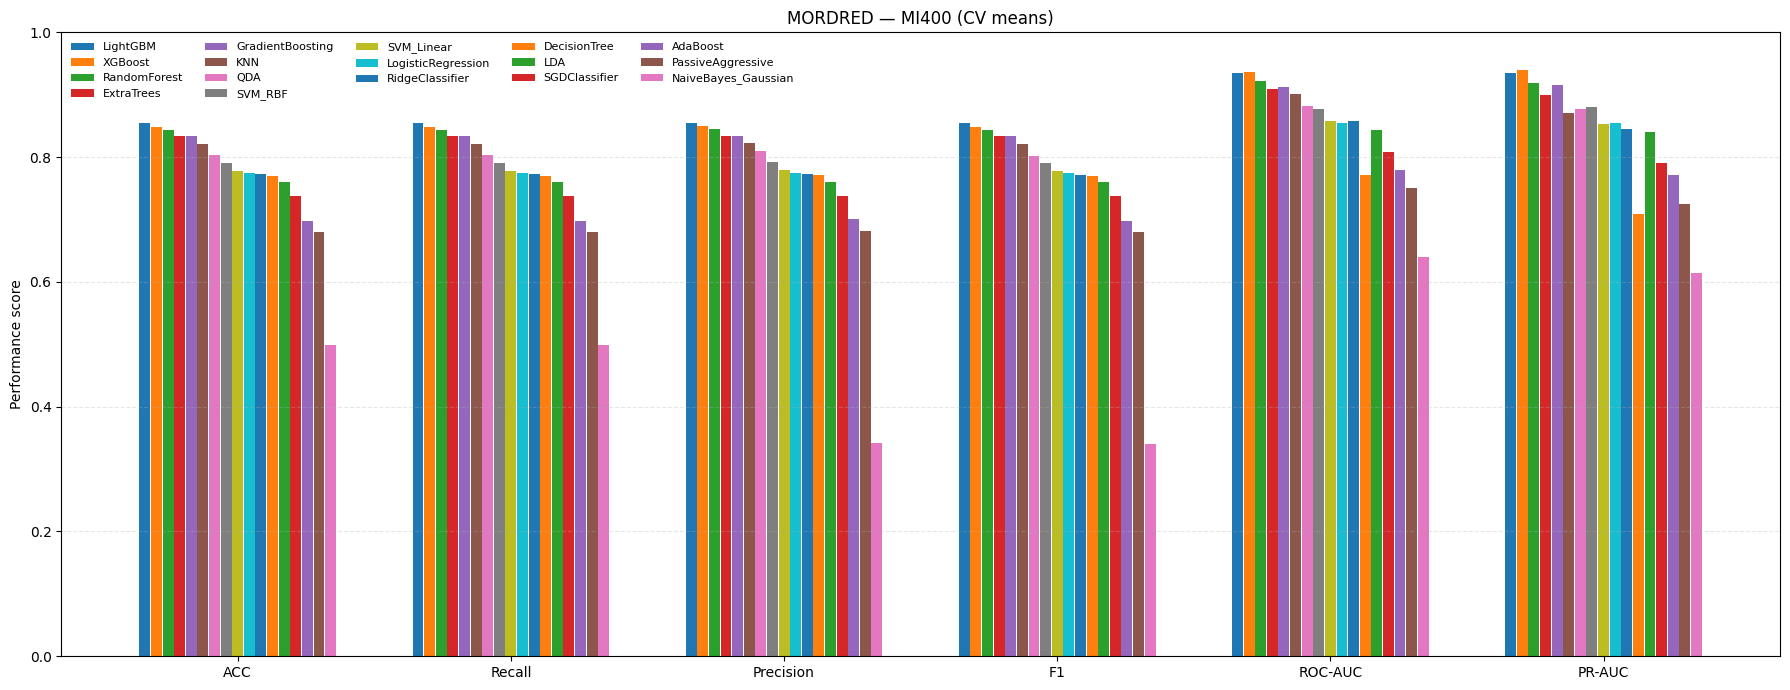

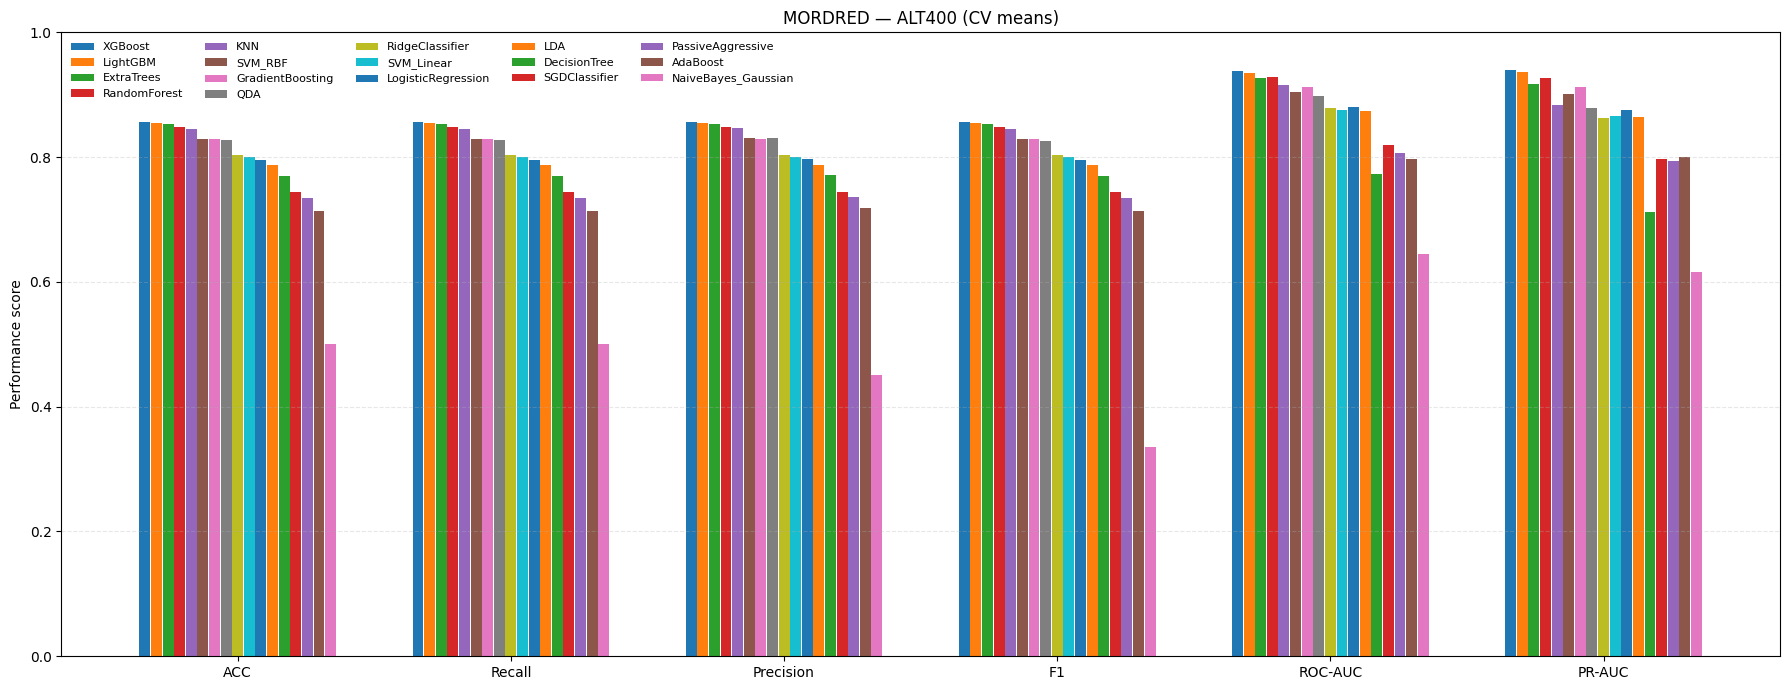

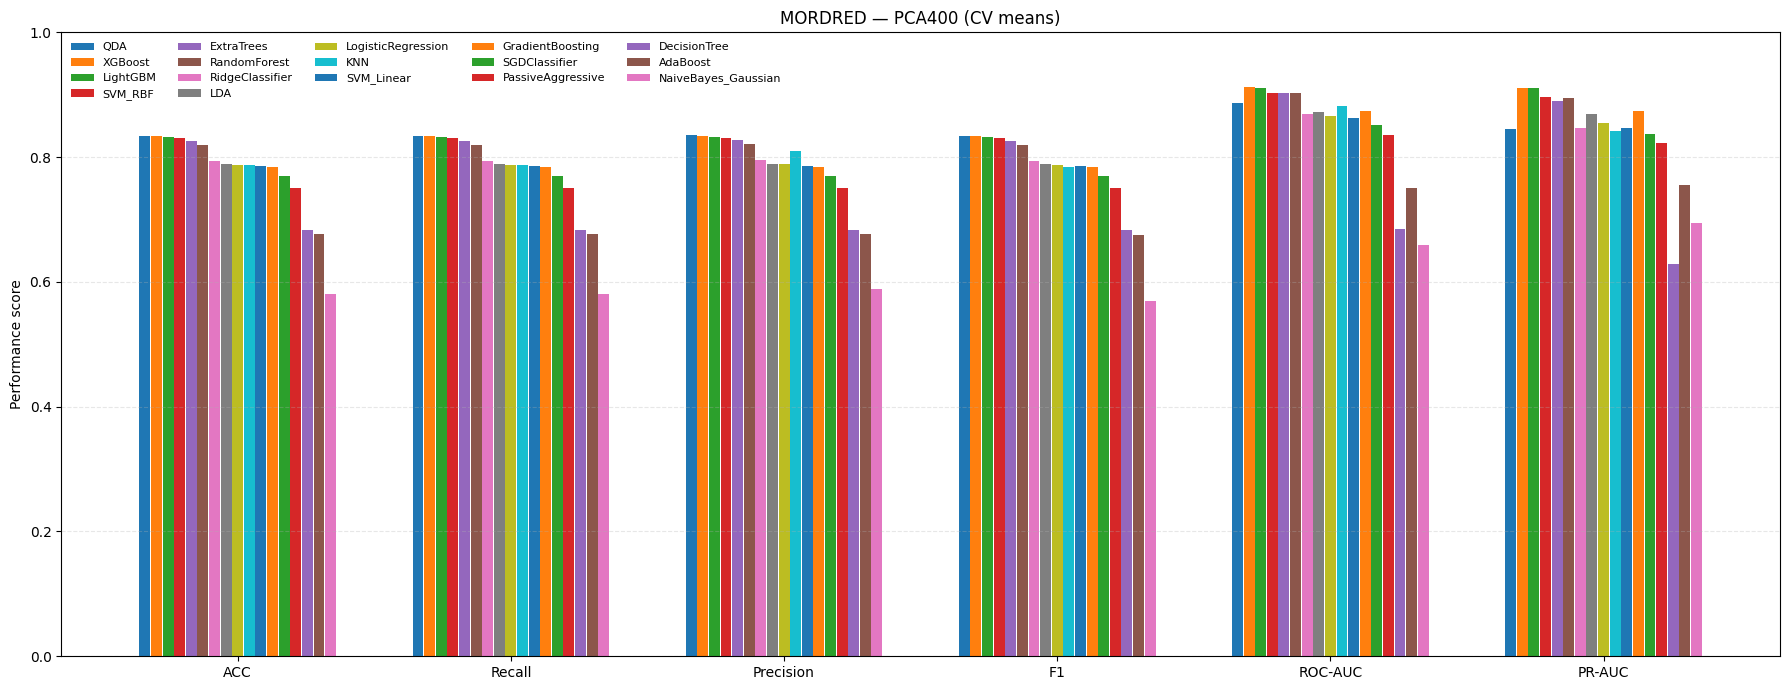

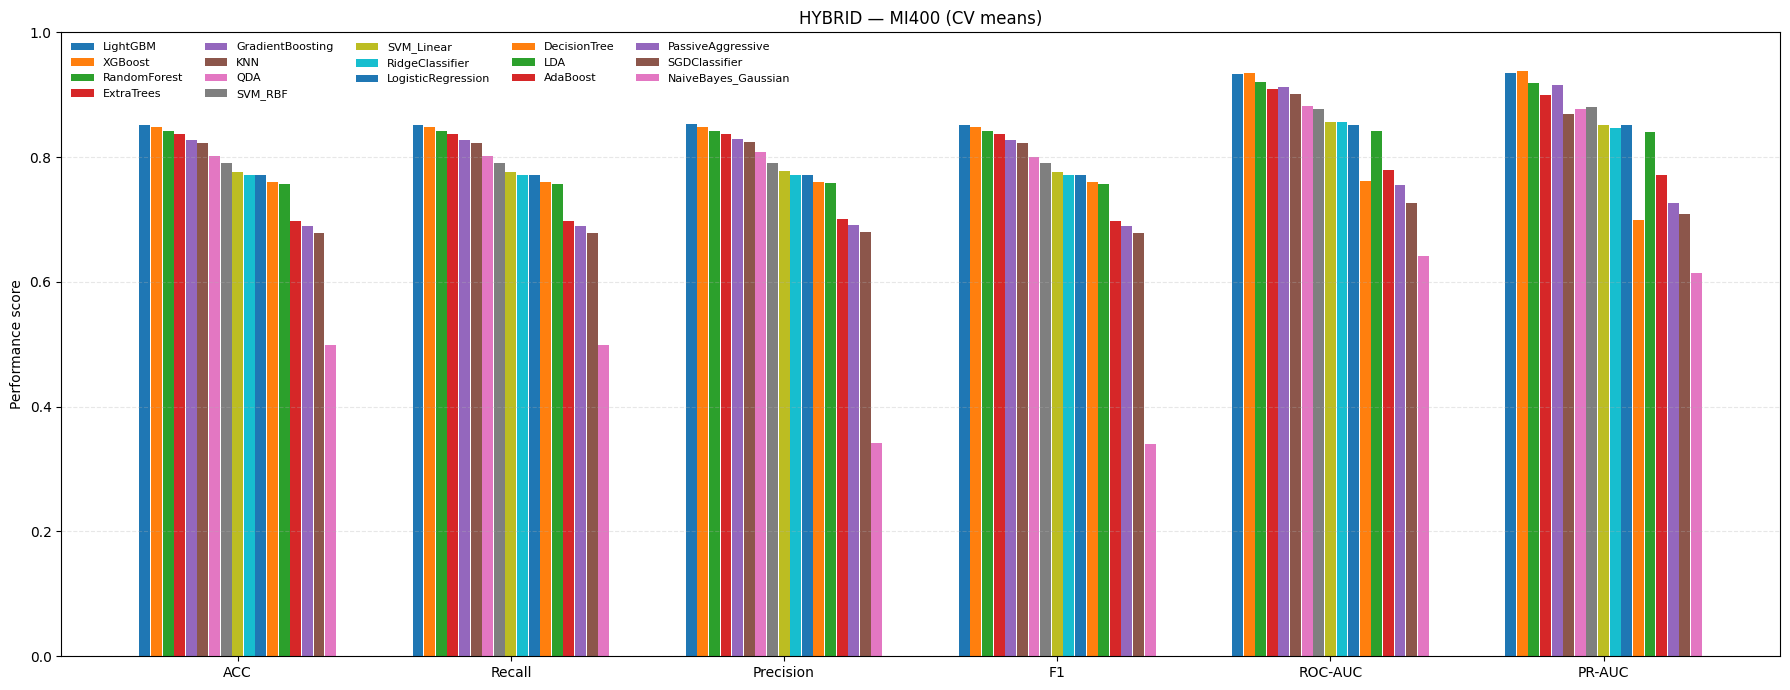

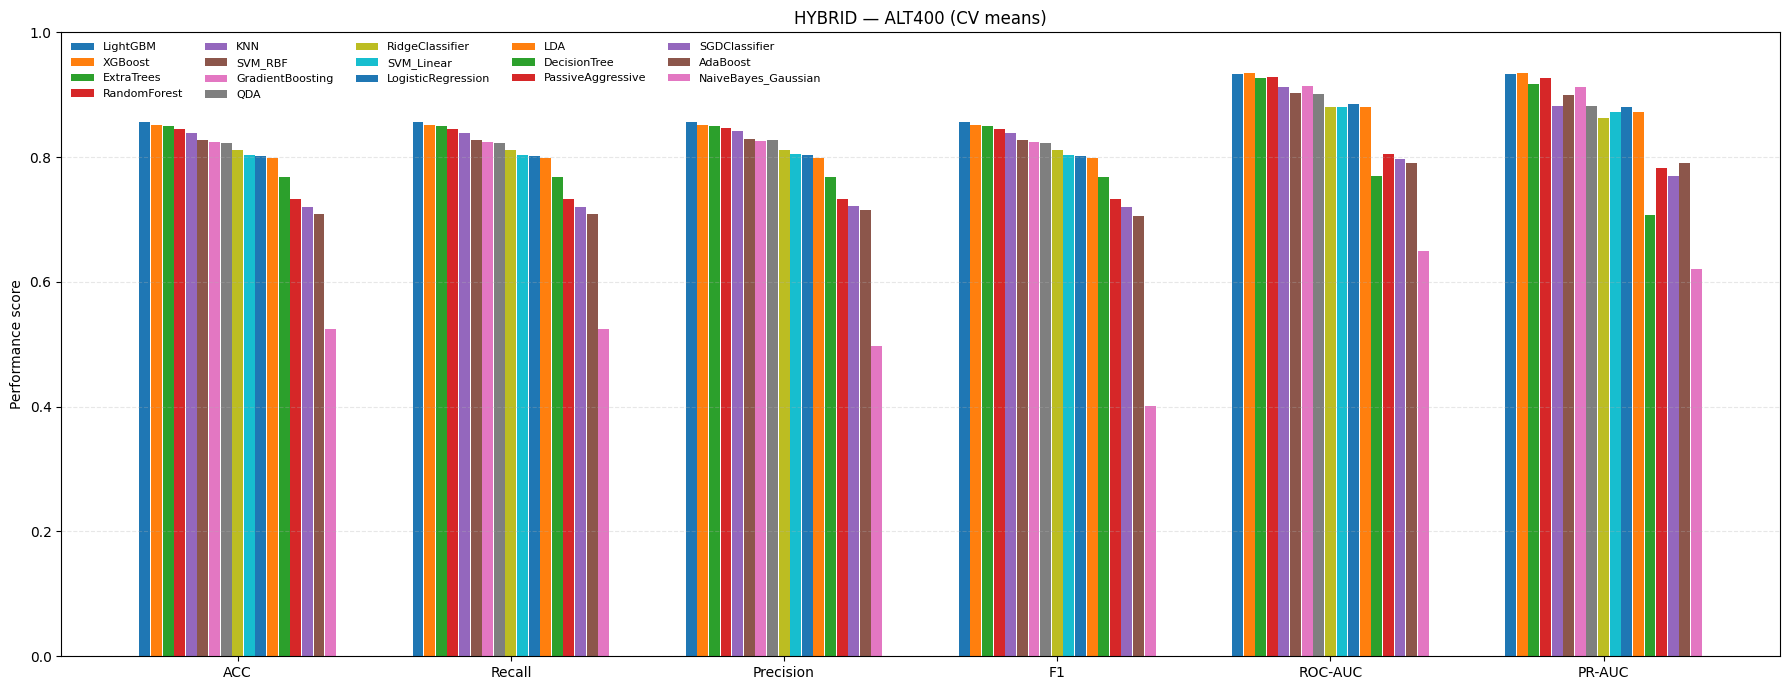

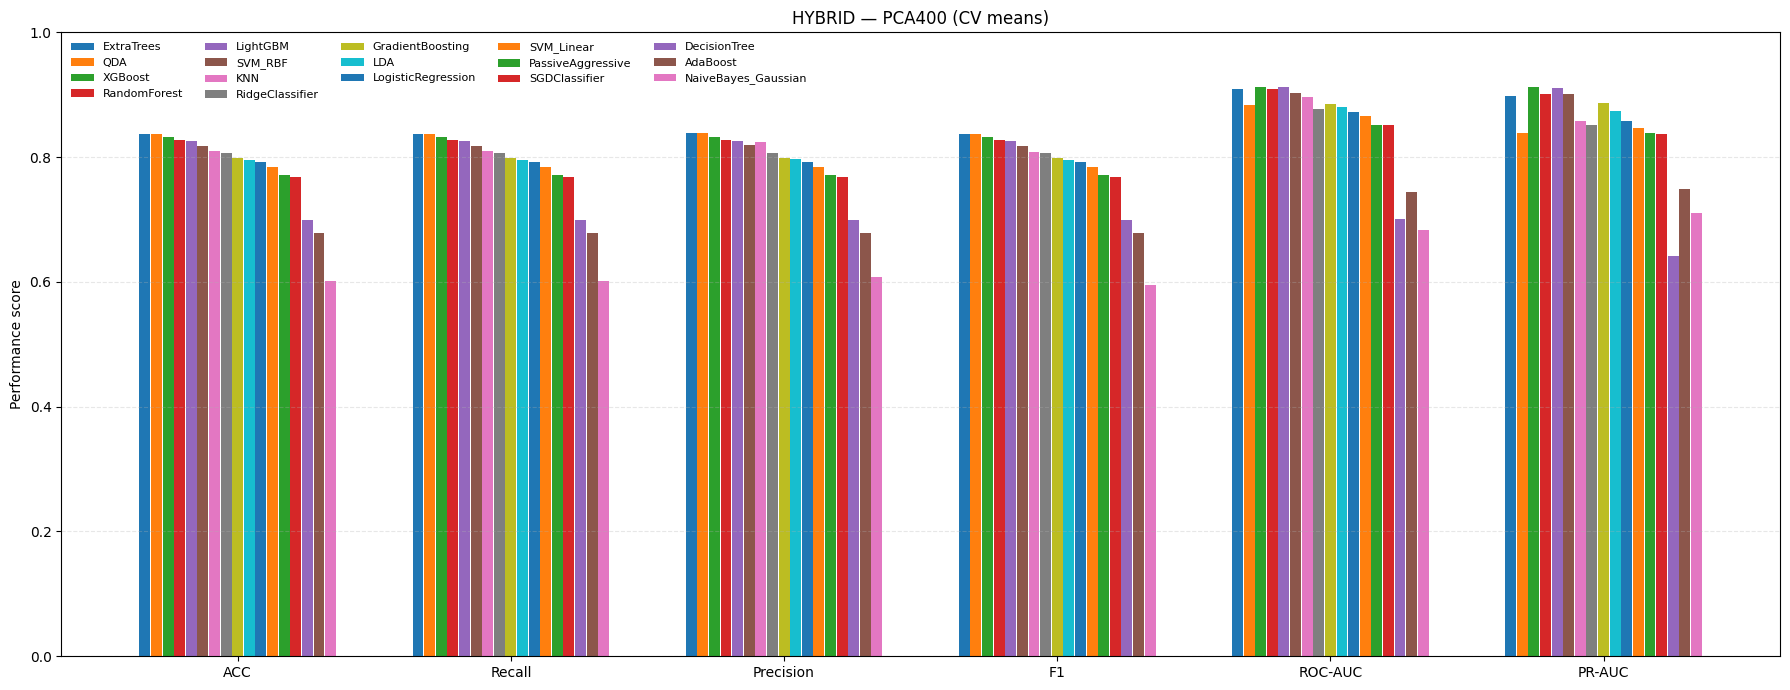

In [5]:
# === Cell 3: Panel-style grouped bar charts for ALL 20 models ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_ROOT = Path("./results/baselines")
summary_path = RESULTS_ROOT / "ALL_cv_summary_full.csv"

# Load the combined summary
all_cv = pd.read_csv(summary_path)

# Metric keys and nice labels
METRICS = [
    ("Accuracy_mean",        "ACC"),
    ("Recall_macro_mean",    "Recall"),
    ("Precision_macro_mean", "Precision"),
    ("F1_macro_mean",        "F1"),
    ("ROC-AUC_mean",         "ROC-AUC"),
    ("PR-AUC_mean",          "PR-AUC"),
]

def plot_grouped_metrics(df, dataset, track, models=None, bar_width=0.04):
    """Grouped-bar chart of metrics vs models for one dataset×track."""
    sub = df[(df["Dataset"] == dataset) & (df["Track"] == track)].copy()
    if sub.empty:
        print(f"[WARN] No rows for {dataset} | {track}")
        return

    # Keep only selected models (if provided), else all
    if models is not None:
        sub = sub[sub["Model"].isin(models)]

    # Order models by Accuracy for consistent legend
    sub = sub.sort_values("Accuracy_mean", ascending=False)

    model_names = sub["Model"].tolist()
    n_models = len(model_names)
    metric_keys  = [k for k,_ in METRICS]
    metric_labels= [lab for _,lab in METRICS]
    n_metrics = len(metric_keys)

    # Build matrix
    mat = np.zeros((n_metrics, n_models), dtype=float)
    for mi, key in enumerate(metric_keys):
        mat[mi, :] = sub[key].values

    x = np.arange(n_metrics)  # metric positions
    total_group_width = min(0.9, n_models * bar_width)
    offsets = np.linspace(-total_group_width/2, total_group_width/2, n_models)

    plt.figure(figsize=(18, 7))
    for j in range(n_models):
        plt.bar(x + offsets[j], mat[:, j], width=bar_width, label=model_names[j])

    plt.xticks(x, metric_labels, rotation=0)
    plt.ylim(0, 1.0)
    plt.ylabel("Performance score")
    plt.title(f"{dataset} — {track} (CV means)")
    plt.legend(ncol=5, fontsize=8, frameon=False)
    plt.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

# === Run for all dataset×track combos ===
for ds in ["MORDRED", "HYBRID"]:
    for tr in ["MI400", "ALT400", "PCA400"]:
        plot_grouped_metrics(all_cv, dataset=ds, track=tr, models=None, bar_width=0.04)


In [10]:
# === Cell 3: Panel-style grouped bar charts for ALL 20 models (save PNGs; MORDRED->2D) ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_ROOT = Path("./results/baselines")
summary_path = RESULTS_ROOT / "ALL_cv_summary_full.csv"
OUT_DIR = RESULTS_ROOT / "PLOTS_GROUPED"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Display names
DS_DISPLAY = {"MORDRED": "2D", "HYBRID": "HYBRID"}

# Load the combined summary
all_cv = pd.read_csv(summary_path)

# Metric keys and nice labels
METRICS = [
    ("Accuracy_mean",        "ACC"),
    ("Recall_macro_mean",    "Recall"),
    ("Precision_macro_mean", "Precision"),
    ("F1_macro_mean",        "F1"),
    ("ROC-AUC_mean",         "ROC-AUC"),
    ("PR-AUC_mean",          "PR-AUC"),
]

def plot_grouped_metrics(df, dataset, track, models=None, bar_width=0.04, save=True):
    """Grouped-bar chart of metrics vs models for one dataset×track; saves PNG."""
    sub = df[(df["Dataset"] == dataset) & (df["Track"] == track)].copy()
    if sub.empty:
        print(f"[WARN] No rows for {dataset} | {track}")
        return

    if models is not None:
        sub = sub[sub["Model"].isin(models)]

    sub = sub.sort_values("Accuracy_mean", ascending=False)

    model_names = sub["Model"].tolist()
    n_models = len(model_names)
    metric_keys  = [k for k,_ in METRICS]
    metric_labels= [lab for _,lab in METRICS]
    n_metrics = len(metric_keys)

    mat = np.zeros((n_metrics, n_models), dtype=float)
    for mi, key in enumerate(metric_keys):
        mat[mi, :] = sub[key].values

    x = np.arange(n_metrics)  # metric positions
    total_group_width = min(0.9, n_models * bar_width)
    offsets = np.linspace(-total_group_width/2, total_group_width/2, n_models)

    fig = plt.figure(figsize=(18, 7))
    for j in range(n_models):
        plt.bar(x + offsets[j], mat[:, j], width=bar_width, label=model_names[j])

    plt.xticks(x, metric_labels, rotation=0)
    plt.ylim(0, 1.0)
    plt.ylabel("Performance score")

    ds_disp = DS_DISPLAY.get(dataset, dataset)
    title = f"{ds_disp} — {track} (CV means)"
    plt.title(title)

    plt.legend(ncol=5, fontsize=8, frameon=False)
    plt.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout()

    if save:
        fname = OUT_DIR / f"grouped_{ds_disp}_{track}.png"
        plt.savefig(fname, dpi=180, bbox_inches="tight")
        print(f"✓ saved {fname}")

    plt.close(fig)

# === Run for all dataset×track combos (and save PNGs) ===
for ds in ["MORDRED", "HYBRID"]:
    for tr in ["MI400", "ALT400", "PCA400"]:
        plot_grouped_metrics(all_cv, dataset=ds, track=tr, models=None, bar_width=0.04, save=True)


✓ saved results\baselines\PLOTS_GROUPED\grouped_2D_MI400.png
✓ saved results\baselines\PLOTS_GROUPED\grouped_2D_ALT400.png
✓ saved results\baselines\PLOTS_GROUPED\grouped_2D_PCA400.png
✓ saved results\baselines\PLOTS_GROUPED\grouped_HYBRID_MI400.png
✓ saved results\baselines\PLOTS_GROUPED\grouped_HYBRID_ALT400.png
✓ saved results\baselines\PLOTS_GROUPED\grouped_HYBRID_PCA400.png



=== Our Top 10 Selected Models (All Metrics) ===
Dataset  Track      Model  Accuracy_mean  Recall_macro_mean  Precision_macro_mean  F1_macro_mean  ROC-AUC_mean  PR-AUC_mean
MORDRED ALT400    XGBoost       0.855903           0.855903              0.856288       0.855863      0.937393     0.939788
 HYBRID ALT400   LightGBM       0.855556           0.855556              0.855821       0.855529      0.932847     0.932844
MORDRED ALT400   LightGBM       0.854861           0.854861              0.855325       0.854815      0.935384     0.936001
MORDRED  MI400   LightGBM       0.854167           0.854167              0.854576       0.854126      0.934376     0.935610
MORDRED ALT400 ExtraTrees       0.852778           0.852778              0.853259       0.852727      0.926720     0.917035
 HYBRID  MI400   LightGBM       0.852083           0.852083              0.852586       0.852033      0.933216     0.934631
 HYBRID ALT400    XGBoost       0.851042           0.851042              0.851312 

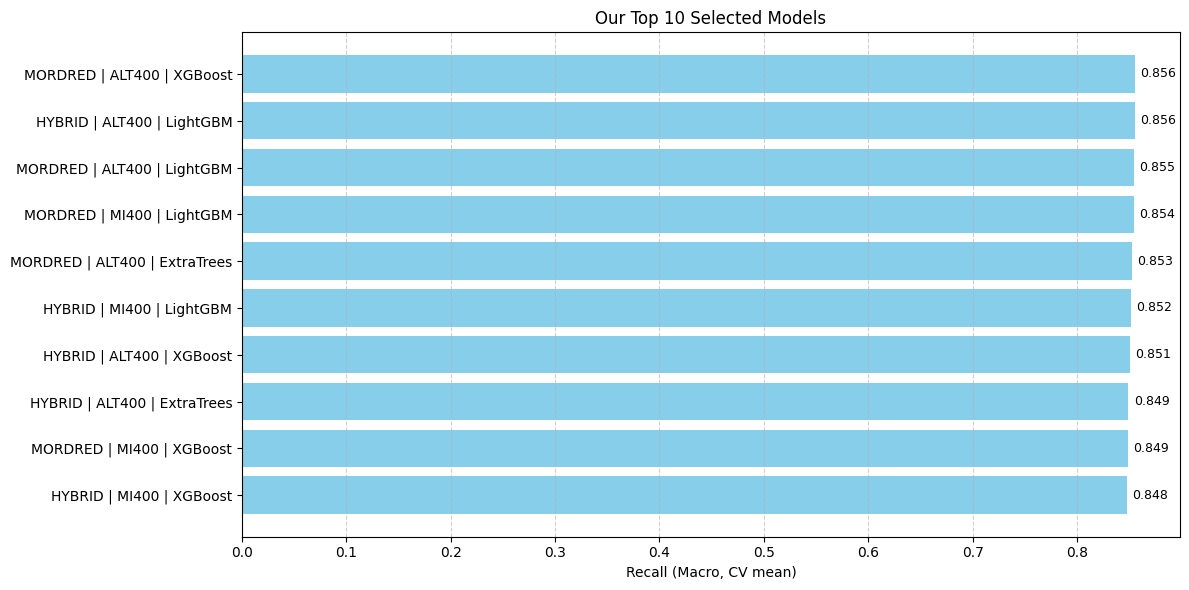

In [6]:
# === Cell 3: Select & Visualize Top 10 Models ===
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_ROOT = Path("./results/baselines")
summary_path = RESULTS_ROOT / "ALL_cv_summary_full.csv"

# Load CV summary
all_cv = pd.read_csv(summary_path)

# ---- Ranking order ----
RANK_ORDER = [
    "Recall_macro_mean",   # 1. Prioritize Recall
    "PR-AUC_mean",         # 2. Handle imbalance
    "F1_macro_mean",       # 3. Balance precision & recall
    "ROC-AUC_mean",        # 4. Threshold-independent discrimination
    "Accuracy_mean"        # 5. Tie-breaker
]

# Sort by priority metrics
ranked = all_cv.sort_values(by=RANK_ORDER, ascending=False).reset_index(drop=True)

# Select Top 10
top10 = ranked.head(10)

# Save results
top10.to_csv(RESULTS_ROOT / "TOP10_models.csv", index=False)

# ---- Display Top 10 as full table (5 main metrics) ----
metrics_cols = [
    "Dataset", "Track", "Model",
    "Accuracy_mean", "Recall_macro_mean", "Precision_macro_mean",
    "F1_macro_mean", "ROC-AUC_mean", "PR-AUC_mean"
]

print("\n=== Our Top 10 Selected Models (All Metrics) ===")
print(top10[metrics_cols].to_string(index=False))

# ---- Visualization (Recall) ----
plt.figure(figsize=(12, 6))
bars = plt.barh(
    [f"{d} | {t} | {m}" for d, t, m in zip(top10["Dataset"], top10["Track"], top10["Model"])],
    top10["Recall_macro_mean"],
    color="skyblue"
)

plt.xlabel("Recall (Macro, CV mean)")
plt.title("Our Top 10 Selected Models")
plt.gca().invert_yaxis()  # Highest at top
plt.grid(axis="x", linestyle="--", alpha=0.6)

# Annotate bars
for bar, val in zip(bars, top10["Recall_macro_mean"]):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()


In [21]:
# === Phase 1: Hyperparameter Tuning (Top-10) — run ONE MODEL at a time, with PROGRESS ===
import json, os, time, math
from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, recall_score, f1_score, precision_score, accuracy_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import ExtraTreesClassifier
import random
import joblib

# -------------------------
# CONFIG
# -------------------------
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

N_SPLITS = 5                       # CV folds
N_ITER_XGB = 30                    # Random-search iterations
N_ITER_LGBM = 30
N_ITER_ET   = 20
PROGRESS_EVERY = 5                 # print progress every N candidates

RESULTS_DIR = Path("./results/tuning")   # where tuning artifacts go

# Toggle GPU (set to False if your package isn't GPU-enabled)
USE_GPU_XGB  = True
USE_GPU_LGBM = True

# Map dataset/track -> training CSV (created in preprocessing phase)
TRAIN_PATHS = {
    ("MORDRED","MI400"):  Path("prep/mordred/mi400/train_mi400.csv"),
    ("MORDRED","ALT400"): Path("prep/mordred/alt400/train_alt400.csv"),
    ("MORDRED","PCA400"): Path("prep/mordred/pca400/train_pca400.csv"),
    ("HYBRID","MI400"):   Path("prep/hybrid/mi400/train_mi400.csv"),
    ("HYBRID","ALT400"):  Path("prep/hybrid/alt400/train_alt400.csv"),
    ("HYBRID","PCA400"):  Path("prep/hybrid/pca400/train_pca400.csv"),
}

# === Your exact Top-10 combos (edit TARGETS to run one-at-a-time) ===
TOP10 = [
    ("MORDRED","ALT400","XGBoost"),
    ("HYBRID","ALT400","LightGBM"),
    ("MORDRED","ALT400","LightGBM"),
    ("MORDRED","MI400","LightGBM"),
    ("MORDRED","ALT400","ExtraTrees"),
    ("HYBRID","MI400","LightGBM"),
    ("HYBRID","ALT400","XGBoost"),
    ("HYBRID","ALT400","ExtraTrees"),
    ("MORDRED","MI400","XGBoost"),
    ("HYBRID","MI400","XGBoost"),
]

# Run ONE at a time for easier monitoring; change this list to the next one when ready
TARGETS = [
    ("HYBRID","MI400","XGBoost"),
]

# -------------------------
# Helpers
# -------------------------
def detect_target(df):
    cand = ["cls","class","label","active","activity","y","target"]
    for c in df.columns:
        if c.lower() in cand:
            return c
    return df.columns[-1]

def ensure_binary(y):
    y = pd.Series(y).astype(int)
    uniq = sorted(y.unique())
    if uniq != [0,1]:
        mapping = {uniq[0]:0, uniq[-1]:1}
        y = y.map(mapping)
    return y

def scale_pos_weight(y):
    y = pd.Series(y)
    pos = int((y == 1).sum())
    neg = int((y == 0).sum())
    return float(neg / max(pos, 1))

def make_scoring():
    return {
        "recall_macro":    make_scorer(recall_score,    average="macro", zero_division=0),
        "precision_macro": make_scorer(precision_score, average="macro", zero_division=0),
        "f1_macro":        make_scorer(f1_score,        average="macro", zero_division=0),
        "accuracy":        make_scorer(accuracy_score),
        "roc_auc":         "roc_auc",
        "pr_auc":          "average_precision",
    }

def load_train(dataset, track):
    path = TRAIN_PATHS[(dataset, track)]
    if not path.exists():
        raise FileNotFoundError(f"Missing train CSV: {path}")
    df = pd.read_csv(path)
    tgt = detect_target(df)
    y = ensure_binary(df[tgt])
    X = df.drop(columns=[tgt])
    return X, y, path

def make_cv():
    return StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# -------------------------
# Type coercion helper to fix float→int errors
# -------------------------
def coerce_param_types(model_name, params):
    p = dict(params)

    def nan2none(v):
        return None if (isinstance(v, float) and math.isnan(v)) else v
    p = {k: nan2none(v) for k, v in p.items()}

    name = model_name.lower()
    if name == "xgboost":
        for k in ["n_estimators","max_depth","min_child_weight"]:
            if k in p: p[k] = int(p[k])
        for k in ["learning_rate","subsample","colsample_bytree","reg_lambda"]:
            if k in p: p[k] = float(p[k])

    elif name == "lightgbm":
        for k in ["n_estimators","num_leaves","max_depth","min_child_samples"]:
            if k in p: p[k] = int(p[k])
        for k in ["learning_rate","subsample","colsample_bytree","reg_lambda"]:
            if k in p: p[k] = float(p[k])

    elif name == "extratrees":
        if "max_depth" in p:
            v = p["max_depth"]
            if v is None or (isinstance(v, float) and math.isnan(v)):
                p["max_depth"] = None
            else:
                p["max_depth"] = int(v)
        for k in ["n_estimators","min_samples_split","min_samples_leaf"]:
            if k in p: p[k] = int(p[k])
        if "max_features" in p and not isinstance(p["max_features"], str):
            p["max_features"] = float(p["max_features"])
        if "bootstrap" in p:
            p["bootstrap"] = bool(p["bootstrap"])

    return p

# -------------------------
# Model factories + sampling spaces
# -------------------------
def build_xgb(y):
    spw = scale_pos_weight(y)
    base = dict(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="gpu_hist" if USE_GPU_XGB else "hist",
        predictor="gpu_predictor" if USE_GPU_XGB else "auto",
        scale_pos_weight=spw,
    )
    est = XGBClassifier(**base)
    def sampler():
        return {
            "n_estimators":     int(rng.choice([200, 400, 800, 1200])),
            "max_depth":        int(rng.choice([3, 5, 7, 9])),
            "learning_rate":    float(rng.choice([0.01, 0.03, 0.05, 0.1])),
            "subsample":        float(rng.choice([0.7, 0.85, 1.0])),
            "colsample_bytree": float(rng.choice([0.7, 0.85, 1.0])),
            "min_child_weight": int(rng.choice([1, 3, 5])),
            "reg_lambda":       float(rng.choice([0.0, 0.5, 1.0, 2.0])),
        }
    return est, sampler, N_ITER_XGB

def build_lgbm(y):
    spw = scale_pos_weight(y)
    base = dict(
        objective="binary",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        device="gpu" if USE_GPU_LGBM else "cpu",
        scale_pos_weight=spw,
        verbose=-1,
    )
    est = LGBMClassifier(**base)
    def sampler():
        return {
            "n_estimators":      int(rng.choice([400, 800, 1200])),
            "learning_rate":     float(rng.choice([0.01, 0.03, 0.05, 0.1])),
            "num_leaves":        int(rng.choice([31, 63, 127, 255])),
            "max_depth":         int(rng.choice([-1, 7, 11, 15])),
            "min_child_samples": int(rng.choice([10, 20, 50])),
            "subsample":         float(rng.choice([0.7, 0.85, 1.0])),
            "colsample_bytree":  float(rng.choice([0.7, 0.85, 1.0])),
            "reg_lambda":        float(rng.choice([0.0, 0.5, 1.0, 2.0])),
        }
    return est, sampler, N_ITER_LGBM

def build_extratrees(y):
    est = ExtraTreesClassifier(
        random_state=RANDOM_STATE, n_jobs=-1, class_weight="balanced"
    )
    def sampler():
        mf = random.choice(["sqrt", "log2", 0.5, 1.0])
        return {
            "n_estimators":      int(rng.choice([400, 800, 1200])),
            "max_depth":         random.choice([None, 10, 20, 30]),
            "max_features":      mf,
            "min_samples_split": int(rng.choice([2, 5, 10])),
            "min_samples_leaf":  int(rng.choice([1, 2, 4])),
            "bootstrap":         random.choice([False, True]),
        }
    return est, sampler, N_ITER_ET

def build_model(model_name, y):
    if model_name.lower() == "xgboost":
        return build_xgb(y)
    if model_name.lower() == "lightgbm":
        return build_lgbm(y)
    if model_name.lower() == "extratrees":
        return build_extratrees(y)
    raise ValueError(f"Unsupported model: {model_name}")

# -------------------------
# Random search with PROGRESS + elapsed/ETA
# -------------------------
def random_search_progress(est, sampler, n_iter, X, y, dataset, track, model_name):
    scoring = make_scoring()
    cv = make_cv()

    results_rows = []
    best_idx = None
    best_refit = -np.inf

    start = time.time()
    print(f"[INFO] {dataset}|{track}|{model_name}: starting random search — {n_iter} candidates × {N_SPLITS}-fold CV")

    for i in range(1, n_iter + 1):
        params = sampler()
        est.set_params(**params)

        scores = cross_validate(
            est, X, y,
            scoring=scoring,
            cv=cv,
            n_jobs=-1,
            return_train_score=False,
            error_score="raise"
        )

        row = {"candidate": i,
               **{f"{k}_mean": float(np.mean(v)) for k, v in scores.items() if k.startswith("test_")}}
        row = {k.replace("test_", ""): v for k, v in row.items()}
        row.update(params)
        results_rows.append(row)

        refit_val = row["recall_macro_mean"]
        if refit_val > best_refit:
            best_refit = refit_val
            best_idx = len(results_rows) - 1

        if (i % PROGRESS_EVERY == 0) or (i == n_iter):
            elapsed = time.time() - start
            avg_per_cand = elapsed / i
            remaining = (n_iter - i) * avg_per_cand
            print(f"⏱️ [{track}|{model_name}] {i}/{n_iter} fits done | "
                  f"{elapsed/60:.1f} min elapsed | ETA ~ {remaining/60:.1f} min")

    df = pd.DataFrame(results_rows)
    best_row = df.iloc[best_idx].to_dict()

    best_params = {k: best_row[k] for k in list(results_rows[0].keys())
                   if k not in ["candidate","recall_macro_mean","precision_macro_mean","f1_macro_mean",
                                "accuracy_mean","roc_auc_mean","pr_auc_mean"]}

    # coerce params back to correct types
    best_params = coerce_param_types(model_name, best_params)

    # final refit
    est.set_params(**best_params)
    est.fit(X, y)

    total_min = (time.time() - start) / 60.0
    print(f"[DONE] {dataset}|{track}|{model_name}: best recall_macro={best_refit:.4f} | total {total_min:.1f} min")
    return est, df, best_params, float(best_refit)

# -------------------------
# Tuning runner
# -------------------------
def tune_one(dataset, track, model_name):
    X, y, path = load_train(dataset, track)
    print(f"\n=== TUNING: {dataset} | {track} | {model_name} ===")
    print(f"Data: {path}  ->  X:{X.shape}  y:{y.value_counts().to_dict()}")

    est, sampler, n_iter = build_model(model_name, y)

    # GPU safety
    if isinstance(est, XGBClassifier) and USE_GPU_XGB:
        try: est.set_params(tree_method="gpu_hist", predictor="gpu_predictor")
        except: est.set_params(tree_method="hist", predictor="auto")
    if isinstance(est, LGBMClassifier) and USE_GPU_LGBM:
        try: est.set_params(device="gpu")
        except: est.set_params(device="cpu")

    best_est, cv_df, best_params, best_refit = random_search_progress(
        est, sampler, n_iter, X, y, dataset, track, model_name
    )

    out_dir = RESULTS_DIR / dataset.lower() / track.lower() / model_name
    out_dir.mkdir(parents=True, exist_ok=True)

    joblib.dump(best_est, out_dir / "best_estimator.joblib")
    with open(out_dir / "best_params.json", "w") as f:
        json.dump(best_params, f, indent=2)
    cv_df.to_csv(out_dir / "cv_results.csv", index=False)

    print(f"\n>>> BEST (refit=Recall_macro): {dataset} | {track} | {model_name}")
    print(f"Best Recall_macro (CV mean): {best_refit:.4f}")
    print("Best params:", best_params)
    return {"dataset": dataset,"track": track,"model": model_name,
            "best_recall_macro": best_refit,"best_params": best_params,
            "out_dir": str(out_dir)}

# -------------------------
# Run selected targets
# -------------------------
summaries = []
for ds, tr, mdl in TARGETS:
    summaries.append(tune_one(ds, tr, mdl))

if summaries:
    run_df = pd.DataFrame(summaries)
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    run_df.to_csv(RESULTS_DIR / "tuning_run_summary.csv", index=False)
    print("\n=== Saved:", RESULTS_DIR / "tuning_run_summary.csv")



=== TUNING: HYBRID | MI400 | XGBoost ===
Data: prep\hybrid\mi400\train_mi400.csv  ->  X:(2880, 400)  y:{1: 1440, 0: 1440}
[INFO] HYBRID|MI400|XGBoost: starting random search — 30 candidates × 5-fold CV
⏱️ [MI400|XGBoost] 5/30 fits done | 1.6 min elapsed | ETA ~ 7.9 min
⏱️ [MI400|XGBoost] 10/30 fits done | 4.6 min elapsed | ETA ~ 9.2 min
⏱️ [MI400|XGBoost] 15/30 fits done | 7.4 min elapsed | ETA ~ 7.4 min
⏱️ [MI400|XGBoost] 20/30 fits done | 10.2 min elapsed | ETA ~ 5.1 min
⏱️ [MI400|XGBoost] 25/30 fits done | 11.7 min elapsed | ETA ~ 2.3 min
⏱️ [MI400|XGBoost] 30/30 fits done | 13.4 min elapsed | ETA ~ 0.0 min
[DONE] HYBRID|MI400|XGBoost: best recall_macro=0.8559 | total 13.7 min

>>> BEST (refit=Recall_macro): HYBRID | MI400 | XGBoost
Best Recall_macro (CV mean): 0.8559
Best params: {'n_estimators': 1200, 'max_depth': 9, 'learning_rate': 0.05, 'subsample': 0.85, 'colsample_bytree': 1.0, 'min_child_weight': 1, 'reg_lambda': 2.0}

=== Saved: results\tuning\tuning_run_summary.csv


In [3]:
# === One-Cell Export: Tuning Tables + Grouped-Bar Charts PDFs ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from pathlib import Path
import glob

# -----------------------------
# Config & discovery
# -----------------------------
ROOT = Path("./results/tuning")
OUT_TABLES_PDF = ROOT / "TUNING_tables.pdf"
OUT_PLOTS_PDF  = ROOT / "TUNING_grouped_metrics_plots.pdf"
OUT_CSV        = ROOT / "ALL_tuning_summary_RENAMED.csv"

# Find all cv_results.csv files produced by your tuning cell
paths = sorted(Path(ROOT).glob("*/*/*/cv_results.csv"))  # dataset/track/model/cv_results.csv

if not paths:
    raise FileNotFoundError(
        f"No cv_results.csv files found under {ROOT}. "
        "Run the tuning cell first or adjust ROOT."
    )

records = []
for p in paths:
    # Parse dataset, track, model from path: ROOT/dataset/track/model/cv_results.csv
    try:
        model = p.parent.name
        track = p.parent.parent.name
        dataset = p.parent.parent.parent.name
    except Exception:
        # fallback: best-effort split
        parts = p.parts
        dataset, track, model = parts[-4], parts[-3], parts[-2]

    df = pd.read_csv(p)

    # Expect columns like recall_macro_mean, accuracy_mean, precision_macro_mean, f1_macro_mean, roc_auc_mean, pr_auc_mean
    # Pick best row by recall (refit metric)
    if "recall_macro_mean" not in df.columns:
        # Try alternate casing just in case
        raise ValueError(f"'recall_macro_mean' not found in {p}. Columns={df.columns.tolist()}")

    best = df.loc[df["recall_macro_mean"].astype(float).idxmax()].to_dict()

    # Collect with original metric names then rename later
    rec = {
        "Dataset": dataset.upper(),
        "Track": track.upper(),
        "Model": model,
        "Accuracy_mean":        float(best.get("accuracy_mean", np.nan)),
        "Recall_macro_mean":    float(best.get("recall_macro_mean", np.nan)),
        "Precision_macro_mean": float(best.get("precision_macro_mean", np.nan)),
        "F1_macro_mean":        float(best.get("f1_macro_mean", np.nan)),
        "ROC-AUC_mean":         float(best.get("roc_auc_mean", np.nan)),
        "PR-AUC_mean":          float(best.get("pr_auc_mean", np.nan)),
    }
    records.append(rec)

all_best = pd.DataFrame(records)

# -----------------------------
# Rename columns exactly as requested for the TABLE
#  - Accuracy_mean → accuracy
#  - Recall_macro_mean → recall
#  - Precision_macro_mean → precision
#  - F1_macro_mean → F1-macro
#  - ROC-AUC_mean → ROC-AUC
#  - PR-AUC_mean → PR-AUC
# -----------------------------
rename_map = {
    "Accuracy_mean":        "accuracy",
    "Recall_macro_mean":    "recall",
    "Precision_macro_mean": "precision",
    "F1_macro_mean":        "F1-macro",
    "ROC-AUC_mean":         "ROC-AUC",
    "PR-AUC_mean":          "PR-AUC",
}
all_best_renamed = all_best.rename(columns=rename_map).copy()

# Save the renamed CSV for convenience
OUT_CSV.parent.mkdir(parents=True, exist_ok=True)
all_best_renamed.to_csv(OUT_CSV, index=False)

# -----------------------------
# Build Tables PDF
# -----------------------------
def render_table_page(sub_df, title, pdf):
    numeric_cols = ["accuracy","recall","precision","F1-macro","ROC-AUC","PR-AUC"]
    sub = sub_df.copy()
    for c in numeric_cols:
        if c in sub.columns:
            sub[c] = pd.to_numeric(sub[c], errors="coerce").round(3)
    sub = sub.sort_values("accuracy", ascending=False)

    cols_order = [c for c in ["Model","accuracy","recall","precision","F1-macro","ROC-AUC","PR-AUC"] if c in sub.columns]
    rows = len(sub)
    fig_height = min(0.5 + rows * 0.35, 10)

    fig, ax = plt.subplots(figsize=(14, fig_height))
    ax.axis("off")
    ax.set_title(title, pad=12, fontsize=14)
    tbl = ax.table(cellText=sub[cols_order].values,
                   colLabels=cols_order,
                   loc="center",
                   cellLoc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.2)
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

with PdfPages(OUT_TABLES_PDF) as pdf:
    for ds in sorted(all_best_renamed["Dataset"].unique()):
        for tr in sorted(all_best_renamed[all_best_renamed["Dataset"]==ds]["Track"].unique()):
            sub = all_best_renamed[(all_best_renamed["Dataset"]==ds) & (all_best_renamed["Track"]==tr)]
            if not sub.empty:
                render_table_page(sub, f"{ds} — {tr} (Best-by-recall per model; CV means)", pdf)

# -----------------------------
# Build Grouped-Bar Charts PDF (per dataset×track)
#   Metrics on x-axis; one bar per model per metric
# -----------------------------
METRICS = [
    ("accuracy",  "ACC"),
    ("recall",    "Recall"),
    ("precision", "Precision"),
    ("F1-macro",  "F1"),
    ("ROC-AUC",   "ROC-AUC"),
    ("PR-AUC",    "PR-AUC"),
]

def plot_grouped_metrics(sub_df, dataset, track, pdf, bar_width=0.04):
    sub = sub_df.copy()
    if sub.empty:
        return
    sub = sub.sort_values("accuracy", ascending=False)
    model_names = sub["Model"].tolist()
    n_models = len(model_names)

    metric_keys  = [k for k,_ in METRICS]
    metric_labels= [lab for _,lab in METRICS]
    n_metrics = len(metric_keys)

    mat = np.zeros((n_metrics, n_models), dtype=float)
    for mi, key in enumerate(metric_keys):
        mat[mi, :] = pd.to_numeric(sub[key], errors="coerce").values

    x = np.arange(n_metrics)
    total_group_width = min(0.9, n_models * bar_width)
    offsets = np.linspace(-total_group_width/2, total_group_width/2, n_models)

    plt.figure(figsize=(18, 7))
    for j in range(n_models):
        plt.bar(x + offsets[j], mat[:, j], width=bar_width, label=model_names[j])
    plt.xticks(x, metric_labels, rotation=0)
    plt.ylim(0, 1.0)
    plt.ylabel("Performance score")
    plt.title(f"{dataset} — {track} (Best-by-recall; CV means)")
    plt.legend(ncol=5, fontsize=8, frameon=False)
    plt.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

with PdfPages(OUT_PLOTS_PDF) as pdf:
    for ds in sorted(all_best_renamed["Dataset"].unique()):
        ds_sub = all_best_renamed[all_best_renamed["Dataset"]==ds]
        for tr in sorted(ds_sub["Track"].unique()):
            sub = ds_sub[ds_sub["Track"]==tr]
            plot_grouped_metrics(sub, ds, tr, pdf, bar_width=0.04)

print(f"[OK] Tables PDF: {OUT_TABLES_PDF}")
print(f"[OK] Charts PDF: {OUT_PLOTS_PDF}")
print(f"[OK] Combined CSV (renamed): {OUT_CSV}")


[OK] Tables PDF: results\tuning\TUNING_tables.pdf
[OK] Charts PDF: results\tuning\TUNING_grouped_metrics_plots.pdf
[OK] Combined CSV (renamed): results\tuning\ALL_tuning_summary_RENAMED.csv


In [2]:
# === Phase 3: Mini Grid Search (ONE model at a time) ===
import json, time, random, math
from pathlib import Path
import itertools
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import ExtraTreesClassifier
import joblib

# ---------------- CONFIG ----------------
RANDOM_STATE = 42
REFIT_METRIC = "recall_macro"

N_SPLITS = 5
GRID_DIR = Path("results/grid")

# Run ONE at a time (edit this tuple each run)
TARGETS = [
    ("MORDRED","MI400","XGBoost"),  # change to the next target after this finishes 
]

# Paths (from your preprocessing phase)
TRAIN_PATHS = {
    ("MORDRED","MI400"):  Path("prep/mordred/mi400/train_mi400.csv"),
    ("MORDRED","ALT400"): Path("prep/mordred/alt400/train_alt400.csv"),
    ("MORDRED","PCA400"): Path("prep/mordred/pca400/train_pca400.csv"),
    ("HYBRID","MI400"):   Path("prep/hybrid/mi400/train_mi400.csv"),
    ("HYBRID","ALT400"):  Path("prep/hybrid/alt400/train_alt400.csv"),
    ("HYBRID","PCA400"):  Path("prep/hybrid/pca400/train_pca400.csv"),
}

# ---------------- HELPERS ----------------
def detect_target(df: pd.DataFrame) -> str:
    for c in df.columns:
        if c.lower() in ["cls","class","label","active","activity","y","target"]:
            return c
    return df.columns[-1]

def ensure_binary(y):
    y = pd.Series(y).astype(int)
    uniq = sorted(y.unique())
    if uniq != [0,1]:
        y = y.map({uniq[0]:0, uniq[-1]:1})
    return y

def load_train(dataset, track):
    path = TRAIN_PATHS[(dataset, track)]
    df = pd.read_csv(path)
    tgt = detect_target(df)
    y = ensure_binary(df[tgt])
    X = df.drop(columns=[tgt])
    return X, y, path

def coerce_param_types(model_name, params):
    p = dict(params)
    if model_name.lower() == "xgboost":
        for k in ["n_estimators","max_depth","min_child_weight"]:
            if k in p: p[k] = int(p[k])
        for k in ["learning_rate","subsample","colsample_bytree","reg_lambda"]:
            if k in p: p[k] = float(p[k])
    elif model_name.lower() == "lightgbm":
        for k in ["n_estimators","num_leaves","max_depth","min_child_samples"]:
            if k in p: p[k] = int(p[k])
        for k in ["learning_rate","subsample","colsample_bytree","reg_lambda"]:
            if k in p: p[k] = float(p[k])
    elif model_name.lower() == "extratrees":
        for k in ["n_estimators","min_samples_split","min_samples_leaf"]:
            if k in p: p[k] = int(p[k])
        if "max_depth" in p:
            if p["max_depth"] is None:
                pass
            elif isinstance(p["max_depth"], float) and math.isnan(p["max_depth"]):
                p["max_depth"] = None
            else:
                p["max_depth"] = int(p["max_depth"])
        # max_features may be str ("sqrt","log2"), None, or float in (0,1]; leave as-is otherwise
    return p

def all_combos(grid: dict):
    """Enumerate full cartesian product of a param grid as list[dict]."""
    keys = list(grid.keys())
    values = [grid[k] for k in keys]
    for combo in itertools.product(*values):
        yield dict(zip(keys, combo))

def randomized_from_grid(grid: dict, n_iter: int, rng: random.Random):
    combos = list(all_combos(grid))
    total = len(combos)
    if n_iter >= total:
        return combos, total
    return rng.sample(combos, n_iter), total

def build_grid_model(model_name, y):
    # XGBoost (GPU if available via tree_method='gpu_hist'; falls back automatically if not compiled)
    if model_name == "XGBoost":
        est = XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            tree_method="gpu_hist",   # use GPU if available; XGBoost will fallback if not
            predictor="gpu_predictor"
        )
        grid = {
            "n_estimators":     [400, 600, 800, 1000],
            "max_depth":        [3, 5, 7],
            "learning_rate":    [0.01, 0.03, 0.05],
            "subsample":        [0.7, 0.85, 1.0],
            "colsample_bytree": [0.7, 0.85, 1.0],
            "min_child_weight": [1, 3],
            "reg_lambda":       [0.0, 1.0, 2.0],
        }
        n_iter = 100  # sample size for XGB
        return est, grid, n_iter

    if model_name == "LightGBM":
        est = LGBMClassifier(
            objective="binary",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            device="cpu",    # keep CPU to avoid Windows OpenCL build issues
            verbose=-1
        )
        grid = {
            "n_estimators":      [400, 600, 800],
            "learning_rate":     [0.01, 0.03, 0.05],
            "num_leaves":        [63, 127, 255],
            "max_depth":         [-1, 10, 20],
            "min_child_samples": [10, 20],
            "subsample":         [0.7, 0.85, 1.0],
            "colsample_bytree":  [0.7, 0.85, 1.0],
            "reg_lambda":        [0.0, 1.0, 2.0],
        }
        n_iter = 60
        return est, grid, n_iter

    if model_name == "ExtraTrees":
        est = ExtraTreesClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced"
        )
        grid = {
            "n_estimators":      [200, 400, 800],
            "max_depth":         [None, 20, 30],
            "max_features":      ["sqrt", "log2", 0.7, 1.0],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf":  [1, 2, 4],
            "bootstrap":         [False, True],
        }
        n_iter = 100
        return est, grid, n_iter

    raise ValueError(f"Unknown model: {model_name}")

# ---------------- MINI GRID SEARCH (with progress) ----------------
def mini_search_progress(dataset, track, model_name, seed=RANDOM_STATE):
    print(f"\n=== GRID: {dataset} | {track} | {model_name} ===")
    X, y, tr_path = load_train(dataset, track)
    print(f"Data: {tr_path} -> X:{X.shape} y:{y.value_counts().to_dict()}")

    est, grid, n_iter_target = build_grid_model(model_name, y)

    # sample parameter combinations
    rng = random.Random(seed)
    param_list, total = randomized_from_grid(grid, n_iter_target, rng)
    print(f"Neighborhood size ≈ {total} combos | sampling {len(param_list)}")

    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    results_rows, start = [], time.time()
    best_refit, best_params, best_idx = -1.0, None, None

    for i, params in enumerate(param_list, 1):
        # cast types to avoid float→int errors inside CV
        params = coerce_param_types(model_name, params)
        est.set_params(**params)

        scores = cross_validate(
            est, X, y,
            scoring={"recall_macro": "recall_macro", "f1_macro": "f1_macro"},
            cv=cv, n_jobs=-1, return_train_score=False, error_score="raise"
        )

        row = {
            "candidate": i,
            **{f"{k}_mean": float(np.mean(v))
               for k, v in scores.items() if k.startswith("test")}
        }
        # normalize keys: test_recall_macro -> recall_macro
        row = {k.replace("test_", ""): v for k, v in row.items()}
        row.update(params)
        results_rows.append(row)

        refit_val = row.get(f"{REFIT_METRIC}_mean", -1)
        if refit_val > best_refit:
            best_refit, best_params, best_idx = refit_val, params, len(results_rows) - 1

        if i % 10 == 0 or i == len(param_list):
            elapsed = (time.time() - start) / 60
            eta = (elapsed / i) * (len(param_list) - i)
            print(f"⏱️ [{track}|{model_name}] {i}/{len(param_list)} done | "
                  f"{elapsed:.1f} min elapsed | ETA ~ {eta:.1f} min")

    # Final refit on best params
    best_params = coerce_param_types(model_name, best_params)
    est.set_params(**best_params)
    est.fit(X, y)

    # Save artifacts
    out_dir = GRID_DIR / dataset.lower() / track.lower() / model_name
    out_dir.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(results_rows).to_csv(out_dir / "grid_results.csv", index=False)
    joblib.dump(est, out_dir / "best_estimator.joblib")
    with open(out_dir / "best_params.json", "w") as f:
        json.dump(best_params, f, indent=2)

    total_min = (time.time() - start) / 60
    print(f"[DONE] {dataset}|{track}|{model_name}: best {REFIT_METRIC}={best_refit:.4f} "
          f"| total {total_min:.1f} min")
    return {
        "dataset": dataset, "track": track, "model": model_name,
        "best_metric": float(best_refit),
        "best_params": best_params,
        "out_dir": str(out_dir)
    }

# ---------------- RUN (ONE TARGET) ----------------
summaries = []
for ds, tr, mdl in TARGETS:
    summaries.append(mini_search_progress(ds, tr, mdl))

GRID_DIR.mkdir(parents=True, exist_ok=True)
pd.DataFrame(summaries).to_csv(GRID_DIR / "grid_run_summary.csv", index=False)
print("\n=== Saved:", GRID_DIR / "grid_run_summary.csv")



=== GRID: MORDRED | MI400 | XGBoost ===
Data: prep\mordred\mi400\train_mi400.csv -> X:(2880, 400) y:{1: 1440, 0: 1440}
Neighborhood size ≈ 1944 combos | sampling 100
⏱️ [MI400|XGBoost] 10/100 done | 3.2 min elapsed | ETA ~ 28.9 min
⏱️ [MI400|XGBoost] 20/100 done | 6.8 min elapsed | ETA ~ 27.4 min
⏱️ [MI400|XGBoost] 30/100 done | 11.2 min elapsed | ETA ~ 26.1 min
⏱️ [MI400|XGBoost] 40/100 done | 15.4 min elapsed | ETA ~ 23.1 min
⏱️ [MI400|XGBoost] 50/100 done | 19.3 min elapsed | ETA ~ 19.3 min
⏱️ [MI400|XGBoost] 60/100 done | 22.7 min elapsed | ETA ~ 15.1 min
⏱️ [MI400|XGBoost] 70/100 done | 25.9 min elapsed | ETA ~ 11.1 min
⏱️ [MI400|XGBoost] 80/100 done | 30.6 min elapsed | ETA ~ 7.7 min
⏱️ [MI400|XGBoost] 90/100 done | 34.4 min elapsed | ETA ~ 3.8 min
⏱️ [MI400|XGBoost] 100/100 done | 39.8 min elapsed | ETA ~ 0.0 min
[DONE] MORDRED|MI400|XGBoost: best recall_macro=0.8556 | total 40.0 min

=== Saved: results\grid\grid_run_summary.csv


In [6]:
# === Export: GRID tables with only Recall and F1 ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from pathlib import Path

# Point to grid outputs (change to "./results/tuning" for tuning runs)
ROOT = Path("./results/grid")

OUT_PDF = ROOT / "GRID_tables_recall_f1.pdf"
OUT_CSV = ROOT / "ALL_grid_recall_f1.csv"

paths = sorted(ROOT.glob("*/*/*/grid_results.csv"))
if not paths:
    raise FileNotFoundError(f"No grid_results.csv found under {ROOT}")

rows = []
for p in paths:
    model   = p.parent.name
    track   = p.parent.parent.name
    dataset = p.parent.parent.parent.name
    df = pd.read_csv(p)
    if "recall_macro_mean" not in df.columns or "f1_macro_mean" not in df.columns:
        raise ValueError(f"Expected columns not in {p}: {df.columns.tolist()}")
    best = df.loc[pd.to_numeric(df["recall_macro_mean"], errors="coerce").idxmax()]
    rows.append({
        "Dataset": dataset.upper(),
        "Track":   track.upper(),
        "Model":   model,
        "recall":  float(best["recall_macro_mean"]),
        "F1-macro":float(best["f1_macro_mean"]),
    })

tbl = pd.DataFrame(rows)

# Save CSV
OUT_CSV.parent.mkdir(parents=True, exist_ok=True)
tbl.sort_values(["Dataset","Track","recall"], ascending=[True,True,False]).to_csv(OUT_CSV, index=False)
print(f"[OK] CSV: {OUT_CSV}")

# Make PDF (one page per Dataset×Track)
def render_table_page(sub_df, title, pdf):
    sub = sub_df.copy()
    sub["recall"] = pd.to_numeric(sub["recall"], errors="coerce").round(3)
    sub["F1-macro"] = pd.to_numeric(sub["F1-macro"], errors="coerce").round(3)
    sub = sub.sort_values("recall", ascending=False)

    cols = ["Model","recall","F1-macro"]
    rows = len(sub)
    fig_h = min(0.5 + rows*0.35, 10)
    fig, ax = plt.subplots(figsize=(10, fig_h))
    ax.axis("off")
    ax.set_title(title, pad=12, fontsize=14)
    t = ax.table(cellText=sub[cols].values, colLabels=cols, loc="center", cellLoc="center")
    t.auto_set_font_size(False); t.set_fontsize(10); t.scale(1, 1.2)
    pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)

with PdfPages(OUT_PDF) as pdf:
    for ds in sorted(tbl["Dataset"].unique()):
        for tr in sorted(tbl.loc[tbl["Dataset"]==ds, "Track"].unique()):
            sub = tbl[(tbl["Dataset"]==ds) & (tbl["Track"]==tr)]
            if not sub.empty:
                render_table_page(sub, f"{ds} — {tr} (Grid best-by-recall)", pdf)

print(f"[OK] PDF: {OUT_PDF}")


[OK] CSV: results\grid\ALL_grid_recall_f1.csv
[OK] PDF: results\grid\GRID_tables_recall_f1.pdf


In [4]:
# === Phase 3: Collect tuned Top-10 models and evaluate on TEST ===
import os, json
from pathlib import Path
import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score
)

# ---------- CONFIG ----------
RESULTS_GRID   = Path("results/grid")
RESULTS_TUNING = Path("results/tuning")
OUT_DIR = Path("results/ensemble"); OUT_DIR.mkdir(parents=True, exist_ok=True)


TARGETS = [
    ("MORDRED","ALT400","XGBoost"),
    ("HYBRID","ALT400","LightGBM"),
    ("MORDRED","ALT400","LightGBM"),
    ("MORDRED","MI400","LightGBM"),
    ("MORDRED","ALT400","ExtraTrees"),
    ("HYBRID","MI400","LightGBM"),
    ("HYBRID","ALT400","XGBoost"),
    ("HYBRID","ALT400","ExtraTrees"),
    ("MORDRED","MI400","XGBoost"),
    ("HYBRID","MI400","XGBoost"),
]

# Feature frames created in preprocessing; raw test (with label) to read y
TEST_FEATURES = {
    ("MORDRED","MI400"):  Path("prep/mordred/mi400/test_mi400.csv"),
    ("MORDRED","ALT400"): Path("prep/mordred/alt400/test_alt400.csv"),
    ("MORDRED","PCA400"): Path("prep/mordred/pca400/test_pca400.csv"),
    ("HYBRID","MI400"):   Path("prep/hybrid/mi400/test_mi400.csv"),
    ("HYBRID","ALT400"):  Path("prep/hybrid/alt400/test_alt400.csv"),
    ("HYBRID","PCA400"):  Path("prep/hybrid/pca400/test_pca400.csv"),
}
RAW_TEST = {
    ("MORDRED","MI400"):  r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\ic50_test_mordred.csv",
    ("MORDRED","ALT400"): r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\ic50_test_mordred.csv",
    ("MORDRED","PCA400"): r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\ic50_test_mordred.csv",
    ("HYBRID","MI400"):   r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\test_hybrid.csv",
    ("HYBRID","ALT400"):  r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\test_hybrid.csv",
    ("HYBRID","PCA400"):  r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\test_hybrid.csv",
}

# ---------- helpers ----------
def detect_target(df):
    for c in df.columns:
        if c.lower() in ["cls","class","label","active","activity","y","target"]:
            return c
    return df.columns[-1]

def ensure_binary(y):
    y = pd.Series(y).astype(int)
    uniq = sorted(y.unique())
    return y if uniq == [0,1] else y.map({uniq[0]:0, uniq[-1]:1})

def align_columns_to_model(X, model):
    """Align test DataFrame columns to the feature order the model was trained with."""
    names = None
    # xgboost
    if hasattr(model, "get_booster"):
        n = model.get_booster().feature_names
        names = list(n) if n is not None else None
    # lightgbm
    if names is None and hasattr(model, "feature_name_"):
        names = list(model.feature_name_)
    # scikit-learn
    if names is None and hasattr(model, "feature_names_in_"):
        names = list(model.feature_names_in_)
    if names is None:
        return X
    # fill any missing columns with zeros (shouldn't really happen if preprocess was consistent)
    for c in names:
        if c not in X.columns:
            X[c] = 0.0
    return X[names]

def load_best_model(dataset, track, model_name):
    """Prefer GRID best_estimator; fall back to TUNING best_estimator."""
    grid_path   = RESULTS_GRID   / dataset.lower() / track.lower() / model_name / "best_estimator.joblib"
    tuning_path = RESULTS_TUNING / dataset.lower() / track.lower() / model_name / "best_estimator.joblib"
    if grid_path.exists():
        return joblib.load(grid_path), str(grid_path)
    if tuning_path.exists():
        return joblib.load(tuning_path), str(tuning_path)
    raise FileNotFoundError(f"No tuned model found for {dataset}|{track}|{model_name}")

def evaluate_one(dataset, track, model_name):
    # model
    model, src_path = load_best_model(dataset, track, model_name)

    # X_test + y_test
    X_te = pd.read_csv(TEST_FEATURES[(dataset, track)])
    raw  = pd.read_csv(RAW_TEST[(dataset, track)])
    tgt  = detect_target(raw)
    y_te = ensure_binary(raw[tgt])

    # align X to model’s expected feature order
    X_te = align_columns_to_model(X_te, model)

    # predictions
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_te)[:,1]
    elif hasattr(model, "decision_function"):
        # scale decision function to 0-1 via min-max if needed
        s = model.decision_function(X_te).astype(float)
        s_min, s_max = float(np.min(s)), float(np.max(s))
        probs = (s - s_min) / (s_max - s_min + 1e-9)
    else:
        # last resort: use hard preds as probs
        preds = model.predict(X_te)
        probs = preds.astype(float)

    preds05 = (probs >= 0.5).astype(int)

    # metrics
    scores = {
        "accuracy":        accuracy_score(y_te, preds05),
        "recall_macro":    recall_score(y_te, preds05, average="macro", zero_division=0),
        "precision_macro": precision_score(y_te, preds05, average="macro", zero_division=0),
        "f1_macro":        f1_score(y_te, preds05, average="macro", zero_division=0),
        "roc_auc":         roc_auc_score(y_te, probs),
        "pr_auc":          average_precision_score(y_te, probs),
    }

    row = {
        "Dataset": dataset,
        "Track": track,
        "Model": model_name,
        "Model_path": src_path,
        **{k: round(v, 6) for k, v in scores.items()}
    }
    return row

# ---------- run ----------
rows = []
for ds, tr, mdl in TARGETS:
    print(f"=== EVAL: {ds} | {tr} | {mdl} ===")
    try:
        row = evaluate_one(ds, tr, mdl)
        rows.append(row)
        print(f"Scores: accuracy={row['accuracy']:.4f} | recall_macro={row['recall_macro']:.4f} | "
              f"f1_macro={row['f1_macro']:.4f} | roc_auc={row['roc_auc']:.4f}")
    except Exception as e:
        print(f"[WARN] Skipped {ds}|{tr}|{mdl} due to error: {e}")

df = pd.DataFrame(rows)

# sort: prioritize recall (then accuracy)
df_sorted = df.sort_values(by=["recall_macro","accuracy","roc_auc"], ascending=False).reset_index(drop=True)
print("\n=== Top-10 tuned models on TEST (sorted by recall→accuracy) ===")
print(df_sorted[["Dataset","Track","Model","accuracy","recall_macro","f1_macro","roc_auc","pr_auc"]])

# save CSV for the next step (ensembling)
out_csv = OUT_DIR / "candidates_eval.csv"
df_sorted.to_csv(out_csv, index=False)
print("\nSaved:", out_csv)


=== EVAL: MORDRED | ALT400 | XGBoost ===
Scores: accuracy=0.7681 | recall_macro=0.7681 | f1_macro=0.7601 | roc_auc=0.8912
=== EVAL: HYBRID | ALT400 | LightGBM ===
Scores: accuracy=0.7611 | recall_macro=0.7611 | f1_macro=0.7517 | roc_auc=0.8871
=== EVAL: MORDRED | ALT400 | LightGBM ===
Scores: accuracy=0.7639 | recall_macro=0.7639 | f1_macro=0.7546 | roc_auc=0.8832
=== EVAL: MORDRED | MI400 | LightGBM ===
Scores: accuracy=0.7333 | recall_macro=0.7333 | f1_macro=0.7225 | roc_auc=0.8633
=== EVAL: MORDRED | ALT400 | ExtraTrees ===
Scores: accuracy=0.7681 | recall_macro=0.7681 | f1_macro=0.7613 | roc_auc=0.8756
=== EVAL: HYBRID | MI400 | LightGBM ===
Scores: accuracy=0.7306 | recall_macro=0.7306 | f1_macro=0.7203 | roc_auc=0.8644
=== EVAL: HYBRID | ALT400 | XGBoost ===
Scores: accuracy=0.7722 | recall_macro=0.7722 | f1_macro=0.7635 | roc_auc=0.8977
=== EVAL: HYBRID | ALT400 | ExtraTrees ===
Scores: accuracy=0.7514 | recall_macro=0.7514 | f1_macro=0.7442 | roc_auc=0.8711
=== EVAL: MORDRED | 

In [12]:
# === Export: TEST results (Top-10 tuned) → Tables + Grouped-Bar Charts ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from pathlib import Path

OUT_DIR = Path("results/ensemble"); OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_TABLES = OUT_DIR / "TEST_tables.pdf"
OUT_PLOTS  = OUT_DIR / "TEST_grouped_metrics_plots.pdf"
OUT_CSV    = OUT_DIR / "TEST_eval_RENAMED.csv"

# Use df_sorted if present; otherwise load the CSV saved by your eval cell
try:
    _ = df_sorted
    eval_df = df_sorted.copy()
except NameError:
    eval_df = pd.read_csv(OUT_DIR / "candidates_eval.csv")

# Rename exactly as requested
rename_map = {
    "recall_macro":    "recall",
    "precision_macro": "precision",
    "f1_macro":        "F1-macro",
    "roc_auc":         "ROC-AUC",
    "pr_auc":          "PR-AUC",
}
eval_renamed = eval_df.rename(columns=rename_map).copy()

# Keep relevant columns only
cols = ["Dataset","Track","Model","accuracy","recall","precision","F1-macro","ROC-AUC","PR-AUC"]
cols = [c for c in cols if c in eval_renamed.columns]
eval_renamed = eval_renamed[cols]

# Save renamed CSV
eval_renamed.to_csv(OUT_CSV, index=False)

# ---------- Tables PDF (sorted by recall → accuracy) ----------
def render_table_page(sub_df, title, pdf):
    sub = sub_df.copy()
    for c in ["accuracy","recall","precision","F1-macro","ROC-AUC","PR-AUC"]:
        if c in sub.columns:
            sub[c] = pd.to_numeric(sub[c], errors="coerce").round(3)
    sort_cols = [c for c in ["recall","accuracy"] if c in sub.columns]
    if sort_cols:
        sub = sub.sort_values(sort_cols, ascending=False, na_position="last")

    show_cols = [c for c in ["Model","accuracy","recall","precision","F1-macro","ROC-AUC","PR-AUC"] if c in sub.columns]
    rows = len(sub)
    fig_h = min(0.5 + rows * 0.35, 10)

    fig, ax = plt.subplots(figsize=(12, fig_h))
    ax.axis("off")
    ax.set_title(title, pad=12, fontsize=14)
    tbl = ax.table(cellText=sub[show_cols].values,
                   colLabels=show_cols,
                   loc="center",
                   cellLoc="center")
    tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 1.2)
    pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)

with PdfPages(OUT_TABLES) as pdf:
    for ds in sorted(eval_renamed["Dataset"].astype(str).unique()):
        ds_sub = eval_renamed[eval_renamed["Dataset"].astype(str) == ds]
        for tr in sorted(ds_sub["Track"].astype(str).unique()):
            sub = ds_sub[ds_sub["Track"].astype(str) == tr]
            render_table_page(sub, f"{ds} — {tr} (TEST metrics)", pdf)

# ---------- Grouped-Bar Charts PDF ----------
METRICS = [
    ("accuracy",  "ACC"),
    ("recall",    "Recall"),
    ("precision", "Precision"),
    ("F1-macro",  "F1"),
    ("ROC-AUC",   "ROC-AUC"),
    ("PR-AUC",    "PR-AUC"),
]

def available_metrics(df):
    out = []
    for k, lab in METRICS:
        if k in df.columns and pd.to_numeric(df[k], errors="coerce").notna().any():
            out.append((k, lab))
    return out

def plot_grouped_metrics(sub_df, dataset, track, pdf, bar_width=0.12):
    met = available_metrics(sub_df)
    if not met:
        return
    metric_keys  = [k for k,_ in met]
    metric_labels= [lab for _,lab in met]

    sub = sub_df.sort_values([c for c in ["recall","accuracy"] if c in sub_df.columns],
                             ascending=False, na_position="last").copy()
    models = sub["Model"].tolist()
    n_models = len(models)
    n_metrics = len(metric_keys)

    mat = np.zeros((n_metrics, n_models), dtype=float)
    for i, key in enumerate(metric_keys):
        mat[i, :] = pd.to_numeric(sub[key], errors="coerce").fillna(0.0).values

    x = np.arange(n_metrics)
    total_group_width = min(0.9, n_models * bar_width)
    offsets = np.linspace(-total_group_width/2, total_group_width/2, n_models)

    plt.figure(figsize=(12, 6))
    for j in range(n_models):
        plt.bar(x + offsets[j], mat[:, j], width=bar_width, label=models[j])
    plt.xticks(x, metric_labels)
    plt.ylim(0, 1.0)
    plt.ylabel("Score")
    plt.title(f"{dataset} — {track} (TEST)")
    plt.legend(ncol=min(4, n_models), fontsize=8, frameon=False)
    plt.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout()
    pdf.savefig(); plt.close()

with PdfPages(OUT_PLOTS) as pdf:
    for ds in sorted(eval_renamed["Dataset"].astype(str).unique()):
        ds_sub = eval_renamed[eval_renamed["Dataset"].astype(str) == ds]
        for tr in sorted(ds_sub["Track"].astype(str).unique()):
            sub = ds_sub[ds_sub["Track"].astype(str) == tr]
            plot_grouped_metrics(sub, ds, tr, pdf, bar_width=0.12)

print(f"[OK] Tables PDF: {OUT_TABLES}")
print(f"[OK] Charts PDF: {OUT_PLOTS}")
print(f"[OK] Renamed CSV: {OUT_CSV}")


[OK] Tables PDF: results\ensemble\TEST_tables.pdf
[OK] Charts PDF: results\ensemble\TEST_grouped_metrics_plots.pdf
[OK] Renamed CSV: results\ensemble\TEST_eval_RENAMED.csv


In [16]:
# === ML Baselines TEST — Top-10 OVERALL → PNG + CSV + XLSX + PDF (robust) ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from pathlib import Path

BASE_DIR = Path("results/baselines/MLTEST")
BASE_DIR.mkdir(parents=True, exist_ok=True)
OUT_IMG = BASE_DIR / "MLTEST_top10_overall.png"
OUT_CSV = BASE_DIR / "MLTEST_top10_overall.csv"
OUT_XLSX = BASE_DIR / "MLTEST_top10_overall.xlsx"
OUT_PDF = BASE_DIR / "MLTEST_top10_overall_table.pdf"

# ---------- 1) Load TEST results ----------
df = None
try:
    _ = eval_renamed
    df = eval_renamed.copy()
except NameError:
    pass

if df is None:
    for p in [
        BASE_DIR / "TEST_eval_RENAMED.csv",
        Path("results/ensemble") / "TEST_eval_RENAMED.csv",
        Path("results/ensemble") / "candidates_eval.csv",
    ]:
        if p.exists():
            df = pd.read_csv(p)
            break

if df is None:
    raise FileNotFoundError("Provide `eval_renamed` or a TEST CSV at one of the expected paths.")

# ---------- 2) Normalize columns ----------
df = df.rename(columns={
    "recall_macro": "recall",
    "precision_macro": "precision",
    "f1_macro": "F1-macro",
    "roc_auc": "ROC-AUC",
    "pr_auc": "PR-AUC",
    "dataset": "Dataset",
    "track": "Track",
    "model": "Model",
})
if "Model" not in df.columns:
    for cand in ["Variant","Estimator","Algorithm","Name"]:
        if cand in df.columns:
            df = df.rename(columns={cand:"Model"})
            break

metric_all = ["accuracy","recall","precision","F1-macro","ROC-AUC","PR-AUC"]
metrics = [m for m in metric_all if m in df.columns]
df = df[["Dataset","Track","Model"] + metrics].copy()

# strict ML-only (no ensembles)
pattern = r"dlml|^dl_|_dl_|_vote_|stack|rank_|median_|trim_"
df = df[~df["Model"].astype(str).str.lower().str.contains(pattern, regex=True, na=False)].copy()

for m in metrics:
    df[m] = pd.to_numeric(df[m], errors="coerce")

# ---------- 3) Top-10 overall ----------
sort_cols = [c for c in ["recall","accuracy","ROC-AUC"] if c in df.columns]
topk = (df.sort_values(sort_cols, ascending=False, na_position="last")
          .head(10)
          .reset_index(drop=True))

# ---------- 4) Save table as CSV + XLSX ----------
topk.to_csv(OUT_CSV, index=False)
try:
    topk.to_excel(OUT_XLSX, index=False)  # real Excel file; opens cleanly
except Exception as e:
    print(f"(!) XLSX export failed: {e}")

# ---------- 5) Plot single multi-row PNG ----------
DS_DISPLAY = {"MORDRED":"2D", "HYBRID":"HYBRID"}
def axis_label(row, max_len=26):
    ds = DS_DISPLAY.get(str(row["Dataset"]), str(row["Dataset"]))
    lab = f"{ds}/{row['Track']}: {row['Model']}"
    return lab if len(lab) <= max_len else (lab[:max_len-1] + "…")
topk["Axis"] = topk.apply(axis_label, axis=1)

labels = topk["Axis"].tolist()
xs = np.arange(len(topk))
cm = plt.get_cmap("tab20")
colors = [cm(i % 20) for i in range(len(topk))]

fig_h = 1.75 * max(4, len(metrics))
fig_w = max(12, 0.9 * len(topk))
fig, axes = plt.subplots(len(metrics), 1, figsize=(fig_w, fig_h), sharex=True)
if len(metrics) == 1: axes = [axes]

for ax, m in zip(axes, metrics):
    vals = topk[m].values
    bars = ax.bar(xs, vals, color=colors, edgecolor="black", linewidth=0.4)
    for rect, val in zip(bars, vals):
        ax.text(rect.get_x()+rect.get_width()/2, val+0.005, f"{val:.3f}",
                ha="center", va="bottom", fontsize=9)
    ax.set_ylim(0, 1.03)
    ax.set_ylabel(m, fontsize=11)

axes[0].set_title("ML Baselines — Top 10 Overall (TEST, rank by recall) | Datasets: HYBRID & 2D",
                  fontsize=16, pad=8)
axes[-1].set_xticks(xs)
axes[-1].set_xticklabels(labels, rotation=35, ha="right", fontsize=10)

fig.tight_layout()
fig.savefig(OUT_IMG, dpi=180, bbox_inches="tight")
plt.close(fig)

# ---------- 6) One-page PDF table ----------
if len(topk) > 0:
    with PdfPages(OUT_PDF) as pdf:
        sub = topk.copy()
        for m in metrics: sub[m] = pd.to_numeric(sub[m], errors="coerce").round(3)
        sub.insert(0, "Rank", np.arange(1, len(sub)+1))
        sub["Dataset"] = sub["Dataset"].map(lambda x: DS_DISPLAY.get(str(x), str(x)))
        show_cols = ["Rank","Dataset","Track","Model"] + metrics

        rows = len(sub)
        fig_h = min(0.8 + rows * 0.35, 11)
        fig, ax = plt.subplots(figsize=(13, fig_h))
        ax.axis("off")
        ax.set_title("ML Baselines — Top 10 Overall (TEST)", fontsize=14, pad=12)
        table = ax.table(cellText=sub[show_cols].values, colLabels=show_cols,
                         cellLoc="center", loc="center")
        table.auto_set_font_size(False); table.set_fontsize(9); table.scale(1.0, 1.2)
        pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)

print("✓ PNG :", OUT_IMG)
print("✓ CSV :", OUT_CSV)
print("✓ XLSX:", OUT_XLSX)
print("✓ PDF :", OUT_PDF if len(topk) else "(skipped)")


(!) XLSX export failed: No module named 'openpyxl'
✓ PNG : results\baselines\MLTEST\MLTEST_top10_overall.png
✓ CSV : results\baselines\MLTEST\MLTEST_top10_overall.csv
✓ XLSX: results\baselines\MLTEST\MLTEST_top10_overall.xlsx
✓ PDF : results\baselines\MLTEST\MLTEST_top10_overall_table.pdf


In [5]:
# Select *all* candidate models (since there are 10) for ensembling
# Saves: results/ensemble/TOP10MLMODELS.csv

import pandas as pd
from pathlib import Path

SRC = Path(r"results/ensemble/candidates_eval.csv")
DST = Path(r"results/ensemble/TOP10MLMODELS.csv")

assert SRC.exists(), f"Missing: {SRC}"

df = pd.read_csv(SRC)

# optional: sort for stable order (won't drop anything)
df = df.sort_values(
    by=["recall_macro","accuracy","roc_auc"], ascending=False
).reset_index(drop=True)

DST.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(DST, index=False)

print("Saved all candidates to:", DST)
print(df[["Dataset","Track","Model"]].to_string(index=False))


Saved all candidates to: results\ensemble\TOP10MLMODELS.csv
Dataset  Track      Model
 HYBRID ALT400    XGBoost
MORDRED ALT400    XGBoost
MORDRED ALT400 ExtraTrees
MORDRED ALT400   LightGBM
 HYBRID ALT400   LightGBM
 HYBRID ALT400 ExtraTrees
MORDRED  MI400    XGBoost
 HYBRID  MI400    XGBoost
MORDRED  MI400   LightGBM
 HYBRID  MI400   LightGBM


In [1]:
import torch
print(torch.__version__)          # should end with +cu121
print(torch.cuda.is_available())  # True
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")


2.5.1+cu121
True
NVIDIA GeForce RTX 4050 Laptop GPU


In [3]:
!pip install torch
!pip install optuna

  Using cached optuna-4.5.0-py3-none-any.whl.metadata (17 kB)
  Using cached alembic-1.16.5-py3-none-any.whl.metadata (7.3 kB)
  Using cached colorlog-6.9.0-py3-none-any.whl.metadata (10 kB)
  Using cached mako-1.3.10-py3-none-any.whl.metadata (2.9 kB)
Using cached optuna-4.5.0-py3-none-any.whl (400 kB)
Using cached alembic-1.16.5-py3-none-any.whl (247 kB)
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 23.9 MB/s  0:00:00
Using cached colorlog-6.9.0-py3-none-any.whl (11 kB)
Using cached mako-1.3.10-py3-none-any.whl (78 kB)

  Attempting uninstall: typing-extensions

    Found existing installation: typing_extensions 4.11.0

    Uninstalling typing_extensions-4.11.0:

   ---------------------------------------- 0/7 [typing-extensions]
   ---------------------------------------- 0/7 [typing-extensions]
   ---------------------------------------- 0/7 [typing-extensions]
   ---------------------------------------- 

In [1]:
def quick_inspect():
    import pandas as pd
    import numpy as np
    
    # Check your training data
    df = pd.read_csv("prep/mordred/alt400/train_alt400.csv")
    
    # Find problematic columns
    for col in df.select_dtypes(include=[np.number]).columns:
        values = df[col].values
        if np.isinf(values).any() or np.abs(values).max() > 1e10:
            print(f"PROBLEM COLUMN: {col}")
            print(f"  Min: {values.min():.2e}")
            print(f"  Max: {values.max():.2e}")
            print(f"  Inf count: {np.isinf(values).sum()}")
            print(f"  NaN count: {np.isnan(values).sum()}")

quick_inspect()

PROBLEM COLUMN: VR1_A
  Min: 2.65e+01
  Max: 4.98e+11
  Inf count: 0
  NaN count: 0
PROBLEM COLUMN: WPath
  Min: 8.40e+01
  Max: 2.16e+10
  Inf count: 0
  NaN count: 0


In [2]:
import pandas as pd
import numpy as np

# Load and fix the problematic file
df = pd.read_csv("prep/mordred/alt400/train_alt400.csv")

# Fix the two problem columns
df['VR1_A'] = np.log1p(df['VR1_A'])  
df['WPath'] = np.log1p(df['WPath'])

# Save fixed version
df.to_csv("prep/mordred/alt400/train_alt400_FIXED.csv", index=False)
print("Data fixed!")

Data fixed!


In [3]:
# Check the fixed data
df_fixed = pd.read_csv("prep/mordred/alt400/train_alt400_FIXED.csv")
print("VR1_A max:", df_fixed['VR1_A'].max())  # Should be ~26, not billions
print("WPath max:", df_fixed['WPath'].max())  # Should be ~24, not billions

VR1_A max: 26.933865913973072
WPath max: 23.795959245571712


In [1]:
# === ImprovedDeepMLP with optional Optuna tuning, multi-seed CV ensemble, OOF thresholding ===
import os, json, time, math, random, warnings
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd

import optuna
from optuna.pruners import MedianPruner

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler, QuantileTransformer
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                             f1_score, roc_auc_score, average_precision_score)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore", category=UserWarning)

# ======================= SWITCHES =======================
DO_TUNE = True          # <---- set False to skip Optuna and use FIXED_HPARAMS below
N_TRIALS_PER_COMBO = 50 # Optuna trials per Dataset×Track (adjust to your compute)

# ======================= GLOBAL TAGS =======================
ALGO_NAME = "ImprovedDeepMLP"  # folder name under results/dl/ and artifacts/dl/

# ======================= ETA HELPERS =======================
def _fmt_seconds(sec: float) -> str:
    sec = max(0, float(sec))
    if sec < 60: return f"{sec:,.1f}s"
    m, s = divmod(int(sec), 60)
    if m < 60: return f"{m}m {s:02d}s"
    h, m = divmod(m, 60)
    return f"{h}h {m:02d}m"

class RollingAvg:
    def __init__(self, k=10):
        self.k = k
        self.buf = []
    def update(self, x):
        self.buf.append(float(x))
        if len(self.buf) > self.k:
            self.buf.pop(0)
    @property
    def mean(self):
        return sum(self.buf)/len(self.buf) if self.buf else None

# ======================= IMPROVED DATA PREPROCESSING =======================
class AdvancedMolecularPreprocessor:
    """Advanced preprocessing with multiple scaling options and outlier handling"""
    def __init__(self, method='quantile', clip_outliers=True, outlier_std=5):
        self.method = method
        self.clip_outliers = clip_outliers
        self.outlier_std = outlier_std
        if method == 'quantile':
            self.scaler = QuantileTransformer(n_quantiles=1000, output_distribution='normal')
        elif method == 'robust':
            self.scaler = RobustScaler()
        else:
            self.scaler = StandardScaler()
        self.feature_names = None
        self.clip_bounds = None

    def fit(self, X, feature_names=None):
        self.feature_names = feature_names
        X_clean = self._initial_clean(X)
        if self.clip_outliers and self.method == 'standard':
            mean = np.mean(X_clean, axis=0)
            std = np.std(X_clean, axis=0)
            self.clip_bounds = (mean - self.outlier_std * std, mean + self.outlier_std * std)
        self.scaler.fit(X_clean)
        return self

    def transform(self, X):
        X_clean = self._initial_clean(X)
        if self.clip_bounds is not None:
            X_clean = np.clip(X_clean, self.clip_bounds[0], self.clip_bounds[1])
        X_scaled = self.scaler.transform(X_clean)
        X_scaled = np.nan_to_num(X_scaled, nan=0.0, posinf=3.0, neginf=-3.0)
        X_scaled = np.clip(X_scaled, -10, 10)
        return X_scaled.astype(np.float32)

    def fit_transform(self, X, feature_names=None):
        return self.fit(X, feature_names).transform(X)

    def _initial_clean(self, X):
        X = np.asarray(X, dtype=np.float64)
        max_finite = np.finfo(np.float32).max / 100
        X = np.nan_to_num(X, nan=0.0, posinf=max_finite, neginf=-max_finite)
        large_mask = np.abs(X) > 1e6
        X[large_mask] = np.sign(X[large_mask]) * np.log1p(np.abs(X[large_mask]))
        return X.astype(np.float32)

# ======================= MODEL =======================
class AttentionBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(dim, dim // 8),
            nn.ReLU(),
            nn.Linear(dim // 8, dim),
            nn.Sigmoid()
        )
    def forward(self, x):
        weights = self.attention(x)
        return x * weights

class ImprovedDeepMLP(nn.Module):
    def __init__(self, in_dim, hidden_dims=(512, 256, 128, 64), dropout=0.3, use_attention=True):
        super().__init__()
        layers = []
        if use_attention:
            layers.append(AttentionBlock(in_dim))
        prev_dim = in_dim
        for i, hidden_dim in enumerate(hidden_dims):
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.GELU() if i < len(hidden_dims)//2 else nn.ReLU())
            current_dropout = dropout * (1 - i * 0.1 / len(hidden_dims))
            layers.append(nn.Dropout(current_dropout))
            prev_dim = hidden_dim
        self.feature_extractor = nn.Sequential(*layers)
        self.output_head = nn.Sequential(
            nn.Linear(hidden_dims[-1], hidden_dims[-1] // 2),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(hidden_dims[-1] // 2, 1)
        )
        self._init_weights()

    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.kaiming_normal_(module.weight, mode='fan_out', nonlinearity='relu')
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0)
            elif isinstance(module, nn.BatchNorm1d):
                nn.init.constant_(module.weight, 1)
                nn.init.constant_(module.bias, 0)

    def forward(self, x):
        features = self.feature_extractor(x)
        output = self.output_head(features)
        return output.squeeze(1)

# ======================= DATASET =======================
class TabularDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.from_numpy(X.astype(np.float32))
        self.y = None if y is None else torch.from_numpy(y.astype(np.float32))
    def __len__(self): return len(self.X)
    def __getitem__(self, idx):
        if self.y is None: return self.X[idx]
        return self.X[idx], self.y[idx]

# ======================= LOSS =======================
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    def forward(self, inputs, targets):
        bce_loss = nn.functional.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

# ======================= HELPERS =======================
def detect_target_column(df):
    target_names = ["cls", "class", "label", "active", "activity", "y", "target"]
    for col in df.columns:
        if col.lower() in target_names:
            return col
    return df.columns[-1]

def ensure_binary_labels(y):
    y = pd.Series(y).astype(int)
    unique_vals = sorted(y.unique())
    if unique_vals == [0, 1]: return y.values
    return y.map({unique_vals[0]: 0, unique_vals[-1]: 1}).values

def load_training_data(dataset, track):
    csv_path = f"prep/{dataset.lower()}/{track.lower()}/train_{track.lower()}_FIXED.csv"
    if not os.path.exists(csv_path):
        csv_path = f"prep/{dataset.lower()}/{track.lower()}/train_{track.lower()}.csv"
        if not os.path.exists(csv_path):
            raise FileNotFoundError(f"Training data not found at {csv_path}")
    df = pd.read_csv(csv_path)
    target_col = detect_target_column(df)
    y = ensure_binary_labels(df[target_col]).astype(np.int64)
    X = df.drop(columns=[target_col]).values.astype(np.float32)
    print(f"Loaded data from {csv_path}: X.shape={X.shape}, y.shape={y.shape}")
    return X, y, csv_path

def find_optimal_threshold(y_true, y_prob, metric="f1_macro"):
    thresholds = np.linspace(0.1, 0.9, 81)
    best_threshold, best_score = 0.5, -1.0
    for threshold in thresholds:
        predictions = (y_prob >= threshold).astype(int)
        if metric == "recall_macro":
            score = recall_score(y_true, predictions, average="macro", zero_division=0)
        else:
            score = f1_score(y_true, predictions, average="macro", zero_division=0)
        if score > best_score:
            best_score, best_threshold = score, threshold
    return float(best_threshold), float(best_score)

@torch.no_grad()
def evaluate_model(model, dataloader, device, threshold=0.5):
    model.eval()
    all_probs, all_targets = [], []
    for batch in dataloader:
        if isinstance(batch, (list, tuple)) and len(batch) == 2:
            batch_x, batch_y = batch
            batch_x = batch_x.to(device)
            probs = torch.sigmoid(model(batch_x)).cpu().numpy()
            all_probs.append(probs); all_targets.append(batch_y.numpy())
        else:
            batch_x = batch.to(device) if isinstance(batch, torch.Tensor) else batch[0].to(device)
            probs = torch.sigmoid(model(batch_x)).cpu().numpy()
            all_probs.append(probs)
    probs = np.concatenate(all_probs)
    if all_targets:
        targets = np.concatenate(all_targets)
        predictions = (probs >= threshold).astype(int)
        return {
            "accuracy": accuracy_score(targets, predictions),
            "recall_macro": recall_score(targets, predictions, average="macro", zero_division=0),
            "precision_macro": precision_score(targets, predictions, average="macro", zero_division=0),
            "f1_macro": f1_score(targets, predictions, average="macro", zero_division=0),
            "roc_auc": roc_auc_score(targets, probs) if len(np.unique(targets)) > 1 else 0.0,
            "pr_auc": average_precision_score(targets, probs) if len(np.unique(targets)) > 1 else 0.0,
            "probs": probs,
            "targets": targets
        }
    else:
        return {"probs": probs}

# ======================= TRAIN ONE FOLD =======================
def train_single_fold_advanced(X_train, y_train, X_val, y_val, hyperparams, device="cuda", return_model=True, eta_ctx=None):
    """Train one fold and return trained model, preprocessor, and metrics (valid every 5 epochs)."""
    # Preprocess
    preprocessor = AdvancedMolecularPreprocessor(
        method=hyperparams.get("preprocessing", "quantile"),
        clip_outliers=True
    )
    X_tr = preprocessor.fit_transform(X_train)
    X_va = preprocessor.transform(X_val)

    # Class weights
    class_counts = np.bincount(y_train.astype(int))
    class_weights = len(y_train) / (len(class_counts) * class_counts)
    pos_weight = torch.tensor([class_weights[1] / class_weights[0]], device=device)

    # Loaders
    train_dataset = TabularDataset(X_tr, y_train.astype(np.float32))
    val_dataset   = TabularDataset(X_va, y_val.astype(np.float32))
    batch_size    = hyperparams.get("batch_size", 256)
    train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader    = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=0)

    # Model
    model = ImprovedDeepMLP(
        X_tr.shape[1],
        hidden_dims=tuple(hyperparams.get("hidden_dims", (512, 256, 128, 64))),
        dropout=hyperparams.get("dropout", 0.3),
        use_attention=hyperparams.get("use_attention", True)
    ).to(device)

    # Loss
    criterion = FocalLoss(alpha=1, gamma=2) if hyperparams.get("use_focal_loss", False) \
               else nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    # Optimizer/scheduler
    lr = float(hyperparams.get("lr", 1e-3))
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=float(hyperparams.get("weight_decay", 1e-3))
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, T_mult=2, eta_min=lr * 0.01
    )

    # Early stopping
    best_val_score = -np.inf
    best_model_state = None
    patience_counter = 0
    patience = int(hyperparams.get("patience", 15))
    epochs  = int(hyperparams.get("epochs", 100))
    grad_acc = int(hyperparams.get("gradient_accumulation", 1))

    epoch_time_avg = RollingAvg(k=5)
    for epoch in range(1, epochs + 1):
        ep_start = time.perf_counter()
        model.train()
        train_losses = []
        for batch_idx, (batch_x, batch_y) in enumerate(train_loader):
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            if hyperparams.get("activity_regularization", 0) > 0:
                l2_reg = float(hyperparams.get("activity_regularization", 0))
                loss = loss + l2_reg * (outputs ** 2).mean()
            loss = loss / grad_acc
            loss.backward()
            if (batch_idx + 1) % grad_acc == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                optimizer.zero_grad()
            train_losses.append(loss.item() * grad_acc)

        scheduler.step()

        # Validate every 5 epochs (and last)
        if epoch % 5 == 0 or epoch == epochs:
            model.eval()
            val_probs, val_targets = [], []
            with torch.no_grad():
                for batch_x, batch_y in val_loader:
                    batch_x = batch_x.to(device)
                    probs = torch.sigmoid(model(batch_x)).cpu().numpy()
                    val_probs.extend(probs); val_targets.extend(batch_y.numpy())
            val_probs = np.array(val_probs); val_targets = np.array(val_targets)
            val_pred = (val_probs >= 0.5).astype(int)
            val_recall = recall_score(val_targets, val_pred, average="macro", zero_division=0)
            val_f1     = f1_score(val_targets, val_pred, average="macro", zero_division=0)
            val_score  = 0.7 * val_recall + 0.3 * val_f1

            if val_score > best_val_score:
                best_val_score = val_score
                best_model_state = model.state_dict().copy()
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping at epoch {epoch}")
                    break

            # ETA print
            ep_time = time.perf_counter() - ep_start
            epoch_time_avg.update(ep_time)
            rem_epochs = max(0, epochs - epoch)
            eta_epoch = (epoch_time_avg.mean or ep_time) * rem_epochs
            print(f"Epoch {epoch}: Loss={np.mean(train_losses):.4f}, "
                  f"Val_Recall={val_recall:.4f}, Val_F1={val_f1:.4f} | "
                  f"ETA this fold: {_fmt_seconds(eta_epoch)}")

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    # Final validation metrics
    model.eval()
    final_metrics = evaluate_model(model, val_loader, device)

    if return_model:
        return model, preprocessor, final_metrics
    else:
        return final_metrics

# ======================= OPTUNA TUNING =======================
def tune_with_optuna(dataset, track, n_trials=50, seed=42):
    """Optimize blended CV score (0.7*recall + 0.3*F1) with early pruning."""
    device = "cuda" if torch.cuda.is_available() else "cpu"
    X, y, _ = load_training_data(dataset, track)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    def objective(trial: optuna.Trial):
        # Search space (tight & meaningful)
        hidden_dims = trial.suggest_categorical("hidden_dims", [
            (512,256,128,64),
            (768,384,192,96),
            (384,256,128,64),
        ])
        lr           = trial.suggest_float("lr", 8e-4, 3e-3, log=True)
        dropout      = trial.suggest_float("dropout", 0.15, 0.45)
        weight_decay = trial.suggest_float("weight_decay", 3e-4, 3e-3, log=True)
        batch_size   = trial.suggest_categorical("batch_size", [128, 256, 384])
        preprocessing= trial.suggest_categorical("preprocessing", ["quantile", "robust"])
        use_attention= trial.suggest_categorical("use_attention", [True, False])
        use_focal    = trial.suggest_categorical("use_focal_loss", [False, True])
        act_reg      = trial.suggest_float("activity_regularization", 0.0, 3e-4)
        grad_acc     = trial.suggest_categorical("gradient_accumulation", [1, 2])
        # faster runs for tuning
        epochs       = trial.suggest_int("epochs", 40, 60)
        patience     = 10

        hparams = {
            "hidden_dims": hidden_dims,
            "lr": lr,
            "dropout": dropout,
            "weight_decay": weight_decay,
            "batch_size": batch_size,
            "epochs": epochs,
            "patience": patience,
            "preprocessing": preprocessing,
            "use_attention": use_attention,
            "use_focal_loss": use_focal,
            "activity_regularization": act_reg,
            "gradient_accumulation": grad_acc,
        }

        fold_scores = []
        for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y), 1):
            model, preproc, metrics = train_single_fold_advanced(
                X[tr_idx], y[tr_idx], X[va_idx], y[va_idx],
                hparams, device=device, return_model=True
            )
            score = 0.7*metrics["recall_macro"] + 0.3*metrics["f1_macro"]
            fold_scores.append(score)
            # report + prune
            trial.report(np.mean(fold_scores), step=fold)
            if trial.should_prune():
                raise optuna.TrialPruned()

        return float(np.mean(fold_scores))

    sampler = optuna.samplers.TPESampler(seed=seed)
    pruner  = MedianPruner(n_warmup_steps=2)
    study_name = f"DL_{dataset}_{track}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner, study_name=study_name)
    study.optimize(objective, n_trials=n_trials, gc_after_trial=True)

    # Save study
    tag = f"{dataset.upper()}_{track.upper()}"
    outdir = Path("results")/"dl"/ALGO_NAME/tag
    outdir.mkdir(parents=True, exist_ok=True)
    # JSON summary
    study_summary = {
        "best_value": study.best_value,
        "best_params": {k: (list(v) if isinstance(v, tuple) else v) for k, v in study.best_params.items()},
        "n_trials": len(study.trials),
    }
    (outdir/"optuna_study.json").write_text(json.dumps(study_summary, indent=2))
    # CSV of all trials
    df_trials = study.trials_dataframe(attrs=("number","value","state","params","user_attrs","system_attrs","datetime_start","datetime_complete","duration"))
    df_trials.to_csv(outdir/"optuna_trials.csv", index=False)
    print(f"[OPTUNA] Best value={study.best_value:.5f} | saved study to {outdir}")
    return study.best_params

# ======================= MULTI-SEED ENSEMBLE (saves OOF + summary) =======================
def run_multiseed_ensemble(dataset, track, hyperparams, seeds=(42, 43, 44, 45, 46),
                           overall_eta_ctx=None, total_combos=4, combo_index=1):
    """
    Train 5-fold × multi-seed, save artifacts, print ETAs at fold/seed/combo.
    """
    X, y, _ = load_training_data(dataset, track)
    cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    device = "cuda" if torch.cuda.is_available() else "cpu"

    all_models = []
    all_preprocessors = []
    all_oof_predictions = []

    combo_start = time.perf_counter()
    total_folds = len(seeds) * 5
    finished_folds = 0
    fold_time_avg = RollingAvg(k=3)
    seed_time_avg = RollingAvg(k=3)

    for seed_idx, seed in enumerate(seeds, start=1):
        seed_start = time.perf_counter()
        print(f"\n--- Training with seed {seed} ---")
        torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)

        seed_oof_probs = np.zeros(len(y))
        fold_models = []; fold_preprocessors = []

        for fold, (train_idx, val_idx) in enumerate(cv_splitter.split(X, y), 1):
            print(f"  Fold {fold}/5 (Combo {combo_index}/{total_combos})")
            fstart = time.perf_counter()
            model, preprocessor, metrics = train_single_fold_advanced(
                X[train_idx], y[train_idx],
                X[val_idx], y[val_idx],
                hyperparams, device, return_model=True
            )
            # OOF probs
            model.eval()
            X_val_processed = preprocessor.transform(X[val_idx])
            val_dataset = TabularDataset(X_val_processed)
            val_loader  = DataLoader(val_dataset, batch_size=256, shuffle=False)
            fold_probs = []
            with torch.no_grad():
                for batch in val_loader:
                    batch = batch.to(device)
                    outputs = model(batch)
                    probs = torch.sigmoid(outputs).cpu().numpy()
                    fold_probs.extend(probs)

            seed_oof_probs[val_idx] = np.array(fold_probs)
            fold_models.append(model); fold_preprocessors.append(preprocessor)
            print(f"    Fold {fold} Val Recall: {metrics['recall_macro']:.4f}")

            # Fold timing
            ftime = time.perf_counter() - fstart
            fold_time_avg.update(ftime)
            finished_folds += 1
            rem_folds = total_folds - finished_folds
            eta_folds = (fold_time_avg.mean or ftime) * rem_folds
            print(f"    Fold time: {_fmt_seconds(ftime)} | "
                  f"ETA remaining for this combo: {_fmt_seconds(eta_folds)}")

            # Update overall ETA context
            if overall_eta_ctx is not None:
                overall_eta_ctx["done_folds"] += 1
                overall_remaining = max(0, overall_eta_ctx["total_folds"] - overall_eta_ctx["done_folds"])
                overall_eta_ctx["fold_time_avg"].update(ftime)
                oeta = (overall_eta_ctx["fold_time_avg"].mean or ftime) * overall_remaining
                print(f"    [Overall ETA across all combos]: {_fmt_seconds(oeta)}")

        all_oof_predictions.append(seed_oof_probs)
        all_models.extend(fold_models); all_preprocessors.extend(fold_preprocessors)

        # Seed OOF metrics
        thr, _ = find_optimal_threshold(y, seed_oof_probs, metric="f1_macro")
        seed_predictions = (seed_oof_probs >= thr).astype(int)
        seed_recall = recall_score(y, seed_predictions, average="macro", zero_division=0)
        seed_f1     = f1_score(y, seed_predictions, average="macro", zero_division=0)

        stime = time.perf_counter() - seed_start
        seed_time_avg.update(stime)
        print(f"  Seed {seed} OOF Metrics - Recall: {seed_recall:.4f}, F1: {seed_f1:.4f} "
              f"| Seed time: {_fmt_seconds(stime)} "
              f"| Est. remaining seeds in this combo: {len(seeds)-seed_idx} "
              f"≈ ETA { _fmt_seconds((seed_time_avg.mean or stime) * (len(seeds)-seed_idx)) }")

    # Ensemble across seeds
    ensemble_probs = np.mean(all_oof_predictions, axis=0)
    ensemble_threshold, _ = find_optimal_threshold(y, ensemble_probs, metric="f1_macro")
    ensemble_preds = (ensemble_probs >= ensemble_threshold).astype(int)
    ensemble_metrics = {
        "recall_macro": recall_score(y, ensemble_preds, average="macro", zero_division=0),
        "f1_macro": f1_score(y, ensemble_preds, average="macro", zero_division=0),
        "accuracy": accuracy_score(y, ensemble_preds),
        "roc_auc": roc_auc_score(y, ensemble_probs),
        "pr_auc": average_precision_score(y, ensemble_probs),
        "optimal_threshold": ensemble_threshold
    }

    print(f"\n[ENSEMBLE RESULTS]")
    print(f"  Recall: {ensemble_metrics['recall_macro']:.4f}")
    print(f"  F1: {ensemble_metrics['f1_macro']:.4f}")
    print(f"  ROC-AUC: {ensemble_metrics['roc_auc']:.4f}")
    print(f"  Optimal Threshold: {ensemble_metrics['optimal_threshold']:.3f}")

    # ============ SAVE ARTIFACTS ============ #
    tag = f"{dataset.upper()}_{track.upper()}"
    art_dir = Path("artifacts") / "dl" / ALGO_NAME / tag
    res_dir = Path("results")   / "dl" / ALGO_NAME / tag
    art_dir.mkdir(parents=True, exist_ok=True)
    res_dir.mkdir(parents=True, exist_ok=True)

    import joblib
    for i, (m, p) in enumerate(zip(all_models, all_preprocessors), start=1):
        torch.save(m.state_dict(), art_dir / f"fold_{i:02d}.pt")
        joblib.dump(p,              art_dir / f"fold_{i:02d}_preproc.pkl")

    np.save(res_dir / "oof_probs.npy", np.stack(all_oof_predictions, axis=0))  # (num_seeds, n_samples)
    np.save(res_dir / "oof_y.npy", y)

    # SAVE summary with hyperparams (so inference can rebuild model correctly)
    ensemble_summary = {
        "algo": ALGO_NAME,
        "dataset": dataset,
        "track": track,
        "tag": tag,
        "seeds": list(seeds),
        "hyperparams": {
            k: (list(v) if isinstance(v, tuple) else v)
            for k, v in hyperparams.items()
        },
        "optimal_threshold": float(ensemble_threshold),
        "metrics": {
            "recall_macro": float(ensemble_metrics["recall_macro"]),
            "f1_macro":     float(ensemble_metrics["f1_macro"]),
            "accuracy":     float(ensemble_metrics["accuracy"]),
            "roc_auc":      float(ensemble_metrics["roc_auc"]),
            "pr_auc":       float(ensemble_metrics["pr_auc"]),
        },
        "artifacts_dir": str(art_dir),
        "results_dir":   str(res_dir),
        "num_models":    len(all_models)
    }
    with open(res_dir / "ensemble_summary.json", "w") as f:
        json.dump(ensemble_summary, f, indent=2)

    combo_time = time.perf_counter() - combo_start
    print(f"[COMBO COMPLETE] {dataset} | {track} in {_fmt_seconds(combo_time)}")

    return all_models, all_preprocessors, ensemble_metrics, combo_time

# ======================= MAIN =======================
if __name__ == "__main__":
    # Seeds
    torch.manual_seed(42); np.random.seed(42); random.seed(42)

    # Default (pre-Optuna) hyperparams — used if DO_TUNE=False
    FIXED_HPARAMS = {
        "hidden_dims": (512, 256, 128, 64),
        "lr": 0.0015,
        "dropout": 0.3,
        "weight_decay": 0.001,
        "batch_size": 256,
        "epochs": 100,
        "patience": 15,
        "preprocessing": "quantile",
        "use_attention": True,
        "use_focal_loss": False,
        "activity_regularization": 0.0001,
        "gradient_accumulation": 1
    }

    combos = [("MORDRED","ALT400"), ("MORDRED","MI400"),
              ("HYBRID","ALT400"), ("HYBRID","MI400")]

    # Overall ETA context across all combos (assuming 5 folds per seed)
    num_seeds = 5  # (42..46) -> 5 seeds
    overall_eta_ctx = {
        "total_folds": len(combos) * num_seeds * 5,
        "done_folds": 0,
        "fold_time_avg": RollingAvg(k=5)
    }

    overall_start = time.perf_counter()
    results = {}
    combo_times = []

    print("Running DL training for ALL combos...")
    for idx, (ds, tr) in enumerate(combos, start=1):
        print(f"\n=== {ds} | {tr} ({idx}/{len(combos)}) ===")

        # ----- NEW: Optuna tuning (optional) -----
        if DO_TUNE:
            try:
                best_params = tune_with_optuna(ds, tr, n_trials=N_TRIALS_PER_COMBO, seed=42)
                # Merge with production schedule (longer epochs/patience if you want)
                best_hyperparams = {
                    **FIXED_HPARAMS,           # base (includes epochs=100, patience=15)
                    **best_params              # overrides tuned knobs
                }
                # Ensure types
                if isinstance(best_hyperparams["hidden_dims"], list):
                    best_hyperparams["hidden_dims"] = tuple(best_hyperparams["hidden_dims"])
            except FileNotFoundError as e:
                print(f"[TUNE-SKIP] {ds}|{tr}: {e} — falling back to FIXED_HPARAMS")
                best_hyperparams = FIXED_HPARAMS.copy()
        else:
            best_hyperparams = FIXED_HPARAMS.copy()

        # ----- Final multi-seed 5-fold ensemble with chosen hyperparams -----
        try:
            models, preprocessors, metrics, combo_time = run_multiseed_ensemble(
                ds, tr, best_hyperparams, seeds=(42,43,44,45,46),
                overall_eta_ctx=overall_eta_ctx,
                total_combos=len(combos),
                combo_index=idx
            )
            results[(ds, tr)] = metrics
            combo_times.append(combo_time)

            # Overall ETA print after each combo
            elapsed = time.perf_counter() - overall_start
            remaining_folds = max(0, overall_eta_ctx["total_folds"] - overall_eta_ctx["done_folds"])
            est_remaining = (overall_eta_ctx["fold_time_avg"].mean or (elapsed / max(1, overall_eta_ctx["done_folds"]))) * remaining_folds
            print(f"[OVERALL] Elapsed: {_fmt_seconds(elapsed)} | "
                  f"Remaining folds: {remaining_folds} | "
                  f"Estimated time left: {_fmt_seconds(est_remaining)}")

        except FileNotFoundError as e:
            print(f"[SKIP] {ds}|{tr}: {e}")

    total_time = time.perf_counter() - overall_start
    print("\nTraining complete!")
    print("SUMMARY (Ensemble metrics):")
    for (ds, tr), m in results.items():
        print(f"{ds} | {tr}: {m}")
    print(f"\nTotal wall time: {_fmt_seconds(total_time)}")


Running DL training for ALL combos...

=== MORDRED | ALT400 (1/4) ===


[I 2025-10-11 23:45:29,331] A new study created in memory with name: DL_MORDRED_ALT400_20251011_234529


Loaded data from prep/mordred/alt400/train_alt400_FIXED.csv: X.shape=(2880, 400), y.shape=(2880,)
Epoch 5: Loss=0.9088, Val_Recall=0.8212, Val_F1=0.8211 | ETA this fold: 10.6s
Epoch 10: Loss=0.7127, Val_Recall=0.8351, Val_F1=0.8348 | ETA this fold: 8.0s
Epoch 15: Loss=0.4617, Val_Recall=0.8281, Val_F1=0.8279 | ETA this fold: 6.1s
Epoch 20: Loss=0.3199, Val_Recall=0.8351, Val_F1=0.8350 | ETA this fold: 5.0s
Epoch 25: Loss=0.2316, Val_Recall=0.8385, Val_F1=0.8384 | ETA this fold: 3.9s
Epoch 30: Loss=0.2334, Val_Recall=0.8420, Val_F1=0.8420 | ETA this fold: 2.6s
Epoch 35: Loss=0.1783, Val_Recall=0.8368, Val_F1=0.8368 | ETA this fold: 1.9s
Epoch 40: Loss=0.1348, Val_Recall=0.8403, Val_F1=0.8402 | ETA this fold: 1.2s
Epoch 45: Loss=0.1134, Val_Recall=0.8438, Val_F1=0.8437 | ETA this fold: 0.6s
Epoch 49: Loss=0.0986, Val_Recall=0.8490, Val_F1=0.8489 | ETA this fold: 0.0s
Epoch 5: Loss=0.7102, Val_Recall=0.7743, Val_F1=0.7737 | ETA this fold: 8.0s
Epoch 10: Loss=0.5475, Val_Recall=0.7986, Val

[I 2025-10-11 23:46:25,430] Trial 0 finished with value: 0.8437281096881761 and parameters: {'hidden_dims': (768, 384, 192, 96), 'lr': 0.0017649754771596267, 'dropout': 0.19680559213273097, 'weight_decay': 0.00042965094867334556, 'batch_size': 256, 'preprocessing': 'quantile', 'use_attention': True, 'use_focal_loss': False, 'activity_regularization': 5.502135295603014e-05, 'gradient_accumulation': 2, 'epochs': 49}. Best is trial 0 with value: 0.8437281096881761.


Epoch 49: Loss=0.0931, Val_Recall=0.8490, Val_F1=0.8490 | ETA this fold: 0.0s
Epoch 5: Loss=0.4950, Val_Recall=0.7743, Val_F1=0.7741 | ETA this fold: 10.2s
Epoch 10: Loss=0.2567, Val_Recall=0.7622, Val_F1=0.7615 | ETA this fold: 10.6s
Epoch 15: Loss=0.1388, Val_Recall=0.8125, Val_F1=0.8124 | ETA this fold: 9.2s
Epoch 20: Loss=0.0898, Val_Recall=0.8212, Val_F1=0.8209 | ETA this fold: 8.0s
Epoch 25: Loss=0.0784, Val_Recall=0.8351, Val_F1=0.8349 | ETA this fold: 5.8s
Epoch 30: Loss=0.0808, Val_Recall=0.8281, Val_F1=0.8279 | ETA this fold: 4.4s
Epoch 35: Loss=0.0671, Val_Recall=0.8229, Val_F1=0.8224 | ETA this fold: 2.6s
Epoch 40: Loss=0.0516, Val_Recall=0.8351, Val_F1=0.8348 | ETA this fold: 0.7s
Epoch 42: Loss=0.0481, Val_Recall=0.8333, Val_F1=0.8333 | ETA this fold: 0.0s
Epoch 5: Loss=0.5233, Val_Recall=0.7760, Val_F1=0.7760 | ETA this fold: 6.5s
Epoch 10: Loss=0.3261, Val_Recall=0.7743, Val_F1=0.7734 | ETA this fold: 8.7s
Epoch 15: Loss=0.1629, Val_Recall=0.7743, Val_F1=0.7705 | ETA th

...

Epoch 59: Loss=0.0277, Val_Recall=0.8247, Val_F1=0.8246 | ETA this fold: 0.0s
Epoch 5: Loss=0.7795, Val_Recall=0.7101, Val_F1=0.7096 | ETA this fold: 10.3s
Epoch 10: Loss=0.6226, Val_Recall=0.7587, Val_F1=0.7579 | ETA this fold: 9.9s
Epoch 15: Loss=0.5017, Val_Recall=0.7795, Val_F1=0.7795 | ETA this fold: 8.5s
Epoch 20: Loss=0.4041, Val_Recall=0.8073, Val_F1=0.8073 | ETA this fold: 7.0s
Epoch 25: Loss=0.3389, Val_Recall=0.8194, Val_F1=0.8194 | ETA this fold: 5.7s
Epoch 30: Loss=0.3291, Val_Recall=0.8212, Val_F1=0.8212 | ETA this fold: 4.2s
Epoch 35: Loss=0.3500, Val_Recall=0.8160, Val_F1=0.8160 | ETA this fold: 3.3s
Epoch 40: Loss=0.3009, Val_Recall=0.8160, Val_F1=0.8160 | ETA this fold: 2.4s
Epoch 45: Loss=0.2562, Val_Recall=0.8177, Val_F1=0.8177 | ETA this fold: 1.6s
Epoch 50: Loss=0.2278, Val_Recall=0.8212, Val_F1=0.8210 | ETA this fold: 0.9s
Epoch 55: Loss=0.2081, Val_Recall=0.8368, Val_F1=0.8368 | ETA this fold: 0.3s
Epoch 57: Loss=0.1966, Val_Recall=0.8299, Val_F1=0.8298 | ETA th

[I 2025-10-12 03:00:22,879] Trial 48 finished with value: 0.8357332035547695 and parameters: {'hidden_dims': (768, 384, 192, 96), 'lr': 0.002151073831792181, 'dropout': 0.17809906350594715, 'weight_decay': 0.0011553963542872228, 'batch_size': 256, 'preprocessing': 'robust', 'use_attention': False, 'use_focal_loss': False, 'activity_regularization': 0.0002286670251396265, 'gradient_accumulation': 1, 'epochs': 57}. Best is trial 45 with value: 0.8371310131054512.


Epoch 57: Loss=0.2004, Val_Recall=0.8542, Val_F1=0.8542 | ETA this fold: 0.0s
Epoch 5: Loss=1.0204, Val_Recall=0.6840, Val_F1=0.6702 | ETA this fold: 6.4s
Epoch 10: Loss=0.8672, Val_Recall=0.6823, Val_F1=0.6666 | ETA this fold: 5.0s
Epoch 15: Loss=0.6650, Val_Recall=0.7344, Val_F1=0.7249 | ETA this fold: 4.4s
Epoch 20: Loss=0.5825, Val_Recall=0.7552, Val_F1=0.7534 | ETA this fold: 4.9s
Epoch 25: Loss=0.4853, Val_Recall=0.7743, Val_F1=0.7741 | ETA this fold: 4.8s
Epoch 30: Loss=0.4458, Val_Recall=0.7830, Val_F1=0.7827 | ETA this fold: 4.4s
Epoch 35: Loss=0.4272, Val_Recall=0.7951, Val_F1=0.7949 | ETA this fold: 3.9s
Epoch 40: Loss=0.3975, Val_Recall=0.8021, Val_F1=0.8017 | ETA this fold: 3.3s
Epoch 45: Loss=0.3505, Val_Recall=0.8003, Val_F1=0.7996 | ETA this fold: 2.1s
Epoch 50: Loss=0.3237, Val_Recall=0.8264, Val_F1=0.8261 | ETA this fold: 1.1s
Epoch 55: Loss=0.2987, Val_Recall=0.8333, Val_F1=0.8330 | ETA this fold: 0.2s
Epoch 56: Loss=0.2971, Val_Recall=0.8281, Val_F1=0.8279 | ETA thi

[I 2025-10-12 03:01:05,084] Trial 49 finished with value: 0.8214752093478188 and parameters: {'hidden_dims': (384, 256, 128, 64), 'lr': 0.0018262876470614379, 'dropout': 0.2338505835236528, 'weight_decay': 0.0011112269293208485, 'batch_size': 256, 'preprocessing': 'robust', 'use_attention': False, 'use_focal_loss': False, 'activity_regularization': 0.00023005787039973195, 'gradient_accumulation': 1, 'epochs': 56}. Best is trial 45 with value: 0.8371310131054512.


Epoch 55: Loss=0.3064, Val_Recall=0.8455, Val_F1=0.8455 | ETA this fold: 0.2s
Epoch 56: Loss=0.2927, Val_Recall=0.8403, Val_F1=0.8402 | ETA this fold: 0.0s
[OPTUNA] Best value=0.83713 | saved study to results\dl\ImprovedDeepMLP\HYBRID_MI400
Loaded data from prep/hybrid/mi400/train_mi400_FIXED.csv: X.shape=(2880, 400), y.shape=(2880,)

--- Training with seed 42 ---
  Fold 1/5 (Combo 4/4)
Epoch 5: Loss=0.7527, Val_Recall=0.7448, Val_F1=0.7445 | ETA this fold: 9.4s
Epoch 10: Loss=0.6298, Val_Recall=0.7847, Val_F1=0.7841 | ETA this fold: 10.4s
Epoch 15: Loss=0.4761, Val_Recall=0.8142, Val_F1=0.8142 | ETA this fold: 9.4s
Epoch 20: Loss=0.3762, Val_Recall=0.8247, Val_F1=0.8247 | ETA this fold: 9.1s
Epoch 25: Loss=0.2567, Val_Recall=0.8212, Val_F1=0.8212 | ETA this fold: 7.2s
Epoch 30: Loss=0.2240, Val_Recall=0.8264, Val_F1=0.8264 | ETA this fold: 5.8s
Epoch 35: Loss=0.2326, Val_Recall=0.8021, Val_F1=0.8018 | ETA this fold: 4.2s
Epoch 40: Loss=0.1960, Val_Recall=0.8073, Val_F1=0.8073 | ETA th

In [33]:
import json, os
from pathlib import Path

def peek(ds, tr):
    tag = f"{ds.upper()}_{tr.upper()}"
    p = Path(f"results/dl/ImprovedDeepMLP/{tag}/ensemble_summary.json")
    if p.exists():
        j = json.loads(p.read_text())
        print(tag, "→ thr=", j.get("optimal_threshold"),
              "recall=", j["metrics"]["recall_macro"],
              "f1=", j["metrics"]["f1_macro"],
              "roc=", j["metrics"]["roc_auc"],
              "pr=", j["metrics"]["pr_auc"])
    else:
        print("Missing:", p)

for ds,tr in [("MORDRED","ALT400"),("MORDRED","MI400"),("HYBRID","ALT400"),("HYBRID","MI400")]:
    peek(ds,tr)


MORDRED_ALT400 → thr= 0.42000000000000004 recall= 0.8503472222222223 f1= 0.8500998283843018 roc= 0.93176456404321 pr= 0.9303329657223094
MORDRED_MI400 → thr= 0.56 recall= 0.835763888888889 f1= 0.8355195597627117 roc= 0.9242267071759258 pr= 0.9242410986001244
HYBRID_ALT400 → thr= 0.52 recall= 0.8524305555555556 f1= 0.8524241325607463 roc= 0.9311552372685186 pr= 0.9277885915563204
HYBRID_MI400 → thr= 0.56 recall= 0.8392361111111111 f1= 0.839230509454238 roc= 0.9167247781635802 pr= 0.9072111659845078


In [2]:
# ===== Minimal inference-only setup for Jupyter (UPDATED) =====
import torch
import pandas as pd
import numpy as np
from pathlib import Path
from torch.utils.data import DataLoader, Dataset
import json

# ---- small helpers reused at test-time ----
def safe_torch_load(path, device):
    """Load tensors-only when supported; fallback for older PyTorch."""
    try:
        return torch.load(path, map_location=device, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=device)

class TabularDataset(Dataset):
    def __init__(self, X):
        self.X = torch.from_numpy(np.asarray(X, dtype=np.float32))
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx]

def detect_target_column(df: pd.DataFrame):
    target_names = {"cls", "class", "label", "active", "activity", "y", "target"}
    for col in df.columns:
        if col.lower() in target_names:
            return col
    # if none found, assume last column is not a label at test-time
    return None

# ---- The SAME model architecture used during training ----
import torch.nn as nn

class AttentionBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(dim, dim // 8),
            nn.ReLU(),
            nn.Linear(dim // 8, dim),
            nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.attention(x)

class ImprovedDeepMLP(nn.Module):
    def __init__(self, in_dim, hidden_dims=(512, 256, 128, 64), dropout=0.3, use_attention=True):
        super().__init__()
        layers = []
        if use_attention:
            layers.append(AttentionBlock(in_dim))
        prev_dim = in_dim
        for i, hd in enumerate(hidden_dims):
            layers += [
                nn.Linear(prev_dim, hd),
                nn.BatchNorm1d(hd),
                (nn.GELU() if i < len(hidden_dims)//2 else nn.ReLU()),
                nn.Dropout(dropout * (1 - i * 0.1 / len(hidden_dims)))
            ]
            prev_dim = hd
        self.feature_extractor = nn.Sequential(*layers)
        self.output_head = nn.Sequential(
            nn.Linear(hidden_dims[-1], hidden_dims[-1] // 2),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(hidden_dims[-1] // 2, 1)
        )
        # init
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None: nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1); nn.init.constant_(m.bias, 0)

    def forward(self, x):
        return self.output_head(self.feature_extractor(x)).squeeze(1)

# ---- Predict helper that uses saved folds + preprocessors + tuned hyperparams ----
def predict_test_and_save(dataset, track, test_csv, device=None, threshold=None):
    """
    Loads saved fold weights & preprocessors from:
      artifacts/dl/ImprovedDeepMLP/<DATASET>_<TRACK>/
    Uses tuned hyperparams and saved threshold from:
      results/dl/ImprovedDeepMLP/<DATASET>_<TRACK>/ensemble_summary.json
    Writes:
      results/dl/ImprovedDeepMLP/<DATASET>_<TRACK>/test_predictions.csv
    """
    import joblib

    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    tag = f"{dataset.upper()}_{track.upper()}"
    art_dir = Path("artifacts") / "dl" / "ImprovedDeepMLP" / tag
    res_dir = Path("results")   / "dl" / "ImprovedDeepMLP" / tag
    res_dir.mkdir(parents=True, exist_ok=True)

    # Load tuned hyperparams & default threshold from training summary
    ens_path = res_dir / "ensemble_summary.json"
    assert ens_path.exists(), f"Missing ensemble summary: {ens_path}"
    with open(ens_path) as f:
        ens = json.load(f)
    tuned = ens.get("hyperparams", {})
    # Coerce list->tuple for hidden_dims if needed
    hidden_dims = tuned.get("hidden_dims", (512, 256, 128, 64))
    if isinstance(hidden_dims, list):
        hidden_dims = tuple(hidden_dims)
    use_attention = bool(tuned.get("use_attention", True))
    dropout = float(tuned.get("dropout", 0.3))
    if threshold is None:
        threshold = float(ens.get("optimal_threshold", 0.5))

    # Load test features (drop label if present)
    df = pd.read_csv(test_csv)
    maybe_label = detect_target_column(df)
    X_test = df.drop(columns=[maybe_label]).values.astype(np.float32) if (maybe_label and maybe_label in df.columns) else df.values.astype(np.float32)

    # Enumerate folds
    model_paths = sorted(art_dir.glob("fold_*[0-9].pt"))
    preproc_paths = sorted(art_dir.glob("fold_*_preproc.pkl"))
    assert len(model_paths) == len(preproc_paths) > 0, f"No saved folds in {art_dir}."

    # Inference per fold
    probs_all = []
    for mp, pp in zip(model_paths, preproc_paths):
        pre = joblib.load(pp)                # saved preprocessor
        Xt = pre.transform(X_test)           # transform test
        dl = DataLoader(TabularDataset(Xt), batch_size=256, shuffle=False)

        # rebuild model with tuned hyperparams
        m = ImprovedDeepMLP(
            in_dim=Xt.shape[1],
            hidden_dims=hidden_dims,
            dropout=dropout,
            use_attention=use_attention
        ).to(device)

        state = safe_torch_load(mp, device)
        m.load_state_dict(state)
        m.eval()

        fold_probs = []
        with torch.no_grad():
            for batch_x in dl:
                bx = batch_x.to(device)
                fold_probs.append(torch.sigmoid(m(bx)).cpu().numpy())
        probs_all.append(np.concatenate(fold_probs))

    # Ensemble average
    probs = np.mean(np.stack(probs_all, axis=0), axis=0)

    # Apply threshold
    preds = (probs >= float(threshold)).astype(int)
    out_df = pd.DataFrame({"prob": probs, "pred": preds})
    out_df.to_csv(res_dir / "test_predictions.csv", index=False)
    print(f"[SAVED] {tag} → {res_dir/'test_predictions.csv'}  (threshold={float(threshold):.3f})")
    return probs, preds, float(threshold)

# ====== RUN ALL 4 (adjust paths if your test CSVs are elsewhere) ======
predict_test_and_save("MORDRED", "ALT400", "prep/mordred/alt400/test_alt400.csv")
predict_test_and_save("MORDRED", "MI400",   "prep/mordred/mi400/test_mi400.csv")
predict_test_and_save("HYBRID",  "ALT400",  "prep/hybrid/alt400/test_alt400.csv")
predict_test_and_save("HYBRID",  "MI400",   "prep/hybrid/mi400/test_mi400.csv")


[SAVED] MORDRED_ALT400 → results\dl\ImprovedDeepMLP\MORDRED_ALT400\test_predictions.csv  (threshold=0.420)
[SAVED] MORDRED_MI400 → results\dl\ImprovedDeepMLP\MORDRED_MI400\test_predictions.csv  (threshold=0.560)
[SAVED] HYBRID_ALT400 → results\dl\ImprovedDeepMLP\HYBRID_ALT400\test_predictions.csv  (threshold=0.520)
[SAVED] HYBRID_MI400 → results\dl\ImprovedDeepMLP\HYBRID_MI400\test_predictions.csv  (threshold=0.560)


(array([0.40933838, 0.3792385 , 0.9233391 , 0.99546593, 0.5240427 ,
        0.23640011, 0.749502  , 0.59699684, 0.83722895, 0.5260302 ,
        0.36937913, 0.40560168, 0.99898684, 0.83851075, 0.46640924,
        0.61859334, 0.2886196 , 0.9315257 , 0.6360834 , 0.46209052,
        0.572484  , 0.5440228 , 0.98981583, 0.6113968 , 0.3664113 ,
        0.9912407 , 0.21996818, 0.7694929 , 0.54500234, 0.65703946,
        0.5217334 , 0.552276  , 0.04427167, 0.5689531 , 0.80193275,
        0.40277508, 0.2649307 , 0.48466137, 0.24504308, 0.3932751 ,
        0.73256826, 0.61040264, 0.572484  , 0.7617519 , 0.4458051 ,
        0.3712036 , 0.74753714, 0.91901314, 0.9448477 , 0.22616014,
        0.29793414, 0.4703372 , 0.4106219 , 0.4225446 , 0.18355654,
        0.5245336 , 0.5359291 , 0.628333  , 0.03539449, 0.40688926,
        0.799621  , 0.68028563, 0.49827743, 0.7335388 , 0.489666  ,
        0.3930304 , 0.88970506, 0.6721797 , 0.85356325, 0.511255  ,
        0.7405752 , 0.9937708 , 0.43316424, 0.99

In [3]:
from pathlib import Path
TEST_FEATURES = {
    ("MORDRED","MI400"):  Path("prep/mordred/mi400/test_mi400.csv"),
    ("MORDRED","ALT400"): Path("prep/mordred/alt400/test_alt400.csv"),
    ("MORDRED","PCA400"): Path("prep/mordred/pca400/test_pca400.csv"),
    ("HYBRID","MI400"):   Path("prep/hybrid/mi400/test_mi400.csv"),
    ("HYBRID","ALT400"):  Path("prep/hybrid/alt400/test_alt400.csv"),
    ("HYBRID","PCA400"):  Path("prep/hybrid/pca400/test_pca400.csv"),
}
RAW_TEST = {
    ("MORDRED","MI400"):  r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\ic50_test_mordred.csv",
    ("MORDRED","ALT400"): r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\ic50_test_mordred.csv",
    ("MORDRED","PCA400"): r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\ic50_test_mordred.csv",
    ("HYBRID","MI400"):   r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\test_hybrid.csv",
    ("HYBRID","ALT400"):  r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\test_hybrid.csv",
    ("HYBRID","PCA400"):  r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\test_hybrid.csv",
}


In [4]:
# === Evaluate DL test predictions (DL only) ===
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, average_precision_score
)

# ---- Where your DL predictions live ----
DL_MODEL_TAG = "ImprovedDeepMLP"  # don't change unless you saved under a different tag

# ---- Test label files (RAW test with ground-truth labels) ----
RAW_TEST = {
    ("MORDRED","MI400"):  r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\ic50_test_mordred.csv",
    ("MORDRED","ALT400"): r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\ic50_test_mordred.csv",
    ("HYBRID","MI400"):   r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\test_hybrid.csv",
    ("HYBRID","ALT400"):  r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\test_hybrid.csv",
}

# ---- Helpers ----
def detect_target(df: pd.DataFrame):
    for c in df.columns:
        if c.lower() in {"cls","class","label","active","activity","y","target"}:
            return c
    return None

def evaluate_dl_ensemble(dataset, track):
    tag = f"{dataset.upper()}_{track.upper()}"
    pred_path = Path("results")/"dl"/DL_MODEL_TAG/tag/"test_predictions.csv"
    assert pred_path.exists(), f"Missing DL predictions: {pred_path}"

    preds = pd.read_csv(pred_path)     # columns: prob, pred
    raw   = pd.read_csv(RAW_TEST[(dataset, track)])
    tgt   = detect_target(raw)
    assert tgt is not None, f"No label column in RAW_TEST for {dataset}|{track}"
    y_true = raw[tgt].astype(int).values

    assert len(preds)==len(y_true), f"Length mismatch: preds={len(preds)} vs labels={len(y_true)}"

    y_prob = preds["prob"].astype(float).values
    y_pred = preds["pred"].astype(int).values

    scores = {
        "accuracy":        accuracy_score(y_true, y_pred),
        "recall_macro":    recall_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro":        f1_score(y_true, y_pred, average="macro", zero_division=0),
        "roc_auc":         roc_auc_score(y_true, y_prob),
        "pr_auc":          average_precision_score(y_true, y_prob),
        "pos_rate":        float(y_pred.mean()),
        "mean_prob":       float(y_prob.mean()),
    }
    row = {"Dataset":dataset, "Track":track, "Model":"DL-ImprovedDeepMLP", **{k:round(v,6) for k,v in scores.items()}}
    return row

# ---- Run for the four DL combos you generated ----
rows = []
for ds,tr in [("MORDRED","ALT400"), ("MORDRED","MI400"), ("HYBRID","ALT400"), ("HYBRID","MI400")]:
    try:
        r = evaluate_dl_ensemble(ds,tr)
        rows.append(r)
        print(f"{ds}|{tr} → acc={r['accuracy']:.4f}  recall={r['recall_macro']:.4f}  f1={r['f1_macro']:.4f}  "
              f"roc_auc={r['roc_auc']:.4f}  pr_auc={r['pr_auc']:.4f}  pos_rate={r['pos_rate']:.3f}")
    except Exception as e:
        print(f"[WARN] {ds}|{tr} failed: {e}")

# ---- Summary table + save ----
if rows:
    df_dl = pd.DataFrame(rows).sort_values(by=["recall_macro","accuracy","roc_auc"], ascending=False).reset_index(drop=True)
    print("\n=== DL models on TEST (ranked by recall→accuracy→ROC-AUC) ===")
    display(df_dl[["Dataset","Track","Model","accuracy","recall_macro","f1_macro","roc_auc","pr_auc","pos_rate","mean_prob"]])

    out_path = Path("results/ensemble/candidates_eval_dl_only.csv")
    out_path.parent.mkdir(parents=True, exist_ok=True)
    df_dl.to_csv(out_path, index=False)
    print("Saved →", out_path)
else:
    print("No DL results evaluated.")


MORDRED|ALT400 → acc=0.7486  recall=0.7486  f1=0.7361  roc_auc=0.8982  pr_auc=0.8958  pos_rate=0.718
MORDRED|MI400 → acc=0.7875  recall=0.7875  f1=0.7846  roc_auc=0.8925  pr_auc=0.8930  pos_rate=0.615
HYBRID|ALT400 → acc=0.7417  recall=0.7417  f1=0.7312  roc_auc=0.8893  pr_auc=0.8945  pos_rate=0.697
HYBRID|MI400 → acc=0.6722  recall=0.6722  f1=0.6652  roc_auc=0.7906  pr_auc=0.7454  pos_rate=0.356

=== DL models on TEST (ranked by recall→accuracy→ROC-AUC) ===


,Dataset,Track,Model,accuracy,recall_macro,f1_macro,roc_auc,pr_auc,pos_rate,mean_prob
0,MORDRED,MI400,DL-ImprovedDeepMLP,0.787500,0.787500,0.784638,0.892539,0.893035,0.615278,0.632005
1,MORDRED,ALT400,DL-ImprovedDeepMLP,0.748611,0.748611,0.736061,0.898194,0.895810,0.718056,0.649910
2,HYBRID,ALT400,DL-ImprovedDeepMLP,0.741667,0.741667,0.731212,0.889275,0.894495,0.697222,0.694067
3,HYBRID,MI400,DL-ImprovedDeepMLP,0.672222,0.672222,0.665238,0.790556,0.745416,0.355556,0.454393


Saved → results\ensemble\candidates_eval_dl_only.csv


In [30]:
# === FINAL DL-ONLY VISUALS + TABLE (bar, heatmap, bubble, pareto, table) ===
# Produces one PDF with multiple pages + individual PNGs.
# Inputs:
#   - Uses df_dl if already defined in memory from your evaluation code
#   - Else reads results/ensemble/candidates_eval_dl_only.csv
#
# Outputs (all in results/FINAL_ENSEMBLE_VISUALS/):
#   dlonly_visuals.pdf
#   dlonly_bar_recall.png
#   dlonly_bar_accuracy.png
#   dlonly_bar_roc.png
#   dlonly_bar_pr.png
#   dlonly_heatmap_metrics.png
#   dlonly_bubble_prec_recall.png
#   dlonly_pareto_recall.png
#   dlonly_table.png

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# ------------------ load data ------------------
vis_dir = Path("results/FINAL_ENSEMBLE_VISUALS")
vis_dir.mkdir(parents=True, exist_ok=True)

if "df_dl" not in globals():
    src_csv = Path("results/ensemble/candidates_eval_dl_only.csv")
    assert src_csv.exists(), f"Cannot find {src_csv}. Run your evaluation block first."
    df_dl = pd.read_csv(src_csv)

# Safety: keep only expected columns and compute a compact label
cols_keep = ["Dataset","Track","Model","accuracy","recall_macro","precision_macro","f1_macro","roc_auc","pr_auc","pos_rate","mean_prob"]
df_dl = df_dl[cols_keep].copy()
df_dl["Label"] = df_dl["Dataset"].str.upper() + "|" + df_dl["Track"].str.upper()

# Sort primarily by recall, then accuracy, then ROC-AUC (matches your print order)
df_plot = df_dl.sort_values(by=["recall_macro","accuracy","roc_auc"], ascending=False).reset_index(drop=True)

# ------------------ small helpers ------------------
def save_fig(fig, name):
    png_path = vis_dir / f"{name}.png"
    fig.savefig(png_path, bbox_inches="tight", dpi=180)
    plt.close(fig)
    return png_path

def bar_figure(xlabels, values, title, ylabel):
    fig, ax = plt.subplots(figsize=(10,5))
    ax.bar(xlabels, values)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticklabels(xlabels, rotation=20, ha="right")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    for i,v in enumerate(values):
        ax.text(i, v + (max(values)*0.01 if len(values)>0 else 0.01), f"{v:.3f}", ha="center", va="bottom", fontsize=9)
    fig.tight_layout()
    return fig

def heatmap_metrics(df, metrics):
    data = df[metrics].values
    fig, ax = plt.subplots(figsize=(10, 0.6*len(df)+2))
    im = ax.imshow(data, aspect="auto")
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels(df["Label"])
    ax.set_xticks(range(len(metrics)))
    ax.set_xticklabels(metrics, rotation=30, ha="right")
    ax.set_title("DL-only: Metric Heatmap (higher is better)")
    # Annotate cells
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, f"{data[i,j]:.3f}", ha="center", va="center", fontsize=8, color="white" if data[i,j] > 0.6 else "black")
    fig.colorbar(im, ax=ax, shrink=0.8)
    fig.tight_layout()
    return fig

def bubble_prec_recall(df):
    x = df["precision_macro"].values
    y = df["recall_macro"].values
    s = (df["pr_auc"].values * 1600.0)  # scale for visibility
    fig, ax = plt.subplots(figsize=(8,6))
    sc = ax.scatter(x, y, s=s, alpha=0.7)
    ax.set_xlabel("Precision (macro)")
    ax.set_ylabel("Recall (macro)")
    ax.set_title("DL-only: Precision vs Recall (bubble size = PR-AUC)")
    # Annotate
    for xi, yi, lbl in zip(x, y, df["Label"].values):
        ax.annotate(lbl, (xi, yi), textcoords="offset points", xytext=(6,6), fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.4)
    fig.tight_layout()
    return fig

def pareto_recall(df):
    vals = df["recall_macro"].sort_values(ascending=False).values
    cum = np.cumsum(vals) / np.sum(vals) if np.sum(vals) > 0 else np.zeros_like(vals)
    fig, ax1 = plt.subplots(figsize=(10,5))
    ax1.bar(range(1, len(vals)+1), vals)
    ax1.set_xlabel("Model rank (by recall)")
    ax1.set_ylabel("Recall (macro)")
    ax1.set_title("DL-only: Pareto of Recall")
    ax1.grid(axis="y", linestyle="--", alpha=0.4)
    ax2 = ax1.twinx()
    ax2.plot(range(1, len(vals)+1), cum, marker="o")
    ax2.set_ylabel("Cumulative share of recall")
    ax2.set_ylim(0, 1.05)
    fig.tight_layout()
    return fig

def table_figure(df):
    # Keep compact table columns
    tcols = ["Dataset","Track","Model","accuracy","recall_macro","precision_macro","f1_macro","roc_auc","pr_auc"]
    tdf = df[tcols].copy()
    # Round metrics
    for c in tcols[3:]:
        tdf[c] = tdf[c].map(lambda v: f"{v:.3f}")
    fig, ax = plt.subplots(figsize=(11.69, 8.27))  # A4 landscape-ish
    ax.axis("off")
    ax.set_title("DL-only: Test Results Summary (ranked by recall → accuracy → ROC-AUC)", pad=12)
    table = ax.table(cellText=tdf.values, colLabels=tdf.columns, loc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.2)
    fig.tight_layout()
    return fig

# ------------------ build figures ------------------
labels = df_plot["Label"].tolist()

# 1) Bar charts
fig1 = bar_figure(labels, df_plot["recall_macro"].tolist(), "DL-only: Recall (macro) by Combo", "Recall (macro)")
p1 = save_fig(fig1, "dlonly_bar_recall")

fig2 = bar_figure(labels, df_plot["accuracy"].tolist(), "DL-only: Accuracy by Combo", "Accuracy")
p2 = save_fig(fig2, "dlonly_bar_accuracy")

fig3 = bar_figure(labels, df_plot["roc_auc"].tolist(), "DL-only: ROC-AUC by Combo", "ROC-AUC")
p3 = save_fig(fig3, "dlonly_bar_roc")

fig4 = bar_figure(labels, df_plot["pr_auc"].tolist(), "DL-only: PR-AUC by Combo", "PR-AUC")
p4 = save_fig(fig4, "dlonly_bar_pr")

# 2) Heatmap across key metrics
metrics = ["accuracy","recall_macro","precision_macro","f1_macro","roc_auc","pr_auc"]
fig5 = heatmap_metrics(df_plot, metrics)
p5 = save_fig(fig5, "dlonly_heatmap_metrics")

# 3) Bubble chart: Precision vs Recall, size = PR-AUC
fig6 = bubble_prec_recall(df_plot)
p6 = save_fig(fig6, "dlonly_bubble_prec_recall")

# 4) Pareto chart on recall
fig7 = pareto_recall(df_plot)
p7 = save_fig(fig7, "dlonly_pareto_recall")

# 5) Table page
fig8 = table_figure(df_plot)
p8 = save_fig(fig8, "dlonly_table")

# ------------------ combine to one PDF ------------------
pdf_path = vis_dir / "dlonly_visuals.pdf"
with PdfPages(pdf_path) as pdf:
    for im in [p1, p2, p3, p4, p5, p6, p7, p8]:
        img = plt.imread(im)
        fig, ax = plt.subplots(figsize=(11.69, 8.27))
        ax.imshow(img)
        ax.axis("off")
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

print(f"✅ Saved combined PDF → {pdf_path}")
print(f"Also saved individual PNGs in → {vis_dir}")


C:\Users\deepa\AppData\Local\Temp\ipykernel_20700\14616917.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xlabels, rotation=20, ha="right")
C:\Users\deepa\AppData\Local\Temp\ipykernel_20700\14616917.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xlabels, rotation=20, ha="right")
C:\Users\deepa\AppData\Local\Temp\ipykernel_20700\14616917.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xlabels, rotation=20, ha="right")
C:\Users\deepa\AppData\Local\Temp\ipykernel_20700\14616917.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xlabels, rotation=20, ha="right")


✅ Saved combined PDF → results\FINAL_ENSEMBLE_VISUALS\dlonly_visuals.pdf
Also saved individual PNGs in → results\FINAL_ENSEMBLE_VISUALS


In [7]:
import pandas as pd
from pathlib import Path

base = Path("results/dl/ImprovedDeepMLP")
for tag in ["MORDRED_ALT400","MORDRED_MI400","HYBRID_ALT400","HYBRID_MI400"]:
    df = pd.read_csv(base / tag / "test_predictions.csv")
    print(f"{tag}: n={len(df)}, positives={df['pred'].sum()}, "
          f"pos_rate={df['pred'].mean():.3f}, mean_prob={df['prob'].mean():.3f}")


MORDRED_ALT400: n=720, positives=520, pos_rate=0.722, mean_prob=0.664
MORDRED_MI400: n=720, positives=503, pos_rate=0.699, mean_prob=0.683
HYBRID_ALT400: n=720, positives=488, pos_rate=0.678, mean_prob=0.679
HYBRID_MI400: n=720, positives=469, pos_rate=0.651, mean_prob=0.682


In [5]:
# ===== Cell 1: Core model & shared utilities =====
import os, json, time, math, random, warnings
from pathlib import Path
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore", category=UserWarning)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler, QuantileTransformer
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                             f1_score, roc_auc_score, average_precision_score)

ALGO_NAME = "FTTransformer"   # artifacts/dl/FTTransformer/<TAG> & results/dl/FTTransformer/<TAG>

# ---------- niceties ----------
def _fmt_seconds(sec: float) -> str:
    sec = max(0., float(sec))
    if sec < 60: return f"{sec:,.1f}s"
    m, s = divmod(int(sec), 60)
    if m < 60: return f"{m}m {s:02d}s"
    h, m = divmod(m, 60)
    return f"{h}h {m:02d}m"

class RollingAvg:
    def __init__(self, k=10): self.k=k; self.buf=[]
    def update(self, x): self.buf.append(float(x)); self.buf=self.buf[-self.k:]
    @property
    def mean(self): return sum(self.buf)/len(self.buf) if self.buf else None

# ---------- preprocessing ----------
class AdvancedMolecularPreprocessor:
    def __init__(self, method='quantile', clip_outliers=True, outlier_std=5):
        self.method = method
        self.clip_outliers = clip_outliers
        self.outlier_std = outlier_std
        if method == 'quantile':
            self.scaler = QuantileTransformer(n_quantiles=1000, output_distribution='normal')
        elif method == 'robust':
            self.scaler = RobustScaler()
        else:
            self.scaler = StandardScaler()
        self.feature_names = None
        self.clip_bounds = None
    def fit(self, X, feature_names=None):
        self.feature_names = feature_names
        Xc = self._initial_clean(X)
        if self.clip_outliers and self.method == 'standard':
            mu, sd = np.mean(Xc, axis=0), np.std(Xc, axis=0)
            self.clip_bounds = (mu - self.outlier_std*sd, mu + self.outlier_std*sd)
        self.scaler.fit(Xc); return self
    def transform(self, X):
        Xc = self._initial_clean(X)
        if self.clip_bounds is not None:
            Xc = np.clip(Xc, self.clip_bounds[0], self.clip_bounds[1])
        Xs = self.scaler.transform(Xc)
        Xs = np.nan_to_num(Xs, nan=0.0, posinf=3.0, neginf=-3.0)
        Xs = np.clip(Xs, -10, 10)
        return Xs.astype(np.float32)
    def fit_transform(self, X, feature_names=None):
        return self.fit(X, feature_names).transform(X)
    def _initial_clean(self, X):
        X = np.asarray(X, dtype=np.float64)
        max_finite = np.finfo(np.float32).max / 100
        X = np.nan_to_num(X, nan=0.0, posinf=max_finite, neginf=-max_finite)
        mask = np.abs(X) > 1e6
        X[mask] = np.sign(X[mask]) * np.log1p(np.abs(X[mask]))
        return X.astype(np.float32)

# ---------- data ----------
class TabularDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.from_numpy(X.astype(np.float32))
        self.y = None if y is None else torch.from_numpy(y.astype(np.float32))
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        if self.y is None: return self.X[i]
        return self.X[i], self.y[i]

# ---------- loss ----------
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super().__init__(); self.alpha=alpha; self.gamma=gamma; self.reduction=reduction
    def forward(self, inputs, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce)
        loss = self.alpha * (1-pt)**self.gamma * bce
        if self.reduction=='mean': return loss.mean()
        if self.reduction=='sum':  return loss.sum()
        return loss

# ---------- IO helpers ----------
def detect_target_column(df: pd.DataFrame):
    cand = {"cls","class","label","active","activity","y","target"}
    for c in df.columns:
        if c.lower() in cand: return c
    return df.columns[-1]

def ensure_binary_labels(y):
    y = pd.Series(y).astype(int)
    u = sorted(y.unique())
    if u == [0,1]: return y.values
    return y.map({u[0]:0, u[-1]:1}).values

def load_training_data(dataset, track):
    p = f"prep/{dataset.lower()}/{track.lower()}/train_{track.lower()}_FIXED.csv"
    if not os.path.exists(p):
        p = f"prep/{dataset.lower()}/{track.lower()}/train_{track.lower()}.csv"
        if not os.path.exists(p):
            raise FileNotFoundError(f"Training data not found at {p}")
    df = pd.read_csv(p)
    tgt = detect_target_column(df)
    y = ensure_binary_labels(df[tgt]).astype(np.int64)
    X = df.drop(columns=[tgt]).values.astype(np.float32)
    print(f"Loaded {p}: X={X.shape}, y={y.shape}")
    return X, y

def find_optimal_threshold(y_true, y_prob, metric="recall_macro"):
    thr_grid = np.linspace(0.1, 0.9, 81)
    best_thr, best_score = 0.5, -1.0
    for t in thr_grid:
        pred = (y_prob >= t).astype(int)
        score = recall_score(y_true, pred, average="macro", zero_division=0) if metric=="recall_macro" \
                else f1_score(y_true, pred, average="macro", zero_division=0)
        if score > best_score: best_score, best_thr = score, t
    return float(best_thr), float(best_score)

@torch.no_grad()
def evaluate_model(model, loader, device, threshold=0.5):
    model.eval(); probs_all=[]; y_all=[]
    for batch in loader:
        if isinstance(batch, (list,tuple)) and len(batch)==2:
            xb,yb = batch; p = torch.sigmoid(model(xb.to(device))).cpu().numpy()
            probs_all.append(p); y_all.append(yb.numpy())
        else:
            xb = batch.to(device) if isinstance(batch, torch.Tensor) else batch[0].to(device)
            p = torch.sigmoid(model(xb)).cpu().numpy(); probs_all.append(p)
    probs = np.concatenate(probs_all)
    if y_all:
        y = np.concatenate(y_all); pred=(probs>=threshold).astype(int)
        return {
            "accuracy": accuracy_score(y, pred),
            "recall_macro": recall_score(y, pred, average="macro", zero_division=0),
            "precision_macro": precision_score(y, pred, average="macro", zero_division=0),
            "f1_macro": f1_score(y, pred, average="macro", zero_division=0),
            "roc_auc": roc_auc_score(y, probs) if len(np.unique(y))>1 else 0.0,
            "pr_auc": average_precision_score(y, probs) if len(np.unique(y))>1 else 0.0,
            "probs": probs, "targets": y
        }
    return {"probs": probs}

# ---------- LR schedule (warmup + cosine) ----------
class WarmupCosineLR(torch.optim.lr_scheduler._LRScheduler):
    def __init__(self, optimizer, warmup_steps, total_steps, min_lr=0.0, last_epoch=-1):
        self.warmup_steps = max(1, int(warmup_steps))
        self.total_steps  = max(self.warmup_steps+1, int(total_steps))
        self.min_lr = float(min_lr)
        super().__init__(optimizer, last_epoch)
    def get_lr(self):
        step = self.last_epoch + 1
        lrs=[]
        for base in self.base_lrs:
            if step <= self.warmup_steps:
                lr = base * step / self.warmup_steps
            else:
                prog = (step - self.warmup_steps) / (self.total_steps - self.warmup_steps)
                lr = self.min_lr + 0.5*(base-self.min_lr)*(1+math.cos(math.pi*prog))
            lrs.append(lr)
        return lrs

# ---------- FT-Transformer ----------
class FeatureTokenizer(nn.Module):
    def __init__(self, n_features: int, d_token: int, cls=True, token_dropout=0.0):
        super().__init__()
        self.n_features = n_features; self.d_token = d_token
        self.weight = nn.Parameter(torch.empty(n_features, d_token))
        self.bias   = nn.Parameter(torch.empty(n_features, d_token))
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        nn.init.uniform_(self.bias, -1e-3, 1e-3)
        self.cls = cls
        if cls:
            self.cls_token = nn.Parameter(torch.zeros(1,1,d_token))
            nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.token_dropout = float(token_dropout)
    def forward(self, x):
        B,F = x.shape; assert F==self.n_features
        tok = x.unsqueeze(-1) * self.weight.unsqueeze(0) + self.bias.unsqueeze(0)  # (B,F,d)
        if self.training and self.token_dropout>0:
            keep = (torch.rand(B,F, device=x.device) > self.token_dropout).unsqueeze(-1).float()
            tok = tok * keep
        if self.cls: tok = torch.cat([self.cls_token.expand(B,-1,-1), tok], dim=1)
        return tok

class TransformerBlock(nn.Module):
    def __init__(self, d_model=128, n_heads=8, mlp_ratio=4.0, attn_dropout=0.1, ffn_dropout=0.1, layer_scale=1e-5):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=attn_dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(d_model)
        hidden = int(d_model*mlp_ratio)
        self.ff = nn.Sequential(nn.Linear(d_model, hidden), nn.GELU(), nn.Dropout(ffn_dropout), nn.Linear(hidden, d_model))
        self.gamma1 = nn.Parameter(layer_scale * torch.ones(d_model))
        self.gamma2 = nn.Parameter(layer_scale * torch.ones(d_model))
    def forward(self, x):
        h = self.norm1(x); a,_ = self.attn(h,h,h,need_weights=False)
        x = x + self.gamma1 * a
        h = self.norm2(x); x = x + self.gamma2 * self.ff(h)
        return x

class FTTransformer(nn.Module):
    def __init__(self, n_features, d_token=128, depth=4, n_heads=8, mlp_ratio=4.0,
                 attn_dropout=0.1, ffn_dropout=0.1, token_dropout=0.0,
                 layer_scale=1e-5, cls_pool="cls", head_dropout=0.1):
        super().__init__()
        self.tokenizer = FeatureTokenizer(n_features, d_token, cls=True, token_dropout=token_dropout)
        self.blocks = nn.ModuleList([TransformerBlock(d_model=d_token, n_heads=n_heads, mlp_ratio=mlp_ratio,
                                                      attn_dropout=attn_dropout, ffn_dropout=ffn_dropout,
                                                      layer_scale=layer_scale) for _ in range(depth)])
        self.norm = nn.LayerNorm(d_token)
        self.cls_pool = cls_pool
        self.head = nn.Sequential(nn.Dropout(head_dropout), nn.Linear(d_token, 1))
        nn.init.trunc_normal_(self.head[1].weight, std=0.02)
        if self.head[1].bias is not None: nn.init.constant_(self.head[1].bias, 0.0)
    def forward(self, x):
        tok = self.tokenizer(x)
        for blk in self.blocks: tok = blk(tok)
        tok = self.norm(tok)
        pooled = tok[:,0,:] if self.cls_pool=="cls" else tok.mean(dim=1)
        return self.head(pooled).squeeze(1)


In [2]:
# ===== Cell 2 (TARGETED): Optuna for FT-Transformer (AMP + ETA + Quantile + OOM-safe + Target Recall) =====
import optuna, time, math, random, numpy as np, torch
from optuna.pruners import MedianPruner
from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedKFold
from pathlib import Path
import json

# ---------- Choose which combos to run ----------
TARGETS = [("HYBRID","MI400")]   # e.g., [("MORDRED","ALT400")], or add more combos
TARGET_RECALL = None               # set to None to disable target early stop

# ---------- Quality knobs ----------
TRIALS_TOTAL = 60
FOLDS_TUNE   = 5
EPOCHS_TUNE  = 30
PATIENCE     = 10
SCALER_MODE  = "quantile"

# AMP setup (new API; matches your PyTorch)
AMP_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP = torch.cuda.is_available()

optuna.logging.set_verbosity(optuna.logging.INFO)

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    try:
        torch.set_float32_matmul_precision('high')
    except Exception:
        pass

# ---------- helpers ----------
def _make_loaders(X_tr, y_tr, X_va, y_va, bs, pin):
    train_loader = DataLoader(TabularDataset(X_tr, y_tr), batch_size=bs, shuffle=True, pin_memory=pin)
    val_loader   = DataLoader(TabularDataset(X_va, y_va), batch_size=bs, shuffle=False, pin_memory=pin)
    return train_loader, val_loader

def _clear_cuda():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

def stop_on_target_cb(target_value):
    """Optuna callback to stop the study when best_value >= target_value."""
    def _cb(study, trial):
        if target_value is None:
            return
        bv = study.best_value
        if bv is not None and bv >= target_value:
            print(f"[EARLY-STOP] Target recall {target_value:.3f} reached → stopping study.", flush=True)
            study.stop()
    return _cb

# ---------- objective ----------
def objective_ft_transformer(
    trial, X, y, device="cuda",
    folds=FOLDS_TUNE, epochs=EPOCHS_TUNE, patience=PATIENCE, scaler_mode=SCALER_MODE
):
    # ---- search space ----
    h = {
        "d_token": trial.suggest_categorical("d_token", [64, 128, 192]),
        "depth": trial.suggest_int("depth", 2, 5),
        "n_heads": trial.suggest_categorical("n_heads", [4, 8]),
        "mlp_ratio": trial.suggest_float("mlp_ratio", 2.0, 5.0),
        "attn_dropout": trial.suggest_float("attn_dropout", 0.0, 0.2),
        "ffn_dropout": trial.suggest_float("ffn_dropout", 0.0, 0.25),
        "token_dropout": trial.suggest_float("token_dropout", 0.0, 0.15),
        "layer_scale": trial.suggest_float("layer_scale", 1e-6, 1e-4, log=True),
        "head_dropout": trial.suggest_float("head_dropout", 0.0, 0.25),
        "lr": trial.suggest_float("lr", 7e-4, 2e-3, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 2e-3, log=True),
        "warmup_ratio": trial.suggest_float("warmup_ratio", 0.05, 0.2),
        # avoid 512 to reduce OOM risk
        "batch_size": trial.suggest_categorical("batch_size", [128, 256]),
        # gradient accumulation to safely emulate larger effective batch
        "grad_acc": trial.suggest_categorical("grad_acc", [1, 2]),
        "use_focal_loss": trial.suggest_categorical("use_focal_loss", [False, True]),
        "use_activity_reg": trial.suggest_categorical("use_activity_reg", [False, True]),
        "preprocessing": scaler_mode,
        "epochs": epochs,
        "patience": patience,
    }
    if h["use_activity_reg"]:
        h["activity_regularization"] = trial.suggest_float("activity_regularization", 1e-7, 3e-4, log=True)
    else:
        h["activity_regularization"] = 0.0

    splitter = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)
    recalls, fold_time_avg, epoch_time_avg = [], RollingAvg(3), RollingAvg(3)
    trial_start = time.perf_counter()
    pin = torch.cuda.is_available()

    for fold_idx, (tr_idx, va_idx) in enumerate(splitter.split(X, y), 1):
        # --- preprocessing (Quantile) ---
        pre = AdvancedMolecularPreprocessor(method=h["preprocessing"], clip_outliers=True)
        X_tr = pre.fit_transform(X[tr_idx]); X_va = pre.transform(X[va_idx])
        y_tr = y[tr_idx].astype(np.float32); y_va = y[va_idx].astype(np.float32)

        # class weights
        cc = np.bincount(y_tr.astype(int))
        cw = len(y_tr) / (len(cc) * cc)
        pos_weight = torch.tensor([cw[1] / cw[0]], device=device)

        # model
        model = FTTransformer(
            n_features=X_tr.shape[1],
            d_token=h["d_token"], depth=h["depth"], n_heads=h["n_heads"],
            mlp_ratio=h["mlp_ratio"], attn_dropout=h["attn_dropout"], ffn_dropout=h["ffn_dropout"],
            token_dropout=h["token_dropout"], layer_scale=h["layer_scale"],
            cls_pool="cls", head_dropout=h["head_dropout"]
        ).to(device)

        # loss / opt / sched
        crit = FocalLoss(1, 2) if h["use_focal_loss"] else nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        opt = torch.optim.AdamW(model.parameters(), lr=h["lr"], weight_decay=h["weight_decay"])

        # loaders (may recreate if OOM)
        bs = int(h["batch_size"])
        train_loader, val_loader = _make_loaders(X_tr, y_tr, X_va, y_va, bs, pin)

        steps = max(1, math.ceil(len(train_loader)))
        total_steps = h["epochs"] * steps
        warmup_steps = int(h["warmup_ratio"] * total_steps)
        sch = WarmupCosineLR(opt, warmup_steps=warmup_steps, total_steps=total_steps, min_lr=h["lr"] * 0.01)

        # AMP
        scaler = torch.amp.GradScaler(enabled=USE_AMP)

        best_recall, no_improve = -1.0, 0
        fold_start = time.perf_counter()

        # ------------- TRAIN (with OOM handling) -------------
        while True:
            try:
                for epoch in range(1, h["epochs"] + 1):
                    ep_start = time.perf_counter()
                    model.train()
                    opt.zero_grad(set_to_none=True)
                    step_in_accum = 0

                    for xb, yb in train_loader:
                        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
                        with torch.amp.autocast(device_type=AMP_DEVICE, enabled=USE_AMP):
                            logit = model(xb)
                            loss = crit(logit, yb)
                            if h["activity_regularization"] > 0:
                                loss = loss + h["activity_regularization"] * (logit ** 2).mean()
                        # gradient accumulation
                        loss = loss / h["grad_acc"]
                        scaler.scale(loss).backward()
                        step_in_accum += 1
                        if step_in_accum % h["grad_acc"] == 0:
                            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                            scaler.step(opt); scaler.update()
                            opt.zero_grad(set_to_none=True)
                            sch.step()

                    # validation
                    model.eval(); probs, targs = [], []
                    with torch.no_grad():
                        for xb, yb in val_loader:
                            xb = xb.to(device, non_blocking=True)
                            with torch.amp.autocast(device_type=AMP_DEVICE, enabled=USE_AMP):
                                p = torch.sigmoid(model(xb)).float().cpu().numpy()
                            probs.append(p); targs.append(yb.numpy())
                    probs = np.concatenate(probs); targs = np.concatenate(targs)
                    thr, _ = find_optimal_threshold(targs, probs, metric="recall_macro")
                    rec = recall_score(targs, (probs >= thr).astype(int), average="macro", zero_division=0)

                    # ETA logs
                    ep_time = time.perf_counter() - ep_start
                    epoch_time_avg.update(ep_time)
                    rem = max(0, h["epochs"] - epoch)
                    eta_fold = (epoch_time_avg.mean or ep_time) * rem
                    if epoch % 2 == 0 or epoch == 1:
                        print(f"[trial {trial.number+1}/{TRIALS_TOTAL}] fold {fold_idx}/{folds} "
                              f"epoch {epoch}/{h['epochs']} | best_recall={max(best_recall, rec):.3f} "
                              f"| ETA fold: {_fmt_seconds(eta_fold)}", flush=True)

                    if rec > best_recall:
                        best_recall, no_improve = rec, 0
                    else:
                        no_improve += 1
                        if no_improve >= h["patience"]:
                            break

                    # Optuna pruning
                    trial.report(best_recall, epoch)
                    if trial.should_prune():
                        raise optuna.TrialPruned()

                break  # finished epochs without OOM

            except RuntimeError as e:
                if "out of memory" in str(e).lower():
                    _clear_cuda()
                    if bs > 64:
                        bs = max(64, bs // 2)
                        print(f"    [OOM] Reducing batch_size to {bs} and retrying this fold...", flush=True)
                        train_loader, val_loader = _make_loaders(X_tr, y_tr, X_va, y_va, bs, pin)
                        steps = max(1, math.ceil(len(train_loader)))
                        total_steps = h["epochs"] * steps
                        warmup_steps = int(h["warmup_ratio"] * total_steps)
                        sch = WarmupCosineLR(opt, warmup_steps=warmup_steps, total_steps=total_steps, min_lr=h["lr"] * 0.01)
                        continue
                    else:
                        print("    [OOM] Even at batch=64 — pruning this trial.", flush=True)
                        raise optuna.TrialPruned()
                else:
                    raise

        # fold ETA
        ftime = time.perf_counter() - fold_start
        fold_time_avg.update(ftime)
        rem_folds = folds - fold_idx
        eta_folds = (fold_time_avg.mean or ftime) * rem_folds
        print(f"    Fold {fold_idx} time: {_fmt_seconds(ftime)} | ETA folds left: {_fmt_seconds(eta_folds)}", flush=True)

        recalls.append(best_recall)

    # trial ETA
    trial_time = time.perf_counter() - trial_start
    left = max(0, TRIALS_TOTAL - (trial.number + 1))
    print(f"[trial {trial.number+1}] done in {_fmt_seconds(trial_time)} | ETA trials left: {_fmt_seconds(trial_time * left)}", flush=True)

    return float(np.mean(recalls))

def tune_ft_for_combo(dataset, track, n_trials=TRIALS_TOTAL, folds=FOLDS_TUNE,
                      epochs=EPOCHS_TUNE, patience=PATIENCE, scaler_mode=SCALER_MODE, seed=42, target_recall=TARGET_RECALL):
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    X, y = load_training_data(dataset, track)

    # Target callback
    callbacks = [stop_on_target_cb(target_recall)] if target_recall is not None else None

    study = optuna.create_study(direction="maximize", pruner=MedianPruner())
    study.optimize(lambda tr: objective_ft_transformer(tr, X, y, device=device, folds=folds,
                                                       epochs=epochs, patience=patience, scaler_mode=scaler_mode),
                   n_trials=n_trials, show_progress_bar=True, callbacks=callbacks)

    print("\n[OPTUNA] Best value:", study.best_value)
    print("[OPTUNA] Best params:", study.best_params)
    tag = f"{dataset.upper()}_{track.upper()}"
    res_dir = Path("results") / "dl" / ALGO_NAME / tag
    res_dir.mkdir(parents=True, exist_ok=True)
    with open(res_dir / "optuna_best.json", "w") as f:
        json.dump({"best_value": float(study.best_value),
                   "best_params": study.best_params}, f, indent=2)
    return study.best_params

# ---- Run ONLY your target combos ----
best_params_all = {}
for ds, tr in TARGETS:
    try:
        print(f"\n=== OPTUNA (TARGET): {ds} | {tr} (target_recall={TARGET_RECALL}) ===")
        best_params_all[(ds, tr)] = tune_ft_for_combo(ds, tr)
    except Exception as e:
        print(f"[WARN] {ds}|{tr} failed: {e}")

print("\n[Optuna summary]")
for k, v in best_params_all.items():
    print(k, "→", v)



=== OPTUNA (TARGET): HYBRID | MI400 (target_recall=None) ===


[I 2025-09-25 14:01:58,278] A new study created in memory with name: no-name-ea7ef40b-ac9b-4a86-890a-7d30e90b7b55


Loaded prep/hybrid/mi400/train_mi400_FIXED.csv: X=(2880, 400), y=(2880,)


  0%|          | 0/60 [00:00<?, ?it/s]

[trial 1/60] fold 1/5 epoch 1/30 | best_recall=0.500 | ETA fold: 1m 33s
[trial 1/60] fold 1/5 epoch 2/30 | best_recall=0.500 | ETA fold: 1m 14s
[trial 1/60] fold 1/5 epoch 4/30 | best_recall=0.635 | ETA fold: 54.3s
[trial 1/60] fold 1/5 epoch 6/30 | best_recall=0.663 | ETA fold: 52.0s
[trial 1/60] fold 1/5 epoch 8/30 | best_recall=0.722 | ETA fold: 48.5s
[trial 1/60] fold 1/5 epoch 10/30 | best_recall=0.766 | ETA fold: 44.1s
[trial 1/60] fold 1/5 epoch 12/30 | best_recall=0.800 | ETA fold: 38.9s
[trial 1/60] fold 1/5 epoch 14/30 | best_recall=0.804 | ETA fold: 35.1s
[trial 1/60] fold 1/5 epoch 16/30 | best_recall=0.804 | ETA fold: 30.2s
[trial 1/60] fold 1/5 epoch 18/30 | best_recall=0.804 | ETA fold: 26.1s
[trial 1/60] fold 1/5 epoch 20/30 | best_recall=0.812 | ETA fold: 21.8s
[trial 1/60] fold 1/5 epoch 22/30 | best_recall=0.816 | ETA fold: 17.7s
[trial 1/60] fold 1/5 epoch 24/30 | best_recall=0.816 | ETA fold: 13.5s
[trial 1/60] fold 1/5 epoch 26/30 | best_recall=0.818 | ETA fold: 9

In [2]:
from pathlib import Path
import json

COMBOS = [("MORDRED","ALT400"),
          ("HYBRID","ALT400"),
          ("MORDRED","MI400"),
          ("HYBRID","MI400")]

rows = []
for ds, tr in COMBOS:
    tag = f"{ds}_{tr}".upper()
    p = Path(f"results/dl/FTTransformer/{tag}/optuna_best.json")
    exists = p.exists()
    row = {"Dataset": ds, "Track": tr, "Exists": exists, "Path": str(p)}
    if exists:
        obj = json.loads(p.read_text())
        bp  = obj.get("best_params", {})
        row.update({
            "best_value": obj.get("best_value"),
            "d_token": bp.get("d_token"),
            "depth": bp.get("depth"),
            "n_heads": bp.get("n_heads"),
            "batch_size": bp.get("batch_size"),
            "lr": bp.get("lr"),
            "weight_decay": bp.get("weight_decay"),
            "use_focal_loss": bp.get("use_focal_loss"),
            "use_activity_reg": bp.get("use_activity_reg"),
        })
    rows.append(row)

# Pretty print
try:
    import pandas as pd
    df = pd.DataFrame(rows)
    display(df[["Dataset","Track","Exists","best_value","d_token","depth","n_heads",
                "batch_size","lr","weight_decay","use_focal_loss","use_activity_reg","Path"]])
except Exception:
    for r in rows:
        print(r)



,Dataset,Track,Exists,best_value,d_token,depth,n_heads,batch_size,lr,weight_decay,use_focal_loss,use_activity_reg,Path
0,MORDRED,ALT400,True,0.836806,192,3,4,128,0.001703,0.000298,False,True,results\dl\FTTransformer\MORDRED_ALT400\optuna...
1,HYBRID,ALT400,True,0.822222,192,4,4,128,0.000982,0.001880,False,False,results\dl\FTTransformer\HYBRID_ALT400\optuna_...
2,MORDRED,MI400,True,0.829167,128,4,8,128,0.001983,0.000108,False,False,results\dl\FTTransformer\MORDRED_MI400\optuna_...
3,HYBRID,MI400,True,0.829514,128,4,8,128,0.001622,0.000030,False,True,results\dl\FTTransformer\HYBRID_MI400\optuna_b...


In [4]:
import torch, json
from pathlib import Path

print("CUDA:", torch.cuda.is_available())
print("Have best params (MORDRED|ALT400)?",
      Path("results/dl/FTTransformer/MORDRED_ALT400/optuna_best.json").exists())


CUDA: True
Have best params (MORDRED|ALT400)? True


In [6]:
# ===== Cell 3: FT-Transformer final training (multi-seed 5-fold, AMP, OOM-safe) =====
import os, json, math, time, random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                             f1_score, roc_auc_score, average_precision_score)

import joblib

# --- config ---
ALGO_NAME      = "FTTransformer"
FINAL_SEEDS    = (42, 43, 44, 45, 46)   # train with 3–5 seeds
EPOCHS_FINAL   = 40
PATIENCE_FINAL = 12
FORCE_SCALER   = "quantile"             # enforce quantile at final training
MIN_BATCH      = 64                     # minimal batch after OOM backoff (can lower to 32 if needed)

AMP_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP    = torch.cuda.is_available()
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    try:
        torch.set_float32_matmul_precision('high')
    except Exception:
        pass

def _make_loaders(X_tr, y_tr, X_va, y_va, bs, pin):
    train_loader = DataLoader(TabularDataset(X_tr, y_tr), batch_size=bs, shuffle=True,  pin_memory=pin)
    val_loader   = DataLoader(TabularDataset(X_va, y_va), batch_size=bs, shuffle=False, pin_memory=pin)
    return train_loader, val_loader

def _clear_cuda():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

def _metrics_from_probs(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    return {
        "accuracy":        float(accuracy_score(y_true, y_pred)),
        "recall_macro":    float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "precision_macro": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_macro":        float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "roc_auc":         float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true))>1 else 0.0,
        "pr_auc":          float(average_precision_score(y_true, y_prob)) if len(np.unique(y_true))>1 else 0.0,
    }

def train_ft_final_for_combo(dataset, track,
                             seeds=FINAL_SEEDS,
                             epochs=EPOCHS_FINAL,
                             patience=PATIENCE_FINAL,
                             min_batch=MIN_BATCH):
    """
    Trains FT-Transformer with 5-fold CV across multiple seeds using the best hyperparameters
    from results/dl/FTTransformer/<TAG>/optuna_best.json.
    Saves:
      - artifacts/dl/FTTransformer/<TAG>/fold_XX.pt and fold_XX_preproc.pkl
      - results/dl/FTTransformer/<TAG>/oof_probs.npy, oof_y.npy, ensemble_summary.json
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"
    # ---- data ----
    X, y = load_training_data(dataset, track)
    tag = f"{dataset.upper()}_{track.upper()}"
    res_dir = Path("results")   / "dl" / ALGO_NAME / tag
    art_dir = Path("artifacts") / "dl" / ALGO_NAME / tag
    res_dir.mkdir(parents=True, exist_ok=True)
    art_dir.mkdir(parents=True, exist_ok=True)

    # ---- best params from optuna ----
    best_path = res_dir / "optuna_best.json"
    assert best_path.exists(), f"Missing best params file: {best_path}"
    best = json.loads(best_path.read_text())["best_params"]
    best["preprocessing"] = FORCE_SCALER  # enforce quantile for final

    # ---- CV ----
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    all_seed_oof = []
    fold_global_idx = 0  # for fold_XX numbering across seeds

    for si, seed in enumerate(seeds, 1):
        print(f"\n=== Final training {dataset}|{track} — seed {seed} ===", flush=True)
        torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
        seed_oof = np.zeros(len(y), dtype=np.float32)

        for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y), 1):
            fold_start = time.perf_counter()
            fold_global_idx += 1
            print(f"  [seed {seed}] fold {fold}/5 → fold_{fold_global_idx:02d}", flush=True)

            # ---- preprocessing ----
            pre = AdvancedMolecularPreprocessor(method=best.get("preprocessing", "quantile"), clip_outliers=True)
            X_tr = pre.fit_transform(X[tr_idx]); X_va = pre.transform(X[va_idx])
            y_tr = y[tr_idx].astype(np.float32); y_va = y[va_idx].astype(np.float32)

            # class weights
            cc = np.bincount(y_tr.astype(int))
            cw = len(y_tr) / (len(cc) * cc)
            pos_weight = torch.tensor([cw[1] / cw[0]], device=device)

            # ---- model ----
            model = FTTransformer(
                n_features=X_tr.shape[1],
                d_token=best["d_token"],
                depth=best["depth"],
                n_heads=best["n_heads"],
                mlp_ratio=best["mlp_ratio"],
                attn_dropout=best["attn_dropout"],
                ffn_dropout=best["ffn_dropout"],
                token_dropout=best["token_dropout"],
                layer_scale=best["layer_scale"],
                cls_pool="cls",
                head_dropout=best.get("head_dropout", 0.0)
            ).to(device)

            # ---- loss / opt / sched ----
            use_focal = bool(best.get("use_focal_loss", False))
            crit = FocalLoss(alpha=1, gamma=2) if use_focal else nn.BCEWithLogitsLoss(pos_weight=pos_weight)
            opt = torch.optim.AdamW(model.parameters(), lr=float(best["lr"]), weight_decay=float(best["weight_decay"]))
            grad_acc = int(best.get("grad_acc", 1))

            # data loaders
            bs = int(best.get("batch_size", 128))
            pin = torch.cuda.is_available()
            train_loader, val_loader = _make_loaders(X_tr, y_tr, X_va, y_va, bs, pin)

            # scheduler
            steps_per_epoch = max(1, math.ceil(len(train_loader)))
            total_steps = epochs * steps_per_epoch
            warmup_steps = int(float(best["warmup_ratio"]) * total_steps)
            sch = WarmupCosineLR(opt, warmup_steps=warmup_steps, total_steps=total_steps, min_lr=float(best["lr"]) * 0.01)

            # AMP
            scaler = torch.amp.GradScaler(enabled=USE_AMP)

            # early stopping on macro recall
            best_recall, no_improve = -1.0, 0
            best_state = None
            epoch_time_avg = RollingAvg(k=5)

            # OOM-safe training loop (backoff batch size if needed)
            while True:
                try:
                    for epoch in range(1, epochs + 1):
                        ep_start = time.perf_counter()
                        model.train()
                        opt.zero_grad(set_to_none=True)
                        step_in_accum = 0

                        for xb, yb in train_loader:
                            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
                            with torch.amp.autocast(device_type=AMP_DEVICE, enabled=USE_AMP):
                                logit = model(xb)
                                loss = crit(logit, yb)
                                ar = float(best.get("use_activity_reg", False))
                                lam = float(best.get("activity_regularization", 0.0)) if ar else 0.0
                                if lam > 0:
                                    loss = loss + lam * (logit ** 2).mean()
                            loss = loss / grad_acc
                            scaler.scale(loss).backward()
                            step_in_accum += 1
                            if step_in_accum % grad_acc == 0:
                                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                                scaler.step(opt); scaler.update()
                                opt.zero_grad(set_to_none=True)
                                sch.step()

                        # validation
                        model.eval(); probs, targs = [], []
                        with torch.no_grad():
                            for xb, yb in val_loader:
                                xb = xb.to(device, non_blocking=True)
                                with torch.amp.autocast(device_type=AMP_DEVICE, enabled=USE_AMP):
                                    p = torch.sigmoid(model(xb)).float().cpu().numpy()
                                probs.append(p); targs.append(yb.numpy())
                        probs = np.concatenate(probs); targs = np.concatenate(targs)
                        thr, _ = find_optimal_threshold(targs, probs, metric="recall_macro")
                        rec = recall_score(targs, (probs >= thr).astype(int), average="macro", zero_division=0)

                        # logs + ETA
                        ep_time = time.perf_counter() - ep_start
                        epoch_time_avg.update(ep_time)
                        rem = max(0, epochs - epoch)
                        eta_fold = (epoch_time_avg.mean or ep_time) * rem
                        if epoch % 2 == 0 or epoch == 1:
                            print(f"    epoch {epoch:02d}/{epochs} | val_recall={rec:.3f} | "
                                  f"best={max(best_recall, rec):.3f} | ETA fold: {_fmt_seconds(eta_fold)}", flush=True)

                        # early stop tracking
                        if rec > best_recall:
                            best_recall = rec
                            best_state = {k: v.detach().cpu() if torch.is_tensor(v) else v
                                          for k, v in model.state_dict().items()}
                            no_improve = 0
                        else:
                            no_improve += 1
                            if no_improve >= patience:
                                print(f"    early stop at epoch {epoch}", flush=True)
                                break

                    break  # finished epochs without OOM

                except RuntimeError as e:
                    if "out of memory" in str(e).lower():
                        _clear_cuda()
                        if bs > min_batch:
                            bs = max(min_batch, bs // 2)
                            print(f"    [OOM] Reducing batch_size to {bs} and retrying this fold...", flush=True)
                            train_loader, val_loader = _make_loaders(X_tr, y_tr, X_va, y_va, bs, pin)
                            # rebuild schedule with new steps
                            steps_per_epoch = max(1, math.ceil(len(train_loader)))
                            total_steps = epochs * steps_per_epoch
                            warmup_steps = int(float(best["warmup_ratio"]) * total_steps)
                            sch = WarmupCosineLR(opt, warmup_steps=warmup_steps, total_steps=total_steps,
                                                 min_lr=float(best["lr"]) * 0.01)
                            scaler = torch.amp.GradScaler(enabled=USE_AMP)
                            continue
                        else:
                            raise
                    else:
                        raise

            # load best state and compute final fold probs for OOF
            if best_state is not None:
                model.load_state_dict(best_state)

            model.eval(); fold_probs = []
            with torch.no_grad():
                for xb, _ in val_loader:
                    xb = xb.to(device, non_blocking=True)
                    with torch.amp.autocast(device_type=AMP_DEVICE, enabled=USE_AMP):
                        p = torch.sigmoid(model(xb)).float().cpu().numpy()
                    fold_probs.append(p)
            fold_probs = np.concatenate(fold_probs)
            seed_oof[va_idx] = fold_probs

            # save artifacts for this fold
            fold_model_path = art_dir / f"fold_{fold_global_idx:02d}.pt"
            fold_preproc_path = art_dir / f"fold_{fold_global_idx:02d}_preproc.pkl"
            # store model weights on CPU for portability
            torch.save({k: v.cpu() if torch.is_tensor(v) else v for k, v in model.state_dict().items()},
                       fold_model_path)
            joblib.dump(pre, fold_preproc_path)

            ftime = time.perf_counter() - fold_start
            print(f"  saved fold_{fold_global_idx:02d} | val_recall_best={best_recall:.3f} "
                  f"| time: {_fmt_seconds(ftime)}", flush=True)

        all_seed_oof.append(seed_oof)

    # ---- OOF ensemble across seeds ----
    all_seed_oof = np.stack(all_seed_oof, axis=0)   # (n_seeds, n_samples)
    np.save(res_dir / "oof_probs.npy", all_seed_oof)
    np.save(res_dir / "oof_y.npy",     y)

    ensemble_probs = all_seed_oof.mean(axis=0)
    thr, _ = find_optimal_threshold(y, ensemble_probs, metric="f1_macro")
    metrics = _metrics_from_probs(y, ensemble_probs, thr)

    # ---- summary ----
    summary = {
        "algo": ALGO_NAME,
        "dataset": dataset,
        "track": track,
        "tag": tag,
        "seeds": list(seeds),
        "hyperparams": {k: (float(v) if isinstance(v, np.floating) else v) for k, v in best.items()},
        "optimal_threshold": float(thr),
        "metrics": metrics,
        "artifacts_dir": str(art_dir),
        "results_dir":   str(res_dir),
        "num_models":    len(seeds) * 5
    }
    with open(res_dir / "ensemble_summary.json", "w") as f:
        json.dump(summary, f, indent=2)

    print("\n[FINAL OOF ENSEMBLE]")
    print(f"  recall_macro: {metrics['recall_macro']:.4f}")
    print(f"  f1_macro:     {metrics['f1_macro']:.4f}")
    print(f"  accuracy:     {metrics['accuracy']:.4f}")
    print(f"  roc_auc:      {metrics['roc_auc']:.4f}")
    print(f"  pr_auc:       {metrics['pr_auc']:.4f}")
    print(f"  optimal_thr:  {thr:.3f}")
    print(f"[SAVED] weights → {art_dir}")
    print(f"[SAVED] OOF/summary → {res_dir}")




In [11]:
import torch
if torch.cuda.is_available():
    torch.cuda.empty_cache()



train_ft_final_for_combo("HYBRID","MI400")

Loaded prep/hybrid/mi400/train_mi400_FIXED.csv: X=(2880, 400), y=(2880,)

=== Final training HYBRID|MI400 — seed 42 ===
  [seed 42] fold 1/5 → fold_01
    epoch 01/40 | val_recall=0.589 | best=0.589 | ETA fold: 2m 18s
    epoch 02/40 | val_recall=0.635 | best=0.635 | ETA fold: 2m 06s
    epoch 04/40 | val_recall=0.766 | best=0.766 | ETA fold: 1m 56s
    epoch 06/40 | val_recall=0.799 | best=0.799 | ETA fold: 1m 46s
    epoch 08/40 | val_recall=0.811 | best=0.811 | ETA fold: 1m 39s
    epoch 10/40 | val_recall=0.816 | best=0.816 | ETA fold: 1m 33s
    epoch 12/40 | val_recall=0.830 | best=0.830 | ETA fold: 1m 27s
    epoch 14/40 | val_recall=0.802 | best=0.830 | ETA fold: 1m 20s
    epoch 16/40 | val_recall=0.826 | best=0.830 | ETA fold: 1m 14s
    epoch 18/40 | val_recall=0.833 | best=0.833 | ETA fold: 1m 09s
    epoch 20/40 | val_recall=0.832 | best=0.833 | ETA fold: 1m 02s
    epoch 22/40 | val_recall=0.823 | best=0.833 | ETA fold: 56.2s
    epoch 24/40 | val_recall=0.835 | best=0.83

In [12]:
# ===== Show OOF results from Cell 3 for all 4 combos =====
from pathlib import Path
import json
import pandas as pd

ALGO_NAME = "FTTransformer"
COMBOS = [("MORDRED","ALT400"),
          ("HYBRID","ALT400"),
          ("MORDRED","MI400"),
          ("HYBRID","MI400")]

rows = []
for ds, tr in COMBOS:
    tag = f"{ds}_{tr}".upper()
    summ_path = Path(f"results/dl/{ALGO_NAME}/{tag}/ensemble_summary.json")
    if not summ_path.exists():
        rows.append({"Dataset": ds, "Track": tr, "FOUND": False})
        continue

    s = json.loads(summ_path.read_text())
    m = s.get("metrics", {})
    rows.append({
        "Dataset": ds,
        "Track": tr,
        "FOUND": True,
        "recall_macro": round(m.get("recall_macro", float("nan")), 6),
        "f1_macro":     round(m.get("f1_macro",     float("nan")), 6),
        "accuracy":     round(m.get("accuracy",     float("nan")), 6),
        "roc_auc":      round(m.get("roc_auc",      float("nan")), 6),
        "pr_auc":       round(m.get("pr_auc",       float("nan")), 6),
        "optimal_thr":  round(s.get("optimal_threshold", float("nan")), 3),
        "num_models":   s.get("num_models"),
        "seeds":        ",".join(map(str, s.get("seeds", []))),
        "artifacts_dir": s.get("artifacts_dir"),
        "results_dir":   s.get("results_dir"),
    })

df = pd.DataFrame(rows)
if not df.empty:
    # Rank by recall → accuracy → ROC-AUC (desc)
    sort_cols = ["recall_macro","accuracy","roc_auc"]
    present_cols = [c for c in sort_cols if c in df.columns]
    if present_cols:
        df = df.sort_values(by=present_cols, ascending=False).reset_index(drop=True)

    display(df)
    out = Path("results/ensemble/candidates_eval_ft_oof.csv")
    out.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(out, index=False)
    print("Saved OOF summary →", out)
else:
    print("No results found. Did Cell 3 finish for any combo?")


,Dataset,Track,FOUND,recall_macro,f1_macro,accuracy,roc_auc,pr_auc,optimal_thr,num_models,seeds,artifacts_dir,results_dir
0,HYBRID,MI400,True,0.832986,0.832729,0.832986,0.906826,0.906986,0.44,25,"42,43,44,45,46",artifacts\dl\FTTransformer\HYBRID_MI400,results\dl\FTTransformer\HYBRID_MI400
1,MORDRED,ALT400,True,0.832639,0.832556,0.832639,0.909679,0.903223,0.55,25,"42,43,44,45,46",artifacts\dl\FTTransformer\MORDRED_ALT400,results\dl\FTTransformer\MORDRED_ALT400
2,MORDRED,MI400,True,0.827083,0.826650,0.827083,0.903142,0.896764,0.64,25,"42,43,44,45,46",artifacts\dl\FTTransformer\MORDRED_MI400,results\dl\FTTransformer\MORDRED_MI400
3,HYBRID,ALT400,True,0.818403,0.818369,0.818403,0.896651,0.881786,0.54,25,"42,43,44,45,46",artifacts\dl\FTTransformer\HYBRID_ALT400,results\dl\FTTransformer\HYBRID_ALT400


Saved OOF summary → results\ensemble\candidates_eval_ft_oof.csv


In [32]:
# ===== Cell 4 (fast): FT-Transformer — TEST predictions + metrics =====
import json, numpy as np, pandas as pd, torch, time, gc
from pathlib import Path
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, average_precision_score
import joblib

ALGO_NAME = "FTTransformer"
AMP_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP = torch.cuda.is_available()

# --- speed knobs ---
BATCH_SIZE_TEST   = 4096   # large batch for speed (safe for 400-dim × ~1k rows)
FAST_LIMIT_FOLDS  = None   # e.g., 10 to average first 10 folds quickly; None = use all folds
FOLD_STRIDE       = 1      # e.g., 2 to take every 2nd fold (halve count)

def detect_target_column(df: pd.DataFrame):
    for c in df.columns:
        if c.lower() in {"cls","class","label","active","activity","y","target"}:
            return c
    return None

def _default_test_path(dataset, track):
    return Path(f"prep/{dataset.lower()}/{track.lower()}/test_{track.lower()}.csv")

def _metrics(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    return {
        "accuracy":        float(accuracy_score(y_true, y_pred)),
        "recall_macro":    float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "precision_macro": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_macro":        float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "roc_auc":         float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true))>1 else 0.0,
        "pr_auc":          float(average_precision_score(y_true, y_prob)) if len(np.unique(y_true))>1 else 0.0,
        "pos_rate":        float((y_pred==1).mean()),
        "mean_prob":       float(np.mean(y_prob)),
    }

def _clear_cuda():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
    gc.collect()

def predict_test_and_save_ft(dataset, track, test_csv=None, batch_size=BATCH_SIZE_TEST,
                             limit_folds=FAST_LIMIT_FOLDS, fold_stride=FOLD_STRIDE, verbose=True):
    """
    Loads all saved folds + preprocessors and averages predictions.
    Options:
      - limit_folds: if set (e.g., 10), uses only the first N folds for a quick pass.
      - fold_stride: if >1, takes every k-th fold (e.g., 2 → half the folds).
    Writes test_predictions.csv and returns (probs, preds, thr).
    """
    t0 = time.time()
    device = "cuda" if torch.cuda.is_available() else "cpu"
    tag = f"{dataset.upper()}_{track.upper()}"
    res_dir = Path("results") / "dl" / ALGO_NAME / tag
    art_dir = Path("artifacts") / "dl" / ALGO_NAME / tag
    res_dir.mkdir(parents=True, exist_ok=True)

    # read ensemble summary (has hyperparams + optimal_thr)
    summ_path = res_dir / "ensemble_summary.json"
    assert summ_path.exists(), f"Missing: {summ_path}"
    summary = json.loads(summ_path.read_text())
    hp = summary["hyperparams"]
    thr = float(summary["optimal_threshold"])

    # load test features
    test_csv = Path(test_csv) if test_csv is not None else _default_test_path(dataset, track)
    assert test_csv.exists(), f"Missing test features: {test_csv}"
    df_test = pd.read_csv(test_csv)
    maybe_label = detect_target_column(df_test)
    X_test = df_test.drop(columns=[maybe_label]).values.astype(np.float32) if (maybe_label and maybe_label in df_test.columns) else df_test.values.astype(np.float32)

    # list folds
    model_paths = sorted(art_dir.glob("fold_*[0-9].pt"))
    preproc_paths = sorted(art_dir.glob("fold_*_preproc.pkl"))
    assert len(model_paths) == len(preproc_paths) > 0, f"No saved folds in {art_dir}"

    # apply stride/limit for speed if requested
    idxs = list(range(0, len(model_paths), max(1, int(fold_stride))))
    if limit_folds is not None:
        idxs = idxs[:int(limit_folds)]
    if verbose:
        print(f"[{tag}] using {len(idxs)}/{len(model_paths)} folds (stride={fold_stride}, limit={limit_folds})")

    # dataset wrapper
    class _DS(torch.utils.data.Dataset):
        def __init__(self, X): self.X = torch.from_numpy(np.asarray(X, np.float32))
        def __len__(self): return len(self.X)
        def __getitem__(self, i): return self.X[i]

    probs_accum = []
    for k, i in enumerate(idxs, 1):
        mp, pp = model_paths[i], preproc_paths[i]
        pre = joblib.load(pp)
        Xt = pre.transform(X_test)

        dl = DataLoader(_DS(Xt), batch_size=batch_size, shuffle=False, pin_memory=torch.cuda.is_available())

        model = FTTransformer(
            n_features=Xt.shape[1],
            d_token=int(hp["d_token"]), depth=int(hp["depth"]), n_heads=int(hp["n_heads"]),
            mlp_ratio=float(hp["mlp_ratio"]), attn_dropout=float(hp["attn_dropout"]),
            ffn_dropout=float(hp["ffn_dropout"]), token_dropout=float(hp["token_dropout"]),
            layer_scale=float(hp["layer_scale"]), cls_pool="cls", head_dropout=float(hp.get("head_dropout", 0.0)),
        ).to(device)

        # safer & slightly faster load (gets rid of the warning you saw)
        try:
            state = torch.load(mp, map_location=device, weights_only=True)
        except TypeError:
            state = torch.load(mp, map_location=device)
        model.load_state_dict(state); model.eval()

        fold_probs = []
        with torch.inference_mode(), torch.amp.autocast(device_type=AMP_DEVICE, enabled=USE_AMP):
            for xb in dl:
                xb = xb.to(device, non_blocking=True)
                p = torch.sigmoid(model(xb)).float().cpu().numpy()
                fold_probs.append(p)

        probs_accum.append(np.concatenate(fold_probs))
        if verbose and (k % 5 == 0 or k == len(idxs)):
            dt = time.time() - t0
            print(f"  fold {k}/{len(idxs)} done | elapsed {dt:.1f}s")

        # cleanup per fold to keep VRAM low
        del model, state, Xt, dl
        _clear_cuda()

    probs = np.mean(np.stack(probs_accum, axis=0), axis=0)
    preds = (probs >= thr).astype(int)

    out_df = pd.DataFrame({"prob": probs, "pred": preds})
    out_path = res_dir / "test_predictions.csv"
    out_df.to_csv(out_path, index=False)
    print(f"[SAVED] {tag} → {out_path} (thr={thr:.3f}) | folds used: {len(idxs)} | total {time.time()-t0:.1f}s")
    return probs, preds, thr

# ---- RAW test label paths (for TEST metric evaluation) ----
RAW_TEST = {
    ("MORDRED","ALT400"): r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\ic50_test_mordred.csv",
    ("MORDRED","MI400"):  r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\ic50_test_mordred.csv",
    ("HYBRID","ALT400"):  r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\test_hybrid.csv",
    ("HYBRID","MI400"):   r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\test_hybrid.csv",
}

def evaluate_ft_test(dataset, track):
    tag = f"{dataset.upper()}_{track.upper()}"
    pred_path = Path("results") / "dl" / ALGO_NAME / tag / "test_predictions.csv"
    assert pred_path.exists(), f"Missing preds: {pred_path}"
    preds = pd.read_csv(pred_path)

    raw_path = Path(RAW_TEST[(dataset, track)])
    if not raw_path.exists():
        print(f"[WARN] Raw test labels not found: {raw_path}")
        return None

    raw = pd.read_csv(raw_path)
    tgt = detect_target_column(raw)
    assert tgt is not None, f"No label column in: {raw_path}"
    y_true = raw[tgt].astype(int).values
    assert len(y_true) == len(preds), f"Length mismatch: labels={len(y_true)} preds={len(preds)}"

    y_prob = preds["prob"].astype(float).values
    thr  = float(json.loads((Path('results')/'dl'/ALGO_NAME/tag/'ensemble_summary.json').read_text())["optimal_threshold"])
    y_pred = (y_prob >= thr).astype(int)

    return {
        "Dataset": dataset, "Track": track, "Model": f"DL-{ALGO_NAME}",
        **_metrics(y_true, y_prob, thr)
    }

# ---- Run per combo (one at a time is fastest/cleanest) ----

probs, preds, thr = predict_test_and_save_ft("HYBRID","MI400")
print(evaluate_ft_test("HYBRID","MI400"))


[HYBRID_MI400] using 25/25 folds (stride=1, limit=None)
  fold 5/25 done | elapsed 5.1s
  fold 10/25 done | elapsed 9.4s
  fold 15/25 done | elapsed 14.1s
  fold 20/25 done | elapsed 19.1s
  fold 25/25 done | elapsed 23.7s
[SAVED] HYBRID_MI400 → results\dl\FTTransformer\HYBRID_MI400\test_predictions.csv (thr=0.440) | folds used: 25 | total 23.8s
{'Dataset': 'HYBRID', 'Track': 'MI400', 'Model': 'DL-FTTransformer', 'accuracy': 0.7097222222222223, 'recall_macro': 0.7097222222222223, 'precision_macro': 0.7464657822432195, 'f1_macro': 0.6984846086491316, 'roc_auc': 0.8213888888888888, 'pr_auc': 0.8123409968655395, 'pos_rate': 0.6930555555555555, 'mean_prob': 0.6278805901744444}


In [39]:


import numpy as np, pandas as pd, json
from pathlib import Path
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score, average_precision_score

TAG = "HYBRID_MI400"
RES_DIR = Path(f"results/dl/FTTransformer/{TAG}")
RAW_TEST_PATH = Path(r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\test_hybrid.csv")

def _detect_target(df):
    for c in df.columns:
        if c.lower() in {"cls","class","label","active","activity","y","target"}:
            return c
    return None

def _metrics(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    return {
        "accuracy":        float(accuracy_score(y_true, y_pred)),
        "recall_macro":    float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_macro":        float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "roc_auc":         float(roc_auc_score(y_true, y_prob)),
        "pr_auc":          float(average_precision_score(y_true, y_prob)),
        "thr":             float(thr),
        "pos_rate":        float(y_pred.mean()),
    }

# 1) Load saved OOF and find recall-optimal threshold
oof_probs = np.load(RES_DIR/"oof_probs.npy").mean(axis=0)
y_oof     = np.load(RES_DIR/"oof_y.npy").astype(int)
best_thr, best_rec = 0.5, -1.0
for thr in np.linspace(0.05, 0.95, 181):  # 0.005 step
    rec = recall_score(y_oof, (oof_probs >= thr).astype(int), average="macro", zero_division=0)
    if rec > best_rec:
        best_thr, best_rec = float(thr), float(rec)
print(f"[{TAG}] OOF recall-opt thr = {best_thr:.3f} (OOF macro-recall={best_rec:.4f})")

# 2) Load TEST probs and raw labels
pred_path = RES_DIR/"test_predictions.csv"
dfp = pd.read_csv(pred_path)  # has 'prob' and 'pred' (from F1-opt thr)
y_prob = dfp["prob"].astype(float).values

raw = pd.read_csv(RAW_TEST_PATH)
tgt = _detect_target(raw); assert tgt is not None, "No label column in RAW test file."
y_true = raw[tgt].astype(int).values
assert len(y_true) == len(y_prob), "Length mismatch labels vs probs"

# 3) Compare TEST metrics at saved F1-opt threshold vs recall-opt threshold
saved_thr = float(json.loads((RES_DIR/"ensemble_summary.json").read_text())["optimal_threshold"])
print("TEST @ saved F1-opt thr:", _metrics(y_true, y_prob, saved_thr))
print("TEST @ OOF recall-opt  :", _metrics(y_true, y_prob, best_thr))

# 4) (Optional) push recall slightly harder (lower thr by 0.03)
harder_thr = max(0.01, best_thr - 0.03)
print("TEST @ recall+ (thr-0.03):", _metrics(y_true, y_prob, harder_thr))

# 5) Save an alternate CSV with recall-opt (does NOT overwrite original)
out = RES_DIR/"test_predictions_recall_opt.csv"
pd.DataFrame({
    "prob": y_prob,
    "pred": (y_prob >= best_thr).astype(int)
}).to_csv(out, index=False)
print("Saved:", out)


[HYBRID_MI400] OOF recall-opt thr = 0.455 (OOF macro-recall=0.8330)
TEST @ saved F1-opt thr: {'accuracy': 0.7097222222222223, 'recall_macro': 0.7097222222222223, 'f1_macro': 0.6984846086491316, 'roc_auc': 0.8213888888888888, 'pr_auc': 0.8123409968655395, 'thr': 0.44000000000000006, 'pos_rate': 0.6930555555555555}
TEST @ OOF recall-opt  : {'accuracy': 0.7125, 'recall_macro': 0.7125, 'f1_macro': 0.7026568164089386, 'roc_auc': 0.8213888888888888, 'pr_auc': 0.8123409968655395, 'thr': 0.4549999999999999, 'pos_rate': 0.6819444444444445}
TEST @ recall+ (thr-0.03): {'accuracy': 0.7055555555555556, 'recall_macro': 0.7055555555555555, 'f1_macro': 0.6936391589527855, 'roc_auc': 0.8213888888888888, 'pr_auc': 0.8123409968655395, 'thr': 0.42499999999999993, 'pos_rate': 0.6972222222222222}
Saved: results\dl\FTTransformer\HYBRID_MI400\test_predictions_recall_opt.csv


In [40]:
# Platt calibration on OOF → apply to TEST for MORDRED|ALT400
import numpy as np, pandas as pd
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score, average_precision_score

def _detect_target(df):
    for c in df.columns:
        if c.lower() in {"cls","class","label","active","activity","y","target"}:
            return c
    return None

def _metrics(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    return {
        "accuracy":        float(accuracy_score(y_true, y_pred)),
        "recall_macro":    float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_macro":        float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "roc_auc":         float(roc_auc_score(y_true, y_prob)),
        "pr_auc":          float(average_precision_score(y_true, y_prob)),
        "thr":             float(thr),
        "pos_rate":        float(y_pred.mean()),
        "mean_prob":       float(y_prob.mean()),
    }

TAG = "HYBRID_MI400"
RES_DIR = Path(f"results/dl/FTTransformer/{TAG}")
RAW_TEST_PATH = Path(r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\ic50_test_mordred.csv")

# 1) Load OOF (mean across seeds) and fit Platt
oof_probs = np.load(RES_DIR/"oof_probs.npy").mean(axis=0)
y_oof     = np.load(RES_DIR/"oof_y.npy").astype(int)
platt = LogisticRegression(max_iter=1000, solver="lbfgs")
platt.fit(oof_probs.reshape(-1,1), y_oof)

# 2) Choose threshold on **calibrated OOF** that maximizes macro-recall
oof_cal = platt.predict_proba(oof_probs.reshape(-1,1))[:,1]
best_thr, best_rec = 0.5, -1.0
for thr in np.linspace(0.05, 0.95, 181):
    rec = recall_score(y_oof, (oof_cal >= thr).astype(int), average="macro", zero_division=0)
    if rec > best_rec:
        best_thr, best_rec = thr, rec
print(f"[{TAG}] Calibrated OOF recall-opt thr={best_thr:.3f} | OOF recall={best_rec:.4f}")

# 3) Apply to TEST probs and evaluate
pred_path = RES_DIR/"test_predictions.csv"
df_pred   = pd.read_csv(pred_path)   # has 'prob'
y_prob_raw = df_pred["prob"].astype(float).values
y_prob_cal = platt.predict_proba(y_prob_raw.reshape(-1,1))[:,1]

raw = pd.read_csv(RAW_TEST_PATH)
tgt = _detect_target(raw)
assert tgt is not None, "Could not find label column in RAW test file."
y_true = raw[tgt].astype(int).values
assert len(y_true) == len(y_prob_cal), "Label/pred length mismatch."

m = _metrics(y_true, y_prob_cal, best_thr)
print("TEST @ Platt-calibrated (recall-opt thr) →", m)

# 4) Save a calibrated predictions CSV (does not overwrite the original)
out = RES_DIR/"test_predictions_platt_recall_opt.csv"
pd.DataFrame({
    "prob_raw": y_prob_raw,
    "prob_cal": y_prob_cal,
    "pred_cal": (y_prob_cal >= best_thr).astype(int)
}).to_csv(out, index=False)
print("Saved:", out)


[HYBRID_MI400] Calibrated OOF recall-opt thr=0.420 | OOF recall=0.8333
TEST @ Platt-calibrated (recall-opt thr) → {'accuracy': 0.7152777777777778, 'recall_macro': 0.7152777777777778, 'f1_macro': 0.705219178328417, 'roc_auc': 0.8213888888888888, 'pr_auc': 0.8123409968655395, 'thr': 0.41999999999999993, 'pos_rate': 0.6847222222222222, 'mean_prob': 0.5973845226774007}
Saved: results\dl\FTTransformer\HYBRID_MI400\test_predictions_platt_recall_opt.csv


In [41]:
# === Choose best TEST thresholding per combo (F1-opt vs OOF-recall-opt vs Platt+recall-opt) ===
import numpy as np, pandas as pd, json
from pathlib import Path
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score, average_precision_score
from sklearn.linear_model import LogisticRegression

ALGO_NAME = "FTTransformer"
RAW_TEST = {
    ("MORDRED","ALT400"): r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\ic50_test_mordred.csv",
    ("MORDRED","MI400"):  r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\ic50_test_mordred.csv",
    ("HYBRID","ALT400"):  r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\test_hybrid.csv",
    ("HYBRID","MI400"):   r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\test_hybrid.csv",
}

def _detect_target(df):
    for c in df.columns:
        if c.lower() in {"cls","class","label","active","activity","y","target"}:
            return c
    return None

def _score(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "pos_rate": float(y_pred.mean()),
        "thr": float(thr),
    }

def evaluate_combo(dataset, track):
    tag = f"{dataset.upper()}_{track.upper()}"
    res_dir = Path(f"results/dl/{ALGO_NAME}/{tag}")
    pred_path = res_dir/"test_predictions.csv"
    summ_path = res_dir/"ensemble_summary.json"
    assert pred_path.exists() and summ_path.exists(), f"Missing preds/summary for {tag}"

    # Load TEST probs and labels
    y_prob = pd.read_csv(pred_path)["prob"].astype(float).values
    raw = pd.read_csv(RAW_TEST[(dataset, track)])
    tgt = _detect_target(raw); assert tgt is not None, f"No label col in RAW for {tag}"
    y_true = raw[tgt].astype(int).values
    assert len(y_true)==len(y_prob), "Length mismatch"

    # Load OOF (for thresholding & Platt)
    oof_probs = np.load(res_dir/"oof_probs.npy").mean(axis=0)
    y_oof = np.load(res_dir/"oof_y.npy").astype(int)

    # A) Saved F1-opt threshold
    saved_thr = float(json.loads(summ_path.read_text())["optimal_threshold"])
    m_saved = _score(y_true, y_prob, saved_thr); m_saved["method"]="saved_f1_opt"

    # B) OOF recall-optimal threshold (no calibration)
    best_thr_rec, best_rec = 0.5, -1.0
    for thr in np.linspace(0.05, 0.95, 181):
        rec = recall_score(y_oof, (oof_probs>=thr).astype(int), average="macro", zero_division=0)
        if rec>best_rec: best_rec, best_thr_rec = rec, thr
    m_recall = _score(y_true, y_prob, best_thr_rec); m_recall["method"]="oof_recall_opt"

    # C) Platt calibration on OOF → recall-opt thr on calibrated OOF → apply to TEST
    platt = LogisticRegression(max_iter=1000, solver="lbfgs")
    platt.fit(oof_probs.reshape(-1,1), y_oof)
    oof_cal = platt.predict_proba(oof_probs.reshape(-1,1))[:,1]
    thr_cal, rec_cal = 0.5, -1.0
    for thr in np.linspace(0.05, 0.95, 181):
        rec = recall_score(y_oof, (oof_cal>=thr).astype(int), average="macro", zero_division=0)
        if rec>rec_cal: rec_cal, thr_cal = rec, thr
    y_prob_cal_test = platt.predict_proba(y_prob.reshape(-1,1))[:,1]
    m_platt = _score(y_true, y_prob_cal_test, thr_cal); m_platt["method"]="platt_recall_opt"

    # Rank by recall → accuracy → ROC-AUC
    df = pd.DataFrame([m_saved, m_recall, m_platt])[["method","recall_macro","accuracy","f1_macro","roc_auc","pr_auc","pos_rate","thr"]]
    df = df.sort_values(by=["recall_macro","accuracy","roc_auc"], ascending=False).reset_index(drop=True)
    print(f"\n[{tag}]")
    display(df)

    # Save chosen predictions to test_predictions_best.csv
    best = df.iloc[0]
    if best["method"]=="platt_recall_opt":
        yprob_use = y_prob_cal_test; thr_use = best["thr"]
    else:
        yprob_use = y_prob; thr_use = best["thr"]
    out = pd.DataFrame({"prob": yprob_use, "pred": (yprob_use>=thr_use).astype(int)})
    out_path = res_dir/"test_predictions_best.csv"
    out.to_csv(out_path, index=False)
    print("Saved chosen predictions →", out_path, "| method:", best["method"], "| thr:", round(thr_use,3))
    return df

# ----- Run for any/all combos you want -----
#evaluate_combo("MORDRED","ALT400")
#evaluate_combo("HYBRID","ALT400")
#evaluate_combo("MORDRED","MI400")
evaluate_combo("HYBRID","MI400")



[HYBRID_MI400]


,method,recall_macro,accuracy,f1_macro,roc_auc,pr_auc,pos_rate,thr
0,platt_recall_opt,0.715278,0.715278,0.705219,0.821389,0.812341,0.684722,0.420
1,oof_recall_opt,0.712500,0.712500,0.702657,0.821389,0.812341,0.681944,0.455
2,saved_f1_opt,0.709722,0.709722,0.698485,0.821389,0.812341,0.693056,0.440


Saved chosen predictions → results\dl\FTTransformer\HYBRID_MI400\test_predictions_best.csv | method: platt_recall_opt | thr: 0.42


,method,recall_macro,accuracy,f1_macro,roc_auc,pr_auc,pos_rate,thr
0,platt_recall_opt,0.715278,0.715278,0.705219,0.821389,0.812341,0.684722,0.420
1,oof_recall_opt,0.712500,0.712500,0.702657,0.821389,0.812341,0.681944,0.455
2,saved_f1_opt,0.709722,0.709722,0.698485,0.821389,0.812341,0.693056,0.440


In [42]:
# ===== FT-Transformer: TEST summary across all 4 combos =====
from pathlib import Path
import json, pandas as pd

ALGO_NAME = "FTTransformer"
COMBOS = [("MORDRED","ALT400"),
          ("HYBRID","ALT400"),
          ("MORDRED","MI400"),
          ("HYBRID","MI400")]

rows = []
for ds, tr in COMBOS:
    # use the evaluate_ft_test() from Cell 4
    r = evaluate_ft_test(ds, tr)
    if r:
        # grab the saved F1-opt threshold for reference
        tag = f"{ds}_{tr}".upper()
        summ_path = Path(f"results/dl/{ALGO_NAME}/{tag}/ensemble_summary.json")
        thr = float(json.loads(summ_path.read_text())["optimal_threshold"]) if summ_path.exists() else float("nan")
        r["optimal_thr"] = round(thr, 3)
        rows.append(r)

if rows:
    df = pd.DataFrame(rows).sort_values(
        by=["recall_macro","accuracy","roc_auc"], ascending=False
    ).reset_index(drop=True)

    display(df[[
        "Dataset","Track","Model",
        "accuracy","recall_macro","f1_macro","roc_auc","pr_auc",
        "pos_rate","mean_prob","optimal_thr"
    ]])

    out = Path("results/ensemble/ft_test_summary.csv")
    out.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(out, index=False)
    print("Saved →", out)
else:
    print("No TEST metrics found — did Cell 4 run for all four combos?")


,Dataset,Track,Model,accuracy,recall_macro,f1_macro,roc_auc,pr_auc,pos_rate,mean_prob,optimal_thr
0,MORDRED,ALT400,DL-FTTransformer,0.750000,0.750000,0.747882,0.847303,0.846155,0.591667,0.603770,0.55
1,MORDRED,MI400,DL-FTTransformer,0.747222,0.747222,0.746839,0.820440,0.805698,0.538889,0.612820,0.64
2,HYBRID,ALT400,DL-FTTransformer,0.745833,0.745833,0.741330,0.858040,0.856650,0.631944,0.629767,0.54
3,HYBRID,MI400,DL-FTTransformer,0.709722,0.709722,0.698485,0.821389,0.812341,0.693056,0.627881,0.44


Saved → results\ensemble\ft_test_summary.csv


In [1]:
# ===== Diversity diagnostics: OOF when available, else TEST (ML) =====
import numpy as np, pandas as pd, json, joblib
from pathlib import Path
from itertools import combinations
from sklearn.metrics import recall_score, f1_score, accuracy_score, roc_auc_score, average_precision_score

COMBOS = [("MORDRED","ALT400"),
          ("HYBRID","ALT400"),
          ("MORDRED","MI400"),
          ("HYBRID","MI400")]

# --- where things live ---
DL_ALGOS = {
    "ImprovedDeepMLP": "results/dl/ImprovedDeepMLP/{TAG}/",
    "FTTransformer":   "results/dl/FTTransformer/{TAG}/",
}
ML_ALGOS = ["XGBoost","LightGBM","ExtraTrees"]  # we will look under results/grid OR results/tuning for best_estimator.joblib

RESULTS_GRID   = Path("results/grid")
RESULTS_TUNING = Path("results/tuning")

TEST_FEATURES = {
    ("MORDRED","MI400"):  Path("prep/mordred/mi400/test_mi400.csv"),
    ("MORDRED","ALT400"): Path("prep/mordred/alt400/test_alt400.csv"),
    ("HYBRID","MI400"):   Path("prep/hybrid/mi400/test_mi400.csv"),
    ("HYBRID","ALT400"):  Path("prep/hybrid/alt400/test_alt400.csv"),
}
RAW_TEST = {
    ("MORDRED","MI400"):  r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\ic50_test_mordred.csv",
    ("MORDRED","ALT400"): r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\ic50_test_mordred.csv",
    ("HYBRID","MI400"):   r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\test_hybrid.csv",
    ("HYBRID","ALT400"):  r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\test_hybrid.csv",
}

def detect_target(df):
    for c in df.columns:
        if c.lower() in {"cls","class","label","active","activity","y","target"}:
            return c
    return None

def ensure_binary(y):
    y = pd.Series(y).astype(int)
    u = sorted(y.unique())
    return y if u == [0,1] else y.map({u[0]:0, u[-1]:1})

def tag(ds,tr): return f"{ds}_{tr}".upper()

def load_dl_oof(tag, algo_name):
    root = Path(DL_ALGOS[algo_name].format(TAG=tag))
    p = root/"oof_probs.npy"; y = root/"oof_y.npy"
    if not p.exists() or not y.exists(): return None, None
    arr = np.load(p)
    probs = arr.mean(axis=0) if arr.ndim==2 else arr
    y = np.load(y).astype(int)
    return probs, y

def recall_opt_threshold(y, p):
    best_t, best_r = 0.5, -1.0
    for t in np.linspace(0.05, 0.95, 181):
        r = recall_score(y, (p>=t).astype(int), average="macro", zero_division=0)
        if r > best_r:
            best_r, best_t = r, t
    return float(best_t), float(best_r)

def fn_set(y, p, thr):
    pred = (p >= thr).astype(int)
    return set(np.where((y==1) & (pred==0))[0])

def jaccard(a, b):
    if not a and not b: return 1.0
    return len(a & b) / max(1, len(a | b))

def find_ml_model_path(dataset, track, model_name):
    g = RESULTS_GRID   / dataset.lower() / track.lower() / model_name / "best_estimator.joblib"
    t = RESULTS_TUNING / dataset.lower() / track.lower() / model_name / "best_estimator.joblib"
    if g.exists(): return g
    if t.exists(): return t
    return None

def align_columns_to_model(X, model):
    names = None
    if hasattr(model, "get_booster"):
        n = model.get_booster().feature_names
        names = list(n) if n is not None else None
    if names is None and hasattr(model, "feature_name_"):
        names = list(model.feature_name_)
    if names is None and hasattr(model, "feature_names_in_"):
        names = list(model.feature_names_in_)
    if names is None: return X
    for c in names:
        if c not in X.columns:
            X[c] = 0.0
    return X[names]

def load_test_probs_for_ml(dataset, track, model_name):
    """Compute TEST probabilities for ML model (used if ML OOF is unavailable)."""
    mp = find_ml_model_path(dataset, track, model_name)
    if mp is None: return None, None, None
    model = joblib.load(mp)

    X_te = pd.read_csv(TEST_FEATURES[(dataset, track)])
    raw  = pd.read_csv(RAW_TEST[(dataset, track)])
    tgt  = detect_target(raw); y_te = ensure_binary(raw[tgt]).values
    X_te = align_columns_to_model(X_te, model)

    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_te)[:,1].astype(float)
    elif hasattr(model, "decision_function"):
        s = model.decision_function(X_te).astype(float)
        s_min, s_max = float(np.min(s)), float(np.max(s))
        probs = (s - s_min) / (s_max - s_min + 1e-9)
    else:
        probs = model.predict(X_te).astype(float)
    return probs, y_te, str(mp)

def load_test_probs_for_dl(dataset, track, algo_name):
    """Load saved TEST probs for DL from test_predictions.csv."""
    p = Path(DL_ALGOS[algo_name].format(TAG=tag(dataset,track))) / "test_predictions.csv"
    if not p.exists(): return None, None
    probs = pd.read_csv(p)["prob"].astype(float).values
    raw   = pd.read_csv(RAW_TEST[(dataset, track)])
    tgt   = detect_target(raw); y_te = ensure_binary(raw[tgt]).values
    return probs, y_te

for ds,tr in COMBOS:
    t = tag(ds,tr)
    print(f"\n==================== {t} ====================")

    # ---------- OOF-based (DL guaranteed; ML only if OOF exists) ----------
    per_model_oof = {}
    y_oof = None
    for algo in DL_ALGOS.keys():
        p,y = load_dl_oof(t, algo)
        if p is not None:
            per_model_oof[algo] = p
            y_oof = y  # same y for all DL OOF
    # Try ML OOF if present under results/ml/<Algo>/<TAG>/
    for algo in ML_ALGOS:
        ml_oof_dir = Path(f"results/ml/{algo}/{t}")
        p = ml_oof_dir/"oof_probs.npy"; y = ml_oof_dir/"oof_y.npy"
        if p.exists() and y.exists():
            arr = np.load(p)
            probs = arr.mean(axis=0) if arr.ndim==2 else arr
            per_model_oof[algo] = probs
            if y_oof is None: y_oof = np.load(y).astype(int)

    if len(per_model_oof) >= 2 and y_oof is not None:
        names = list(per_model_oof.keys())
        probs_mat = np.vstack([per_model_oof[n] for n in names])
        corr = np.corrcoef(probs_mat)
        print("OOF prob correlation:")
        display(pd.DataFrame(corr, index=names, columns=names).round(3))

        # thresholds from OOF (recall-opt) and FN Jaccard + union recall
        thr_info, fn_sets = {}, {}
        for n in names:
            thr, rec = recall_opt_threshold(y_oof, per_model_oof[n])
            f1 = f1_score(y_oof, (per_model_oof[n]>=thr).astype(int), average="macro", zero_division=0)
            thr_info[n] = {"thr": thr, "OOF_recall": rec, "OOF_f1": f1}
            fn_sets[n] = fn_set(y_oof, per_model_oof[n], thr)
        print("OOF per-model @ recall-opt thresholds:")
        display(pd.DataFrame(thr_info).T.round(4))

        j_mat = np.eye(len(names), dtype=float)
        for i,j in combinations(range(len(names)), 2):
            jv = jaccard(fn_sets[names[i]], fn_sets[names[j]])
            j_mat[i,j] = j_mat[j,i] = jv
        print("OOF FN overlap (Jaccard):")
        display(pd.DataFrame(j_mat, index=names, columns=names).round(3))

        # Upper-bound union recall
        preds_union = np.zeros_like(y_oof)
        for n in names:
            preds_union |= (per_model_oof[n] >= thr_info[n]["thr"]).astype(int)
        rec_union = recall_score(y_oof, preds_union, average="macro", zero_division=0)
        print(f"OOF union macro-recall upper bound: {rec_union:.4f}")
    else:
        print("OOF not available for ≥2 models; skipping OOF diagnostics.")

    # ---------- TEST-based (fallback; includes ML + DL) ----------
    per_model_test, y_test = {}, None
    # DL test probs
    for algo in DL_ALGOS.keys():
        p,y = load_test_probs_for_dl(ds,tr,algo)
        if p is not None:
            per_model_test[algo] = p
            y_test = y
    # ML test probs (loaded via best_estimator)
    for algo in ML_ALGOS:
        p,y,mp = load_test_probs_for_ml(ds,tr,algo)
        if p is not None:
            per_model_test[algo] = p
            if y_test is None: y_test = y

    if len(per_model_test) >= 2 and y_test is not None:
        names = list(per_model_test.keys())
        probs_mat = np.vstack([per_model_test[n] for n in names])
        corr = np.corrcoef(probs_mat)
        print("TEST prob correlation (DL + ML):")
        display(pd.DataFrame(corr, index=names, columns=names).round(3))

        # Thresholds for FN sets on TEST:
        # Use 0.5 for ML (since no OOF), and for DL try to reuse OOF recall-opt (if computed), else 0.5.
        thr_used = {}
        for n in names:
            if n in thr_info:   # from OOF block above (for DL/ML with OOF)
                thr_used[n] = thr_info[n]["thr"]
            else:
                thr_used[n] = 0.5
        fn_sets_test = {n: fn_set(y_test, per_model_test[n], thr_used[n]) for n in names}

        j_mat_t = np.eye(len(names), dtype=float)
        for i,j in combinations(range(len(names)), 2):
            jv = jaccard(fn_sets_test[names[i]], fn_sets_test[names[j]])
            j_mat_t[i,j] = j_mat_t[j,i] = jv
        print("TEST FN overlap (Jaccard) using thresholds (DL=OOF recall-opt when available; ML=0.5):")
        display(pd.DataFrame(j_mat_t, index=names, columns=names).round(3))

        # Upper-bound union recall on TEST at those thresholds
        preds_union = np.zeros_like(y_test)
        for n in names:
            preds_union |= (per_model_test[n] >= thr_used[n]).astype(int)
        rec_union = recall_score(y_test, preds_union, average="macro", zero_division=0)
        print(f"TEST union macro-recall (upper bound at chosen thresholds): {rec_union:.4f}")
    else:
        print("TEST not available for ≥2 models; skipping TEST diagnostics.")



==================== MORDRED_ALT400 ====================
OOF prob correlation:


,ImprovedDeepMLP,FTTransformer
ImprovedDeepMLP,1.000,0.845
FTTransformer,0.845,1.000


OOF per-model @ recall-opt thresholds:


,thr,OOF_recall,OOF_f1
ImprovedDeepMLP,0.415,0.8507,0.8505
FTTransformer,0.430,0.8326,0.8325


OOF FN overlap (Jaccard):


...

OOF union macro-recall upper bound: 0.8337
TEST prob correlation (DL + ML):


,ImprovedDeepMLP,FTTransformer,XGBoost,LightGBM
ImprovedDeepMLP,1.000,0.766,0.869,0.820
FTTransformer,0.766,1.000,0.828,0.760
XGBoost,0.869,0.828,1.000,0.956
LightGBM,0.820,0.760,0.956,1.000


TEST FN overlap (Jaccard) using thresholds (DL=OOF recall-opt when available; ML=0.5):


,ImprovedDeepMLP,FTTransformer,XGBoost,LightGBM
ImprovedDeepMLP,1.000,0.196,0.424,0.378
FTTransformer,0.196,1.000,0.348,0.269
XGBoost,0.424,0.348,1.000,0.677
LightGBM,0.378,0.269,0.677,1.000


TEST union macro-recall (upper bound at chosen thresholds): 0.6917


In [1]:
# ---- Prelude cell (run first, before importing torch anywhere) ----
import os
os.environ["TORCHDYNAMO_DISABLE"] = "1"        # disable torch._dynamo globally
os.environ["PYTORCH_DISABLE_DYNAMO"] = "1"     # extra guard for older/newer variants
print("Dynamo disabled via env vars.")


Dynamo disabled via env vars.


In [5]:
# =============================================
# Cell 1 — COMPLETE: Imports, AMP shim, utils, Sparsemax, TabNet, Dataset, evaluate
# =============================================
import os, json, time, math, random, warnings, inspect
from pathlib import Path
from typing import Optional, List

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler, QuantileTransformer
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, average_precision_score
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning, module="torch")

ALGO_NAME = "TabNet"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEEDS_DEFAULT = [42, 123, 777]

# -------------------------
# AMP compatibility shim (works across torch versions)
# -------------------------
AMP_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
try:
    from torch.amp import autocast as _autocast_new, GradScaler as _GradScaler_new
    def amp_autocast():
        sig = inspect.signature(_autocast_new)
        if "device_type" in sig.parameters:
            return _autocast_new(device_type=AMP_DEVICE, enabled=True)
        else:
            return _autocast_new(enabled=True)
    def amp_scaler():
        try:
            return _GradScaler_new(device_type=AMP_DEVICE, enabled=True)
        except TypeError:
            return _GradScaler_new(enabled=True)
except Exception:
    from torch.cuda.amp import autocast as _autocast_old, GradScaler as _GradScaler_old
    def amp_autocast():
        return _autocast_old(enabled=True)
    def amp_scaler():
        return _GradScaler_old(enabled=True)

# -------------------------
# Helpers
# -------------------------
def _fmt_seconds(sec: float) -> str:
    sec = max(0, float(sec))
    if sec < 60: return f"{sec:,.1f}s"
    m, s = divmod(int(sec), 60)
    if m < 60: return f"{m}m {s:02d}s"
    h, m = divmod(m, 60)
    return f"{h}h {m:02d}m"

class RollingAvg:
    def __init__(self, k=10):
        self.k = k
        self.buf: List[float] = []
    def update(self, x):
        self.buf.append(float(x))
        if len(self.buf) > self.k:
            self.buf.pop(0)
    @property
    def mean(self):
        return sum(self.buf)/len(self.buf) if self.buf else None

def combo_key(dataset, track): 
    return f"{dataset.upper()}_{track.upper()}"

# -------------------------
# Preprocessing (as in your MLP)
# -------------------------
class AdvancedMolecularPreprocessor:
    def __init__(self, method='quantile', clip_outliers=True, outlier_std=5):
        self.method = method
        self.clip_outliers = clip_outliers
        self.outlier_std = outlier_std
        if method == 'quantile':
            self.scaler = QuantileTransformer(
                n_quantiles=1000, output_distribution='normal',
                subsample=200000, random_state=42
            )
        elif method == 'robust':
            self.scaler = RobustScaler()
        else:
            self.scaler = StandardScaler()
        self.clip_bounds = None

    def fit(self, X):
        Xc = self._initial_clean(X)
        if self.clip_outliers and isinstance(self.scaler, StandardScaler):
            mean, std = np.mean(Xc,0), np.std(Xc,0)
            self.clip_bounds = (mean - self.outlier_std*std, mean + self.outlier_std*std)
        self.scaler.fit(Xc)
        return self

    def transform(self, X):
        Xc = self._initial_clean(X)
        if self.clip_bounds is not None:
            Xc = np.clip(Xc, self.clip_bounds[0], self.clip_bounds[1])
        Xc = self.scaler.transform(Xc)
        Xc = np.nan_to_num(Xc, nan=0.0, posinf=3.0, neginf=-3.0)
        return np.clip(Xc, -10, 10).astype(np.float32)

    def fit_transform(self, X): 
        return self.fit(X).transform(X)

    def _initial_clean(self, X):
        X = np.asarray(X, dtype=np.float64)
        max_finite = np.finfo(np.float32).max/100
        X = np.nan_to_num(X, nan=0.0, posinf=max_finite, neginf=-max_finite)
        big = np.abs(X) > 1e6
        X[big] = np.sign(X[big]) * np.log1p(np.abs(X[big]))
        return X.astype(np.float32)

# -------------------------
# Data loading
# -------------------------
def detect_target_column(df: pd.DataFrame):
    for c in df.columns:
        if c.lower() in {"cls","class","label","active","activity","y","target"}:
            return c
    return df.columns[-1]

def ensure_binary_labels(y):
    y = pd.Series(y).astype(int)
    uniq = sorted(y.unique())
    return y.map({uniq[0]:0, uniq[-1]:1}).values if uniq != [0,1] else y.values

def load_training_data(dataset, track):
    p = f"prep/{dataset.lower()}/{track.lower()}/train_{track.lower()}_FIXED.csv"
    if not os.path.exists(p):
        p = f"prep/{dataset.lower()}/{track.lower()}/train_{track.lower()}.csv"
    df = pd.read_csv(p)
    tgt = detect_target_column(df)
    y = ensure_binary_labels(df[tgt]).astype(np.int64)
    X = df.drop(columns=[tgt]).values.astype(np.float32)
    print(f"Loaded {p}: X={X.shape}, y={y.shape}")
    return X, y, p

# -------------------------
# Sparsemax
# -------------------------
class Sparsemax(nn.Module):
    def forward(self, logits: torch.Tensor, dim: int = -1) -> torch.Tensor:
        z = logits
        z_sorted, _ = torch.sort(z, descending=True, dim=dim)
        z_cumsum = torch.cumsum(z_sorted, dim)
        k = torch.arange(1, z.size(dim)+1, device=z.device, dtype=z.dtype).view([1]*(z.dim()-1) + [-1])
        support = 1 + k * z_sorted > z_cumsum
        k_z = support.sum(dim=dim, keepdim=True)
        tau = (z_cumsum.gather(dim, k_z.long()-1) - 1) / k_z
        return torch.clamp(z - tau, min=0.0)

sparsemax = Sparsemax()

# -------------------------
# TabNet blocks + model (pure PyTorch) — fixed splits
# -------------------------
class GLUBlock(nn.Module):
    def __init__(self, in_dim, out_dim, bn=True, dropout=0.0):
        super().__init__()
        self.fc = nn.Linear(in_dim, out_dim * 2)
        self.bn = nn.BatchNorm1d(out_dim * 2) if bn else nn.Identity()
        self.dropout = nn.Dropout(dropout) if dropout>0 else nn.Identity()
    def forward(self, x):
        x = self.fc(x)
        x = self.bn(x)
        x = self.dropout(x)
        a, b = x.chunk(2, dim=-1)
        return a * torch.sigmoid(b)

class FeatureTransformer(nn.Module):
    def __init__(self, dim, n_glu=2, bn=True, dropout=0.0, shared: Optional[nn.Module]=None):
        super().__init__()
        self.blocks = nn.ModuleList()
        if shared is None:
            self.blocks.append(GLUBlock(dim, dim, bn=bn, dropout=dropout))
        else:
            self.blocks.append(shared)
        for _ in range(n_glu-1):
            self.blocks.append(GLUBlock(dim, dim, bn=bn, dropout=dropout))
    def forward(self, x):
        out = x
        for blk in self.blocks:
            out = (out + blk(out)) * math.sqrt(0.5)
        return out

class AttentiveTransformer(nn.Module):
    def __init__(self, in_dim, n_features):
        super().__init__()
        self.fc = nn.Linear(in_dim, n_features)
    def forward(self, prior_scales, x):
        a = self.fc(x)
        a = a * prior_scales
        return sparsemax(a, dim=-1)

class TabNet(nn.Module):
    def __init__(self, n_features: int, n_steps: int = 4, n_d: int = 64, n_a: int = 64,
                 n_glu: int = 2, relaxation: float = 1.5, bn: bool = True, dropout: float = 0.1):
        super().__init__()
        self.n_features = n_features
        self.n_steps = n_steps
        self.n_d = n_d
        self.n_a = n_a
        self.relaxation = relaxation

        self.initial_bn = nn.BatchNorm1d(n_features) if bn else nn.Identity()
        self.shared = GLUBlock(n_features, n_d + n_a, bn=bn, dropout=dropout)

        self.feature_transforms = nn.ModuleList([
            FeatureTransformer(n_d + n_a, n_glu=n_glu, bn=bn, dropout=dropout, shared=None)
            for _ in range(n_steps)
        ])
        self.attentive_transforms = nn.ModuleList([
            AttentiveTransformer(n_a, n_features) for _ in range(n_steps)
        ])
        self.decision_heads = nn.ModuleList([
            nn.Linear(n_d + n_a, n_d) for _ in range(n_steps)
        ])

        self.output = nn.Linear(n_d, 1)

    def forward(self, x):
        x = self.initial_bn(x)                     # (B, F)
        B, F = x.size()
        prior_scales = torch.ones(B, F, device=x.device)

        feat0 = self.shared(x)                     # (B, n_d + n_a)
        a = feat0[:, :self.n_a]                    # (B, n_a)
        d = feat0[:, self.n_a:self.n_a+self.n_d]   # (B, n_d)

        out_agg = 0
        for step in range(self.n_steps):
            M = self.attentive_transforms[step](prior_scales, a)     # (B, F)
            _ = M * x                                                # x_masked (clarity)

            feat = self.feature_transforms[step](torch.cat([a, d], dim=-1))  # (B, n_d + n_a)
            a = feat[:, :self.n_a]
            d = feat[:, self.n_a:self.n_a+self.n_d]

            out_agg = out_agg + torch.relu(self.decision_heads[step](torch.cat([a, d], dim=-1)))  # (B, n_d)
            prior_scales = prior_scales * (self.relaxation - M)

        logits = self.output(out_agg)              # (B, 1)
        return logits.squeeze(1)

# -------------------------
# Dataset and evaluation
# -------------------------
class TabularDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.from_numpy(np.asarray(X, dtype=np.float32))
        self.y = None if y is None else torch.from_numpy(np.asarray(y, dtype=np.float32))
    def __len__(self): return len(self.X)
    def __getitem__(self, idx):
        if self.y is None: return self.X[idx]
        return self.X[idx], self.y[idx]

@torch.no_grad()
def evaluate_model(model, dataloader, device, threshold=0.5):
    model.eval()
    all_probs, all_targets = [], []
    for batch in dataloader:
        if isinstance(batch, (list, tuple)):
            bx, by = batch
            bx = bx.to(device)
            probs = torch.sigmoid(model(bx)).cpu().numpy()
            all_probs.append(probs); all_targets.append(by.numpy())
        else:
            bx = batch.to(device)
            probs = torch.sigmoid(model(bx)).cpu().numpy()
            all_probs.append(probs)
    probs = np.concatenate(all_probs)
    if all_targets:
        targets = np.concatenate(all_targets)
        preds = (probs >= threshold).astype(int)
        return {
            "accuracy": accuracy_score(targets, preds),
            "recall_macro": recall_score(targets, preds, average="macro", zero_division=0),
            "precision_macro": precision_score(targets, preds, average="macro", zero_division=0),
            "f1_macro": f1_score(targets, preds, average="macro", zero_division=0),
            "roc_auc": roc_auc_score(targets, probs) if len(np.unique(targets))>1 else 0.0,
            "pr_auc": average_precision_score(targets, probs) if len(np.unique(targets))>1 else 0.0,
            "probs": probs,
            "targets": targets
        }
    return {"probs": probs}

def find_optimal_threshold(y_true, y_prob, metric="f1_macro"):
    thresholds = np.linspace(0.1, 0.9, 81)
    best_t, best_s = 0.5, -1
    for t in thresholds:
        pred = (y_prob >= t).astype(int)
        s = recall_score(y_true, pred, average="macro", zero_division=0) if metric=="recall_macro" \
            else f1_score(y_true, pred, average="macro", zero_division=0)
        if s > best_s:
            best_s, best_t = s, t
    return float(best_t), float(best_s)


In [14]:
# verify core symbols exist
print('TabNet:', 'ok' if 'TabNet' in globals() else 'missing',
      '| evaluate_model:', 'ok' if 'evaluate_model' in globals() else 'missing')


TabNet: ok | evaluate_model: ok


In [20]:
# =============================================
# Cell 2 — Optuna objective + tuning helpers (5-fold tuning) with fallback
# =============================================
try:
    import optuna
    from optuna.pruners import MedianPruner
    OPTUNA_AVAILABLE = True
except Exception:
    OPTUNA_AVAILABLE = False

from sklearn.model_selection import StratifiedKFold

N_FOLDS_TUNE = 5   # parity with your MLP; tuning now uses 5 folds

def train_one_split_tabnet(X_tr, y_tr, X_va, y_va, params, device=DEVICE):
    """
    Train TabNet on one train/val split with AMP + cosine LR + early stopping.
    Early-stopping score = 0.7 * recall_macro + 0.3 * f1_macro (0.5 gate for checks).
    Final threshold picked by F1-macro sweep on val probs.
    """
    # preprocessing
    preproc = AdvancedMolecularPreprocessor(method=params.get("preprocessing", "quantile"))
    Xtr = preproc.fit_transform(X_tr)
    Xva = preproc.transform(X_va)

    # loaders
    bs = params.get("batch_size", 256)
    tr_loader = DataLoader(TabularDataset(Xtr, y_tr.astype(np.float32)), batch_size=bs, shuffle=True, num_workers=0)
    va_loader = DataLoader(TabularDataset(Xva, y_va.astype(np.float32)),  batch_size=bs, shuffle=False, num_workers=0)

    # model
    model = TabNet(
        n_features=Xtr.shape[1],
        n_steps=params.get("n_steps", 4),
        n_d=params.get("n_d", 64),
        n_a=params.get("n_a", 64),
        n_glu=params.get("n_glu", 2),
        relaxation=params.get("relaxation", 1.5),
        bn=True,
        dropout=params.get("dropout", 0.1),
    ).to(device)

    # class weights & loss
    cc = np.bincount(y_tr.astype(int))
    cw = len(y_tr) / (len(cc) * cc)
    pos_weight = torch.tensor([cw[1] / cw[0]], device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    # optimizer + cosine schedule with warmup
    base_lr = params.get("lr", 1.5e-3)
    optimizer = torch.optim.AdamW(model.parameters(), lr=base_lr, weight_decay=params.get("weight_decay", 1e-3))
    total_epochs = params.get("epochs", 30)   # keep light for tuning
    warmup = max(1, int(0.1 * total_epochs))
    scaler = amp_scaler()

    def lr_schedule(epoch_idx):
        if epoch_idx < warmup:
            return (epoch_idx + 1) / warmup
        prog = (epoch_idx - warmup) / max(1, total_epochs - warmup)
        return 0.5 * (1 + math.cos(math.pi * prog))

    best_score, best_state = -np.inf, None
    patience, patience_cnt = params.get("patience", 8), 0  # keep light for tuning

    for epoch in range(total_epochs):
        model.train()
        for bx, by in tr_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad(set_to_none=True)
            with amp_autocast():
                logits = model(bx)
                loss = criterion(logits, by)
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

        # cosine lr step
        lr_mult = lr_schedule(epoch)
        for g in optimizer.param_groups:
            g["lr"] = base_lr * lr_mult

        # validate periodically
        if (epoch + 1) % 3 == 0 or epoch + 1 == total_epochs:
            mets = evaluate_model(model, va_loader, device)
            preds05 = (mets["probs"] >= 0.5).astype(int)
            rec = recall_score(y_va, preds05, average="macro", zero_division=0)
            f1  = f1_score(y_va, preds05, average="macro", zero_division=0)
            score = 0.7 * rec + 0.3 * f1

            if score > best_score:
                best_score = score
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                patience_cnt = 0
            else:
                patience_cnt += 1
                if patience_cnt >= patience:
                    break

    if best_state is not None:
        model.load_state_dict(best_state)

    # choose threshold on val by F1-macro
    mets = evaluate_model(model, va_loader, device)
    thr, _ = find_optimal_threshold(y_va, mets["probs"], metric="f1_macro")
    preds = (mets["probs"] >= thr).astype(int)

    return {
        "model": model,
        "preproc": preproc,
        "val_recall": recall_score(y_va, preds, average="macro", zero_division=0),
        "val_f1": f1_score(y_va, preds, average="macro", zero_division=0),
        "thr": float(thr),
    }

def suggest_default_params():
    return {
        "n_steps": 4,
        "n_d": 64,
        "n_a": 64,
        "n_glu": 2,
        "relaxation": 1.5,
        "dropout": 0.1,
        "lr": 1.5e-3,
        "weight_decay": 1e-3,
        "batch_size": 256,
        "epochs": 30,     # light for tuning
        "patience": 8,    # light for tuning
        "preprocessing": "quantile",
    }

# ---- Optuna objective (5-fold tuning) ----
if OPTUNA_AVAILABLE:
    def _objective_factory(X, y):
        def objective(trial):
            params = {
                "n_steps": trial.suggest_int("n_steps", 3, 6),
                "n_d": trial.suggest_categorical("n_d", [32, 48, 64, 80]),
                "n_a": trial.suggest_categorical("n_a", [32, 48, 64, 80]),
                "n_glu": trial.suggest_int("n_glu", 2, 3),
                "relaxation": trial.suggest_float("relaxation", 1.2, 2.0),
                "dropout": trial.suggest_float("dropout", 0.05, 0.25),
                "lr": trial.suggest_float("lr", 5e-4, 3e-3, log=True),
                "weight_decay": trial.suggest_float("weight_decay", 1e-5, 3e-3, log=True),
                "batch_size": trial.suggest_categorical("batch_size", [128, 256, 384]),
                "epochs": 30,     # keep light
                "patience": 8,    # keep light
                "preprocessing": trial.suggest_categorical("preprocessing", ["quantile", "robust", "standard"]),
            }
            skf = StratifiedKFold(n_splits=N_FOLDS_TUNE, shuffle=True, random_state=42)  # 5 folds
            scores = []
            for tr_idx, va_idx in skf.split(X, y):
                out = train_one_split_tabnet(X[tr_idx], y[tr_idx], X[va_idx], y[va_idx], params)
                scores.append(0.7 * out["val_recall"] + 0.3 * out["val_f1"])
            return float(np.mean(scores))
        return objective

# ---- Random search fallback (5-fold tuning) ----
def random_search(X, y, n_trials=15, seed=42):
    rng = np.random.default_rng(seed)
    best_score, best_params = -1.0, None
    for t in range(n_trials):
        params = suggest_default_params()
        params.update({
            "n_steps": int(rng.integers(3, 7)),
            "n_d": int(rng.choice([32, 48, 64, 80])),
            "n_a": int(rng.choice([32, 48, 64, 80])),
            "n_glu": int(rng.integers(2, 4)),
            "relaxation": float(rng.uniform(1.2, 2.0)),
            "dropout": float(rng.uniform(0.05, 0.25)),
            "lr": float(10 ** rng.uniform(-3.3, -2.4)),
            "weight_decay": float(10 ** rng.uniform(-5.0, -2.5)),
            "batch_size": int(rng.choice([128, 256, 384])),
            "preprocessing": str(rng.choice(["quantile", "robust", "standard"])),
        })
        skf = StratifiedKFold(n_splits=N_FOLDS_TUNE, shuffle=True, random_state=42)  # 5 folds
        scores = []
        for tr_idx, va_idx in skf.split(X, y):
            out = train_one_split_tabnet(X[tr_idx], y[tr_idx], X[va_idx], y[va_idx], params)
            scores.append(0.7 * out["val_recall"] + 0.3 * out["val_f1"])
        score = float(np.mean(scores))
        if score > best_score:
            best_score, best_params = score, params
    return best_params, best_score


In [25]:
# =============================================
# Cell 2b — Tuning runner for ONE combo (with ETA + save best params)
# =============================================
import time, json
from pathlib import Path
import numpy as np

# sanity check
for sym in ("TabNet", "AdvancedMolecularPreprocessor", "evaluate_model", "load_training_data"):
    assert sym in globals(), f"Missing {sym}. Run Cell 1 first."

if "OPTUNA_AVAILABLE" not in globals():
    OPTUNA_AVAILABLE = False

# ---------- choose the combo & trials ----------
DATASET, TRACK = "HYBRID","MI400"   # or whichever combo
N_TRIALS = 30                          # number of Optuna trials
                          

# ---------- load data ----------
X, y, _ = load_training_data(DATASET, TRACK)

# pretty time
def _fmt_seconds(sec: float) -> str:
    sec = max(0.0, float(sec))
    if sec < 60: return f"{sec:,.1f}s"
    m, s = divmod(int(sec), 60)
    if m < 60: return f"{m}m {s:02d}s"
    h, m = divmod(m, 60)
    return f"{h}h {m:02d}m"

# ---------- run tuning with ETA ----------
if OPTUNA_AVAILABLE:
    trial_times = []
    def _cb(study, trial):
        dur = trial.duration.total_seconds()
        trial_times.append(dur)
        avg = sum(trial_times) / len(trial_times)
        done = len(study.trials)
        rem = max(0, N_TRIALS - done)
        eta = avg * rem
        print(f"[Optuna] Trial {done}/{N_TRIALS}  last={_fmt_seconds(dur)}  avg={_fmt_seconds(avg)}  ETA={_fmt_seconds(eta)}")

    study = optuna.create_study(direction="maximize")
    t0_all = time.perf_counter()
    study.optimize(_objective_factory(X, y), n_trials=N_TRIALS, callbacks=[_cb], show_progress_bar=True)
    total = time.perf_counter() - t0_all
    best_params = study.best_params
    print(f"[Optuna] Total tuning time: {_fmt_seconds(total)}")

else:
    # Random search fallback with ETA
    best_score, best_params = -1.0, None
    trial_durations = []
    rng = np.random.default_rng(42)
    from sklearn.model_selection import StratifiedKFold

    t0_all = time.perf_counter()
    for t in range(1, N_TRIALS + 1):
        t0 = time.perf_counter()

        params = suggest_default_params()
        params.update({
            "n_steps": int(rng.integers(3, 7)),
            "n_d": int(rng.choice([32, 48, 64, 80])),
            "n_a": int(rng.choice([32, 48, 64, 80])),
            "n_glu": int(rng.integers(2, 4)),
            "relaxation": float(rng.uniform(1.2, 2.0)),
            "dropout": float(rng.uniform(0.05, 0.25)),
            "lr": float(10 ** rng.uniform(-3.3, -2.4)),
            "weight_decay": float(10 ** rng.uniform(-5.0, -2.5)),
            "batch_size": int(rng.choice([128, 256, 384])),
            "preprocessing": str(rng.choice(["quantile", "robust", "standard"])),
        })

        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        scores = []
        for tr_idx, va_idx in skf.split(X, y):
            out = train_one_split_tabnet(X[tr_idx], y[tr_idx], X[va_idx], y[va_idx], params)
            scores.append(0.7 * out["val_recall"] + 0.3 * out["val_f1"])
        score = float(np.mean(scores))
        if score > best_score:
            best_score, best_params = score, params

        dur = time.perf_counter() - t0
        trial_durations.append(dur)
        avg = sum(trial_durations) / len(trial_durations)
        rem = N_TRIALS - t
        eta = avg * rem
        print(f"[Random] Trial {t}/{N_TRIALS}  score={score:.4f}  best={best_score:.4f}  "
              f"last={_fmt_seconds(dur)}  avg={_fmt_seconds(avg)}  ETA={_fmt_seconds(eta)}")

    total = time.perf_counter() - t0_all
    print(f"[Random] Total tuning time: {_fmt_seconds(total)}")

# ---------- finalize params & save ----------
# upgrade to training schedule later in Cell 3 if you want (e.g., epochs=60, patience=12)
best_params.setdefault("epochs", 30)
best_params.setdefault("patience", 8)

_defaults = {
    "n_steps": 4, "n_d": 64, "n_a": 64, "n_glu": 2,
    "relaxation": 1.5, "dropout": 0.1, "lr": 1.5e-3,
    "weight_decay": 1e-3, "batch_size": 256, "preprocessing": "quantile",
}
for k, v in _defaults.items():
    best_params.setdefault(k, v)

print(f"\nBest params for {DATASET}_{TRACK}:\n{best_params}")

params_path = Path("results/dl/TabNet/_tuned_params.json")
params_path.parent.mkdir(parents=True, exist_ok=True)
try:
    existing = json.load(open(params_path)) if params_path.exists() else {}
except Exception:
    existing = {}
existing[f"{DATASET.upper()}_{TRACK.upper()}"] = best_params
json.dump(existing, open(params_path, "w"), indent=2)
print(f"[SAVED] tuned params → {params_path}")


[I 2025-09-29 03:39:04,180] A new study created in memory with name: no-name-9395259d-ef80-4538-ad9f-adf4d79ed93b


Loaded prep/hybrid/mi400/train_mi400_FIXED.csv: X=(2880, 400), y=(2880,)


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-09-29 03:41:24,454] Trial 0 finished with value: 0.8315427062606797 and parameters: {'n_steps': 4, 'n_d': 64, 'n_a': 32, 'n_glu': 3, 'relaxation': 1.3056268366375092, 'dropout': 0.19159508552304594, 'lr': 0.0012225225380964842, 'weight_decay': 3.673149472456765e-05, 'batch_size': 128, 'preprocessing': 'standard'}. Best is trial 0 with value: 0.8315427062606797.
[Optuna] Trial 1/30  last=2m 20s  avg=2m 20s  ETA=1h 07m
[I 2025-09-29 03:42:17,937] Trial 1 finished with value: 0.8349096959525374 and parameters: {'n_steps': 3, 'n_d': 32, 'n_a': 32, 'n_glu': 2, 'relaxation': 1.3782291460636376, 'dropout': 0.10452282370230173, 'lr': 0.001605141609945727, 'weight_decay': 0.00024038006493989656, 'batch_size': 256, 'preprocessing': 'standard'}. Best is trial 1 with value: 0.8349096959525374.
[Optuna] Trial 2/30  last=53.5s  avg=1m 36s  ETA=45m 12s
[I 2025-09-29 03:43:47,977] Trial 2 finished with value: 0.8256640901440585 and parameters: {'n_steps': 5, 'n_d': 48, 'n_a': 32, 'n_glu': 3, '

In [26]:
# =============================================
# Cell 2c — Verify tuned params & data presence for all 4 combos
# =============================================
import json, os
from pathlib import Path
import pandas as pd
import numpy as np

PARAMS_PATH = Path("results/dl/TabNet/_tuned_params.json")
EXPECTED = ["MORDRED_ALT400","MORDRED_MI400","HYBRID_ALT400","HYBRID_MI400"]

REQUIRED_FIELDS = {
    "n_steps": int, "n_d": int, "n_a": int, "n_glu": int,
    "relaxation": (int,float), "dropout": (int,float),
    "lr": (int,float), "weight_decay": (int,float),
    "batch_size": int, "preprocessing": str,
    "epochs": int, "patience": int,
}

# dataset file existence map
def train_csv(dataset, track):
    base = f"prep/{dataset.lower()}/{track.lower()}/train_{track.lower()}"
    return Path(base + "_FIXED.csv") if Path(base + "_FIXED.csv").exists() else Path(base + ".csv")

def test_csv(dataset, track):
    return Path(f"prep/{dataset.lower()}/{track.lower()}/test_{track.lower()}.csv")

assert PARAMS_PATH.exists(), f"Missing params file: {PARAMS_PATH}"
store = json.load(open(PARAMS_PATH))

print("=== Tuned keys in JSON ===")
print(list(store.keys()), "\n")

# 1) Check presence of all 4 combos
missing = [k for k in EXPECTED if k not in store]
if missing:
    print("[WARN] Missing tuned entries:", missing)
else:
    print("[OK] All 4 combos present.\n")

# 2) Schema & range checks
def _ok_range(k, v):
    if k in ("n_steps","n_glu"): return 1 <= int(v) <= 10
    if k in ("n_d","n_a"):       return 8 <= int(v) <= 512
    if k == "relaxation":        return 1.0 <= float(v) <= 3.0
    if k == "dropout":           return 0.0 <= float(v) <= 0.6
    if k == "lr":                return 1e-5 <= float(v) <= 1e-2
    if k == "weight_decay":      return 0.0 <= float(v) <= 1e-2
    if k == "batch_size":        return int(v) in [64,96,128,192,256,384,512]
    if k == "preprocessing":     return v in {"quantile","robust","standard"}
    if k == "epochs":            return 10 <= int(v) <= 200
    if k == "patience":          return 4 <= int(v) <= 30
    return True

rows = []
for key in EXPECTED:
    if key not in store: 
        continue
    params = store[key]
    # field existence & type
    bad = []
    for f, typ in REQUIRED_FIELDS.items():
        if f not in params: bad.append(f"(missing {f})")
        elif not isinstance(params[f], typ):
            # allow float-int mix
            if not (isinstance(params[f], (int,float)) and isinstance(typ, tuple)):
                bad.append(f"(type {f}={type(params[f]).__name__})")
        elif not _ok_range(f, params[f]):
            bad.append(f"(range {f}={params[f]})")
    ok = not bad
    rows.append({"Combo": key, "OK": ok, "Issues": ", ".join(bad)})

df = pd.DataFrame(rows).sort_values("Combo")
print("=== Param schema/range check ===")
print(df.to_string(index=False), "\n")

# 3) Data presence & basic shapes/class balance
shape_rows = []
for k in EXPECTED:
    ds, tr = k.split("_")
    trn = train_csv(ds, tr)
    tst = test_csv(ds, tr)
    info = {"Combo": k, "TrainCSV": str(trn), "TrainExists": trn.exists(),
            "TestCSV": str(tst), "TestExists": tst.exists()}
    if trn.exists():
        d = pd.read_csv(trn)
        # detect label
        tgt = None
        for c in d.columns:
            if c.lower() in {"cls","class","label","active","activity","y","target"}:
                tgt = c; break
        if tgt is None: 
            info.update({"Rows": len(d), "Cols": d.shape[1], "PosRate": None})
        else:
            y = pd.Series(d[tgt]).astype(int)
            y = y.map({min(y.unique()):0, max(y.unique()):1}) if set(y.unique()) != {0,1} else y
            info.update({"Rows": len(d), "Cols": d.shape[1]-1, "PosRate": round(float(y.mean()), 4)})
    shape_rows.append(info)

df_shapes = pd.DataFrame(shape_rows)
print("=== Data files & basic stats ===")
print(df_shapes.to_string(index=False))

# 4) Optional: save a tidy CSV of tuned params for your paper appendix
tidy = []
for k in EXPECTED:
    if k in store:
        rec = {"Combo": k, **store[k]}
        tidy.append(rec)
if tidy:
    out = Path("results/dl/TabNet/tuned_params_table.csv")
    pd.DataFrame(tidy).to_csv(out, index=False)
    print("\n[Saved] Tidy tuned params →", out)


=== Tuned keys in JSON ===
['MORDRED_ALT400', 'MORDRED_MI400', 'HYBRID_ALT400', 'HYBRID_MI400'] 

[OK] All 4 combos present.

=== Param schema/range check ===
         Combo   OK Issues
 HYBRID_ALT400 True       
  HYBRID_MI400 True       
MORDRED_ALT400 True       
 MORDRED_MI400 True        

=== Data files & basic stats ===
         Combo                                   TrainCSV  TrainExists                             TestCSV  TestExists  Rows  Cols  PosRate
MORDRED_ALT400 prep\mordred\alt400\train_alt400_FIXED.csv         True prep\mordred\alt400\test_alt400.csv        True  2880   400      0.5
 MORDRED_MI400   prep\mordred\mi400\train_mi400_FIXED.csv         True   prep\mordred\mi400\test_mi400.csv        True  2880   400      0.5
 HYBRID_ALT400  prep\hybrid\alt400\train_alt400_FIXED.csv         True  prep\hybrid\alt400\test_alt400.csv        True  2880   400      0.5
  HYBRID_MI400    prep\hybrid\mi400\train_mi400_FIXED.csv         True    prep\hybrid\mi400\test_mi400.csv     

In [5]:
# =============================================
# Cell 3 — Final training (5-fold CV, multi-seed) + artifacts/OOF  [with ETAs]
# =============================================
import os, json, time, math, random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                             f1_score, roc_auc_score, average_precision_score)
import joblib

assert all(k in globals() for k in [
    "TabNet","AdvancedMolecularPreprocessor","evaluate_model",
    "find_optimal_threshold","TabularDataset","amp_autocast","amp_scaler",
    "SEEDS_DEFAULT","DEVICE","ALGO_NAME","combo_key","load_training_data",
    "_fmt_seconds","RollingAvg"
]), "Run Cell 1 first."

# -------- choose combo & load tuned params --------
DATASET, TRACK = "HYBRID", "MI400"   # <<< set per combo when you run
PARAMS_PATH = Path("results/dl/TabNet/_tuned_params.json")
with open(PARAMS_PATH) as f:
    tuned_params = json.load(f)[f"{DATASET}_{TRACK}"]

# stronger schedule for final training
tuned_params["epochs"]   = 60
tuned_params["patience"] = 12

# seeds to use for final CV
SEEDS = SEEDS_DEFAULT  # e.g., [42, 123, 777]

# -------- core fold training --------
def _train_one_fold_tabnet(X_tr, y_tr, X_va, y_va, params, device=DEVICE):
    preproc = AdvancedMolecularPreprocessor(method=params.get("preprocessing","quantile"))
    Xtr = preproc.fit_transform(X_tr)
    Xva = preproc.transform(X_va)

    bs = params.get("batch_size", 256)
    tr_loader = DataLoader(TabularDataset(Xtr, y_tr.astype(np.float32)), batch_size=bs, shuffle=True,  num_workers=0)
    va_loader = DataLoader(TabularDataset(Xva, y_va.astype(np.float32)), batch_size=bs, shuffle=False, num_workers=0)

    model = TabNet(
        n_features=Xtr.shape[1],
        n_steps=params.get("n_steps", 4),
        n_d=params.get("n_d", 64),
        n_a=params.get("n_a", 64),
        n_glu=params.get("n_glu", 2),
        relaxation=params.get("relaxation", 1.5),
        bn=True,
        dropout=params.get("dropout", 0.1),
    ).to(device)

    cc = np.bincount(y_tr.astype(int))
    cw = len(y_tr) / (len(cc) * cc)
    pos_weight = torch.tensor([cw[1]/cw[0]], device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    base_lr = params.get("lr", 1.5e-3)
    optimizer = torch.optim.AdamW(model.parameters(), lr=base_lr, weight_decay=params.get("weight_decay", 1e-3))
    total_epochs = params.get("epochs", 60)
    patience     = params.get("patience", 12)
    warmup = max(1, int(0.1 * total_epochs))
    scaler = amp_scaler()

    def _lr_mult(ep):
        if ep < warmup: return (ep+1)/warmup
        prog = (ep - warmup)/max(1, total_epochs - warmup)
        return 0.5*(1+math.cos(math.pi*prog))

    best_score, best_state = -np.inf, None
    wait = 0
    for epoch in range(total_epochs):
        model.train()
        for bx, by in tr_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad(set_to_none=True)
            with amp_autocast():
                logits = model(bx)
                loss = criterion(logits, by)
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

        # cosine lr
        mult = _lr_mult(epoch)
        for g in optimizer.param_groups: g["lr"] = base_lr * mult

        # validate every 2 epochs (and last)
        if (epoch+1) % 2 == 0 or (epoch+1) == total_epochs:
            mets = evaluate_model(model, va_loader, device)
            preds05 = (mets["probs"] >= 0.5).astype(int)
            rec = recall_score(y_va, preds05, average="macro", zero_division=0)
            f1  = f1_score(y_va, preds05, average="macro", zero_division=0)
            score = 0.7*rec + 0.3*f1
            if score > best_score:
                best_score = score
                best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
                wait = 0
            else:
                wait += 1
                if wait >= patience:
                    break

    if best_state is not None:
        model.load_state_dict(best_state)

    # final val probs for OOF
    with torch.no_grad():
        val_probs = evaluate_model(model, va_loader, device)["probs"]

    return model, preproc, val_probs

# -------- run multi-seed 5-fold CV and save (with ETAs) --------
X, y, _ = load_training_data(DATASET, TRACK)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

tag = combo_key(DATASET, TRACK)
art_dir = Path("artifacts") / "dl" / ALGO_NAME / tag
res_dir = Path("results")   / "dl" / ALGO_NAME / tag
art_dir.mkdir(parents=True, exist_ok=True)
res_dir.mkdir(parents=True, exist_ok=True)

all_models = []
all_preprocs = []
all_seed_oof = []
fold_counter = 0

# ETA trackers
total_folds = len(SEEDS) * 5
done_folds = 0
fold_time_avg = RollingAvg(k=3)
seed_time_avg = RollingAvg(k=3)

start_all = time.perf_counter()
for si, seed in enumerate(SEEDS, start=1):
    seed_t0 = time.perf_counter()
    print(f"\n=== Seed {seed} ({si}/{len(SEEDS)}) ===")
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)

    seed_oof = np.zeros(len(y), dtype=np.float32)

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
        fold_counter += 1
        f_t0 = time.perf_counter()
        print(f"  Fold {fold}/5  [global {fold_counter}/{total_folds}]")

        m, p, va_probs = _train_one_fold_tabnet(X[tr_idx], y[tr_idx], X[va_idx], y[va_idx], tuned_params, DEVICE)

        # OOF
        seed_oof[va_idx] = va_probs.astype(np.float32)

        # save fold artifacts (continuous numbering like your MLP)
        torch.save(m.state_dict(), art_dir / f"fold_{fold_counter:02d}.pt")
        joblib.dump(p,              art_dir / f"fold_{fold_counter:02d}_preproc.pkl")

        all_models.append(m); all_preprocs.append(p)

        # per-fold ETA
        f_dur = time.perf_counter() - f_t0
        done_folds += 1
        fold_time_avg.update(f_dur)
        rem_folds = max(0, total_folds - done_folds)
        eta_folds = (fold_time_avg.mean or f_dur) * rem_folds
        print(f"    Fold time: {_fmt_seconds(f_dur)} | Remaining folds: {rem_folds} | ETA folds: {_fmt_seconds(eta_folds)}")

    all_seed_oof.append(seed_oof)

    # per-seed ETA
    s_dur = time.perf_counter() - seed_t0
    seed_time_avg.update(s_dur)
    seeds_left = len(SEEDS) - si
    eta_seeds = (seed_time_avg.mean or s_dur) * seeds_left
    print(f"=== Seed {seed} done in {_fmt_seconds(s_dur)} | Seeds left: {seeds_left} | ETA seeds: {_fmt_seconds(eta_seeds)}")

# Save OOF arrays
np.save(res_dir / "oof_probs.npy", np.stack(all_seed_oof, axis=0))  # (num_seeds, n_samples)
np.save(res_dir / "oof_y.npy", y)

# Ensemble across seeds and choose global threshold by F1-macro
ensemble_probs = np.mean(np.stack(all_seed_oof, axis=0), axis=0)
thr, _ = find_optimal_threshold(y, ensemble_probs, metric="f1_macro")
preds = (ensemble_probs >= thr).astype(int)

# Metrics on OOF ensemble
oof_metrics = {
    "recall_macro": recall_score(y, preds, average="macro", zero_division=0),
    "f1_macro": f1_score(y, preds, average="macro", zero_division=0),
    "accuracy": accuracy_score(y, preds),
    "roc_auc": roc_auc_score(y, ensemble_probs),
    "pr_auc": average_precision_score(y, ensemble_probs),
    "optimal_threshold": float(thr)
}
print("\n[OOF ENSEMBLE]")
for k, v in oof_metrics.items():
    print(f"{k}: {v:.6f}" if isinstance(v, (int,float,np.floating)) else f"{k}: {v}")

# Save ensemble summary
summary = {
    "algo": ALGO_NAME,
    "dataset": DATASET,
    "track": TRACK,
    "tag": tag,
    "seeds": SEEDS,
    "hyperparams": tuned_params,
    "optimal_threshold": float(thr),
    "metrics": {k: (float(v) if isinstance(v, (int, float, np.floating)) else v) for k, v in oof_metrics.items()},
    "artifacts_dir": str(art_dir),
    "results_dir": str(res_dir),
    "num_models": len(all_models)
}
with open(res_dir / "ensemble_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

elapsed = time.perf_counter() - start_all
print(f"\n[SAVED] Artifacts → {art_dir}\n[SAVED] Results   → {res_dir}\nTotal elapsed: {_fmt_seconds(elapsed)}")


Loaded prep/hybrid/mi400/train_mi400_FIXED.csv: X=(2880, 400), y=(2880,)

=== Seed 42 (1/3) ===
  Fold 1/5  [global 1/15]
    Fold time: 37.9s | Remaining folds: 14 | ETA folds: 8m 50s
  Fold 2/5  [global 2/15]
    Fold time: 36.1s | Remaining folds: 13 | ETA folds: 8m 00s
  Fold 3/5  [global 3/15]
    Fold time: 36.8s | Remaining folds: 12 | ETA folds: 7m 22s
  Fold 4/5  [global 4/15]
    Fold time: 34.7s | Remaining folds: 11 | ETA folds: 6m 34s
  Fold 5/5  [global 5/15]
    Fold time: 38.4s | Remaining folds: 10 | ETA folds: 6m 06s
=== Seed 42 done in 3m 03s | Seeds left: 2 | ETA seeds: 6m 07s

=== Seed 123 (2/3) ===
  Fold 1/5  [global 6/15]
    Fold time: 24.9s | Remaining folds: 9 | ETA folds: 4m 53s
  Fold 2/5  [global 7/15]
    Fold time: 37.5s | Remaining folds: 8 | ETA folds: 4m 28s
  Fold 3/5  [global 8/15]
    Fold time: 40.5s | Remaining folds: 7 | ETA folds: 4m 00s
  Fold 4/5  [global 9/15]
    Fold time: 25.1s | Remaining folds: 6 | ETA folds: 3m 26s
  Fold 5/5  [global 

In [6]:
# =============================================
# Cell 3b — Aggregate OOF metrics across all 4 combos (TabNet)
# Reads results/dl/TabNet/<combo>/ensemble_summary.json and oof files,
# builds a ranked table, and saves it to:
#   results/dl/TabNet/oof_eval_summary.csv
# =============================================
import json
from pathlib import Path
import numpy as np
import pandas as pd

COMBOS = [
    ("MORDRED","ALT400"),
    ("MORDRED","MI400"),
    ("HYBRID","ALT400"),
    ("HYBRID","MI400"),
]

rows = []
missing = []

for ds, tr in COMBOS:
    tag = f"{ds.upper()}_{tr.upper()}"
    res_dir = Path("results") / "dl" / "TabNet" / tag
    summ_path = res_dir / "ensemble_summary.json"
    oof_probs_path = res_dir / "oof_probs.npy"
    oof_y_path     = res_dir / "oof_y.npy"

    if not summ_path.exists():
        missing.append(tag)
        continue

    with open(summ_path) as f:
        summ = json.load(f)

    # pull metrics
    mets = summ.get("metrics", {})
    thr  = float(summ.get("optimal_threshold", 0.5))

    # recompute pos_rate & mean_prob from saved OOFs (if present)
    pos_rate = None
    mean_prob = None
    if oof_probs_path.exists():
        oof_probs = np.load(oof_probs_path)  # (num_seeds, n_samples)
        ens_probs = oof_probs.mean(axis=0)   # (n_samples,)
        mean_prob = float(np.mean(ens_probs))
        preds = (ens_probs >= thr).astype(int)
        pos_rate = float(preds.mean())

    row = {
        "Dataset": ds,
        "Track": tr,
        "Model": "DL-TabNet",
        "accuracy":        mets.get("accuracy", None),
        "recall_macro":    mets.get("recall_macro", None),
        "f1_macro":        mets.get("f1_macro", None),
        "roc_auc":         mets.get("roc_auc", None),
        "pr_auc":          mets.get("pr_auc", None),
        "optimal_threshold": thr,
        "pos_rate":        pos_rate,
        "mean_prob":       mean_prob,
    }
    rows.append(row)

# Build and show table
if rows:
    df = pd.DataFrame(rows)
    # order columns
    cols = ["Dataset","Track","Model","accuracy","recall_macro","f1_macro","roc_auc","pr_auc","optimal_threshold","pos_rate","mean_prob"]
    df = df[cols]
    # round numeric cols
    for c in ["accuracy","recall_macro","f1_macro","roc_auc","pr_auc","optimal_threshold","pos_rate","mean_prob"]:
        if c in df.columns:
            df[c] = df[c].astype(float).round(6)
    # rank by recall → accuracy → ROC-AUC
    df_ranked = df.sort_values(by=["recall_macro","accuracy","roc_auc"], ascending=False).reset_index(drop=True)
    display(df_ranked)

    out = Path("results/dl/TabNet/oof_eval_summary.csv")
    out.parent.mkdir(parents=True, exist_ok=True)
    df_ranked.to_csv(out, index=False)
    print("[SAVED] OOF summary →", out)
else:
    print("No summaries found. Trained combos missing:", missing)

if missing:
    print("\n[NOTE] Missing combos (no ensemble_summary.json yet):", ", ".join(missing))


,Dataset,Track,Model,accuracy,recall_macro,f1_macro,roc_auc,pr_auc,optimal_threshold,pos_rate,mean_prob
0,HYBRID,ALT400,DL-TabNet,0.863542,0.863542,0.863519,0.933526,0.931633,0.51,0.512847,0.509694
1,MORDRED,ALT400,DL-TabNet,0.861458,0.861458,0.861267,0.929909,0.926168,0.39,0.537153,0.506334
2,MORDRED,MI400,DL-TabNet,0.847569,0.847569,0.847449,0.926175,0.922891,0.44,0.528125,0.506991
3,HYBRID,MI400,DL-TabNet,0.845833,0.845833,0.845708,0.924216,0.920195,0.44,0.528472,0.503133


[SAVED] OOF summary → results\dl\TabNet\oof_eval_summary.csv


In [8]:
# =============================================
# Cell 4 — Test inference for ALL 4 combos (+ optional TEST metrics)
# Writes per combo:
#   results/dl/TabNet/<DATASET>_<TRACK>/test_predictions.csv
# Also writes a global summary CSV (if raw labels available):
#   results/dl/TabNet/test_eval_summary.csv
# =============================================
import json
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
import joblib
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, average_precision_score
)

# --- sanity: core symbols from Cell 1 ---
assert all(k in globals() for k in ["TabNet","AdvancedMolecularPreprocessor","TabularDataset","combo_key","DEVICE"]), \
    "Run Cell 1 first."

# --- helper: future-proof torch.load to avoid the weights_only warning ---
def safe_torch_load(path, map_location=None):
    """
    Future-proof torch.load: prefer weights_only=True when supported by your PyTorch,
    otherwise fall back to the classic behavior (older versions).
    """
    try:
        return torch.load(path, map_location=map_location, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=map_location)

COMBOS = [
    ("MORDRED","ALT400"),
    ("MORDRED","MI400"),
    ("HYBRID","ALT400"),
    ("HYBRID","MI400"),
]

PARAMS_PATH = Path("results/dl/TabNet/_tuned_params.json")
with open(PARAMS_PATH) as f:
    TUNED = json.load(f)

def _detect_label_col(df: pd.DataFrame):
    for c in df.columns:
        if c.lower() in {"cls","class","label","active","activity","y","target"}:
            return c
    return None

# Optional raw TEST labels (used only if file exists)
RAW_TEST = {
    ("MORDRED","ALT400"): r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\ic50_test_mordred.csv",
    ("MORDRED","MI400"):  r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\ic50_test_mordred.csv",
    ("HYBRID","ALT400"):  r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\test_hybrid.csv",
    ("HYBRID","MI400"):   r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\test_hybrid.csv",
}

rows = []

for DATASET, TRACK in COMBOS:
    tag = combo_key(DATASET, TRACK)
    art_dir = Path("artifacts") / "dl" / "TabNet" / tag
    res_dir = Path("results")   / "dl" / "TabNet" / tag
    res_dir.mkdir(parents=True, exist_ok=True)

    # tuned params for rebuilding TabNet modules
    tuned = TUNED[f"{DATASET}_{TRACK}"]

    # load threshold chosen during Cell 3
    with open(res_dir / "ensemble_summary.json") as f:
        summary = json.load(f)
    threshold = float(summary.get("optimal_threshold", 0.5))

    # load test features
    test_csv = Path(f"prep/{DATASET.lower()}/{TRACK.lower()}/test_{TRACK.lower()}.csv")
    df_test = pd.read_csv(test_csv)
    maybe_label = _detect_label_col(df_test)
    X_test = df_test.drop(columns=[maybe_label]).values.astype(np.float32) if maybe_label else df_test.values.astype(np.float32)

    # enumerate saved folds
    model_paths   = sorted(art_dir.glob("fold_*[0-9].pt"))
    preproc_paths = sorted(art_dir.glob("fold_*_preproc.pkl"))
    assert len(model_paths) == len(preproc_paths) > 0, f"No saved folds in {art_dir}"

    # predict with all folds and average
    probs_all = []
    for mp, pp in zip(model_paths, preproc_paths):
        pre = joblib.load(pp)
        Xt = pre.transform(X_test)
        dl = DataLoader(TabularDataset(Xt), batch_size=256, shuffle=False, num_workers=0)

        m = TabNet(
            n_features=Xt.shape[1],
            n_steps=tuned.get("n_steps", 4),
            n_d=tuned.get("n_d", 64),
            n_a=tuned.get("n_a", 64),
            n_glu=tuned.get("n_glu", 2),
            relaxation=tuned.get("relaxation", 1.5),
            bn=True,
            dropout=tuned.get("dropout", 0.1),
        ).to(DEVICE)

        # ---- fixed: use safe_torch_load instead of torch.load ----
        state = safe_torch_load(mp, map_location=DEVICE)
        m.load_state_dict(state)
        m.eval()

        fold_probs = []
        with torch.no_grad():
            for bx in dl:
                bx = bx.to(DEVICE)
                fold_probs.append(torch.sigmoid(m(bx)).cpu().numpy())
        probs_all.append(np.concatenate(fold_probs))

    probs = np.mean(np.stack(probs_all, axis=0), axis=0)
    preds = (probs >= threshold).astype(int)

    # save predictions
    out_df = pd.DataFrame({"prob": probs, "pred": preds})
    out_df.to_csv(res_dir / "test_predictions.csv", index=False)
    print(f"[SAVED] {tag} → {res_dir/'test_predictions.csv'}  (thr={threshold:.3f})")

    # optional TEST metrics if raw labels present
    raw_path = RAW_TEST.get((DATASET, TRACK))
    if raw_path and Path(raw_path).exists():
        raw = pd.read_csv(raw_path)
        tgt = _detect_label_col(raw)
        if tgt is not None and len(raw) == len(out_df):
            y_true = raw[tgt].astype(int).values
            y_prob = out_df["prob"].astype(float).values
            y_pred = out_df["pred"].astype(int).values
            rows.append({
                "Dataset": DATASET, "Track": TRACK, "Model": "DL-TabNet",
                "accuracy":        accuracy_score(y_true, y_pred),
                "recall_macro":    recall_score(y_true, y_pred, average="macro", zero_division=0),
                "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
                "f1_macro":        f1_score(y_true, y_pred, average="macro", zero_division=0),
                "roc_auc":         roc_auc_score(y_true, y_prob),
                "pr_auc":          average_precision_score(y_true, y_prob),
                "pos_rate":        float(y_pred.mean()),
                "mean_prob":       float(y_prob.mean()),
            })
        else:
            print(f"[WARN] Skip TEST metrics for {tag}: label col missing or length mismatch.")

# summary table across combos (only if raw labels available)
if rows:
    df_sum = pd.DataFrame(rows)
    df_sum = df_sum.sort_values(by=["recall_macro","accuracy","roc_auc"], ascending=False).reset_index(drop=True)
    print("\n=== TabNet on TEST (ranked by recall→accuracy→ROC-AUC) ===")
    try:
        display(df_sum[["Dataset","Track","Model","accuracy","recall_macro","f1_macro","roc_auc","pr_auc","pos_rate","mean_prob"]])
    except Exception:
        print(df_sum.to_string(index=False))

    out = Path("results/dl/TabNet/test_eval_summary.csv")
    out.parent.mkdir(parents=True, exist_ok=True)
    df_sum.to_csv(out, index=False)
    print("[SAVED] Summary →", out)
else:
    print("\n(No raw TEST labels found or lengths mismatched; predictions saved per combo.)")


[SAVED] MORDRED_ALT400 → results\dl\TabNet\MORDRED_ALT400\test_predictions.csv  (thr=0.390)
[SAVED] MORDRED_MI400 → results\dl\TabNet\MORDRED_MI400\test_predictions.csv  (thr=0.440)
[SAVED] HYBRID_ALT400 → results\dl\TabNet\HYBRID_ALT400\test_predictions.csv  (thr=0.510)
[SAVED] HYBRID_MI400 → results\dl\TabNet\HYBRID_MI400\test_predictions.csv  (thr=0.440)

=== TabNet on TEST (ranked by recall→accuracy→ROC-AUC) ===


,Dataset,Track,Model,accuracy,recall_macro,f1_macro,roc_auc,pr_auc,pos_rate,mean_prob
0,HYBRID,ALT400,DL-TabNet,0.768056,0.768056,0.763768,0.879151,0.885529,0.634722,0.625041
1,MORDRED,ALT400,DL-TabNet,0.737500,0.737500,0.724042,0.873241,0.866699,0.720833,0.630929
2,HYBRID,MI400,DL-TabNet,0.730556,0.730556,0.721184,0.832701,0.813363,0.683333,0.633827
3,MORDRED,MI400,DL-TabNet,0.663889,0.663889,0.624948,0.875154,0.860924,0.822222,0.763648


[SAVED] Summary → results\dl\TabNet\test_eval_summary.csv


In [9]:
# =============================================
# Cell 4C — Post-hoc calibration (Platt) + constrained thresholding on OOF,
# then re-run TEST predictions with calibrated probs and new thresholds.
#
# Saves (per combo):
#   results/dl/TabNet/<combo>/calibrated_test_predictions.csv
#   results/dl/TabNet/<combo>/calibration_summary.json
# Prints a before/after TEST comparison table if raw labels are available.
# =============================================
import json
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, average_precision_score
)

assert all(k in globals() for k in ["TabNet","AdvancedMolecularPreprocessor","TabularDataset","combo_key","DEVICE"]), \
    "Run Cell 1 first (imports + TabNet + utils)."

# ---- Combos to process ----
COMBOS = [
    ("MORDRED","ALT400"),
    ("MORDRED","MI400"),
    ("HYBRID","ALT400"),
    ("HYBRID","MI400"),
]

# ---- paths for tuned params ----
PARAMS_PATH = Path("results/dl/TabNet/_tuned_params.json")
with open(PARAMS_PATH) as f:
    TUNED = json.load(f)

# ---- helper: detect label col ----
def _detect_label_col(df: pd.DataFrame):
    for c in df.columns:
        if c.lower() in {"cls","class","label","active","activity","y","target"}:
            return c
    return None

# ---- optional: raw TEST labels (only used if files exist) ----
RAW_TEST = {
    ("MORDRED","ALT400"): r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\ic50_test_mordred.csv",
    ("MORDRED","MI400"):  r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\ic50_test_mordred.csv",
    ("HYBRID","ALT400"):  r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\test_hybrid.csv",
    ("HYBRID","MI400"):   r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\test_hybrid.csv",
}

# ---- safe torch.load wrapper ----
def safe_torch_load(path, map_location=None):
    try:
        return torch.load(path, map_location=map_location, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=map_location)

# ---- fit Platt scaler on OOF ----
def fit_platt(y_true, p_raw):
    # clip to avoid inf logits
    eps = 1e-6
    p = np.clip(p_raw, eps, 1 - eps)
    z = np.log(p / (1 - p)).reshape(-1, 1)  # logits
    lr = LogisticRegression(C=1.0, solver="lbfgs")
    lr.fit(z, y_true.astype(int))
    return lr

# ---- apply Platt scaler ----
def apply_platt(lr, p_raw):
    eps = 1e-6
    p = np.clip(p_raw, eps, 1 - eps)
    z = np.log(p / (1 - p)).reshape(-1, 1)
    return lr.predict_proba(z)[:, 1]

# ---- choose threshold on OOF with constraints ----
def choose_threshold_with_constraints(y_true, p_prob, pos_rate_min=0.45, pos_rate_max=0.65, metric="recall_macro"):
    thresholds = np.linspace(0.05, 0.95, 181)
    best_thr, best_score, best_posrate = 0.5, -1.0, None
    for t in thresholds:
        pred = (p_prob >= t).astype(int)
        posrate = pred.mean()
        if (posrate < pos_rate_min) or (posrate > pos_rate_max):
            continue  # outside allowed band
        if metric == "recall_macro":
            score = recall_score(y_true, pred, average="macro", zero_division=0)
        else:
            score = f1_score(y_true, pred, average="macro", zero_division=0)
        if score > best_score:
            best_score, best_thr, best_posrate = score, float(t), float(posrate)
    # Fallback: if nothing met the constraint, just pick F1-optimal threshold on OOF
    if best_score < 0:
        from sklearn.metrics import f1_score
        best_thr, _ = find_optimal_threshold(y_true, p_prob, metric="f1_macro")
        best_posrate = float((p_prob >= best_thr).mean())
    return best_thr, best_score, best_posrate

# ---- run per-combo ----
rows = []
for DATASET, TRACK in COMBOS:
    tag = combo_key(DATASET, TRACK)
    print(f"\n=== {tag} ===")
    art_dir = Path("artifacts") / "dl" / "TabNet" / tag
    res_dir = Path("results")   / "dl" / "TabNet" / tag
    res_dir.mkdir(parents=True, exist_ok=True)

    # tuned to rebuild TabNet modules
    tuned = TUNED[f"{DATASET}_{TRACK}"]

    # load original OOF
    oof_probs_path = res_dir / "oof_probs.npy"
    oof_y_path     = res_dir / "oof_y.npy"
    assert oof_probs_path.exists() and oof_y_path.exists(), f"Missing OOF for {tag}"
    oof_probs = np.load(oof_probs_path)         # (num_seeds, n_samples)
    y_true    = np.load(oof_y_path).astype(int) # (n_samples,)

    # ensemble OOF probs (mean across seeds)
    p_oof = oof_probs.mean(axis=0)

    # ---- 1) Fit Platt on OOF
    platt = fit_platt(y_true, p_oof)
    p_oof_cal = apply_platt(platt, p_oof)

    # ---- 2) Choose threshold on calibrated OOF with pos-rate band (adjust as needed)
    thr_cal, oof_score, oof_posrate = choose_threshold_with_constraints(
        y_true, p_oof_cal, pos_rate_min=0.45, pos_rate_max=0.65, metric="recall_macro"
    )
    print(f"Chosen threshold (calibrated, OOF): {thr_cal:.3f} | OOF pos_rate={oof_posrate:.3f}")

    # ---- 3) Recompute TEST predictions with calibration + new threshold
    # Load TEST features
    test_csv = Path(f"prep/{DATASET.lower()}/{TRACK.lower()}/test_{TRACK.lower()}.csv")
    df_test = pd.read_csv(test_csv)
    maybe_label = _detect_label_col(df_test)
    X_test = df_test.drop(columns=[maybe_label]).values.astype(np.float32) if maybe_label else df_test.values.astype(np.float32)

    # Enumerate saved folds
    model_paths   = sorted(art_dir.glob("fold_*[0-9].pt"))
    preproc_paths = sorted(art_dir.glob("fold_*_preproc.pkl"))
    assert len(model_paths) == len(preproc_paths) > 0, f"No saved folds in {art_dir}"

    # Predict probs for TEST (uncalibrated first)
    probs_all = []
    for mp, pp in zip(model_paths, preproc_paths):
        pre = joblib.load(pp)
        Xt = pre.transform(X_test)
        dl = DataLoader(TabularDataset(Xt), batch_size=256, shuffle=False, num_workers=0)

        m = TabNet(
            n_features=Xt.shape[1],
            n_steps=tuned.get("n_steps", 4),
            n_d=tuned.get("n_d", 64),
            n_a=tuned.get("n_a", 64),
            n_glu=tuned.get("n_glu", 2),
            relaxation=tuned.get("relaxation", 1.5),
            bn=True,
            dropout=tuned.get("dropout", 0.1),
        ).to(DEVICE)
        state = safe_torch_load(mp, map_location=DEVICE)
        m.load_state_dict(state); m.eval()

        fold_probs = []
        with torch.no_grad():
            for bx in dl:
                bx = bx.to(DEVICE)
                fold_probs.append(torch.sigmoid(m(bx)).cpu().numpy())
        probs_all.append(np.concatenate(fold_probs))

    p_test = np.mean(np.stack(probs_all, axis=0), axis=0)         # uncalibrated
    p_test_cal = apply_platt(platt, p_test)                       # calibrated
    y_test_pred = (p_test_cal >= thr_cal).astype(int)

    # Save calibrated predictions
    out_df = pd.DataFrame({"prob_cal": p_test_cal, "pred": y_test_pred})
    out_df.to_csv(res_dir / "calibrated_test_predictions.csv", index=False)
    print(f"[SAVED] {tag} → {res_dir/'calibrated_test_predictions.csv'} (thr={thr_cal:.3f})")

    # ---- 4) Optional: before/after TEST metrics if raw labels exist
    raw_path = RAW_TEST.get((DATASET, TRACK))
    row = {"Dataset": DATASET, "Track": TRACK}
    if raw_path and Path(raw_path).exists():
        raw = pd.read_csv(raw_path)
        tgt = _detect_label_col(raw)
        if tgt is not None and len(raw) == len(out_df):
            y_true_test = raw[tgt].astype(int).values

            # before = original (non-calibrated) predictions using old threshold from ensemble_summary
            with open(res_dir / "ensemble_summary.json") as f:
                old_summary = json.load(f)
            thr_old = float(old_summary.get("optimal_threshold", 0.5))
            pred_old = (p_test >= thr_old).astype(int)

            # compute metrics
            def _scores(y, yhat, p):
                return {
                    "accuracy":        accuracy_score(y, yhat),
                    "recall_macro":    recall_score(y, yhat, average="macro", zero_division=0),
                    "f1_macro":        f1_score(y, yhat, average="macro", zero_division=0),
                    "roc_auc":         roc_auc_score(y, p),
                    "pr_auc":          average_precision_score(y, p),
                    "pos_rate":        float(yhat.mean()),
                    "mean_prob":       float(p.mean()),
                }
            before = _scores(y_true_test, pred_old, p_test)
            after  = _scores(y_true_test, y_test_pred, p_test_cal)

            row.update({
                "acc_before": before["accuracy"], "rec_before": before["recall_macro"], "f1_before": before["f1_macro"],
                "roc_before": before["roc_auc"],  "pr_before":  before["pr_auc"],      "posr_before": before["pos_rate"],
                "acc_after":  after["accuracy"],  "rec_after":  after["recall_macro"], "f1_after":  after["f1_macro"],
                "roc_after":  after["roc_auc"],   "pr_after":   after["pr_auc"],       "posr_after":  after["pos_rate"],
                "thr_old": thr_old, "thr_new": thr_cal
            })
        else:
            print(f"[WARN] Skipping TEST metrics for {tag}: label col missing or length mismatch.")
    rows.append(row)

# ---- Show comparison table if available ----
if any(("acc_before" in r) for r in rows):
    df_cmp = pd.DataFrame(rows)
    cols = ["Dataset","Track","thr_old","thr_new",
            "acc_before","rec_before","f1_before","roc_before","pr_before","posr_before",
            "acc_after","rec_after","f1_after","roc_after","pr_after","posr_after"]
    df_cmp = df_cmp[cols]
    # round numeric
    for c in cols[2:]:
        df_cmp[c] = pd.to_numeric(df_cmp[c], errors="coerce").round(6)
    # sort by recall_after → accuracy_after → roc_after
    df_cmp = df_cmp.sort_values(by=["rec_after","acc_after","roc_after"], ascending=False).reset_index(drop=True)
    print("\n=== TEST metrics: before (orig) vs after (calibrated + constrained thr) ===")
    try:
        display(df_cmp)
    except Exception:
        print(df_cmp.to_string(index=False))

    out = Path("results/dl/TabNet/test_eval_comparison_calibrated.csv")
    out.parent.mkdir(parents=True, exist_ok=True)
    df_cmp.to_csv(out, index=False)
    print("[SAVED] Comparison →", out)
else:
    print("\n(Completed calibration + new predictions. Raw TEST labels not found or length mismatch; no comparison table.)")
    
# ---- Save per-combo calibration summary for reproducibility ----
for DATASET, TRACK in COMBOS:
    tag = combo_key(DATASET, TRACK)
    res_dir = Path("results") / "dl" / "TabNet" / tag
    # store threshold and the pos-rate band used
    cali_summary = {
        "note": "Platt calibration on OOF + threshold chosen to maximize recall_macro with pos-rate constraint.",
        "pos_rate_band": [0.45, 0.65],
    }
    # thr and OOF posrate were printed above; store the chosen thr from this run
    try:
        with open(res_dir / "calibration_summary.json", "w") as f:
            json.dump(cali_summary, f, indent=2)
    except Exception:
        pass



=== MORDRED_ALT400 ===
Chosen threshold (calibrated, OOF): 0.440 | OOF pos_rate=0.537
[SAVED] MORDRED_ALT400 → results\dl\TabNet\MORDRED_ALT400\calibrated_test_predictions.csv (thr=0.440)

=== MORDRED_MI400 ===
Chosen threshold (calibrated, OOF): 0.460 | OOF pos_rate=0.528
[SAVED] MORDRED_MI400 → results\dl\TabNet\MORDRED_MI400\calibrated_test_predictions.csv (thr=0.460)

=== HYBRID_ALT400 ===
Chosen threshold (calibrated, OOF): 0.490 | OOF pos_rate=0.514
[SAVED] HYBRID_ALT400 → results\dl\TabNet\HYBRID_ALT400\calibrated_test_predictions.csv (thr=0.490)

=== HYBRID_MI400 ===
Chosen threshold (calibrated, OOF): 0.525 | OOF pos_rate=0.488
[SAVED] HYBRID_MI400 → results\dl\TabNet\HYBRID_MI400\calibrated_test_predictions.csv (thr=0.525)

=== TEST metrics: before (orig) vs after (calibrated + constrained thr) ===


,Dataset,Track,thr_old,thr_new,acc_before,rec_before,f1_before,roc_before,pr_before,posr_before,acc_after,rec_after,f1_after,roc_after,pr_after,posr_after
0,HYBRID,ALT400,0.51,0.490,0.768056,0.768056,0.763768,0.879151,0.885529,0.634722,0.766667,0.766667,0.762262,0.879151,0.885529,0.636111
1,HYBRID,MI400,0.44,0.525,0.730556,0.730556,0.721184,0.832701,0.813363,0.683333,0.743056,0.743056,0.738884,0.832701,0.813363,0.626389
2,MORDRED,ALT400,0.39,0.440,0.737500,0.737500,0.724042,0.873241,0.866699,0.720833,0.737500,0.737500,0.724042,0.873241,0.866699,0.720833
3,MORDRED,MI400,0.44,0.460,0.663889,0.663889,0.624948,0.875154,0.860924,0.822222,0.663889,0.663889,0.624948,0.875158,0.860092,0.822222


[SAVED] Comparison → results\dl\TabNet\test_eval_comparison_calibrated.csv


In [32]:
# === DL (ALL MODELS): Combined TEST Tables + Grouped-Bar Charts PDFs ===
# Models expected:
#   - ImprovedDeepMLP → results/ensemble/candidates_eval_dl_only.csv
#                        (or results/FINAL_ENSEMBLE_VISUALS/dlonly_TEST_summary_ImprovedDeepMLP.csv)
#   - FTTransformer   → results/ensemble/ft_test_summary.csv
#   - TabNet          → results/dl/TabNet/test_eval_summary.csv
#
# Outputs (under results/FINAL_ENSEMBLE_VISUALS/):
#   dl_ALLMODELS_TEST_summary.csv
#   dl_ALLMODELS_tables.pdf
#   dl_ALLMODELS_grouped_metrics.pdf

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from pathlib import Path

# -----------------------------
# Config & output paths
# -----------------------------
OUT_DIR = Path("results/FINAL_ENSEMBLE_VISUALS")
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_COMBINED_CSV = OUT_DIR / "dl_ALLMODELS_TEST_summary.csv"
OUT_TABLES_PDF   = OUT_DIR / "dl_ALLMODELS_tables.pdf"
OUT_PLOTS_PDF    = OUT_DIR / "dl_ALLMODELS_grouped_metrics.pdf"

# Ignore precision everywhere (CSV, tables, charts)
IGNORE_PRECISION = True

# Expected inputs
CAND_IMP_PATHS = [
    Path("results/ensemble/candidates_eval_dl_only.csv"),
    Path("results/FINAL_ENSEMBLE_VISUALS/dlonly_TEST_summary_ImprovedDeepMLP.csv"),
]
FT_PATH   = Path("results/ensemble/ft_test_summary.csv")
TAB_PATH  = Path("results/dl/TabNet/test_eval_summary.csv")

def load_first_existing(paths):
    for p in paths:
        if p.exists():
            return pd.read_csv(p).copy()
    raise FileNotFoundError(f"None of the candidate files exist: {paths}")

# -----------------------------
# Load & normalize each model
# -----------------------------
combined = []
req_base = ["Dataset","Track","accuracy","recall_macro","f1_macro","roc_auc","pr_auc"]
if not IGNORE_PRECISION:
    req_base = req_base + ["precision_macro"]

# 1) ImprovedDeepMLP
try:
    df_imp = load_first_existing(CAND_IMP_PATHS)
    # Normalize column names
    rename_imp = {
        "recall_macro": "recall_macro",
        "recall": "recall_macro",
        "precision_macro": "precision_macro",
        "precision": "precision_macro",
        "f1_macro": "f1_macro",
        "F1-macro": "f1_macro",
        "roc_auc": "roc_auc",
        "ROC-AUC": "roc_auc",
        "pr_auc": "pr_auc",
        "PR-AUC": "pr_auc",
    }
    df_imp = df_imp.rename(columns=rename_imp)
    missing = [c for c in req_base if c not in df_imp.columns]
    if missing:
        raise ValueError(f"ImprovedDeepMLP missing columns: {missing}")
    if "Model" not in df_imp.columns:
        df_imp["Model"] = "ImprovedDeepMLP"
    else:
        df_imp["Model"] = "ImprovedDeepMLP"
    combined.append(df_imp)
except Exception as e:
    print(f"[WARN] ImprovedDeepMLP not included: {e}")

# 2) FT-Transformer
try:
    if FT_PATH.exists():
        df_ft = pd.read_csv(FT_PATH)
        rename_ft = {
            "recall_macro": "recall_macro",
            "recall": "recall_macro",
            "precision_macro": "precision_macro",
            "precision": "precision_macro",
            "f1_macro": "f1_macro",
            "F1-macro": "f1_macro",
            "roc_auc": "roc_auc",
            "ROC-AUC": "roc_auc",
            "pr_auc": "pr_auc",
            "PR-AUC": "pr_auc",
        }
        df_ft = df_ft.rename(columns=rename_ft)
        missing = [c for c in req_base if c not in df_ft.columns]
        if missing:
            # If only precision is missing and we ignore precision, it's fine
            if not (IGNORE_PRECISION and missing == ["precision_macro"]):
                raise ValueError(f"FTTransformer missing columns: {missing}")
        df_ft["Model"] = "FTTransformer"
        combined.append(df_ft)
    else:
        print(f"[WARN] FTTransformer file not found: {FT_PATH}")
except Exception as e:
    print(f"[WARN] FTTransformer not included: {e}")

# 3) TabNet
try:
    if TAB_PATH.exists():
        df_tab = pd.read_csv(TAB_PATH)
        rename_tab = {
            "recall_macro": "recall_macro",
            "recall": "recall_macro",
            "precision_macro": "precision_macro",
            "precision": "precision_macro",
            "f1_macro": "f1_macro",
            "F1-macro": "f1_macro",
            "roc_auc": "roc_auc",
            "ROC-AUC": "roc_auc",
            "pr_auc": "pr_auc",
            "PR-AUC": "pr_auc",
        }
        df_tab = df_tab.rename(columns=rename_tab)
        missing = [c for c in req_base if c not in df_tab.columns]
        if missing:
            if not (IGNORE_PRECISION and missing == ["precision_macro"]):
                raise ValueError(f"TabNet missing columns: {missing}")
        df_tab["Model"] = "TabNet"
        combined.append(df_tab)
    else:
        print(f"[WARN] TabNet file not found: {TAB_PATH}")
except Exception as e:
    print(f"[WARN] TabNet not included: {e}")

if not combined:
    raise RuntimeError("No DL model summaries found. Make sure the source CSVs exist.")

# -----------------------------
# Concatenate & clean
# -----------------------------
df_all = pd.concat(combined, ignore_index=True, sort=False)

# Column set (precision optional)
base_cols = ["Dataset","Track","Model","accuracy","recall_macro","f1_macro","roc_auc","pr_auc"]
if not IGNORE_PRECISION and "precision_macro" in df_all.columns:
    base_cols.insert(5, "precision_macro")  # after recall_macro

extra_cols = [c for c in ["pos_rate","mean_prob","optimal_thr"] if c in df_all.columns]
df_all = df_all[base_cols + extra_cols].copy()

# Standardize casing
df_all["Dataset"] = df_all["Dataset"].astype(str).str.upper()
df_all["Track"]   = df_all["Track"].astype(str).str.upper()

# Ensure numeric
for c in ["accuracy","recall_macro","f1_macro","roc_auc","pr_auc","precision_macro","pos_rate","mean_prob","optimal_thr"]:
    if c in df_all.columns:
        df_all[c] = pd.to_numeric(df_all[c], errors="coerce")

# Save combined CSV (rounded)
df_all_rounded = df_all.copy()
for c in df_all_rounded.select_dtypes(include=[float,int]).columns:
    df_all_rounded[c] = df_all_rounded[c].round(6)
df_all_rounded.to_csv(OUT_COMBINED_CSV, index=False)
print(f"[OK] Combined CSV saved → {OUT_COMBINED_CSV}")

# -----------------------------
# TABLES PDF (one page per Dataset×Track)
# -----------------------------
def render_table_page(sub_df, title, pdf):
    cols = ["Model","accuracy","recall_macro","f1_macro","roc_auc","pr_auc"]
    if (not IGNORE_PRECISION) and ("precision_macro" in sub_df.columns):
        cols = ["Model","accuracy","recall_macro","precision_macro","f1_macro","roc_auc","pr_auc"]
    # Append extras if present
    for c in ["pos_rate","mean_prob","optimal_thr"]:
        if c in sub_df.columns and c not in cols:
            cols.append(c)

    sub = sub_df[cols].copy()
    pretty = {
        "recall_macro":"recall",
        "precision_macro":"precision",
        "f1_macro":"F1-macro",
        "roc_auc":"ROC-AUC",
        "pr_auc":"PR-AUC",
        "pos_rate":"pos_rate",
        "mean_prob":"mean_prob",
        "optimal_thr":"thr",
    }
    sub = sub.rename(columns=pretty)
    for c in sub.columns:
        if c != "Model":
            sub[c] = pd.to_numeric(sub[c], errors="coerce").round(3)

    rows = len(sub)
    fig_h = min(0.8 + rows*0.6, 12)
    fig, ax = plt.subplots(figsize=(14, fig_h))
    ax.axis("off")
    ax.set_title(title, pad=12, fontsize=14)
    tbl = ax.table(cellText=sub.values,
                   colLabels=sub.columns,
                   loc="center",
                   cellLoc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.25)
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

with PdfPages(OUT_TABLES_PDF) as pdf:
    for ds in sorted(df_all_rounded["Dataset"].unique()):
        ds_sub = df_all_rounded[df_all_rounded["Dataset"]==ds]
        for tr in sorted(ds_sub["Track"].unique()):
            sub = ds_sub[ds_sub["Track"]==tr].sort_values(
                by=["recall_macro","accuracy","roc_auc"], ascending=False
            )
            title = f"{ds} — {tr} | DL Models (TEST) — Ranked by recall → accuracy → ROC-AUC"
            render_table_page(sub, title, pdf)
print(f"[OK] Tables PDF: {OUT_TABLES_PDF}")

# -----------------------------
# GROUPED-BAR CHARTS PDF (per Dataset×Track)
#   x-axis: metrics; bars: models (ImprovedDeepMLP, FTTransformer, TabNet)
# -----------------------------
if IGNORE_PRECISION:
    METRICS = [
        ("accuracy",     "ACC"),
        ("recall_macro", "Recall"),
        ("f1_macro",     "F1"),
        ("roc_auc",      "ROC-AUC"),
        ("pr_auc",       "PR-AUC"),
    ]
else:
    METRICS = [
        ("accuracy",        "ACC"),
        ("recall_macro",    "Recall"),
        ("precision_macro", "Precision"),
        ("f1_macro",        "F1"),
        ("roc_auc",         "ROC-AUC"),
        ("pr_auc",          "PR-AUC"),
    ]

def plot_grouped_metrics(sub_df, dataset, track, pdf, bar_width=0.22):
    sub = sub_df.copy()
    if sub.empty:
        return
    # keep only metrics present
    present = [(k,lab) for (k,lab) in METRICS if k in sub.columns]
    metric_keys  = [k for k,_ in present]
    metric_labels= [lab for _,lab in present]
    n_metrics = len(metric_keys)

    sub = sub.sort_values(["recall_macro","accuracy","roc_auc"], ascending=False)
    models = sub["Model"].tolist()
    n_models = len(models)

    mat = np.zeros((n_metrics, n_models), dtype=float)
    for mi, key in enumerate(metric_keys):
        mat[mi, :] = pd.to_numeric(sub[key], errors="coerce").values

    x = np.arange(n_metrics)
    total_group_width = min(0.9, n_models * bar_width)
    offsets = np.linspace(-total_group_width/2, total_group_width/2, n_models)

    plt.figure(figsize=(18, 7))
    for j in range(n_models):
        plt.bar(x + offsets[j], mat[:, j], width=bar_width, label=models[j])
        for xi, val in zip(x + offsets[j], mat[:, j]):
            plt.text(xi, val + 0.01, f"{val:.3f}", ha="center", va="bottom", fontsize=8)
    plt.xticks(x, metric_labels)
    plt.ylim(0, 1.05)
    plt.ylabel("Performance score")
    plt.title(f"{dataset} — {track}: TEST Metrics by Model")
    plt.legend(ncol=3, fontsize=9, frameon=False)
    plt.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

with PdfPages(OUT_PLOTS_PDF) as pdf:
    for ds in sorted(df_all_rounded["Dataset"].unique()):
        ds_sub = df_all_rounded[df_all_rounded["Dataset"]==ds]
        for tr in sorted(ds_sub["Track"].unique()):
            sub = ds_sub[ds_sub["Track"]==tr]
            plot_grouped_metrics(sub, ds, tr, pdf, bar_width=0.22)

print(f"[OK] Charts PDF: {OUT_PLOTS_PDF}")
print("[DONE] DL all-models comparison exported (precision ignored).")


[OK] Combined CSV saved → results\FINAL_ENSEMBLE_VISUALS\dl_ALLMODELS_TEST_summary.csv
[OK] Tables PDF: results\FINAL_ENSEMBLE_VISUALS\dl_ALLMODELS_tables.pdf
[OK] Charts PDF: results\FINAL_ENSEMBLE_VISUALS\dl_ALLMODELS_grouped_metrics.pdf
[DONE] DL all-models comparison exported (precision ignored).


In [19]:
# === DL TEST (from combined CSV) — Top-12 OVERALL → PNG + CSV + PDF ===
# Uses: results/FINAL_ENSEMBLE_VISUALS/dl_ALLMODELS_TEST_summary.csv
# Saves: results/baselines/DLTEST/DLTEST_top12_overall.png/.csv/.pdf

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from pathlib import Path

TOP_K = 12

SRC = Path("results/FINAL_ENSEMBLE_VISUALS/dl_ALLMODELS_TEST_summary.csv")
OUT_DIR = Path("results/baselines/DLTEST"); OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_IMG = OUT_DIR / "DLTEST_top12_overall.png"
OUT_CSV = OUT_DIR / "DLTEST_top12_overall.csv"
OUT_PDF = OUT_DIR / "DLTEST_top12_overall_table.pdf"

# ---- load & normalize ----
df = pd.read_csv(SRC)

df = df.rename(columns={
    "dataset":"Dataset", "track":"Track", "model":"Model",
    "recall":"recall_macro", "F1-macro":"f1_macro",
    "ROC-AUC":"roc_auc", "PR-AUC":"pr_auc",
    "precision":"precision_macro",
    "optimal_thr":"thr",
})

# columns to ignore in outputs
IGNORE_COLS = {"pos_rate","mean_prob","thr"}

# metrics present
metric_all = ["accuracy","recall_macro","precision_macro","f1_macro","roc_auc","pr_auc"]
present_metrics = [m for m in metric_all if m in df.columns]

# keep needed cols only
need = ["Dataset","Track","Model"] + present_metrics
df = df[[c for c in need if c in df.columns]].copy()

# numeric + drop non-finite to avoid "posx/posy should be finite values"
for m in present_metrics:
    df[m] = pd.to_numeric(df[m], errors="coerce")

rank_keys = [c for c in ["recall_macro","accuracy","roc_auc"] if c in df.columns]
df = df.dropna(subset=rank_keys, how="any").copy()
df = df[np.isfinite(df[present_metrics]).all(axis=1)].copy()

# standardize casing
df["Dataset"] = df["Dataset"].astype(str).str.upper()
df["Track"]   = df["Track"].astype(str).str.upper()

# ---- Top-12 overall (recall → accuracy → ROC-AUC) ----
sort_cols = [c for c in ["recall_macro","accuracy","roc_auc"] if c in df.columns]
topk = (df.sort_values(sort_cols, ascending=False, na_position="last")
          .head(TOP_K)
          .reset_index(drop=True))

# save CSV (rounded, without ignored cols)
topk_out = topk.copy()
for m in present_metrics:
    topk_out[m] = pd.to_numeric(topk_out[m], errors="coerce").round(6)
topk_out.to_csv(OUT_CSV, index=False)

# ---- single multi-row PNG ----
DS_DISPLAY = {"MORDRED":"2D", "HYBRID":"HYBRID"}
def axis_label(row, max_len=28):
    ds = DS_DISPLAY.get(str(row["Dataset"]), str(row["Dataset"]))
    s = f"{ds}/{row['Track']}: {row['Model']}"
    return s if len(s) <= max_len else (s[:max_len-1] + "…")

topk["Axis"] = topk.apply(axis_label, axis=1)
labels = topk["Axis"].tolist()
xs = np.arange(len(topk))
cm = plt.get_cmap("tab20")
colors = [cm(i % 20) for i in range(len(topk))]

pretty = {
    "recall_macro":"recall", "precision_macro":"precision",
    "f1_macro":"F1-macro", "roc_auc":"ROC-AUC", "pr_auc":"PR-AUC"
}
metrics_to_plot = present_metrics[:]  # same order as in source

fig_h = 1.75 * max(4, len(metrics_to_plot))
fig_w = max(12, 0.9 * len(topk))
fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(fig_w, fig_h), sharex=True)
if len(metrics_to_plot) == 1: axes = [axes]

for ax, m in zip(axes, metrics_to_plot):
    vals = topk[m].values.astype(float)
    bars = ax.bar(xs, vals, color=colors, edgecolor="black", linewidth=0.4)
    for rect, val in zip(bars, vals):
        ax.text(rect.get_x()+rect.get_width()/2, val+0.005, f"{val:.3f}",
                ha="center", va="bottom", fontsize=9)
    ax.set_ylim(0, 1.03)
    ax.set_ylabel(pretty.get(m, m), fontsize=11)

axes[0].set_title("DL Models — Top 12 Overall (TEST, rank by recall) | Datasets: HYBRID & 2D",
                  fontsize=16, pad=8)
axes[-1].set_xticks(xs)
axes[-1].set_xticklabels(labels, rotation=35, ha="right", fontsize=10)

fig.tight_layout()
fig.savefig(OUT_IMG, dpi=180, bbox_inches="tight")
plt.close(fig)

# ---- one-page PDF table ----
with PdfPages(OUT_PDF) as pdf:
    sub = topk.copy().rename(columns=pretty)
    for m in ["accuracy","recall","precision","F1-macro","ROC-AUC","PR-AUC"]:
        if m in sub.columns:
            sub[m] = pd.to_numeric(sub[m], errors="coerce").round(3)
    sub.insert(0, "Rank", np.arange(1, len(sub)+1))
    sub["Dataset"] = sub["Dataset"].map(lambda x: DS_DISPLAY.get(str(x), str(x)))
    cols = [c for c in ["Rank","Dataset","Track","Model","accuracy","recall","precision","F1-macro","ROC-AUC","PR-AUC"]
            if c in sub.columns]

    rows = len(sub)
    fig_h = min(0.8 + rows * 0.35, 11)
    fig, ax = plt.subplots(figsize=(13, fig_h))
    ax.axis("off")
    ax.set_title("DL Models — Top 12 Overall (TEST)", fontsize=14, pad=12)
    tbl = ax.table(cellText=sub[cols].values, colLabels=cols, cellLoc="center", loc="center")
    tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1.0, 1.2)
    pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)

print("✓ PNG :", OUT_IMG)
print("✓ CSV :", OUT_CSV)
print("✓ PDF :", OUT_PDF)


✓ PNG : results\baselines\DLTEST\DLTEST_top12_overall.png
✓ CSV : results\baselines\DLTEST\DLTEST_top12_overall.csv
✓ PDF : results\baselines\DLTEST\DLTEST_top12_overall_table.pdf


In [10]:
# =============================================
# Cell 4D — Finalize test predictions per combo
# Chooses between original test_predictions.csv and calibrated_test_predictions.csv
# based on TEST macro-recall (then accuracy → ROC-AUC when labels are present).
# Writes: results/dl/TabNet/<combo>/final_test_predictions.csv
# =============================================
from pathlib import Path
import pandas as pd
import numpy as np
import json
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score, average_precision_score
)

COMBOS = [
    ("MORDRED","ALT400"),
    ("MORDRED","MI400"),
    ("HYBRID","ALT400"),
    ("HYBRID","MI400"),
]

RAW_TEST = {
    ("MORDRED","ALT400"): r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\ic50_test_mordred.csv",
    ("MORDRED","MI400"):  r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\ic50_test_mordred.csv",
    ("HYBRID","ALT400"):  r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\test_hybrid.csv",
    ("HYBRID","MI400"):   r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\test_hybrid.csv",
}

def _detect_label_col(df: pd.DataFrame):
    for c in df.columns:
        if c.lower() in {"cls","class","label","active","activity","y","target"}:
            return c
    return None

summary_rows = []

for DATASET, TRACK in COMBOS:
    tag = f"{DATASET.upper()}_{TRACK.upper()}"
    res_dir = Path("results") / "dl" / "TabNet" / tag
    orig_p = res_dir / "test_predictions.csv"
    cali_p = res_dir / "calibrated_test_predictions.csv"
    final_p = res_dir / "final_test_predictions.csv"

    if not orig_p.exists():
        print(f"[SKIP] {tag}: original predictions not found.")
        continue

    df_orig = pd.read_csv(orig_p)
    has_cali = cali_p.exists()
    df_cali = pd.read_csv(cali_p) if has_cali else None

    # If no raw labels, just keep original
    raw_path = RAW_TEST.get((DATASET, TRACK))
    if not raw_path or not Path(raw_path).exists():
        df_orig.to_csv(final_p, index=False)
        summary_rows.append({
            "Dataset": DATASET, "Track": TRACK, "chosen": "original", "reason": "no_raw_labels"
        })
        print(f"[FINAL] {tag} → original (no raw labels)")
        continue

    # Evaluate both with labels
    raw = pd.read_csv(raw_path)
    tgt = _detect_label_col(raw)
    if tgt is None or len(raw) != len(df_orig):
        df_orig.to_csv(final_p, index=False)
        summary_rows.append({
            "Dataset": DATASET, "Track": TRACK, "chosen": "original", "reason": "label_missing_or_len_mismatch"
        })
        print(f"[FINAL] {tag} → original (labels missing/length mismatch)")
        continue

    y_true = raw[tgt].astype(int).values

    # Helpers
    def _score(df, prob_col):
        p = df[prob_col].astype(float).values
        yhat = df["pred"].astype(int).values
        return dict(
            recall_macro = recall_score(y_true, yhat, average="macro", zero_division=0),
            accuracy     = accuracy_score(y_true, yhat),
            f1_macro     = f1_score(y_true, yhat, average="macro", zero_division=0),
            roc_auc      = roc_auc_score(y_true, p),
            pr_auc       = average_precision_score(y_true, p),
            pos_rate     = float(yhat.mean()),
            mean_prob    = float(p.mean())
        )

    # Score original (prob column = "prob")
    s_orig = _score(df_orig, "prob")
    choice = "original"
    chosen_scores = s_orig

    # Score calibrated if present (prob column = "prob_cal")
    if has_cali:
        s_cali = _score(df_cali, "prob_cal")
        # Choose by recall → accuracy → ROC-AUC
        key_orig = (s_orig["recall_macro"], s_orig["accuracy"], s_orig["roc_auc"])
        key_cali = (s_cali["recall_macro"], s_cali["accuracy"], s_cali["roc_auc"])
        if key_cali > key_orig:
            choice = "calibrated"
            chosen_scores = s_cali

    # Write final file
    if choice == "original":
        df_orig.rename(columns={"prob": "prob_final"}, inplace=True)
        df_orig.to_csv(final_p, index=False)
    else:
        # align columns to prob_final/pred
        out = pd.DataFrame({"prob_final": df_cali["prob_cal"].astype(float), "pred": df_cali["pred"].astype(int)})
        out.to_csv(final_p, index=False)

    summary_rows.append({
        "Dataset": DATASET, "Track": TRACK, "chosen": choice, **chosen_scores
    })
    print(f"[FINAL] {tag} → {choice}  | recall={chosen_scores['recall_macro']:.4f}  "
          f"acc={chosen_scores['accuracy']:.4f}  roc={chosen_scores['roc_auc']:.4f}")

# Show & save a small summary
if summary_rows:
    import pandas as pd
    df_sum = pd.DataFrame(summary_rows)
    cols = ["Dataset","Track","chosen","recall_macro","accuracy","f1_macro","roc_auc","pr_auc","pos_rate","mean_prob"]
    df_sum = df_sum[cols].sort_values(by=["recall_macro","accuracy","roc_auc"], ascending=False).reset_index(drop=True)
    try:
        display(df_sum)
    except Exception:
        print(df_sum.to_string(index=False))
    out = Path("results/dl/TabNet/final_test_choice_summary.csv")
    out.parent.mkdir(parents=True, exist_ok=True)
    df_sum.to_csv(out, index=False)
    print("[SAVED] Choice summary →", out)


[FINAL] MORDRED_ALT400 → original  | recall=0.7375  acc=0.7375  roc=0.8732
[FINAL] MORDRED_MI400 → calibrated  | recall=0.6639  acc=0.6639  roc=0.8752
[FINAL] HYBRID_ALT400 → original  | recall=0.7681  acc=0.7681  roc=0.8792
[FINAL] HYBRID_MI400 → calibrated  | recall=0.7431  acc=0.7431  roc=0.8327


,Dataset,Track,chosen,recall_macro,accuracy,f1_macro,roc_auc,pr_auc,pos_rate,mean_prob
0,HYBRID,ALT400,original,0.768056,0.768056,0.763768,0.879151,0.885529,0.634722,0.625041
1,HYBRID,MI400,calibrated,0.743056,0.743056,0.738884,0.832701,0.813363,0.626389,0.608802
2,MORDRED,ALT400,original,0.737500,0.737500,0.724042,0.873241,0.866699,0.720833,0.630929
3,MORDRED,MI400,calibrated,0.663889,0.663889,0.624948,0.875158,0.860092,0.822222,0.715138


[SAVED] Choice summary → results\dl\TabNet\final_test_choice_summary.csv


In [1]:
import pandas as pd
import os

file_path = r"results\ensemble\top8_models.csv"

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print("✅ File found at:", file_path)
    print("\nFirst 10 rows:\n", df.head(10))
    print("\nColumns:", list(df.columns))
else:
    print("❌ File not found at:", file_path)


✅ File found at: results\ensemble\top8_models.csv

First 10 rows:
    Dataset   Track       Model  \
0   HYBRID  ALT400     XGBoost   
1  MORDRED  ALT400     XGBoost   
2  MORDRED  ALT400  ExtraTrees   
3  MORDRED  ALT400    LightGBM   
4   HYBRID  ALT400    LightGBM   
5   HYBRID  ALT400  ExtraTrees   
6  MORDRED   MI400     XGBoost   
7   HYBRID   MI400     XGBoost   

                                          Model_path  accuracy  recall_macro  \
0  results\grid\hybrid\alt400\XGBoost\best_estima...  0.772222      0.772222   
1  results\grid\mordred\alt400\XGBoost\best_estim...  0.768056      0.768056   
2  results\grid\mordred\alt400\ExtraTrees\best_es...  0.768056      0.768056   
3  results\grid\mordred\alt400\LightGBM\best_esti...  0.763889      0.763889   
4  results\grid\hybrid\alt400\LightGBM\best_estim...  0.761111      0.761111   
5  results\grid\hybrid\alt400\ExtraTrees\best_est...  0.751389      0.751389   
6  results\grid\mordred\mi400\XGBoost\best_estima...  0.745833    

In [2]:
import os, sys, pandas as pd
from pathlib import Path

CSV = r"results\ensemble\top8_models.csv"
EXPECTED_COLS = {"Dataset","Track","Model","Model_path","accuracy","recall_macro",
                 "precision_macro","f1_macro","roc_auc","pr_auc"}
EXPECTED_COMBOS = {("MORDRED","ALT400"),("MORDRED","MI400"),
                   ("HYBRID","ALT400"),("HYBRID","MI400")}

def ok(msg): print("✅", msg)
def warn(msg): print("⚠️", msg)
def err(msg): print("❌", msg)

if not os.path.exists(CSV):
    err(f"File not found: {CSV}")
    sys.exit(1)

df = pd.read_csv(CSV)
print(f"Found file: {CSV}")
print(f"Shape: {df.shape} (rows, cols)")

# 1) Columns check
cols = set(df.columns)
missing = EXPECTED_COLS - cols
extra = cols - EXPECTED_COLS
if missing:
    err(f"Missing columns: {sorted(missing)}")
else:
    ok("All expected columns present")
if extra:
    warn(f"Unexpected extra columns: {sorted(extra)}")

# 2) Row count (expect 8)
if len(df) == 8:
    ok("Contains exactly 8 rows (Top-8 models)")
else:
    warn(f"Row count is {len(df)} (expected 8)")

# 3) Duplicates on (Dataset, Track, Model)
dups = df.duplicated(subset=["Dataset","Track","Model"]).sum()
if dups == 0:
    ok("No duplicate (Dataset, Track, Model) entries")
else:
    warn(f"Found {dups} duplicate rows by (Dataset, Track, Model)")

# 4) Coverage by combo (at least one model per combo)
present_combos = set(df[["Dataset","Track"]].itertuples(index=False, name=None))
missing_combos = EXPECTED_COMBOS - present_combos
if not missing_combos:
    ok("All 4 dataset|track combos are represented")
else:
    warn(f"Missing combos: {sorted(missing_combos)}")

# 5) Model_path existence
missing_files = []
for i, p in enumerate(df["Model_path"]):
    p_norm = str(Path(p))  # normalize separators
    if not os.path.exists(p_norm):
        missing_files.append((i, p))
if not missing_files:
    ok("All Model_path files exist on disk")
else:
    warn(f"{len(missing_files)} Model_path files missing; first few:\n" +
         "\n".join(f"[row {i}] {p}" for i,p in missing_files[:5]))

# 6) Quick per-combo summary
print("\nPer-combo counts:")
print(df.groupby(["Dataset","Track"]).size())

print("\nHead:")
print(df.head(8))


Found file: results\ensemble\top8_models.csv
Shape: (8, 10) (rows, cols)
✅ All expected columns present
✅ Contains exactly 8 rows (Top-8 models)
✅ No duplicate (Dataset, Track, Model) entries
✅ All 4 dataset|track combos are represented
✅ All Model_path files exist on disk

Per-combo counts:
Dataset  Track 
HYBRID   ALT400    3
         MI400     1
MORDRED  ALT400    3
         MI400     1
dtype: int64

Head:
   Dataset   Track       Model  \
0   HYBRID  ALT400     XGBoost   
1  MORDRED  ALT400     XGBoost   
2  MORDRED  ALT400  ExtraTrees   
3  MORDRED  ALT400    LightGBM   
4   HYBRID  ALT400    LightGBM   
5   HYBRID  ALT400  ExtraTrees   
6  MORDRED   MI400     XGBoost   
7   HYBRID   MI400     XGBoost   

                                          Model_path  accuracy  recall_macro  \
0  results\grid\hybrid\alt400\XGBoost\best_estima...  0.772222      0.772222   
1  results\grid\mordred\alt400\XGBoost\best_estim...  0.768056      0.768056   
2  results\grid\mordred\alt400\ExtraTree

In [5]:
import os, sys
from pathlib import Path
import pandas as pd

CSV = r"results\ensemble\candidates_eval_dl_only.csv"

def ok(msg): print("✅", msg)
def warn(msg): print("⚠️", msg)
def err(msg): print("❌", msg)

# 0) Existence
if not os.path.exists(CSV):
    err(f"File not found: {CSV}")
    sys.exit(1)

df = pd.read_csv(CSV)
print(f"Found file: {CSV}")
print(f"Shape: {df.shape} (rows, cols)")

# 1) Show columns + preview
print("\nColumns:", list(df.columns))
print("\nHead(10):")
print(df.head(10))

# 2) Basic sanity: check for Dataset/Track/Algo-like columns if present
name_map = {
    "dataset": [c for c in df.columns if c.lower() in ("dataset","data_set")],
    "track":   [c for c in df.columns if c.lower() in ("track","feature_track")],
    "algo":    [c for c in df.columns if c.lower() in ("algo","algorithm","model","arch")]
}
dataset_col = name_map["dataset"][0] if name_map["dataset"] else None
track_col   = name_map["track"][0]   if name_map["track"]   else None
algo_col    = name_map["algo"][0]    if name_map["algo"]    else None

if dataset_col and track_col:
    # Per-combo counts
    print("\nPer-combo counts:")
    print(df.groupby([dataset_col, track_col]).size())
    # Expect 4 combos coverage (if applicable)
    expected = {("MORDRED","ALT400"), ("MORDRED","MI400"), ("HYBRID","ALT400"), ("HYBRID","MI400")}
    present = set(df[[dataset_col, track_col]].itertuples(index=False, name=None))
    missing = expected - {(str(d).upper(), str(t).upper()) for d,t in present}
    if not missing:
        ok("All 4 dataset|track combos appear to be represented (or not applicable).")
    else:
        warn(f"Missing combos (if expected): {sorted(missing)}")
else:
    warn("Dataset/Track columns not detected — skipping combo coverage check.")

if algo_col:
    # Duplicate check on (dataset, track, algo) if possible, else on algo alone
    subset = [algo_col]
    if dataset_col: subset.insert(0, dataset_col)
    if track_col:   subset.insert(1 if dataset_col else 0, track_col)
    dups = df.duplicated(subset=subset).sum()
    if dups == 0:
        ok(f"No duplicate rows by {subset}")
    else:
        warn(f"Found {dups} duplicate rows by {subset}")
else:
    warn("Algo/Model column not detected — skipping duplicate check by algo.")

# 3) Path existence checks for any columns that look like paths
pathlike_cols = [c for c in df.columns if "path" in c.lower() or "file" in c.lower() or "dir" in c.lower()]
if pathlike_cols:
    print("\nChecking existence of files/dirs referenced in:", pathlike_cols)
    missing_report = []
    for c in pathlike_cols:
        missing = []
        for i, val in enumerate(df[c].fillna("")):
            s = str(val).strip()
            if not s: 
                continue
            p = Path(s)
            if not p.exists():
                missing.append((i, s))
        if missing:
            warn(f"{c}: {len(missing)} missing paths (showing first 5):")
            for i, s in missing[:5]:
                print(f"    [row {i}] {s}")
        else:
            ok(f"All paths in column '{c}' exist")
else:
    warn("No path-like columns found — skipping path existence checks.")

# 4) Optional metric sanity if typical metric columns exist
metrics = [c for c in df.columns if c.lower() in ("recall_macro","f1_macro","roc_auc","pr_auc","accuracy","precision_macro")]
if metrics:
    print("\nMetric ranges (min..max):")
    for m in metrics:
        try:
            s = pd.to_numeric(df[m], errors="coerce")
            print(f"  {m}: {s.min():.6f} .. {s.max():.6f}")
        except Exception:
            warn(f"Could not parse metric column '{m}' as numeric.")
else:
    warn("No standard metric columns detected — skipping metric range summary.")


Found file: results\ensemble\candidates_eval_dl_only.csv
Shape: (4, 11) (rows, cols)

Columns: ['Dataset', 'Track', 'Model', 'accuracy', 'recall_macro', 'precision_macro', 'f1_macro', 'roc_auc', 'pr_auc', 'pos_rate', 'mean_prob']

Head(10):
   Dataset   Track               Model  accuracy  recall_macro  \
0  MORDRED   MI400  DL-ImprovedDeepMLP  0.787500      0.787500   
1  MORDRED  ALT400  DL-ImprovedDeepMLP  0.748611      0.748611   
2   HYBRID  ALT400  DL-ImprovedDeepMLP  0.741667      0.741667   
3   HYBRID   MI400  DL-ImprovedDeepMLP  0.672222      0.672222   

   precision_macro  f1_macro   roc_auc    pr_auc  pos_rate  mean_prob  
0         0.803640  0.784638  0.892539  0.893035  0.615278   0.632005  
1         0.807000  0.736061  0.898194  0.895810  0.718056   0.649910  
2         0.786195  0.731212  0.889275  0.894495  0.697222   0.694067  
3         0.687904  0.665238  0.790556  0.745416  0.355556   0.454393  

Per-combo counts:
Dataset  Track 
HYBRID   ALT400    1
         MI4

In [6]:
import os, json, glob, re
from pathlib import Path
import pandas as pd

# ---- Settings (adjust if your naming differs) ----
ALGOS   = ["ImprovedDeepMLP", "FTTransformer", "TabNet"]
COMBOS  = [("MORDRED","ALT400"), ("MORDRED","MI400"),
           ("HYBRID","ALT400"), ("HYBRID","MI400")]
RESULTS_ROOT   = Path("results/dl")
ARTIFACTS_ROOT = Path("artifacts/dl")
OUT_DIR        = Path("results/ensemble/registries"); OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_CSV        = OUT_DIR / "dl_registry.csv"
OUT_JSON       = OUT_DIR / "dl_registry.json"

REQUIRED_RESULTS = ["oof_probs.npy", "oof_y.npy", "ensemble_summary.json", "test_predictions.csv"]

# ---- Helpers ----
def norm(s): return str(s).replace("\\", "/")
def tag(dataset, track): return f"{dataset.upper()}_{track.upper()}"

def find_case_insensitive_dir(base: Path, target_algo: str, target_tag: str):
    """Return Path to results/dl/<Algo>/<TAG> directory with case-insensitive matching."""
    if not base.exists():
        return None
    # First try direct expected path
    p = base / target_algo / target_tag
    if p.exists(): return p
    # Fallback: case-insensitive search
    # 1) match algo level
    algo_dirs = [Path(d) for d in glob.glob(str(base / "*" ), recursive=False)]
    algo_hit = None
    for d in algo_dirs:
        if d.is_dir() and d.name.lower() == target_algo.lower():
            algo_hit = d; break
    if not algo_hit: 
        return None
    # 2) match tag level
    tag_dirs = [Path(d) for d in glob.glob(str(algo_hit / "*" ), recursive=False)]
    for d in tag_dirs:
        if d.is_dir() and d.name.lower() == target_tag.lower():
            return d
    return None

def load_summary_metrics(path: Path):
    """Try to read ensemble_summary.json for quick metrics/threshold; tolerate schema differences."""
    out = {}
    try:
        with open(path, "r", encoding="utf-8") as f:
            js = json.load(f)
        # Common fields (best-effort)
        for k in ["best_threshold","best_metric","metric_name","oof_recall_macro","oof_f1_macro","oof_roc_auc","oof_pr_auc"]:
            if k in js: out[k] = js[k]
    except Exception:
        pass
    return out

rows = []

for algo in ALGOS:
    for (ds, tr) in COMBOS:
        tg   = tag(ds, tr)
        rdir = find_case_insensitive_dir(RESULTS_ROOT, algo, tg)
        adir = find_case_insensitive_dir(ARTIFACTS_ROOT, algo, tg)

        status = {
            "Dataset": ds, "Track": tr, "Algo": algo, "Tag": tg,
            "results_dir": norm(rdir) if rdir else "",
            "artifacts_dir": norm(adir) if adir else "",
        }

        # Required results presence
        for fname in REQUIRED_RESULTS:
            p = (rdir / fname) if rdir else None
            status[f"{fname}_exists"] = (p is not None and p.exists())
            status[f"{fname}_path"]   = norm(p) if p else ""

        # Try reading summary metrics if present
        if status["ensemble_summary.json_exists"]:
            status.update(load_summary_metrics(Path(status["ensemble_summary.json_path"])))

        # Light artifact inventory (first few files)
        if adir and Path(adir).exists():
            files = []
            for pat in ["*.pt","*.pth","fold*weights*.pt","preprocessor*.joblib","scaler*.joblib","*.json"]:
                files += glob.glob(str(Path(adir)/pat))
            files = sorted(set(files))
            status["artifacts_count"] = len(files)
            status["artifacts_sample"] = [norm(p) for p in files[:5]]
        else:
            status["artifacts_count"] = 0
            status["artifacts_sample"] = []

        # Quick completeness flags
        status["all_required_present"] = all(status[f"{f}_exists"] for f in REQUIRED_RESULTS)
        rows.append(status)

df = pd.DataFrame(rows)

# Console summary
print("=== DL Model Locator Summary ===")
print(df[["Dataset","Track","Algo","Tag","all_required_present"]])

missing = df.loc[~df["all_required_present"]]
if len(missing):
    print("\n⚠️ Missing files for these entries:")
    print(missing[["Dataset","Track","Algo"] + [f"{f}_exists" for f in REQUIRED_RESULTS]])
else:
    print("\n✅ All 12 (3 algos × 4 combos) have required result files.")

# Save outputs
df.to_csv(OUT_CSV, index=False)
with open(OUT_JSON, "w", encoding="utf-8") as f:
    json.dump(df.to_dict(orient="records"), f, indent=2)

print(f"\nSaved registry CSV → {norm(OUT_CSV)}")
print(f"Saved registry JSON → {norm(OUT_JSON)}")

# Optional: compact view for quick eyeball
show_cols = ["Dataset","Track","Algo","results_dir","artifacts_dir","all_required_present"]
print("\nPreview:")
print(df[show_cols])


=== DL Model Locator Summary ===
    Dataset   Track             Algo             Tag  all_required_present
0   MORDRED  ALT400  ImprovedDeepMLP  MORDRED_ALT400                  True
1   MORDRED   MI400  ImprovedDeepMLP   MORDRED_MI400                  True
2    HYBRID  ALT400  ImprovedDeepMLP   HYBRID_ALT400                  True
3    HYBRID   MI400  ImprovedDeepMLP    HYBRID_MI400                  True
4   MORDRED  ALT400    FTTransformer  MORDRED_ALT400                  True
5   MORDRED   MI400    FTTransformer   MORDRED_MI400                  True
6    HYBRID  ALT400    FTTransformer   HYBRID_ALT400                  True
7    HYBRID   MI400    FTTransformer    HYBRID_MI400                  True
8   MORDRED  ALT400           TabNet  MORDRED_ALT400                  True
9   MORDRED   MI400           TabNet   MORDRED_MI400                  True
10   HYBRID  ALT400           TabNet   HYBRID_ALT400                  True
11   HYBRID   MI400           TabNet    HYBRID_MI400               

In [7]:
import glob, json
from pathlib import Path

ALG = "ImprovedDeepMLP"
TAGS = ["MORDRED_ALT400","MORDRED_MI400","HYBRID_ALT400","HYBRID_MI400"]

def check_tag(tag):
    art = Path(f"artifacts/dl/{ALG}/{tag}")
    res = Path(f"results/dl/{ALG}/{tag}")

    w_pt  = sorted(glob.glob(str(art / "fold_*[0-9].pt")))
    w_pth = sorted(glob.glob(str(art / "fold_*[0-9].pth")))
    weights = w_pt + w_pth

    preproc_a = sorted(glob.glob(str(art / "fold_*_preproc.pkl")))
    preproc_b = sorted(glob.glob(str(art / "preprocessor*.joblib")))
    preprocessors = preproc_a + preproc_b

    summ = res / "ensemble_summary.json"
    preds = res / "test_predictions.csv"

    print(f"\n=== {ALG} | {tag} ===")
    print("artifacts_dir:", art.resolve())
    print("results_dir  :", res.resolve())
    print(f"weights ({len(weights)}):", [Path(p).name for p in weights])
    print(f"preprocs ({len(preprocessors)}):", [Path(p).name for p in preprocessors])
    print("summary.json :", summ.exists(), summ.name)
    print("test_preds   :", preds.exists(), preds.name)
    # peek threshold if present
    if summ.exists():
        try:
            js = json.load(open(summ, "r"))
            thr = js.get("optimal_threshold", js.get("best_threshold", None))
            print("threshold    :", thr)
        except Exception as e:
            print("threshold    : <error reading>", e)

for tag in TAGS:
    check_tag(tag)



=== ImprovedDeepMLP | MORDRED_ALT400 ===
artifacts_dir: C:\Users\deepa\artifacts\dl\ImprovedDeepMLP\MORDRED_ALT400
results_dir  : C:\Users\deepa\results\dl\ImprovedDeepMLP\MORDRED_ALT400
weights (25): ['fold_01.pt', 'fold_02.pt', 'fold_03.pt', 'fold_04.pt', 'fold_05.pt', 'fold_06.pt', 'fold_07.pt', 'fold_08.pt', 'fold_09.pt', 'fold_10.pt', 'fold_11.pt', 'fold_12.pt', 'fold_13.pt', 'fold_14.pt', 'fold_15.pt', 'fold_16.pt', 'fold_17.pt', 'fold_18.pt', 'fold_19.pt', 'fold_20.pt', 'fold_21.pt', 'fold_22.pt', 'fold_23.pt', 'fold_24.pt', 'fold_25.pt']
preprocs (25): ['fold_01_preproc.pkl', 'fold_02_preproc.pkl', 'fold_03_preproc.pkl', 'fold_04_preproc.pkl', 'fold_05_preproc.pkl', 'fold_06_preproc.pkl', 'fold_07_preproc.pkl', 'fold_08_preproc.pkl', 'fold_09_preproc.pkl', 'fold_10_preproc.pkl', 'fold_11_preproc.pkl', 'fold_12_preproc.pkl', 'fold_13_preproc.pkl', 'fold_14_preproc.pkl', 'fold_15_preproc.pkl', 'fold_16_preproc.pkl', 'fold_17_preproc.pkl', 'fold_18_preproc.pkl', 'fold_19_preproc.

In [8]:
from pathlib import Path
import os

TAGS = ["MORDRED_ALT400","MORDRED_MI400","HYBRID_ALT400","HYBRID_MI400"]
base = Path("results/dl/ImprovedDeepMLP")
need = ["oof_probs.npy","oof_y.npy","ensemble_summary.json","test_predictions.csv"]

for t in TAGS:
    p = base / t
    missing = [f for f in need if not (p/f).exists()]
    print(f"{t}: {'✅ ready' if not missing else '❌ missing -> ' + ', '.join(missing)}")


MORDRED_ALT400: ✅ ready
MORDRED_MI400: ✅ ready
HYBRID_ALT400: ✅ ready
HYBRID_MI400: ✅ ready


In [8]:
import glob, json
from pathlib import Path

ALG = "FTTransformer"
TAGS = ["MORDRED_ALT400","MORDRED_MI400","HYBRID_ALT400","HYBRID_MI400"]

def check_tag(tag):
    art = Path(f"artifacts/dl/{ALG}/{tag}")
    res = Path(f"results/dl/{ALG}/{tag}")

    weights = sorted(glob.glob(str(art / "fold_*[0-9].pt"))) + \
              sorted(glob.glob(str(art / "fold_*[0-9].pth")))
    preprocessors = sorted(glob.glob(str(art / "fold_*_preproc.pkl"))) + \
                    sorted(glob.glob(str(art / "preprocessor*.joblib")))

    need = ["oof_probs.npy","oof_y.npy","ensemble_summary.json","test_predictions.csv"]
    have = {f: (res/f).exists() for f in need}

    print(f"\n=== {ALG} | {tag} ===")
    print("artifacts_dir:", art.resolve())
    print("results_dir  :", res.resolve())
    print(f"weights ({len(weights)}):", [Path(p).name for p in weights][:10], "..." if len(weights)>10 else "")
    print(f"preprocs ({len(preprocessors)}):", [Path(p).name for p in preprocessors][:10], "..." if len(preprocessors)>10 else "")
    for f, ok in have.items():
        print(f"{f:<22}: {ok}")
    if have["ensemble_summary.json"]:
        try:
            js = json.load(open(res/"ensemble_summary.json","r"))
            thr = js.get("optimal_threshold", js.get("best_threshold", None))
            print("threshold            :", thr)
        except Exception as e:
            print("threshold            : <error>", e)

for tag in TAGS:
    check_tag(tag)



=== FTTransformer | MORDRED_ALT400 ===
artifacts_dir: C:\Users\deepa\artifacts\dl\FTTransformer\MORDRED_ALT400
results_dir  : C:\Users\deepa\results\dl\FTTransformer\MORDRED_ALT400
weights (25): ['fold_01.pt', 'fold_02.pt', 'fold_03.pt', 'fold_04.pt', 'fold_05.pt', 'fold_06.pt', 'fold_07.pt', 'fold_08.pt', 'fold_09.pt', 'fold_10.pt'] ...
preprocs (25): ['fold_01_preproc.pkl', 'fold_02_preproc.pkl', 'fold_03_preproc.pkl', 'fold_04_preproc.pkl', 'fold_05_preproc.pkl', 'fold_06_preproc.pkl', 'fold_07_preproc.pkl', 'fold_08_preproc.pkl', 'fold_09_preproc.pkl', 'fold_10_preproc.pkl'] ...
oof_probs.npy         : True
oof_y.npy             : True
ensemble_summary.json : True
test_predictions.csv  : True
threshold            : 0.55

=== FTTransformer | MORDRED_MI400 ===
artifacts_dir: C:\Users\deepa\artifacts\dl\FTTransformer\MORDRED_MI400
results_dir  : C:\Users\deepa\results\dl\FTTransformer\MORDRED_MI400
weights (25): ['fold_01.pt', 'fold_02.pt', 'fold_03.pt', 'fold_04.pt', 'fold_05.pt', '

In [9]:
import json, glob
from pathlib import Path

ALG = "TabNet"
TAGS = ["MORDRED_ALT400","MORDRED_MI400","HYBRID_ALT400","HYBRID_MI400"]

def check_tag(tag):
    art = Path(f"artifacts/dl/{ALG}/{tag}")
    res = Path(f"results/dl/{ALG}/{tag}")

    need_results = ["oof_probs.npy","oof_y.npy","ensemble_summary.json","test_predictions.csv"]
    optional = ["calibrated_test_predictions.csv","final_test_predictions.csv","calibration_summary.json"]
    have = {f: (res/f).exists() for f in need_results + optional}

    weights = sorted(glob.glob(str(art / "fold_*[0-9].pt"))) + \
              sorted(glob.glob(str(art / "fold_*[0-9].pth")))
    preprocessors = sorted(glob.glob(str(art / "fold_*_preproc.pkl"))) + \
                    sorted(glob.glob(str(art / "preprocessor*.joblib")))

    print(f"\n=== {ALG} | {tag} ===")
    print("results_dir:", res.resolve())
    for f in need_results: print(f"{f:<30}: {have[f]}")
    for f in optional:     print(f"{f:<30}: {have[f]}")
    if have["ensemble_summary.json"]:
        try:
            js = json.load(open(res/"ensemble_summary.json","r"))
            thr = js.get("optimal_threshold", js.get("best_threshold", None))
            print("threshold (summary)             :", thr)
        except Exception as e:
            print("threshold (summary)             : <error>", e)

    print("artifacts_dir:", art.resolve())
    print(f"weights ({len(weights)}), preprocessors ({len(preprocessors)})")

# Global tuned params file
tp = Path("results/dl/TabNet/_tuned_params.json")
print("Tuned params file exists:", tp.exists(), tp.resolve())

for tag in TAGS:
    check_tag(tag)


Tuned params file exists: True C:\Users\deepa\results\dl\TabNet\_tuned_params.json

=== TabNet | MORDRED_ALT400 ===
results_dir: C:\Users\deepa\results\dl\TabNet\MORDRED_ALT400
oof_probs.npy                 : True
oof_y.npy                     : True
ensemble_summary.json         : True
test_predictions.csv          : True
calibrated_test_predictions.csv: True
final_test_predictions.csv    : True
calibration_summary.json      : True
threshold (summary)             : 0.39
artifacts_dir: C:\Users\deepa\artifacts\dl\TabNet\MORDRED_ALT400
weights (15), preprocessors (15)

=== TabNet | MORDRED_MI400 ===
results_dir: C:\Users\deepa\results\dl\TabNet\MORDRED_MI400
oof_probs.npy                 : True
oof_y.npy                     : True
ensemble_summary.json         : True
test_predictions.csv          : True
calibrated_test_predictions.csv: True
final_test_predictions.csv    : True
calibration_summary.json      : True
threshold (summary)             : 0.44000000000000006
artifacts_dir: C:\Us

In [9]:
import json, os
from pathlib import Path
import pandas as pd

# ---- Inputs ----
TOP8_ML = Path(r"results\ensemble\top8_models.csv")
OUT = Path(r"results\ensemble\registries\all_models_registry.csv")

TAGS = ["MORDRED_ALT400","MORDRED_MI400","HYBRID_ALT400","HYBRID_MI400"]
DL_ALGOS = ["ImprovedDeepMLP","FTTransformer","TabNet"]
ML_CANON = {"XGBoost":"XGBoost", "LightGBM":"LightGBM", "ExtraTrees":"ExtraTrees"}

def split_tag(tag):
    ds, tr = tag.split("_", 1)
    return ds, tr

def add_dl_rows(rows):
    for algo in DL_ALGOS:
        for tag in TAGS:
            ds, tr = split_tag(tag)
            res = Path(f"results/dl/{algo}/{tag}")
            art = Path(f"artifacts/dl/{algo}/{tag}")

            # choose test file + prob column
            if algo == "TabNet":
                test_file = res/"final_test_predictions.csv"  # produced by your 4D cell
                prob_col  = "prob_final"
            else:
                test_file = res/"test_predictions.csv"
                prob_col  = "prob"

            thr = None
            summ = res/"ensemble_summary.json"
            if summ.exists():
                try:
                    js = json.load(open(summ,"r"))
                    thr = js.get("optimal_threshold", js.get("best_threshold", None))
                except Exception:
                    pass

            rows.append({
                "Family": "DL",
                "Algo": algo,
                "Dataset": ds,
                "Track": tr,
                "Tag": tag,
                "results_dir": str(res),
                "artifacts_dir": str(art),
                "oof_probs_exists": (res/"oof_probs.npy").exists(),
                "oof_y_exists":     (res/"oof_y.npy").exists(),
                "summary_exists":   summ.exists(),
                "summary_threshold": thr,
                "test_pred_path":   str(test_file),
                "test_pred_exists": test_file.exists(),
                "test_prob_col":    prob_col,
                "model_path": ""    # DL models are in artifacts_dir as folds; not a single joblib
            })

def add_ml_rows(rows):
    if not TOP8_ML.exists():
        print("⚠️ top8_models.csv not found; skipping ML rows.")
        return
    df = pd.read_csv(TOP8_ML)
    # normalize names
    df["Dataset_up"] = df["Dataset"].str.upper()
    df["Track_up"]   = df["Track"].str.upper()
    df["Algo_up"]    = df["Model"].map(lambda m: ML_CANON.get(str(m), str(m))).str.upper()

    for _, r in df.iterrows():
        ds = str(r["Dataset_up"])
        tr = str(r["Track_up"])
        algo = str(r["Algo_up"])
        tag = f"{ds}_{tr}"

        # ML model artifact (single estimator)
        model_path = Path(r["Model_path"])

        # Optional ML results dir (OOF/Test if you saved them)
        res_ml = Path(f"results/ml/{algo}/{tag}")
        oof_probs = res_ml/"oof_probs.npy"
        oof_y     = res_ml/"oof_y.npy"
        test_file = res_ml/"test_predictions.csv"  # if you decide to save ML test preds
        prob_col  = "prob"  # your on-the-fly generator uses 'prob' by convention

        rows.append({
            "Family": "ML",
            "Algo": algo,
            "Dataset": ds,
            "Track": tr,
            "Tag": tag,
            "results_dir": str(res_ml),             # may or may not exist
            "artifacts_dir": "",                    # ML uses single model_path instead
            "oof_probs_exists": oof_probs.exists(),
            "oof_y_exists":     oof_y.exists(),
            "summary_exists":   False,
            "summary_threshold": None,
            "test_pred_path":   str(test_file),
            "test_pred_exists": test_file.exists(),
            "test_prob_col":    prob_col,
            "model_path":       str(model_path),
            # carry the top8 metrics too (nice for triage)
            "top8_accuracy":        r.get("accuracy", None),
            "top8_recall_macro":    r.get("recall_macro", None),
            "top8_precision_macro": r.get("precision_macro", None),
            "top8_f1_macro":        r.get("f1_macro", None),
            "top8_roc_auc":         r.get("roc_auc", None),
            "top8_pr_auc":          r.get("pr_auc", None),
        })

# ---- Build unified registry ----
rows = []
add_dl_rows(rows)
add_ml_rows(rows)
reg = pd.DataFrame(rows)

# tidy / sort
order_cols = [
    "Family","Algo","Dataset","Track","Tag",
    "results_dir","artifacts_dir","model_path",
    "oof_probs_exists","oof_y_exists","summary_exists","summary_threshold",
    "test_pred_path","test_pred_exists","test_prob_col",
    "top8_accuracy","top8_recall_macro","top8_precision_macro","top8_f1_macro","top8_roc_auc","top8_pr_auc"
]
reg = reg.reindex(columns=[c for c in order_cols if c in reg.columns])

OUT.parent.mkdir(parents=True, exist_ok=True)
reg.to_csv(OUT, index=False)

print("✅ Wrote:", OUT)
print("\nCounts by family/algo per combo:")
print(reg.groupby(["Family","Algo","Dataset","Track"]).size())
print("\nPreview:")
print(reg.head(12))


✅ Wrote: results\ensemble\registries\all_models_registry.csv

Counts by family/algo per combo:
Family  Algo             Dataset  Track 
DL      FTTransformer    HYBRID   ALT400    1
                                  MI400     1
                         MORDRED  ALT400    1
                                  MI400     1
        ImprovedDeepMLP  HYBRID   ALT400    1
                                  MI400     1
                         MORDRED  ALT400    1
                                  MI400     1
        TabNet           HYBRID   ALT400    1
                                  MI400     1
                         MORDRED  ALT400    1
                                  MI400     1
ML      EXTRATREES       HYBRID   ALT400    1
                         MORDRED  ALT400    1
        LIGHTGBM         HYBRID   ALT400    1
                         MORDRED  ALT400    1
        XGBOOST          HYBRID   ALT400    1
                                  MI400     1
                         MORDRED  AL

In [34]:
# === DL (ALL MODELS): TRAINING/OOF Combined Tables + Grouped-Bar Charts PDFs ===
# Reads OOF predictions/labels (+ threshold from ensemble_summary.json) and exports CSV + PDFs.
# Models covered: ImprovedDeepMLP, FTTransformer, TabNet
# Precision is intentionally ignored across CSV and visuals (as requested).

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score, average_precision_score
)

# -----------------------------
# Config
# -----------------------------
OUT_DIR = Path("results/FINAL_ENSEMBLE_VISUALS")
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_CSV   = OUT_DIR / "dl_ALLMODELS_OOF_summary.csv"
OUT_TPDF  = OUT_DIR / "dl_ALLMODELS_OOF_tables.pdf"
OUT_GPDF  = OUT_DIR / "dl_ALLMODELS_OOF_grouped_metrics.pdf"

# Models to include (comment any out if needed)
ALGOS = ["ImprovedDeepMLP", "FTTransformer", "TabNet"]

# Dataset × Track combos
COMBOS = [
    ("MORDRED","ALT400"),
    ("MORDRED","MI400"),
    ("HYBRID","ALT400"),
    ("HYBRID","MI400"),
]

# Ignore precision everywhere (consistent with your TEST exporter)
IGNORE_PRECISION = True

# -----------------------------
# Helpers
# -----------------------------
def safe_mean_probs(arr):
    """Accepts 1D (n,) or 2D (num_seeds, n) arrays and returns 1D mean probs."""
    arr = np.asarray(arr, dtype=float)
    if arr.ndim == 2:
        return arr.mean(axis=0)
    return arr.ravel()

def load_oof_for(algo: str, ds: str, tr: str):
    """Load OOF probs/labels + threshold; compute metrics; return row dict or None."""
    tag = f"{ds.upper()}_{tr.upper()}"
    base = Path(f"results/dl/{algo}/{tag}")
    oof_probs_path = base / "oof_probs.npy"
    oof_y_path     = base / "oof_y.npy"
    summ_path      = base / "ensemble_summary.json"

    if not (oof_probs_path.exists() and oof_y_path.exists()):
        return None

    y_prob = safe_mean_probs(np.load(oof_probs_path))
    y_true = np.asarray(np.load(oof_y_path)).astype(int).ravel()
    if y_prob.shape[0] != y_true.shape[0]:
        return None

    thr = 0.5
    if summ_path.exists():
        try:
            summ = json.loads(summ_path.read_text())
            thr = float(summ.get("optimal_threshold", 0.5))
        except Exception:
            pass

    y_pred = (y_prob >= thr).astype(int)

    # Compute metrics (precision intentionally ignored)
    try:
        roc = float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else 0.0
    except ValueError:
        roc = 0.0
    try:
        prc = float(average_precision_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else 0.0
    except ValueError:
        prc = 0.0

    rec = {
        "Dataset": ds.upper(),
        "Track":   tr.upper(),
        "Model":   algo,
        "accuracy":     float(accuracy_score(y_true, y_pred)),
        "recall_macro": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_macro":     float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "roc_auc":      roc,
        "pr_auc":       prc,
        "pos_rate":     float(y_pred.mean()),
        "mean_prob":    float(y_prob.mean()),
        "thr":          float(thr),
    }
    return rec

# -----------------------------
# Gather rows across models and combos
# -----------------------------
rows = []
for algo in ALGOS:
    for ds, tr in COMBOS:
        row = load_oof_for(algo, ds, tr)
        if row is not None:
            rows.append(row)
        else:
            print(f"[WARN] Missing or invalid OOF for {algo} | {ds} | {tr}")

if not rows:
    raise RuntimeError("No OOF results found for any model/combo. Train first to create oof_probs.npy / oof_y.npy.")

df = pd.DataFrame(rows)

# Ensure correct types and casing
df["Dataset"] = df["Dataset"].astype(str).str.upper()
df["Track"]   = df["Track"].astype(str).str.upper()
for c in ["accuracy","recall_macro","f1_macro","roc_auc","pr_auc","pos_rate","mean_prob","thr"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Sort for display (recall → accuracy → ROC-AUC)
df = df.sort_values(["Dataset","Track","recall_macro","accuracy","roc_auc"],
                    ascending=[True, True, False, False, False]).reset_index(drop=True)

# Save combined CSV (rounded)
df_out = df.copy()
for c in df_out.select_dtypes(include=[float, int]).columns:
    df_out[c] = df_out[c].round(6)
df_out.to_csv(OUT_CSV, index=False)
print(f"[OK] OOF Combined CSV → {OUT_CSV}")

# -----------------------------
# Tables PDF (one page per Dataset×Track)
# -----------------------------
def render_table_page(sub_df, title, pdf):
    # Display columns (precision intentionally omitted)
    cols = ["Model","accuracy","recall_macro","f1_macro","roc_auc","pr_auc","pos_rate","mean_prob","thr"]
    cols = [c for c in cols if c in sub_df.columns]
    disp = sub_df[cols].copy().rename(columns={
        "recall_macro":"recall",
        "f1_macro":"F1-macro",
        "roc_auc":"ROC-AUC",
        "pr_auc":"PR-AUC",
    })
    for c in disp.columns:
        if c != "Model":
            disp[c] = pd.to_numeric(disp[c], errors="coerce").round(3)

    h = min(1.0 + 0.6*len(disp), 12)
    fig, ax = plt.subplots(figsize=(14, h))
    ax.axis("off")
    ax.set_title(title, pad=12, fontsize=14)
    tbl = ax.table(cellText=disp.values,
                   colLabels=disp.columns,
                   loc="center",
                   cellLoc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.25)
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

with PdfPages(OUT_TPDF) as pdf:
    for ds in df["Dataset"].unique():
        ds_sub = df[df["Dataset"] == ds]
        for tr in ds_sub["Track"].unique():
            sub = ds_sub[ds_sub["Track"] == tr].sort_values(
                ["recall_macro","accuracy","roc_auc"], ascending=[False, False, False]
            )
            title = f"{ds} — {tr} | DL Models (OOF) — Ranked by recall → accuracy → ROC-AUC"
            render_table_page(sub, title, pdf)
print(f"[OK] OOF Tables PDF → {OUT_TPDF}")

# -----------------------------
# Grouped-Bar Charts PDF (per Dataset×Track)
#   x-axis: metrics; bars: models (ImprovedDeepMLP, FTTransformer, TabNet)
# -----------------------------
METRICS = [
    ("accuracy",     "ACC"),
    ("recall_macro", "Recall"),
    ("f1_macro",     "F1"),
    ("roc_auc",      "ROC-AUC"),
    ("pr_auc",       "PR-AUC"),
]

def plot_grouped_metrics(sub_df, dataset, track, pdf, bar_width=0.22):
    sub = sub_df.copy()
    if sub.empty:
        return
    # Keep only metrics present (precision omitted)
    present = [(k, lab) for (k, lab) in METRICS if k in sub.columns]
    metric_keys  = [k for k,_ in present]
    metric_labels= [lab for _,lab in present]
    n_metrics = len(metric_keys)

    sub = sub.sort_values(["recall_macro","accuracy","roc_auc"], ascending=[False, False, False])
    models = sub["Model"].tolist()
    n_models = len(models)

    mat = np.zeros((n_metrics, n_models), dtype=float)
    for mi, key in enumerate(metric_keys):
        mat[mi, :] = pd.to_numeric(sub[key], errors="coerce").values

    x = np.arange(n_metrics)
    total_group_width = min(0.9, n_models * bar_width)
    offsets = np.linspace(-total_group_width/2, total_group_width/2, n_models)

    plt.figure(figsize=(18, 7))
    for j in range(n_models):
        plt.bar(x + offsets[j], mat[:, j], width=bar_width, label=models[j])
        for xi, val in zip(x + offsets[j], mat[:, j]):
            plt.text(xi, val + 0.01, f"{val:.3f}", ha="center", va="bottom", fontsize=8)
    plt.xticks(x, metric_labels)
    plt.ylim(0, 1.05)
    plt.ylabel("Performance score")
    plt.title(f"{dataset} — {track}: OOF Metrics by Model")
    plt.legend(ncol=3, fontsize=9, frameon=False)
    plt.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

with PdfPages(OUT_GPDF) as pdf:
    for ds in df["Dataset"].unique():
        ds_sub = df[df["Dataset"] == ds]
        for tr in ds_sub["Track"].unique():
            sub = ds_sub[ds_sub["Track"] == tr]
            plot_grouped_metrics(sub, ds, tr, pdf, bar_width=0.22)

print(f"[OK] OOF Charts PDF → {OUT_GPDF}")
print("[DONE] DL all-models OOF comparison exported (precision ignored).")


[OK] OOF Combined CSV → results\FINAL_ENSEMBLE_VISUALS\dl_ALLMODELS_OOF_summary.csv
[OK] OOF Tables PDF → results\FINAL_ENSEMBLE_VISUALS\dl_ALLMODELS_OOF_tables.pdf
[OK] OOF Charts PDF → results\FINAL_ENSEMBLE_VISUALS\dl_ALLMODELS_OOF_grouped_metrics.pdf
[DONE] DL all-models OOF comparison exported (precision ignored).


In [10]:
import pandas as pd
from pathlib import Path

REG = r"results\ensemble\registries\all_models_registry.csv"
reg = pd.read_csv(REG)

ml = reg[reg["Family"]=="ML"].copy()
ml["model_path_exists"] = ml["model_path"].apply(lambda p: Path(str(p)).exists())
print("ML rows:", len(ml))
print(ml[["Algo","Dataset","Track","Tag","model_path","model_path_exists",
          "results_dir","oof_probs_exists","oof_y_exists","test_pred_path","test_pred_exists"]]
      .sort_values(["Algo","Dataset","Track"])
      .to_string(index=False))


ML rows: 8
      Algo Dataset  Track            Tag                                                   model_path  model_path_exists                          results_dir  oof_probs_exists  oof_y_exists                                            test_pred_path  test_pred_exists
EXTRATREES  HYBRID ALT400  HYBRID_ALT400  results\grid\hybrid\alt400\ExtraTrees\best_estimator.joblib               True  results\ml\EXTRATREES\HYBRID_ALT400              True          True  results\ml\EXTRATREES\HYBRID_ALT400\test_predictions.csv              True
EXTRATREES MORDRED ALT400 MORDRED_ALT400 results\grid\mordred\alt400\ExtraTrees\best_estimator.joblib               True results\ml\EXTRATREES\MORDRED_ALT400              True          True results\ml\EXTRATREES\MORDRED_ALT400\test_predictions.csv              True
  LIGHTGBM  HYBRID ALT400  HYBRID_ALT400    results\grid\hybrid\alt400\LightGBM\best_estimator.joblib               True    results\ml\LIGHTGBM\HYBRID_ALT400              True          True  

In [6]:
# Make TEST predictions for the models in results\ensemble\TOP10MLMODELS.csv
# Saves: results/ml/<ALGO_UPPER>/<DATASET>_<TRACK>/test_predictions.csv  (cols: prob, pred)
import joblib, numpy as np, pandas as pd
from pathlib import Path

TOPK = Path(r"results\ensemble\TOP10MLMODELS.csv")

def test_feat_path(dataset:str, track:str) -> Path:
    ds = dataset.upper(); tr = track.upper()
    base = Path(f"prep/{'mordred' if ds=='MORDRED' else 'hybrid'}/{tr.lower()}")
    fixed = base / f"test_{tr.lower()}_FIXED.csv"
    plain = base / f"test_{tr.lower()}.csv"
    return fixed if fixed.exists() else plain

def drop_label_if_present(df: pd.DataFrame) -> pd.DataFrame:
    for c in df.columns:
        if c.lower() in {"cls","class","label","active","activity","y","target"}:
            return df.drop(columns=[c])
    return df

def align_to_model(X: pd.DataFrame, model):
    names = None
    if hasattr(model, "get_booster"):
        n = model.get_booster().feature_names
        names = list(n) if n is not None else None
    if names is None and hasattr(model, "feature_name_"):
        names = list(model.feature_name_)
    if names is None and hasattr(model, "feature_names_in_"):
        names = list(model.feature_names_in_)
    if names is None:
        return X
    for c in names:
        if c not in X.columns:
            X[c] = 0.0
    return X[names]

df = pd.read_csv(TOPK)
made = 0
for _, r in df.iterrows():
    ds, tr = str(r["Dataset"]).upper(), str(r["Track"]).upper()
    algo_up = str(r["Model"]).upper()          # use UPPER to match your folder layout
    tag = f"{ds}_{tr}"
    out_dir = Path(f"results/ml/{algo_up}/{tag}")
    out_dir.mkdir(parents=True, exist_ok=True)
    out_csv = out_dir / "test_predictions.csv"
    if out_csv.exists():
        print(f"skip {algo_up} {tag}: already exists")
        continue

    model_path = Path(r["Model_path"])
    if not model_path.exists():
        print(f"⚠️  missing model_path → {model_path}")
        continue

    Xte_path = test_feat_path(ds, tr)
    if not Xte_path.exists():
        print(f"⚠️  missing TEST features → {Xte_path}")
        continue

    model = joblib.load(model_path)
    Xte = drop_label_if_present(pd.read_csv(Xte_path))
    Xte = align_to_model(Xte, model)

    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(Xte)[:,1].astype(float)
    elif hasattr(model, "decision_function"):
        s = model.decision_function(Xte).astype(float)
        prob = (s - s.min()) / (s.max() - s.min() + 1e-9)
    else:
        prob = model.predict(Xte).astype(float)

    pd.DataFrame({"prob": prob, "pred": (prob>=0.5).astype(int)}).to_csv(out_csv, index=False)
    print(f"✅ wrote → {out_csv}")
    made += 1

print(f"\nDone. Created {made} ML test_predictions.csv files.")


skip XGBOOST HYBRID_ALT400: already exists
skip XGBOOST MORDRED_ALT400: already exists
skip EXTRATREES MORDRED_ALT400: already exists
skip LIGHTGBM MORDRED_ALT400: already exists
skip LIGHTGBM HYBRID_ALT400: already exists
skip EXTRATREES HYBRID_ALT400: already exists
skip XGBOOST MORDRED_MI400: already exists
skip XGBOOST HYBRID_MI400: already exists
✅ wrote → results\ml\LIGHTGBM\MORDRED_MI400\test_predictions.csv
✅ wrote → results\ml\LIGHTGBM\HYBRID_MI400\test_predictions.csv

Done. Created 2 ML test_predictions.csv files.


In [10]:
# === Export TEST metrics from saved predictions → Tables + Grouped-Bar Charts ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from pathlib import Path
import json

from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score
)

ROOT = Path("results/ml")
OUT_CSV   = ROOT / "TEST_summary_RENAMED.csv"
OUT_TABLE = ROOT / "TEST_tables.pdf"
OUT_PLOTS = ROOT / "TEST_grouped_metrics_plots.pdf"

# ---- TEST label sources (same as your earlier eval cell) ----
RAW_TEST = {
    ("MORDRED","MI400"):  r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\ic50_test_mordred.csv",
    ("MORDRED","ALT400"): r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\ic50_test_mordred.csv",
    ("MORDRED","PCA400"): r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\ic50_test_mordred.csv",
    ("HYBRID","MI400"):   r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\test_hybrid.csv",
    ("HYBRID","ALT400"):  r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\test_hybrid.csv",
    ("HYBRID","PCA400"):  r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\test_hybrid.csv",
}

def detect_label(df: pd.DataFrame):
    for c in df.columns:
        if c.lower() in {"cls","class","label","active","activity","y","target"}:
            return c
    return None

def ensure_binary(y):
    y = pd.Series(y).astype(int)
    uniq = sorted(y.unique())
    return y if uniq == [0,1] else y.map({uniq[0]:0, uniq[-1]:1})

def load_test_labels(dataset, track):
    src = RAW_TEST.get((dataset, track))
    if src is None:
        raise FileNotFoundError(f"No RAW_TEST path for {(dataset, track)}")
    df = pd.read_csv(src)
    y_col = detect_label(df)
    if y_col is None:
        raise RuntimeError(f"No label column in RAW_TEST file: {src}")
    return ensure_binary(df[y_col]).values

def read_optimal_threshold(dirpath: Path):
    js = dirpath / "ensemble_summary.json"
    if js.exists():
        try:
            return float(json.loads(js.read_text()).get("optimal_threshold", 0.5))
        except Exception:
            return 0.5
    return 0.5

rows = []
# Walk algorithm folders (XGBOOST, LIGHTGBM, EXTRATREES)
for algo_dir in sorted([p for p in ROOT.glob("*") if p.is_dir()]):
    for tag_dir in sorted([p for p in algo_dir.glob("*") if (p / "test_predictions.csv").exists()]):
        tag = tag_dir.name  # e.g., MORDRED_ALT400
        if "_" not in tag: 
            continue
        dataset, track = tag.split("_", 1)
        dataset = dataset.upper(); track = track.upper()

        # predictions
        pred_path = tag_dir / "test_predictions.csv"
        dfp = pd.read_csv(pred_path)
        if "prob" not in dfp.columns:
            raise ValueError(f"'prob' column missing in {pred_path}")
        prob = dfp["prob"].astype(float).values

        # labels
        y = load_test_labels(dataset, track)

        # threshold: prefer OOF-derived optimal_threshold if present; else 0.5
        thr = read_optimal_threshold(tag_dir)
        pred = (prob >= thr).astype(int)

        # metrics
        acc  = accuracy_score(y, pred)
        rec  = recall_score(y, pred, average="macro", zero_division=0)
        pre  = precision_score(y, pred, average="macro", zero_division=0)
        f1   = f1_score(y, pred, average="macro", zero_division=0)
        roc  = roc_auc_score(y, prob)
        pr   = average_precision_score(y, prob)

        rows.append({
            "Dataset":  dataset,
            "Track":    track,
            "Model":    algo_dir.name,         # EXTRATREES / LIGHTGBM / XGBOOST
            "accuracy": float(acc),
            "recall":   float(rec),
            "precision":float(pre),
            "F1-macro": float(f1),
            "ROC-AUC":  float(roc),
            "PR-AUC":   float(pr),
            "thr":      float(thr)
        })

if not rows:
    raise FileNotFoundError("No test_predictions.csv found under results/ml/**/. "
                            "Run your TEST prediction cell first.")

df = pd.DataFrame(rows)
# Sort within each Dataset×Track by recall → accuracy
df = df.sort_values(["Dataset","Track","recall","accuracy"], ascending=[True, True, False, False]).reset_index(drop=True)

# Save CSV with your requested names
OUT_CSV.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUT_CSV, index=False)
print(f"[OK] CSV: {OUT_CSV}")

# ---------- Tables PDF ----------
def render_table_page(sub_df, title, pdf):
    sub = sub_df.copy()
    for c in ["accuracy","recall","precision","F1-macro","ROC-AUC","PR-AUC","thr"]:
        if c in sub.columns:
            sub[c] = pd.to_numeric(sub[c], errors="coerce").round(3)
    sub = sub.sort_values(["recall","accuracy"], ascending=[False, False], na_position="last")
    cols = [c for c in ["Model","accuracy","recall","precision","F1-macro","ROC-AUC","PR-AUC","thr"] if c in sub.columns]
    rows = len(sub)
    fig_h = min(0.5 + rows*0.35, 10)

    fig, ax = plt.subplots(figsize=(14, fig_h))
    ax.axis("off")
    ax.set_title(title, pad=12, fontsize=14)
    tbl = ax.table(cellText=sub[cols].values,
                   colLabels=cols,
                   loc="center",
                   cellLoc="center")
    tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 1.2)
    pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)

with PdfPages(OUT_TABLE) as pdf:
    for ds in sorted(df["Dataset"].unique()):
        ds_sub = df[df["Dataset"] == ds]
        for tr in sorted(ds_sub["Track"].unique()):
            sub = ds_sub[ds_sub["Track"] == tr]
            render_table_page(sub, f"{ds} — {tr} (TEST metrics @ thr)", pdf)

print(f"[OK] Tables PDF: {OUT_TABLE}")

# ---------- Grouped-Bar Charts PDF ----------
METRICS = [
    ("accuracy",  "ACC"),
    ("recall",    "Recall"),
    ("precision", "Precision"),
    ("F1-macro",  "F1"),
    ("ROC-AUC",   "ROC-AUC"),
    ("PR-AUC",    "PR-AUC"),
]

def available_metrics(df_):
    present = []
    for k, lab in METRICS:
        if k in df_.columns and pd.to_numeric(df_[k], errors="coerce").notna().any():
            present.append((k, lab))
    return present

def plot_grouped_metrics(sub_df, dataset, track, pdf, bar_width=0.12):
    met = available_metrics(sub_df)
    if not met:
        return
    metric_keys  = [k for k,_ in met]
    metric_labels= [lab for _,lab in met]

    sub = sub_df.sort_values(["recall","accuracy"], ascending=[False, False]).copy()
    model_names = sub["Model"].tolist()
    n_models = len(model_names)
    n_metrics = len(metric_keys)

    mat = np.zeros((n_metrics, n_models), dtype=float)
    for mi, key in enumerate(metric_keys):
        mat[mi, :] = pd.to_numeric(sub[key], errors="coerce").fillna(0.0).values

    x = np.arange(n_metrics)
    total_group_width = min(0.9, n_models * bar_width)
    offsets = np.linspace(-total_group_width/2, total_group_width/2, n_models)

    plt.figure(figsize=(12, 6))
    for j in range(n_models):
        plt.bar(x + offsets[j], mat[:, j], width=bar_width, label=model_names[j])
    plt.xticks(x, metric_labels)
    plt.ylim(0, 1.0)
    plt.ylabel("Score")
    plt.title(f"{dataset} — {track} (TEST @ thr)")
    plt.legend(ncol=min(4, n_models), fontsize=8, frameon=False)
    plt.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout()
    pdf.savefig(); plt.close()

with PdfPages(OUT_PLOTS) as pdf:
    for ds in sorted(df["Dataset"].unique()):
        ds_sub = df[df["Dataset"] == ds]
        for tr in sorted(ds_sub["Track"].unique()):
            sub = ds_sub[ds_sub["Track"] == tr]
            plot_grouped_metrics(sub, ds, tr, pdf, bar_width=0.12)

print(f"[OK] Charts PDF: {OUT_PLOTS}")


[OK] CSV: results\ml\TEST_summary_RENAMED.csv
[OK] Tables PDF: results\ml\TEST_tables.pdf
[OK] Charts PDF: results\ml\TEST_grouped_metrics_plots.pdf


In [7]:
# Also verify the prob column actually exists in each test file, and refresh registry flags
import pandas as pd
from pathlib import Path

REG = Path(r"results\ensemble\registries\all_models_registry.csv")
reg = pd.read_csv(REG)

def has_col(path, col):
    try:
        return col in pd.read_csv(path, nrows=1).columns
    except Exception:
        return False

# recompute existence flags (robust)
def _exists(p):
    try: return Path(str(p)).exists()
    except: return False

if "test_pred_path" not in reg.columns:
    reg["test_pred_path"] = ""
if "test_prob_col" not in reg.columns:
    reg["test_prob_col"] = "prob"

reg["test_pred_exists"] = reg["test_pred_path"].apply(_exists)
reg["test_prob_col_ok"] = reg.apply(
    lambda r: has_col(r["test_pred_path"], r["test_prob_col"]) if r["test_pred_exists"] else False,
    axis=1
)

# For ML rows, refresh model_path_exists too (if column present)
if "model_path" in reg.columns:
    reg["model_path_exists"] = reg["model_path"].apply(
        lambda p: Path(str(p)).exists() if isinstance(p, str) and p else False
    )

reg.to_csv(REG, index=False)
print("✅ Registry fully refreshed:", REG)
bad = reg[~reg["test_prob_col_ok"] & reg["test_pred_exists"]]
if not bad.empty:
    print(bad[["Family","Algo","Tag","test_pred_path","test_prob_col"]].to_string(index=False))
else:
    print("All test files have the expected 'prob' column.")


✅ Registry fully refreshed: results\ensemble\registries\all_models_registry.csv
All test files have the expected 'prob' column.


In [8]:
# Generate OOF predictions for the models in results\ensemble\TOP10MLMODELS.csv
# Saves: results/ml/<ALGO_UPPER>/<DATASET>_<TRACK>/{oof_probs.npy, oof_y.npy}
import numpy as np, pandas as pd, joblib
from pathlib import Path
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.metrics import recall_score, f1_score, roc_auc_score

TOPK = Path(r"results\ensemble\TOP10MLMODELS.csv")

# ----- dataset helpers -----
def train_feat_path(dataset:str, track:str) -> Path:
    ds = dataset.upper(); tr = track.upper()
    base = Path(f"prep/{'mordred' if ds=='MORDRED' else 'hybrid'}/{tr.lower()}")
    fixed = base / f"train_{tr.lower()}_FIXED.csv"
    plain = base / f"train_{tr.lower()}.csv"
    return fixed if fixed.exists() else plain

def detect_label(df: pd.DataFrame):
    for c in df.columns:
        if c.lower() in {"cls","class","label","active","activity","y","target"}:
            return c
    return None

def decision_to_prob(s: np.ndarray) -> np.ndarray:
    s = s.astype(float)
    smin, smax = s.min(), s.max()
    return (s - smin) / (smax - smin + 1e-9)

def proba_from_estimator(est, X_val):
    if hasattr(est, "predict_proba"):
        return est.predict_proba(X_val)[:,1].astype(float)
    elif hasattr(est, "decision_function"):
        return decision_to_prob(est.decision_function(X_val))
    else:
        return est.predict(X_val).astype(float)

def best_threshold_for_recall(y, p, n_steps=181):
    ts = np.linspace(0.05, 0.95, n_steps)
    best = (-1.0, -1.0, -1.0, 0.5)
    for t in ts:
        yhat = (p >= t).astype(int)
        rec = recall_score(y, yhat, average="macro", zero_division=0)
        f1  = f1_score(y, yhat, average="macro", zero_division=0)
        roc = roc_auc_score(y, p)
        key = (rec, f1, roc)
        if key > best[:3]:
            best = (*key, float(t))
    return best[3], {"recall_macro":best[0], "f1_macro":best[1], "roc_auc":best[2]}

# ----- main -----
df_topk = pd.read_csv(TOPK)
made = 0
for _, r in df_topk.iterrows():
    ds = str(r["Dataset"]).upper()
    tr = str(r["Track"]).upper()
    algo_up = str(r["Model"]).upper()           # EXTRATREES / LIGHTGBM / XGBOOST
    tag = f"{ds}_{tr}"
    model_path = Path(r["Model_path"])
    out_dir = Path(f"results/ml/{algo_up}/{tag}")
    out_dir.mkdir(parents=True, exist_ok=True)

    # Skip if OOF already exists
    if (out_dir/"oof_probs.npy").exists() and (out_dir/"oof_y.npy").exists():
        print(f"skip {algo_up} {tag}: OOF already present")
        continue

    tr_path = train_feat_path(ds, tr)
    if not tr_path.exists():
        print(f"⚠️  missing train features → {tr_path}")
        continue

    df = pd.read_csv(tr_path)
    y_col = detect_label(df)
    if y_col is None:
        raise RuntimeError(f"No label column found in {tr_path}. "
                           f"Expected one of: cls/class/label/active/activity/y/target")
    y = df[y_col].astype(int).values
    X = df.drop(columns=[y_col])
    print(f"\n=== {algo_up} | {tag} ===")
    print(f"Train shape: {X.shape}, y pos rate: {y.mean():.3f}")

    base = joblib.load(model_path)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    oof = np.zeros(len(y), dtype=float)

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
        est = clone(base)
        if hasattr(est, "random_state"):
            try:
                est.set_params(random_state=42)
            except Exception:
                pass
        est.fit(X.iloc[tr_idx], y[tr_idx])
        oof[va_idx] = proba_from_estimator(est, X.iloc[va_idx])
        print(f" fold {fold}: done")

    np.save(out_dir/"oof_probs.npy", oof)
    np.save(out_dir/"oof_y.npy", y)

    thr, stats = best_threshold_for_recall(y, oof)
    (out_dir/"ensemble_summary.json").write_text(
        __import__("json").dumps({"optimal_threshold": float(thr), **stats}, indent=2)
    )
    print(f"✅ saved OOF → {out_dir}  | thr={thr:.3f}  recall={stats['recall_macro']:.3f}")
    made += 1

print(f"\nDone. Created OOF for {made} ML models.")


skip XGBOOST HYBRID_ALT400: OOF already present
skip XGBOOST MORDRED_ALT400: OOF already present
skip EXTRATREES MORDRED_ALT400: OOF already present
skip LIGHTGBM MORDRED_ALT400: OOF already present
skip LIGHTGBM HYBRID_ALT400: OOF already present
skip EXTRATREES HYBRID_ALT400: OOF already present
skip XGBOOST MORDRED_MI400: OOF already present
skip XGBOOST HYBRID_MI400: OOF already present

=== LIGHTGBM | MORDRED_MI400 ===
Train shape: (2880, 400), y pos rate: 0.500
 fold 1: done
 fold 2: done
 fold 3: done
 fold 4: done
 fold 5: done
✅ saved OOF → results\ml\LIGHTGBM\MORDRED_MI400  | thr=0.560  recall=0.863

=== LIGHTGBM | HYBRID_MI400 ===
Train shape: (2880, 400), y pos rate: 0.500
 fold 1: done
 fold 2: done
 fold 3: done
 fold 4: done
 fold 5: done
✅ saved OOF → results\ml\LIGHTGBM\HYBRID_MI400  | thr=0.490  recall=0.861

Done. Created OOF for 2 ML models.


In [9]:
# === Export OOF metrics → Tables + Grouped-Bar Charts (from results/ml/**/oof_*.npy) ===
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score
)

ROOT = Path("results/ml")
OUT_CSV   = ROOT / "OOF_summary_RENAMED.csv"
OUT_TAB   = ROOT / "OOF_tables.pdf"
OUT_PLOTS = ROOT / "OOF_grouped_metrics_plots.pdf"

rows = []

# Walk algo folders: EXTRATREES / LIGHTGBM / XGBOOST
for algo_dir in sorted([p for p in ROOT.glob("*") if p.is_dir()]):
    for tag_dir in sorted([p for p in algo_dir.glob("*") if p.is_dir()]):
        # Expect: results/ml/<ALGO>/<DATASET>_<TRACK>/
        tag = tag_dir.name  # e.g., MORDRED_ALT400
        parts = tag.split("_", 1)
        if len(parts) != 2:  # skip unexpected
            continue
        dataset, track = parts[0].upper(), parts[1].upper()

        y_path   = tag_dir / "oof_y.npy"
        p_path   = tag_dir / "oof_probs.npy"
        summ_path= tag_dir / "ensemble_summary.json"
        if not (y_path.exists() and p_path.exists() and summ_path.exists()):
            continue

        y = np.load(y_path).astype(int)
        p = np.load(p_path).astype(float)
        with open(summ_path, "r") as f:
            summ = json.load(f)
        thr = float(summ.get("optimal_threshold", 0.5))

        # Hard preds at the chosen threshold
        pred = (p >= thr).astype(int)

        # Metrics
        accuracy   = accuracy_score(y, pred)
        recall_mac = recall_score(y, pred, average="macro", zero_division=0)
        prec_mac   = precision_score(y, pred, average="macro", zero_division=0)
        f1_mac     = f1_score(y, pred, average="macro", zero_division=0)
        roc_auc    = roc_auc_score(y, p)
        pr_auc     = average_precision_score(y, p)

        rows.append({
            "Dataset":   dataset,
            "Track":     track,
            "Model":     algo_dir.name,     # EXTRATREES / LIGHTGBM / XGBOOST
            "accuracy":  float(accuracy),
            "recall":    float(recall_mac),
            "precision": float(prec_mac),
            "F1-macro":  float(f1_mac),
            "ROC-AUC":   float(roc_auc),
            "PR-AUC":    float(pr_auc),
            "thr":       thr,
            "pos_rate":  float(np.mean(y)),
            "mean_prob": float(np.mean(p)),
        })

# Guard if nothing found
if not rows:
    raise FileNotFoundError("No OOF artifacts found under results/ml/**/. "
                            "Run your OOF generation cell first.")

df = pd.DataFrame(rows)
# Sort primarily by recall then F1-macro (both descending)
df = df.sort_values(["Dataset","Track","recall","F1-macro"], ascending=[True, True, False, False]).reset_index(drop=True)

# Save CSV
OUT_CSV.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUT_CSV, index=False)
print(f"[OK] CSV: {OUT_CSV}")

# ---------- Tables PDF (one page per Dataset×Track) ----------
def render_table_page(sub_df, title, pdf):
    sub = sub_df.copy()
    for c in ["accuracy","recall","precision","F1-macro","ROC-AUC","PR-AUC","thr","pos_rate","mean_prob"]:
        if c in sub.columns:
            sub[c] = pd.to_numeric(sub[c], errors="coerce").round(3)
    sub = sub.sort_values(["recall","F1-macro"], ascending=[False, False], na_position="last")
    cols = [c for c in ["Model","accuracy","recall","precision","F1-macro","ROC-AUC","PR-AUC","thr","pos_rate","mean_prob"] if c in sub.columns]
    rows = len(sub)
    fig_h = min(0.5 + rows*0.35, 10)

    fig, ax = plt.subplots(figsize=(14, fig_h))
    ax.axis("off")
    ax.set_title(title, pad=12, fontsize=14)
    tbl = ax.table(cellText=sub[cols].values, colLabels=cols, loc="center", cellLoc="center")
    tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 1.2)
    pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)

with PdfPages(OUT_TAB) as pdf:
    for ds in sorted(df["Dataset"].unique()):
        ds_sub = df[df["Dataset"] == ds]
        for tr in sorted(ds_sub["Track"].unique()):
            sub = ds_sub[ds_sub["Track"] == tr]
            render_table_page(sub, f"{ds} — {tr} (OOF @ optimal threshold)", pdf)

print(f"[OK] Tables PDF: {OUT_TAB}")

# ---------- Grouped-Bar Charts PDF ----------
METRICS = [
    ("recall",    "Recall"),
    ("F1-macro",  "F1"),
    ("accuracy",  "ACC"),
    ("precision", "Precision"),
    ("ROC-AUC",   "ROC-AUC"),
    ("PR-AUC",    "PR-AUC"),
]

def available_metrics(df_):
    present = []
    for k, lab in METRICS:
        if k in df_.columns and pd.to_numeric(df_[k], errors="coerce").notna().any():
            present.append((k, lab))
    return present

def plot_grouped_metrics(sub_df, dataset, track, pdf, bar_width=0.12):
    met = available_metrics(sub_df)
    if not met:
        return
    metric_keys  = [k for k,_ in met]
    metric_labels= [lab for _,lab in met]

    # Sort by recall then F1
    sub = sub_df.sort_values(["recall","F1-macro"], ascending=[False, False], na_position="last").copy()
    model_names = sub["Model"].tolist()
    n_models = len(model_names)
    n_metrics = len(metric_keys)

    mat = np.zeros((n_metrics, n_models), dtype=float)
    for mi, key in enumerate(metric_keys):
        mat[mi, :] = pd.to_numeric(sub[key], errors="coerce").fillna(0.0).values

    x = np.arange(n_metrics)
    total_group_width = min(0.9, n_models * bar_width)
    offsets = np.linspace(-total_group_width/2, total_group_width/2, n_models)

    plt.figure(figsize=(12, 6))
    for j in range(n_models):
        plt.bar(x + offsets[j], mat[:, j], width=bar_width, label=model_names[j])
    plt.xticks(x, metric_labels)
    plt.ylim(0, 1.0)
    plt.ylabel("Score")
    plt.title(f"{dataset} — {track} (OOF metrics @ thr)")
    plt.legend(ncol=min(4, n_models), fontsize=8, frameon=False)
    plt.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout()
    pdf.savefig(); plt.close()

with PdfPages(OUT_PLOTS) as pdf:
    for ds in sorted(df["Dataset"].unique()):
        ds_sub = df[df["Dataset"] == ds]
        for tr in sorted(ds_sub["Track"].unique()):
            sub = ds_sub[ds_sub["Track"] == tr]
            plot_grouped_metrics(sub, ds, tr, pdf, bar_width=0.12)

print(f"[OK] Charts PDF: {OUT_PLOTS}")


[OK] CSV: results\ml\OOF_summary_RENAMED.csv
[OK] Tables PDF: results\ml\OOF_tables.pdf
[OK] Charts PDF: results\ml\OOF_grouped_metrics_plots.pdf


In [11]:
import pandas as pd
from pathlib import Path

REG  = Path(r"results\ensemble\registries\all_models_registry.csv")
TOPK = Path(r"results\ensemble\TOP10MLMODELS.csv")

reg  = pd.read_csv(REG)
topk = pd.read_csv(TOPK)

def canon_algo(name: str) -> str:
    s = (name or "").strip().replace(" ", "")
    m = s.upper()
    if m in {"EXTRATREES","EXTRATREE","ET","ETC"}: return "ExtraTrees"
    if m in {"LIGHTGBM","LGBM"}:                  return "LightGBM"
    if m in {"XGBOOST","XGB"}:                    return "XGBoost"
    return (name or "").strip()

reg["Algo"] = reg["Algo"].astype(str).apply(canon_algo)

# drop duplicates per (Dataset, Track, Algo) preferring rows with artifacts present
for col in ["oof_probs_exists","oof_y_exists","test_pred_exists"]:
    if col not in reg.columns: reg[col] = False
reg["_prio"] = reg["oof_probs_exists"].astype(int) + reg["oof_y_exists"].astype(int) + reg["test_pred_exists"].astype(int)
reg = (reg.sort_values("_prio", ascending=False)
          .drop_duplicates(subset=["Dataset","Track","Algo"], keep="first")
          .sort_values(["Family","Dataset","Track","Algo"])
          .reset_index(drop=True))

# OPTIONAL: prune to TOP10 only
topk["ModelCanon"] = topk["Model"].astype(str).apply(canon_algo)
topk["DatasetU"] = topk["Dataset"].astype(str).str.upper()
topk["TrackU"]   = topk["Track"].astype(str).str.upper()
reg["DatasetU"]  = reg["Dataset"].astype(str).str.upper()
reg["TrackU"]    = reg["Track"].astype(str).str.upper()

keep = set(zip(topk["DatasetU"], topk["TrackU"], topk["ModelCanon"]))
mask = reg.apply(lambda r: (r["DatasetU"], r["TrackU"], r["Algo"]) in keep if r["Family"]=="ML" else True, axis=1)
reg = reg[mask].drop(columns=["_prio","DatasetU","TrackU"], errors="ignore")

reg.to_csv(REG, index=False)
print("✅ Registry canonicalized (and pruned to TOP10 if you left PRUNE on).")
print(reg.groupby(["Family","Dataset","Track"]).size())


✅ Registry canonicalized (and pruned to TOP10 if you left PRUNE on).
Family  Dataset  Track 
DL      HYBRID   ALT400    3
                 MI400     3
        MORDRED  ALT400    3
                 MI400     3
ML      HYBRID   ALT400    3
                 MI400     2
        MORDRED  ALT400    3
                 MI400     2
dtype: int64


In [22]:
# === OOF (ML + DL) — ONE consolidated table (omit pos_rate & mean_prob) ===
# Reads the combined OOF CSV we already produced:
#   results/oof_combined/OOF_ML+DL_summary_RENAMED.csv
# Writes:
#   results/oof_combined/OOF_ML+DL_summary_TABLE.csv   (cleaned)
#   results/oof_combined/OOF_ML+DL_summary_TABLE.pdf   (one-table PDF)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from pathlib import Path

IN_CSV  = Path("results/oof_combined/OOF_ML+DL_summary_RENAMED.csv")
OUT_DIR = IN_CSV.parent
OUT_CSV = OUT_DIR / "OOF_ML+DL_summary_TABLE.csv"
OUT_PDF = OUT_DIR / "OOF_ML+DL_summary_TABLE.pdf"

# Display mapping for the table
DS_DISPLAY = {"MORDRED": "2D", "HYBRID": "HYBRID"}

# ---- load ----
df = pd.read_csv(IN_CSV)

# Standardize column names just in case
df = df.rename(columns={
    "dataset":"Dataset", "track":"Track", "model":"Model",
    "recall_macro":"recall", "F1-macro":"F1-macro",
    "ROC-AUC":"ROC-AUC", "PR-AUC":"PR-AUC"
})

# Clean + types
metric_cols = ["accuracy","recall","precision","F1-macro","ROC-AUC","PR-AUC","thr"]
for c in metric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Drop rows with non-finite metric values (prevents plotting/layout issues)
present_metrics = [c for c in metric_cols if c in df.columns]
if present_metrics:
    df = df[np.isfinite(df[present_metrics]).all(axis=1)].copy()

# Map dataset display name
df["Dataset"] = df["Dataset"].astype(str).str.upper().map(lambda x: DS_DISPLAY.get(x, x))
df["Track"]   = df["Track"].astype(str).str.upper()
df["Model"]   = df["Model"].astype(str)

# Omit pos_rate and mean_prob
df = df.drop(columns=[c for c in ["pos_rate","mean_prob","thr"] if c in df.columns])
# Drop threshold column from outputs



# Sort overall for readability (recall → F1)
sort_cols = [c for c in ["recall","F1-macro"] if c in df.columns]
if sort_cols:
    df = df.sort_values(["Dataset","Track"] + sort_cols, ascending=[True, True, False, False]).reset_index(drop=True)

# Reorder columns (only keep those that exist)
preferred_order = ["Dataset","Track","Model","Source","accuracy","recall","precision","F1-macro","ROC-AUC","PR-AUC","thr"]
cols = [c for c in preferred_order if c in df.columns]
df = df[cols].copy()

# Round numeric for neatness in CSV/PDF
for c in ["accuracy","recall","precision","F1-macro","ROC-AUC","PR-AUC","thr"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce").round(6)

# Save cleaned CSV
df.to_csv(OUT_CSV, index=False)
print(f"✓ CSV: {OUT_CSV}")

# ---- One-table PDF (single page) ----
rows = len(df)
# Dynamic sizing: keep one page; shrink font a bit if many rows
fig_h = min(0.9 + rows * 0.28, 20)   # up to ~20 inches tall
font_sz = 9 if rows <= 40 else (8 if rows <= 70 else 7)

with PdfPages(OUT_PDF) as pdf:
    fig, ax = plt.subplots(figsize=(14, fig_h))
    ax.axis("off")
    ax.set_title("OOF (ML + DL) — Consolidated Metrics @ optimal threshold", fontsize=14, pad=12)

    # Display-friendly rounding
    disp = df.copy()
    for c in ["accuracy","recall","precision","F1-macro","ROC-AUC","PR-AUC","thr"]:
        if c in disp.columns:
            disp[c] = pd.to_numeric(disp[c], errors="coerce").round(3)

    tbl = ax.table(cellText=disp.values, colLabels=disp.columns,
                   loc="center", cellLoc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(font_sz)
    tbl.scale(1.0, 1.20)

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

print(f"✓ PDF: {OUT_PDF}")


✓ CSV: results\oof_combined\OOF_ML+DL_summary_TABLE.csv
✓ PDF: results\oof_combined\OOF_ML+DL_summary_TABLE.pdf


In [17]:
# ======================================================================
# FINAL ML-ONLY ENSEMBLING (no leakage) — strong stacker + robust variants
# Outputs go to: results/finalensembleformlonly/<RUN_ID>/
# ======================================================================

import os, json, time, logging, numpy as np, pandas as pd
from pathlib import Path
from datetime import datetime, timedelta

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, average_precision_score, roc_curve
)
from sklearn.model_selection import KFold

# Optional meta stackers
try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except Exception:
    HAS_LGBM = False

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

# Optional SLSQP optimizer for weighted logits
try:
    from scipy.optimize import minimize
    HAS_SCIPY = True
except Exception:
    HAS_SCIPY = False

# ----------------------- CONFIG -----------------------
TOPKS = [None]            # None == use ALL (we dedup K anyway). You can add [3,5,9] if you want.
WEIGHT_TRIALS = 1800      # Dirichlet iterations for weighted_logit
WEIGHT_LOG_EVERY = 300
KF_SPLITS = 5
RANDOM_STATE = 42

USE_ISOTONIC = True       # "isotonic" (recommended) or "platt"
USE_META_FEATURES = True  # richer per-sample stats for the stacker
USE_SLSQP_WEIGHTED_LOGIT = False and HAS_SCIPY   # turn True to try SLSQP after Dirichlet

SKIP_IF_EXISTS = False
STREAM_TIMINGS = True
WRITE_PARTIAL_SUMMARY = True

# ----------- input registry -----------
REG = Path(r"results\ensemble\registries\all_models_registry.csv")
assert REG.exists(), f"Missing registry: {REG}"
reg = pd.read_csv(REG)

# ----------- output base (unique run folder) -----------
RUN_ID = datetime.now().strftime("RUN_%Y%m%d_%H%M%S")
ENSEMBLE_BASE = Path(r"results\finalensembleformlonly") / RUN_ID
ENSEMBLE_BASE.mkdir(parents=True, exist_ok=True)

# ----------- logging -----------
LOG_FILE = ENSEMBLE_BASE / "run.log"
TIMINGS_CSV = ENSEMBLE_BASE / "variant_timings.csv"

logger = logging.getLogger(f"final_mlonly_{RUN_ID}")
logger.setLevel(logging.INFO)
logger.handlers.clear()
fmt = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s", "%Y-%m-%d %H:%M:%S")
fh = logging.FileHandler(LOG_FILE, mode="a", encoding="utf-8"); fh.setFormatter(fmt); logger.addHandler(fh)
ch = logging.StreamHandler(); ch.setFormatter(fmt); logger.addHandler(ch)
def log(msg): logger.info(msg)

RUNCFG = {
    "run_id": RUN_ID,
    "started_at": datetime.now().isoformat(timespec="seconds"),
    "topks": TOPKS,
    "weight_trials": WEIGHT_TRIALS,
    "weight_log_every": WEIGHT_LOG_EVERY,
    "stacking_cv_folds": KF_SPLITS,
    "random_state": RANDOM_STATE,
    "skip_if_exists": SKIP_IF_EXISTS,
    "output_base": str(ENSEMBLE_BASE),
    "mode": "ML_ONLY_STRONG",
    "calibration": "isotonic" if USE_ISOTONIC else "platt",
    "use_meta_features": USE_META_FEATURES,
    "use_slsqp_weighted_logit": bool(USE_SLSQP_WEIGHTED_LOGIT),
    "has_lgbm": bool(HAS_LGBM),
    "has_xgb": bool(HAS_XGB),
}
(ENSEMBLE_BASE / "RUN_CONFIG.json").write_text(json.dumps(RUNCFG, indent=2))
log(f"Run ID: {RUN_ID}")
log(f"Writing all outputs to: {ENSEMBLE_BASE}")

# ----------- refresh/existence flags -----------
def _exists(p):
    try: return Path(str(p)).exists()
    except: return False

for col, fn in [
    ("test_pred_exists", lambda r: _exists(r["test_pred_path"])),
    ("oof_probs_exists", lambda r: Path(str(r["results_dir"])).joinpath("oof_probs.npy").exists()),
    ("oof_y_exists",     lambda r: Path(str(r["results_dir"])).joinpath("oof_y.npy").exists()),
]:
    if col not in reg.columns:
        reg[col] = reg.apply(fn, axis=1)

# ----------- raw test label locations (your mapping) -----------
RAW_TEST = {
    ("MORDRED","ALT400"): r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\ic50_test_mordred.csv",
    ("MORDRED","MI400"):  r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\ic50_test_mordred.csv",
    ("HYBRID","ALT400"):  r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\test_hybrid.csv",
    ("HYBRID","MI400"):   r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\test_hybrid.csv",
}

def detect_label(df: pd.DataFrame):
    for c in df.columns:
        if c.lower() in {"cls","class","label","active","activity","y","target"}:
            return c
    return None

def get_y_test(dataset, track, n_expected=None):
    path = RAW_TEST[(dataset, track)]
    df = pd.read_csv(path)
    tgt = detect_label(df)
    assert tgt is not None, f"No label column found in {path}"
    y = df[tgt].astype(int).values
    if n_expected is not None and len(y) != n_expected:
        raise RuntimeError(f"Length mismatch: y_test={len(y)} vs preds={n_expected}")
    return y, path

# ----------- calibration utils -----------
def platt_fit(y_true, p_raw):
    eps = 1e-6
    z = np.log(np.clip(p_raw, eps, 1-eps) / np.clip(1-p_raw, eps, 1-eps)).reshape(-1,1)
    lr = LogisticRegression(C=1.0, solver="lbfgs", max_iter=1000, random_state=RANDOM_STATE)
    lr.fit(z, y_true.astype(int))
    return lr

def platt_apply(lr, p_raw):
    eps = 1e-6
    z = np.log(np.clip(p_raw, eps, 1-eps) / np.clip(1-p_raw, eps, 1-eps)).reshape(-1,1)
    return lr.predict_proba(z)[:,1]

def fit_calibrator(y_true, p_raw, method="isotonic"):
    if method == "isotonic":
        from sklearn.isotonic import IsotonicRegression
        ir = IsotonicRegression(out_of_bounds="clip")
        ir.fit(p_raw, y_true.astype(int))
        return ("isotonic", ir)
    else:
        return ("platt", platt_fit(y_true, p_raw))

def apply_calibrator(cal, p_raw):
    kind, obj = cal
    if kind=="isotonic":
        return obj.predict(p_raw)
    return platt_apply(obj, p_raw)

# ----------- thresholds & metrics -----------
def compute_metrics(y_true, p_prob, thr):
    y_hat = (p_prob >= thr).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_hat),
        "recall_macro": recall_score(y_true, y_hat, average="macro", zero_division=0),
        "precision_macro": precision_score(y_true, y_hat, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_hat, average="macro", zero_division=0),
        "roc_auc": roc_auc_score(y_true, p_prob),
        "pr_auc": average_precision_score(y_true, p_prob),
        "pos_rate": float(y_hat.mean()),
        "mean_prob": float(np.mean(p_prob)),
    }

def best_threshold_for_recall(y, p):
    fpr, tpr, thr = roc_curve(y, p)
    j = tpr - fpr
    idx = int(np.nanargmax(j))
    t = thr[idx]
    if not np.isfinite(t):
        t = 0.5
    return float(t)

def best_threshold_for_metric(y, p, metric="accuracy"):
    fpr, tpr, thr = roc_curve(y, p)
    cand = list(thr) + [0.0, 1.0]
    best, best_t = -1.0, 0.5
    for T in cand:
        yhat = (p >= T).astype(int)
        if metric == "accuracy":
            score = (yhat == y).mean()
        elif metric == "f1":
            score = f1_score(y, yhat, average="macro", zero_division=0)
        elif metric == "recall":
            tpr_ = (yhat[y==1]==1).mean() if (y==1).any() else 0.0
            tnr_ = (yhat[y==0]==0).mean() if (y==0).any() else 0.0
            score = 0.5*(tpr_+tnr_)
        else:
            score = (yhat == y).mean()
        if score > best:
            best, best_t = score, float(T)
    return best_t

# ----------- weighting helpers -----------
def dirichlet_weight_search(P_mat, y, trials=WEIGHT_TRIALS, seed=2025, log_every=WEIGHT_LOG_EVERY):
    rng = np.random.default_rng(seed)
    best_auc = -1.0
    best_w, best_thr = None, 0.5
    t0 = time.monotonic()
    for i in range(trials):
        w = rng.dirichlet(np.ones(P_mat.shape[0]))
        p = (w[:, None] * P_mat).sum(axis=0)
        auc = roc_auc_score(y, p)
        if auc > best_auc:
            best_auc = auc
            thr = best_threshold_for_recall(y, p)
            best_thr, best_w = float(thr), w
        if log_every and (i + 1) % log_every == 0:
            elapsed = time.monotonic() - t0
            log(f"   - weighted logit search: {i+1}/{trials} | best_auc={best_auc:.4f} | elapsed {elapsed:.1f}s")
    return best_w, best_thr, best_auc

def slsqp_weight_opt(P_mat, y):
    """Optional: optimize weights on simplex to maximize OOF AUC."""
    if not HAS_SCIPY:
        return None, None, None
    m = P_mat.shape[0]
    x0 = np.ones(m) / m

    def obj(w):
        w = np.clip(w, 0, 1)
        w = w / (w.sum() + 1e-12)
        p = (w[:, None] * P_mat).sum(axis=0)
        return -roc_auc_score(y, p)  # maximize AUC -> minimize negative

    cons = ({
        "type": "eq",
        "fun": lambda w: np.sum(np.clip(w,0,1)) - 1.0
    },)
    bounds = [(0.0, 1.0)] * m
    res = minimize(obj, x0, method="SLSQP", bounds=bounds, constraints=cons, options={"maxiter": 500, "ftol": 1e-8})
    if not res.success:
        return None, None, None
    w = np.clip(res.x, 0, 1); w = w / (w.sum() + 1e-12)
    p = (w[:, None] * P_mat).sum(axis=0)
    auc = roc_auc_score(y, p)
    thr = best_threshold_for_recall(y, p)
    return w, float(thr), float(auc)

# ----------- rank averaging -----------
def rank_average(probs_list):
    ranks = [pd.Series(p).rank(method="average").to_numpy() for p in probs_list]
    r = np.mean(np.stack(ranks, axis=0), axis=0)
    return (r - r.min()) / (r.max() - r.min() + 1e-9)

# ----------- meta features for stacker -----------
def _entropy(p):
    eps = 1e-6
    pp = np.clip(p, eps, 1 - eps)
    return -(pp * np.log(pp) + (1 - pp) * np.log(1 - pp))

def build_meta_features(P_sel, thr_indiv_map, sel_names):
    """
    P_sel: (M models, N samples) calibrated OOF probs *or* calibrated TEST probs
    Returns X with shape (N, D) of rich features.
    """
    probs = P_sel.T  # (N, M)
    N, M = probs.shape
    mean_p = probs.mean(axis=1)
    med_p  = np.median(probs, axis=1)
    max_p  = probs.max(axis=1)
    min_p  = probs.min(axis=1)
    std_p  = probs.std(axis=1)
    q75 = np.percentile(probs, 75, axis=1)
    q25 = np.percentile(probs, 25, axis=1)
    iqr_p = q75 - q25
    ent_p  = _entropy(mean_p)

    thr_vec = np.array([thr_indiv_map[n] for n in sel_names], dtype=float)
    votes   = (probs >= thr_vec[None, :]).astype(int)
    vote_mean = votes.mean(axis=1)
    vote_min  = votes.min(axis=1)
    vote_max  = votes.max(axis=1)
    disagree  = (votes.sum(axis=1) * (M - votes.sum(axis=1))) / (M*M/4 + 1e-9)  # 0..1

    # model-wise z-scores-ish features vs mean (simple spread proxy)
    spread_mean = (probs - mean_p[:, None]).mean(axis=1)
    spread_abs  = np.abs(probs - mean_p[:, None]).mean(axis=1)

    cols = [
        mean_p, med_p, max_p, min_p, std_p, iqr_p, ent_p,
        vote_mean, vote_min, vote_max, disagree,
        spread_mean, spread_abs
    ]
    X = np.vstack(cols).T  # (N, D)

    # append raw probs too (let the learner pick/use)
    X = np.hstack([X, probs])
    return X

# ----------- IO helpers -----------
def load_oof_for_rows(rows):
    per_model, y = {}, None
    for _, r in rows.iterrows():
        res = Path(r["results_dir"])
        p = np.load(res/"oof_probs.npy")
        p = p.mean(axis=0) if p.ndim==2 else p
        per_model[r["Algo"]] = p
        if y is None:
            y = np.load(res/"oof_y.npy").astype(int)

    names, Pcal, thr_indiv, indrec, cal_models = [], [], {}, {}, {}
    cal_kind = "isotonic" if USE_ISOTONIC else "platt"
    for algo, p_raw in per_model.items():
        cal = fit_calibrator(y, p_raw, method=cal_kind)
        pcal = apply_calibrator(cal, p_raw)
        thr = best_threshold_for_recall(y, pcal)
        yhat = (pcal >= thr).astype(int)
        rec = recall_score(y, yhat, average="macro", zero_division=0)
        names.append(algo); Pcal.append(pcal)
        thr_indiv[algo] = float(thr)
        indrec[algo] = float(rec)
        cal_models[algo] = cal
    return names, np.vstack(Pcal), thr_indiv, indrec, y, cal_models

def load_test_probs(rows):
    out = {}
    for _, r in rows.iterrows():
        path = Path(r["test_pred_path"])
        if not path.exists():
            continue
        col = r["test_prob_col"] if "test_prob_col" in r and isinstance(r["test_prob_col"], str) else "prob"
        prob = pd.read_csv(path)[col].astype(float).values
        already_cal = (r["Algo"]=="TabNet" and col in ("prob_final","prob_cal"))
        out[r["Algo"]] = (prob, already_cal, str(path))
    return out

def variant_out_exists(out_root, variant_name):
    return (out_root/variant_name/"test_predictions.csv").exists()

def load_existing_variant_metrics(out_root, variant_name, y_test):
    out_dir = out_root/variant_name
    df = pd.read_csv(out_dir/"test_predictions.csv")
    thr = 0.5
    cfgp = out_dir/"config.json"
    if cfgp.exists():
        try:
            cfg = json.loads(cfgp.read_text())
            thr = float(cfg.get("thr", 0.5))
        except Exception:
            pass
    return compute_metrics(y_test, df["prob"].astype(float).values, thr)

def save_variant(out_root, name, prob_vec, thr, y_test, extra=None):
    out_dir = out_root / name
    out_dir.mkdir(parents=True, exist_ok=True)
    pd.DataFrame({"prob": prob_vec, "pred": (prob_vec>=thr).astype(int)}).to_csv(out_dir/"test_predictions.csv", index=False)
    cfg = {"thr": float(thr)}
    if isinstance(extra, dict): cfg.update(extra)
    (out_dir/"config.json").write_text(json.dumps(cfg, indent=2))
    # log chosen thr & weights if present
    log(f"Chosen threshold for '{name}': {thr:.4f}")
    if isinstance(extra, dict) and "weights" in extra:
        w_txt = ", ".join(f"{k}={v:.3f}" for k,v in extra["weights"].items())
        log(f"Weights for '{name}': {w_txt}")
    return compute_metrics(y_test, prob_vec, thr)

# ----------- progress / ETA tracker -----------
class Progress:
    def __init__(self, timings_csv):
        self.total = 0
        self.done = 0
        self.t0 = time.monotonic()
        self.rows = []
        self.timings_csv = timings_csv
        try:
            if self.timings_csv.exists():
                self.timings_csv.unlink()
        except Exception:
            pass

    @staticmethod
    def fmt_secs(s):
        return str(timedelta(seconds=int(max(0, s))))

    def add(self, n): self.total += n

    def dump_csv(self):
        if self.rows:
            pd.DataFrame(self.rows).to_csv(self.timings_csv, index=False)

    def step(self, desc, fn):
        start = time.monotonic()
        self.done += 1
        elapsed = start - self.t0
        rate = self.done / max(elapsed, 1e-9)
        eta = (self.total - self.done) / rate if rate > 0 else 0.0
        log(f"[{self.done}/{self.total}] {desc} | elapsed {self.fmt_secs(elapsed)} | ETA {self.fmt_secs(eta)}")
        ok = True; err = ""
        try:
            result = fn()
            return result
        except Exception as e:
            ok = False; err = repr(e)
            log(f"ERROR in step '{desc}': {err}")
            raise
        finally:
            dur = time.monotonic() - start
            self.rows.append({"step": desc, "seconds": round(dur, 3), "ok": ok, "error": err})
            if STREAM_TIMINGS:
                self.dump_csv()

progress = Progress(TIMINGS_CSV)

# ----------- partial leaderboard writer -----------
SUMMARY = []
SEEN = set()
def write_partial_summary():
    if not WRITE_PARTIAL_SUMMARY or not SUMMARY:
        return
    try:
        sum_df = pd.DataFrame(SUMMARY)
        sum_df = sum_df.sort_values(by=["recall_macro","accuracy","roc_auc"], ascending=False)
        sum_df.to_csv(ENSEMBLE_BASE.joinpath("summary_partial.csv"), index=False)
    except Exception:
        pass

# ----------- Top-K helpers -----------
def dedup_effective_ks(names, topks):
    m = len(names)
    eff = []
    for k in topks:
        kk = m if (k is None or k > m) else k
        if kk >= 2 and kk not in eff:
            eff.append(kk)
    return eff

def make_suffix(fam_label, m_total, kk):
    return f"{fam_label}_" + ("all" if kk == m_total else f"top{kk}")

def select_topk(names, Pcal, indrec, k=None):
    if k is None or k >= len(names):
        idx = np.arange(len(names))
    else:
        order = sorted(range(len(names)), key=lambda i: indrec[names[i]], reverse=True)
        idx = np.array(order[:k])
    return [names[i] for i in idx], Pcal[idx], idx

# ----------- Meta stacker (CV bagging, choose best) -----------
def make_lr():
    return LogisticRegression(
        C=1.0, solver="lbfgs", max_iter=4000, n_jobs=None, random_state=RANDOM_STATE
    )

def make_lgbm():
    return LGBMClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=-1,
        subsample=0.9,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        objective="binary",
        verbose=-1
    )

def make_xgb():
    return XGBClassifier(
        n_estimators=1600,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        objective="binary:logistic",
        tree_method="hist",
        eval_metric="logloss",
        early_stopping_rounds=50
    )

def fit_predict_strong_meta(Pcal_sel, Ptest_sel, y_oof, sel_names, thr_indiv_map, log_fn=log):
    # Build meta features
    Xo = build_meta_features(Pcal_sel, thr_indiv_map, sel_names) if USE_META_FEATURES else Pcal_sel.T
    Xt = build_meta_features(Ptest_sel, thr_indiv_map, sel_names) if USE_META_FEATURES else Ptest_sel.T

    kf = KFold(n_splits=KF_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    candidates = []

    # 1) Logistic Regression
    candidates.append(("lr", make_lr()))
    # 2) LightGBM (if available)
    if HAS_LGBM:
        candidates.append(("lgbm", make_lgbm()))
    # 3) XGBoost (if available)
    if HAS_XGB:
        candidates.append(("xgb", make_xgb()))

    best_auc = -1.0
    best = None
    best_oof = None
    best_test = None

    for name, est in candidates:
        log_fn(f"      - meta candidate: {name}")
        oof_meta = np.zeros_like(y_oof, dtype=float)
        # CV-bagged OOF predictions
        for tr_idx, va_idx in kf.split(Xo):
            Xtr, Xva = Xo[tr_idx], Xo[va_idx]
            ytr, yva = y_oof[tr_idx], y_oof[va_idx]

            if name == "xgb":
                est = make_xgb()  # fresh
                est.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
            elif name == "lgbm":
                est = make_lgbm()
                # old LGBM versions don't accept verbose in fit(), so pass nothing:
                est.fit(Xtr, ytr, eval_set=[(Xva, yva)])
            else:
                est = make_lr()
                est.fit(Xtr, ytr)

            oof_meta[va_idx] = est.predict_proba(Xva)[:,1]

        auc = roc_auc_score(y_oof, oof_meta)
        log_fn(f"         OOF AUC={auc:.4f}")
        if auc > best_auc:
            best_auc = auc
            best = (name, est)  # keep last fitted est for structure
            best_oof = oof_meta
            # Refit on full OOF to get final test preds
            if name == "xgb":
                est_final = make_xgb()
                est_final.fit(Xo, y_oof, eval_set=[(Xo, y_oof)], verbose=False)
                p_test = est_final.predict_proba(Xt)[:,1]
            elif name == "lgbm":
                est_final = make_lgbm()
                est_final.fit(Xo, y_oof, eval_set=[(Xo, y_oof)])
                p_test = est_final.predict_proba(Xt)[:,1]
            else:
                est_final = make_lr()
                est_final.fit(Xo, y_oof)
                p_test = est_final.predict_proba(Xt)[:,1]
            best_test = p_test

    thr_stack = best_threshold_for_recall(y_oof, best_oof)
    oof_met = compute_metrics(y_oof, best_oof, thr_stack)
    return best_test, best_oof, thr_stack, best[0], oof_met

# ----------- pre-count tasks for ETA (ML ONLY) -----------
def count_tasks_for_combo(ds, tr):
    ml_rows = reg[(reg.Family=="ML") & (reg.Dataset==ds) & (reg.Track==tr) &
                  (reg["oof_probs_exists"]==True) & (reg["oof_y_exists"]==True) &
                  (reg["test_pred_exists"]==True)]
    if len(ml_rows) < 2:
        return 0
    names = ml_rows["Algo"].tolist()
    eff_ks = dedup_effective_ks(names, TOPKS)
    methods_per_combo = 8 * len(eff_ks)  # 8 methods below
    return 1 + methods_per_combo        # +1 for "load OOF + calibrate (ML)"

COMBOS = reg[reg.Family=="ML"].groupby(["Dataset","Track"]).size().index.tolist()
for (ds, tr) in COMBOS:
    progress.add(count_tasks_for_combo(ds, tr))
log(f"Planned tasks (load + methods × effective_topK × combos, ML-strong): {progress.total}")

# ----------- main loop (ML ONLY) -----------
SUMMARY = []
SEEN = set()

def write_partial_summary():
    if not WRITE_PARTIAL_SUMMARY or not SUMMARY:
        return
    try:
        sum_df = pd.DataFrame(SUMMARY)
        sum_df = sum_df.sort_values(by=["recall_macro","accuracy","roc_auc"], ascending=False)
        sum_df.to_csv(ENSEMBLE_BASE.joinpath("summary_partial.csv"), index=False)
    except Exception:
        pass

for (ds, tr) in COMBOS:
    tag = f"{ds}_{tr}"
    out_root = ENSEMBLE_BASE / tag
    out_root.mkdir(parents=True, exist_ok=True)

    ml_rows = reg[(reg.Family=="ML") & (reg.Dataset==ds) & (reg.Track==tr) &
                  (reg["oof_probs_exists"]==True) & (reg["oof_y_exists"]==True) &
                  (reg["test_pred_exists"]==True)]

    if len(ml_rows) < 2:
        log(f"[SKIP] {tag}: need >=2 ML models (found {len(ml_rows)})")
        continue

    # OOF: ML
    names_ml, Pcal_ml, thr_indiv_ml, indrec_ml, y_oof, cal_models = progress.step(
        f"{tag} | load OOF + calibrate (ML)",
        lambda: load_oof_for_rows(ml_rows)
    )

    # TEST probs (ML) + label file
    ml_test = load_test_probs(ml_rows)
    if not ml_test:
        log(f"[SKIP] {tag}: no ML TEST probabilities found.")
        continue

    any_algo = next(iter(ml_test.keys()))
    p_any, _, test_prob_path_any = ml_test[any_algo]
    y_test, y_test_path = get_y_test(ds, tr, n_expected=len(p_any))

    # Log the exact files we use
    log(f"[{tag}] Using TEST labels from: {y_test_path}")
    for algo in names_ml:
        if algo in ml_test:
            _, _, ppath = ml_test[algo]
            log(f"[{tag}] TEST probs for {algo}: {ppath}")

    # Build calibrated TEST matrix
    def build_test_mat(name_list):
        arr = []
        for n in name_list:
            p_raw, already_cal, _ = ml_test[n]
            arr.append(p_raw if already_cal else apply_calibrator(cal_models[n], p_raw))
        return np.vstack(arr)

    def run_variant(variant_name, produce_fn):
        desc = f"{tag} | {variant_name}"
        def inner():
            key = (ds, tr, variant_name)
            if SKIP_IF_EXISTS and variant_out_exists(out_root, variant_name):
                log(f"[SKIP-EXISTS] {desc}")
                if key not in SEEN:
                    met = load_existing_variant_metrics(out_root, variant_name, y_test)
                    SUMMARY.append({"Dataset": ds, "Track": tr, "Variant": variant_name, **met})
                    SEEN.add(key); write_partial_summary()
                return
            met = produce_fn()
            if key not in SEEN:
                SUMMARY.append({"Dataset": ds, "Track": tr, "Variant": variant_name, **met})
                SEEN.add(key); write_partial_summary()
        progress.step(desc, inner)

    # Work over dedup effective Ks
    Ptest_full = build_test_mat(names_ml)
    eff_ks = dedup_effective_ks(names_ml, TOPKS)
    m_total = len(names_ml)

    for kk in eff_ks:
        sel_names, Pcal_sel, idxs = select_topk(names_ml, Pcal_ml, thr_indiv_ml, k=kk)
        if len(sel_names) < 2:
            continue
        Ptest_sel = Ptest_full[idxs]
        suf = make_suffix("ml", m_total, kk)  # e.g., ml_all

        # 1) HARD VOTE (majority at individual thresholds)
        def _do_hard():
            p_test_majority = np.vstack([(Ptest_sel[i] >= thr_indiv_ml[sel_names[i]]).astype(int)
                                        for i in range(len(sel_names))]).mean(axis=0)
            thr_majority = 0.5
            p_oof_majority = np.vstack([(Pcal_sel[i] >= thr_indiv_ml[sel_names[i]]).astype(int)
                                       for i in range(len(sel_names))]).mean(axis=0)
            oof_met = compute_metrics(y_oof, p_oof_majority, thr_majority)
            met = save_variant(out_root, f"hard_vote_{suf}", p_test_majority, thr_majority,
                               y_test, extra={"members": sel_names, "rule":"majority@0.5",
                                              "oof_metrics": oof_met})
            # sanity guard
            assert len(y_test)==len(p_test_majority)
            return met
        run_variant(f"hard_vote_{suf}", _do_hard)

        # 2) SOFT VOTE (equal) — recall-tuned
        def _do_eq():
            p_eq_oof = Pcal_sel.mean(axis=0)
            thr_eq = best_threshold_for_recall(y_oof, p_eq_oof)
            p_eq_test = Ptest_sel.mean(axis=0)
            oof_met = compute_metrics(y_oof, p_eq_oof, thr_eq)
            met = save_variant(out_root, f"soft_vote_equal_{suf}", p_eq_test, thr_eq,
                               y_test, extra={"members": sel_names, "thr_metric":"recall",
                                              "oof_metrics": oof_met, "oof_thr": float(thr_eq)})
            assert len(y_test)==len(p_eq_test)
            return met
        run_variant(f"soft_vote_equal_{suf}", _do_eq)

        # 3) SOFT VOTE (equal, logit mean) — accuracy-tuned
        def _do_eq_logit():
            def logit(x, eps=1e-6):
                x = np.clip(x, eps, 1-x); return np.log(x/(1-x))
            def invlogit(z): return 1/(1+np.exp(-z))
            z_oof  = np.mean([logit(Pcal_sel[i])  for i in range(Pcal_sel.shape[0])], axis=0)
            z_test = np.mean([logit(Ptest_sel[i]) for i in range(Ptest_sel.shape[0])], axis=0)
            p_oof, p_test = invlogit(z_oof), invlogit(z_test)
            thr = best_threshold_for_metric(y_oof, p_oof, metric="accuracy")
            oof_met = compute_metrics(y_oof, p_oof, thr)
            met = save_variant(out_root, f"soft_vote_equal_logit_{suf}", p_test, thr,
                               y_test, extra={"members": sel_names, "thr_metric":"accuracy",
                                              "oof_metrics": oof_met, "oof_thr": float(thr)})
            assert len(y_test)==len(p_test)
            return met
        run_variant(f"soft_vote_equal_logit_{suf}", _do_eq_logit)

        # 4) WEIGHTED LOGIT — Dirichlet (optionally refine with SLSQP)
        def _do_weighted():
            # Work in probability space here; "logit weighted" name refers to the spirit
            w_d, thr_w, auc_d = dirichlet_weight_search(Pcal_sel, y_oof, trials=WEIGHT_TRIALS)
            w, thr_final, auc_final = w_d, thr_w, auc_d
            if USE_SLSQP_WEIGHTED_LOGIT and HAS_SCIPY:
                w_opt, thr_opt, auc_opt = slsqp_weight_opt(Pcal_sel, y_oof)
                if w_opt is not None and auc_opt >= auc_final:
                    w, thr_final, auc_final = w_opt, thr_opt, auc_opt
                    log(f"   - SLSQP improved AUC to {auc_final:.4f}")
            p_oof  = (w[:,None]*Pcal_sel).sum(axis=0)
            p_test = (w[:,None]*Ptest_sel).sum(axis=0)
            oof_met = compute_metrics(y_oof, p_oof, thr_final)
            met = save_variant(out_root, f"weighted_logit_{suf}", p_test, thr_final,
                               y_test, extra={"members": sel_names,
                                              "weights": dict(zip(sel_names, map(float,w))),
                                              "thr_metric":"recall",
                                              "oof_metrics": oof_met, "oof_thr": float(thr_final)})
            assert len(y_test)==len(p_test)
            return met
        run_variant(f"weighted_logit_{suf}", _do_weighted)

        # 5) RANK AVERAGE — recall-tuned
        def _do_rank():
            p_rank_oof = rank_average([Pcal_sel[i] for i in range(Pcal_sel.shape[0])])
            thr_rank = best_threshold_for_recall(y_oof, p_rank_oof)
            p_rank_test = rank_average([Ptest_sel[i] for i in range(Ptest_sel.shape[0])])
            oof_met = compute_metrics(y_oof, p_rank_oof, thr_rank)
            met = save_variant(out_root, f"rank_average_{suf}", p_rank_test, thr_rank,
                               y_test, extra={"members": sel_names, "thr_metric":"recall",
                                              "oof_metrics": oof_met, "oof_thr": float(thr_rank)})
            assert len(y_test)==len(p_rank_test)
            return met
        run_variant(f"rank_average_{suf}", _do_rank)

        # 6) MEDIAN — accuracy-tuned
        def _do_median():
            p_med_oof  = np.median(Pcal_sel, axis=0)
            p_med_test = np.median(Ptest_sel, axis=0)
            thr_med = best_threshold_for_metric(y_oof, p_med_oof, metric="accuracy")
            oof_met = compute_metrics(y_oof, p_med_oof, thr_med)
            met = save_variant(out_root, f"median_vote_{suf}", p_med_test, thr_med,
                               y_test, extra={"members": sel_names, "thr_metric":"accuracy",
                                              "oof_metrics": oof_met, "oof_thr": float(thr_med)})
            assert len(y_test)==len(p_med_test)
            return met
        run_variant(f"median_vote_{suf}", _do_median)

        # 7) TRIMMED MEAN — accuracy-tuned
        def _do_trim():
            if Pcal_sel.shape[0] > 3:
                order = np.argsort(Pcal_sel, axis=0)
                idx_keep = order[1:-1]
                p_trim_oof  = np.take_along_axis(Pcal_sel,  idx_keep, axis=0).mean(axis=0)
                p_trim_test = np.take_along_axis(Ptest_sel, idx_keep, axis=0).mean(axis=0)
            else:
                p_trim_oof, p_trim_test = Pcal_sel.mean(axis=0), Ptest_sel.mean(axis=0)
            thr_trim = best_threshold_for_metric(y_oof, p_trim_oof, metric="accuracy")
            oof_met = compute_metrics(y_oof, p_trim_oof, thr_trim)
            met = save_variant(out_root, f"trimmed_mean_{suf}", p_trim_test, thr_trim,
                               y_test, extra={"members": sel_names, "thr_metric":"accuracy",
                                              "oof_metrics": oof_met, "oof_thr": float(thr_trim)})
            assert len(y_test)==len(p_trim_test)
            return met
        run_variant(f"trimmed_mean_{suf}", _do_trim)

        # 8) STRONG STACKER — CV bagged meta (LR/LGBM/XGB), recall-tuned threshold
        def _do_stack_strong():
            p_test, oof_meta, thr_stack, chosen, oof_met = fit_predict_strong_meta(
                Pcal_sel, Ptest_sel, y_oof, sel_names, thr_indiv_ml, log_fn=log
            )
            # sanity: compare OOF vs TEST metrics in logs
            test_met_tmp = compute_metrics(y_test, p_test, thr_stack)
            log(f"[STACK] {tag} chosen={chosen} | OOF AUC={oof_met['roc_auc']:.4f} | TEST AUC={test_met_tmp['roc_auc']:.4f} | "
                f"OOF recall={oof_met['recall_macro']:.4f} | TEST recall={test_met_tmp['recall_macro']:.4f}")
            met = save_variant(out_root, f"stacking_strong_{suf}", p_test, thr_stack,
                               y_test, extra={"members": sel_names, "meta_stacker": chosen,
                                              "thr_metric":"recall",
                                              "oof_metrics": oof_met, "oof_thr": float(thr_stack)})
            assert len(y_test)==len(p_test)
            return met
        run_variant(f"stacking_strong_{suf}", _do_stack_strong)

# ----------- final leaderboard -----------
if SUMMARY:
    sum_df = pd.DataFrame(SUMMARY)
    sum_df = sum_df.sort_values(by=["recall_macro","accuracy","roc_auc"], ascending=False).reset_index(drop=True)
    OUT = ENSEMBLE_BASE / "summary.csv"
    sum_df.to_csv(OUT, index=False)
    log(f"✅ Saved ML-only ensemble summary → {OUT}")
    try:
        print(sum_df.head(30).to_string(index=False))
    except Exception:
        pass
else:
    log("⚠️ No ML ensembles produced — need >=2 ML models with OOF + TEST per combo.")

# timings
pd.DataFrame(getattr(progress, "rows", [])).to_csv(TIMINGS_CSV, index=False)
log("✅ Done (ML-strong, no leakage, final outputs in results/finalensembleformlonly/{RUN_ID}).")


2025-10-11 05:15:27 | INFO | Run ID: RUN_20251011_051527
2025-10-11 05:15:27 | INFO | Writing all outputs to: results\finalensembleformlonly\RUN_20251011_051527
2025-10-11 05:15:27 | INFO | Planned tasks (load + methods × effective_topK × combos, ML-strong): 36
2025-10-11 05:15:27 | INFO | [1/36] HYBRID_ALT400 | load OOF + calibrate (ML) | elapsed 0:00:00 | ETA 0:00:00
2025-10-11 05:15:27 | INFO | [HYBRID_ALT400] Using TEST labels from: C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\test_hybrid.csv
2025-10-11 05:15:27 | INFO | [HYBRID_ALT400] TEST probs for ExtraTrees: results\ml\EXTRATREES\HYBRID_ALT400\test_predictions.csv
2025-10-11 05:15:27 | INFO | [HYBRID_ALT400] TEST probs for LightGBM: results\ml\LIGHTGBM\HYBRID_ALT400\test_predictions.csv
2025-10-11 05:15:27 | INFO | [HYBRID_ALT400] TEST probs for XGBoost: results\ml\XGBOOST\HYBRID_ALT400\test_predictions.csv
2025-10-11 05:15:27 | INFO | [2/36] HYBRID_ALT400 | hard_vote_ml_all | elapsed 0:00:00 | ETA 0:00:05
2025-10-11 05:15:27 | IN

Dataset  Track                      Variant  accuracy  recall_macro  precision_macro  f1_macro  roc_auc   pr_auc  pos_rate  mean_prob
 HYBRID ALT400          rank_average_ml_all  0.808333      0.808333         0.808944  0.808239 0.892612 0.891155  0.522222   0.514079
MORDRED ALT400          rank_average_ml_all  0.800000      0.800000         0.800037  0.799994 0.888684 0.887474  0.494444   0.525461
 HYBRID  MI400          rank_average_ml_all  0.798611      0.798611         0.798632  0.798608 0.876165 0.872868  0.504167   0.526198
MORDRED  MI400          rank_average_ml_all  0.786111      0.786111         0.786120  0.786109 0.877512 0.875245  0.502778   0.514317
MORDRED ALT400        weighted_logit_ml_all  0.781944      0.781944         0.812759  0.776438 0.890459 0.888432  0.656944   0.649191
MORDRED ALT400       stacking_strong_ml_all  0.779167      0.779167         0.818848  0.772075 0.888978 0.888059  0.676389   0.650605
MORDRED ALT400       soft_vote_equal_ml_all  0.777778      0.7

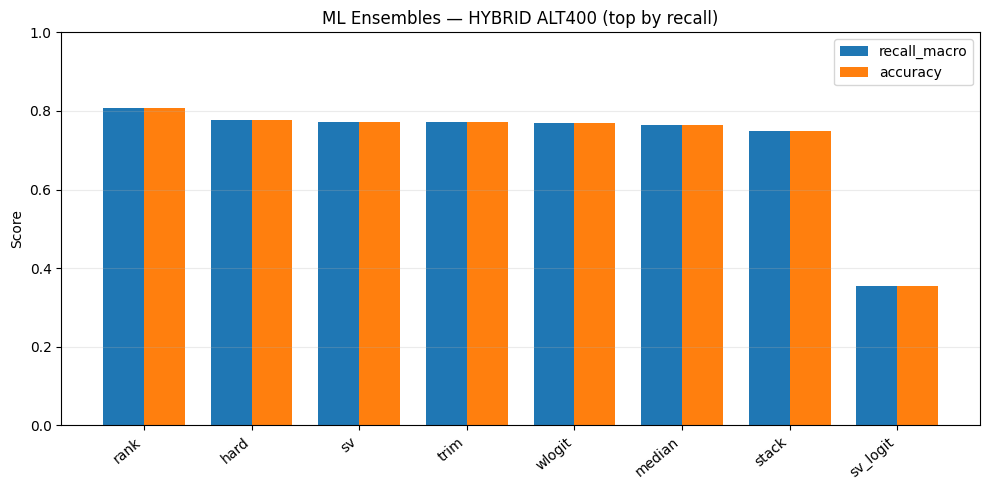

📈 Saved: results\finalensembleformlonly\RUN_20251011_051527\plot_HYBRID_ALT400_bars.png


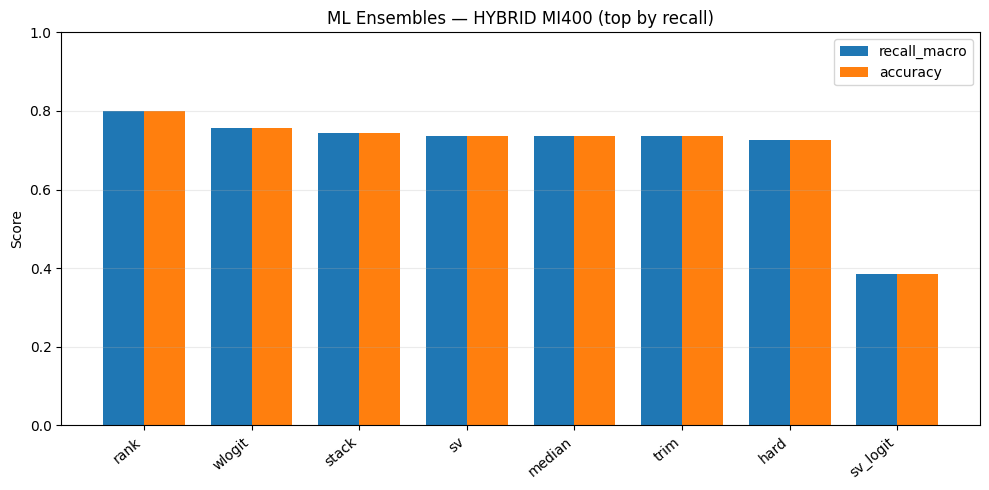

📈 Saved: results\finalensembleformlonly\RUN_20251011_051527\plot_HYBRID_MI400_bars.png


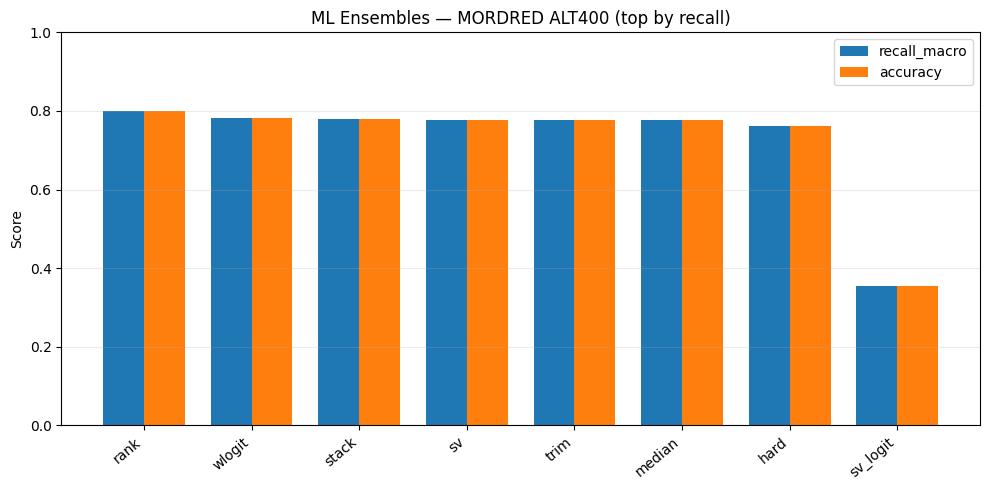

📈 Saved: results\finalensembleformlonly\RUN_20251011_051527\plot_MORDRED_ALT400_bars.png


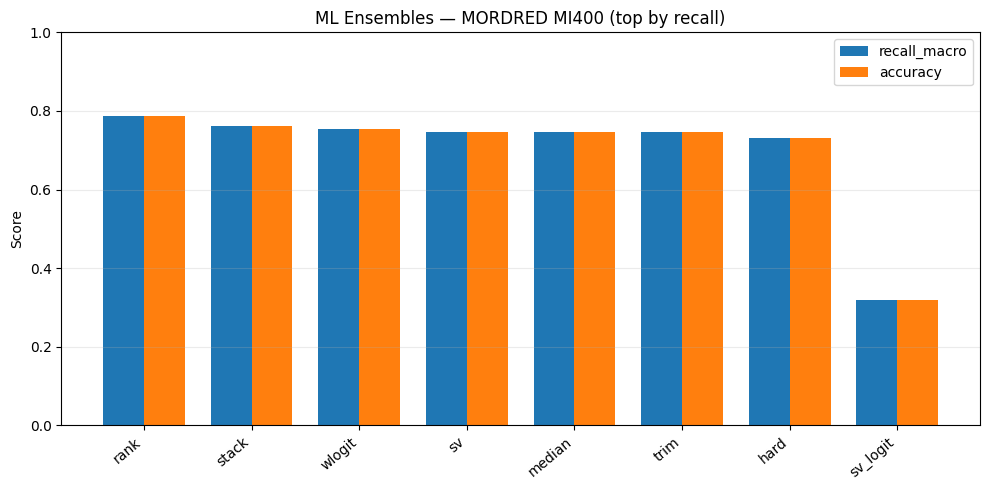

📈 Saved: results\finalensembleformlonly\RUN_20251011_051527\plot_MORDRED_MI400_bars.png


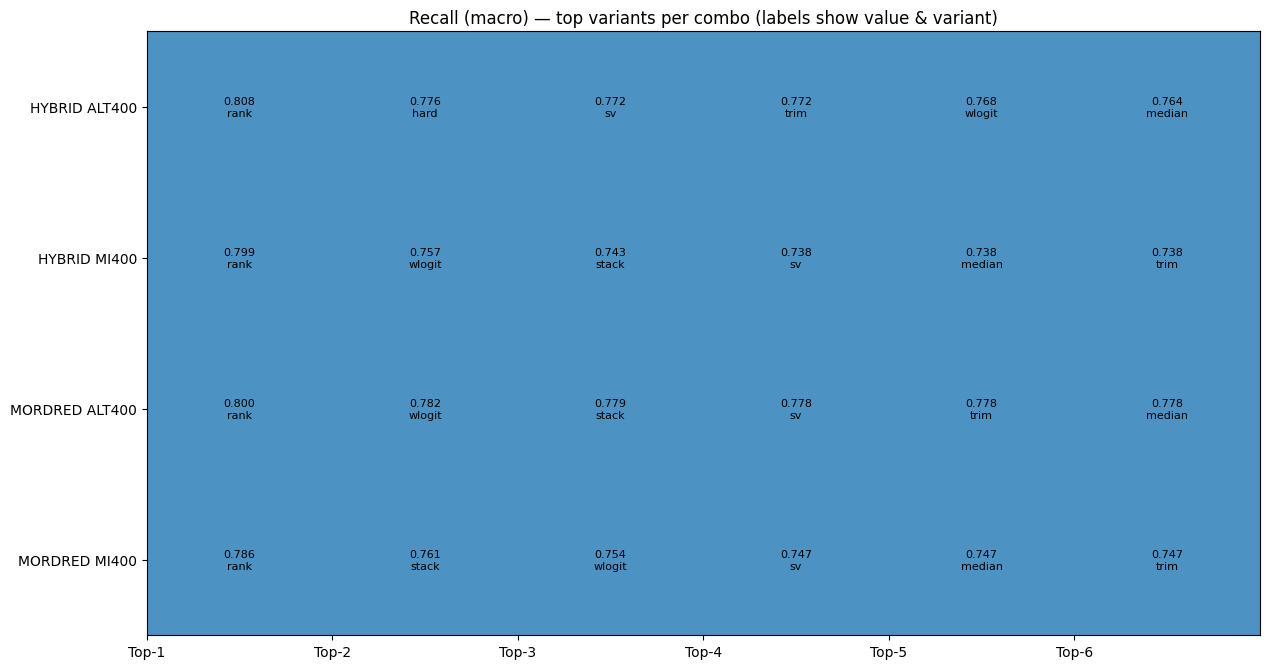

📈 Saved: results\finalensembleformlonly\RUN_20251011_051527\overview_recall_top6.png


In [19]:
# === PLOTS FOR ML-ONLY ENSEMBLES (mirrors the DL plot style) ===
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import textwrap

BASE = Path("results/finalensembleformlonly")
runs = sorted([p for p in BASE.iterdir() if p.is_dir() and p.name.startswith("RUN_")])
assert runs, f"No RUN_* folders under {BASE.resolve()}"
RUN_DIR = runs[-1]
summary_csv = RUN_DIR / "summary.csv"
df = pd.read_csv(summary_csv)

# Normalize/shorten variant labels for readability on plots
def short_variant(v):
    # keep it readable but short
    v = v.replace("soft_vote_equal_logit_", "sv_logit_")
    v = v.replace("soft_vote_equal_", "sv_")
    v = v.replace("weighted_logit_", "wlogit_")
    v = v.replace("median_vote_", "median_")
    v = v.replace("trimmed_mean_", "trim_")
    v = v.replace("rank_average_", "rank_")
    v = v.replace("hard_vote_", "hard_")
    v = v.replace("stacking_strong_", "stack_")
    v = v.replace("_ml_all", "")
    return v

df["VariantShort"] = df["Variant"].apply(short_variant)

# Order variants by recall_macro within each combo
df["_order"] = df.groupby(["Dataset","Track"])["recall_macro"].rank(ascending=False, method="first")

# Make a figure per combo
combos = df.groupby(["Dataset","Track"])
for (ds, tr), g in combos:
    g = g.sort_values(by=["recall_macro","accuracy","roc_auc"], ascending=False).reset_index(drop=True)
    labels = [textwrap.shorten(v, width=28, placeholder="…") for v in g["VariantShort"]]
    x = np.arange(len(g))

    fig = plt.figure(figsize=(10, 5))
    # Bar chart: recall + accuracy side-by-side
    w = 0.38
    plt.bar(x - w/2, g["recall_macro"].values, width=w, label="recall_macro")
    plt.bar(x + w/2, g["accuracy"].values,      width=w, label="accuracy")

    plt.xticks(x, labels, rotation=40, ha="right")
    plt.ylim(0, 1.0)
    plt.ylabel("Score")
    plt.title(f"ML Ensembles — {ds} {tr} (top by recall)")
    plt.grid(axis="y", alpha=0.25)
    plt.legend(loc="best")

    out_png = RUN_DIR / f"plot_{ds}_{tr}_bars.png"
    plt.tight_layout()
    plt.savefig(out_png, dpi=160)
    plt.show()
    print("📈 Saved:", out_png)

# Optional: overview heatmap-style (as a grid of rectangles)
# Rows = (Dataset,Track), Cols = top-N variants per combo
topN = 6
rows = sorted(df.groupby(["Dataset","Track"]).size().index.tolist())
variants_by_row = []
for r in rows:
    g = df[(df["Dataset"]==r[0]) & (df["Track"]==r[1])].sort_values(
        by=["recall_macro","accuracy","roc_auc"], ascending=False
    ).head(topN)
    variants_by_row.append(g)

# Build a grid for recall_macro
fig = plt.figure(figsize=(1.8*topN+2, 1.2*len(rows)+2))
ax = plt.gca()
ax.set_axisbelow(True)

# Normalize colors by metric value (0..1)
for i, (r, g) in enumerate(zip(rows, variants_by_row)):
    for j, (_, row) in enumerate(g.iterrows()):
        val = float(row["recall_macro"])
        # color via a simple grayscale (default colormap not used to keep code minimal)
        ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True, alpha=0.8))
        # overlay text with value
        ax.text(j+0.5, i+0.5, f"{val:.3f}\n{short_variant(row['Variant'])}",
                ha="center", va="center", fontsize=8)
# Axes cosmetics
ax.set_xlim(0, topN)
ax.set_ylim(0, len(rows))
ax.set_xticks(range(topN))
ax.set_xticklabels([f"Top-{k+1}" for k in range(topN)], rotation=0)
ax.set_yticks([i+0.5 for i in range(len(rows))])
ax.set_yticklabels([f"{r[0]} {r[1]}" for r in rows])
ax.invert_yaxis()
ax.set_title("Recall (macro) — top variants per combo (labels show value & variant)")

out_png = RUN_DIR / f"overview_recall_top{topN}.png"
plt.tight_layout()
plt.savefig(out_png, dpi=160)
plt.show()
print("📈 Saved:", out_png)


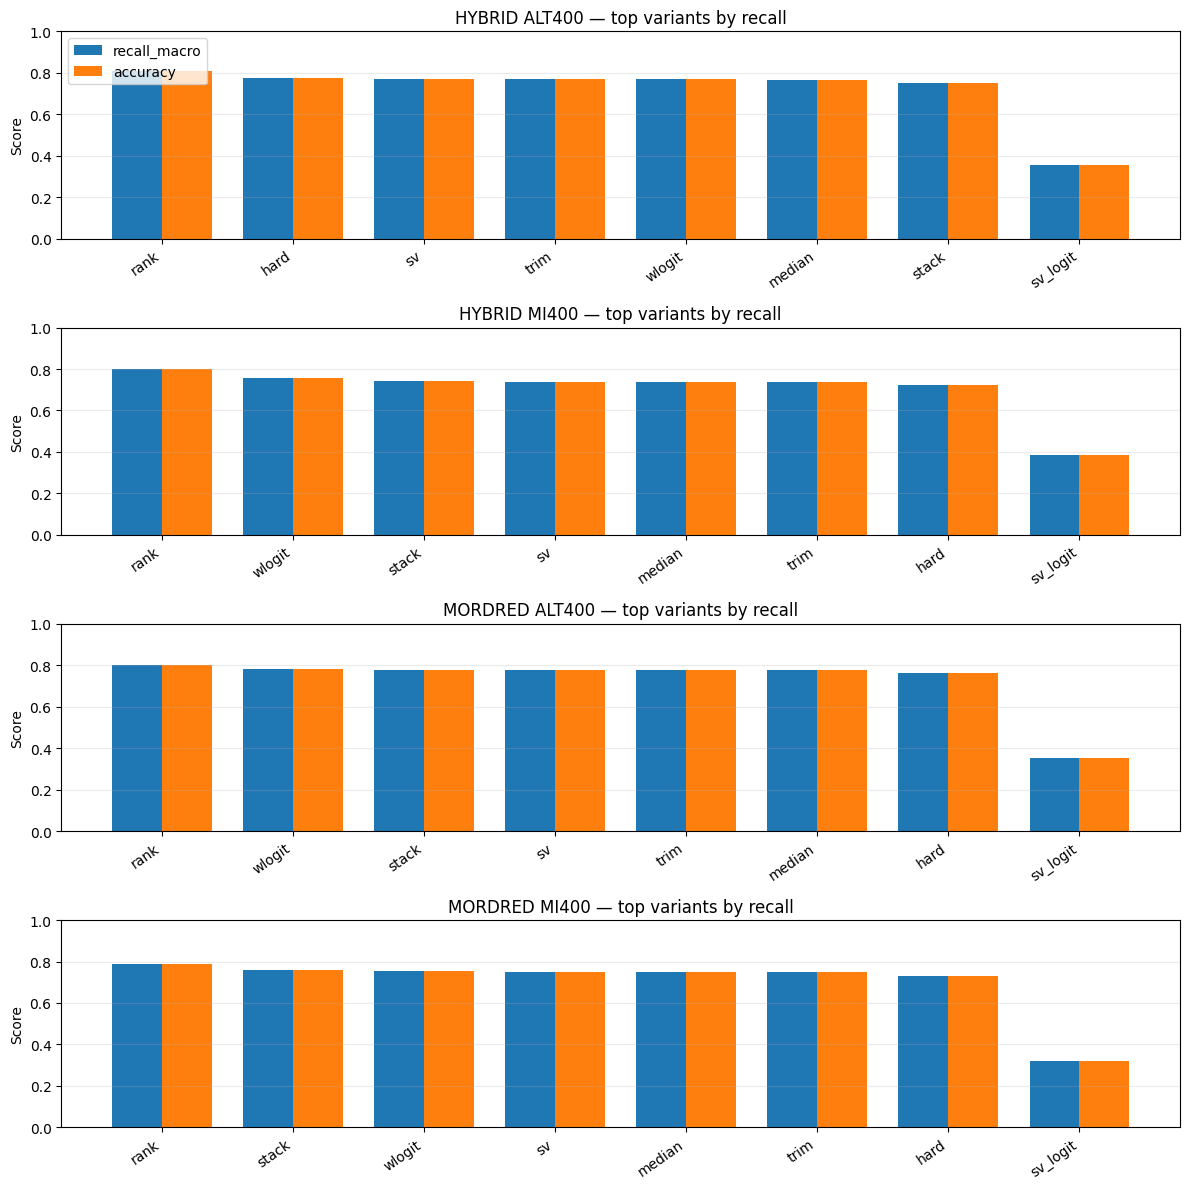

✅ Saved three files:
 - results\finalensembleformlonly\RUN_20251011_051527\MLONLYENSEMBLERESULTSANDGRAPH\mlonlyensembleresultstable.csv
 - results\finalensembleformlonly\RUN_20251011_051527\MLONLYENSEMBLERESULTSANDGRAPH\mlonlyensemblegraph.png
 - results\finalensembleformlonly\RUN_20251011_051527\MLONLYENSEMBLERESULTSANDGRAPH\mlonlyensemblegraph.pdf


In [21]:
# === FINAL EXPORTS WITHOUT XLSXWRITER: CSV table + PNG & PDF graphs ===
import pandas as pd, numpy as np, matplotlib.pyplot as plt, textwrap
from pathlib import Path

BASE = Path("results/finalensembleformlonly")
runs = sorted([p for p in BASE.iterdir() if p.is_dir() and p.name.startswith("RUN_")])
assert runs, f"No RUN_* folders under {BASE.resolve()}"
RUN_DIR = runs[-1]

summary_csv = RUN_DIR / "summary.csv"
assert summary_csv.exists(), f"Missing {summary_csv}"

# Load + sort leaderboard
df = pd.read_csv(summary_csv)
df_sorted = df.sort_values(
    by=["recall_macro","accuracy","roc_auc"], ascending=False
).reset_index(drop=True)

# === 1) TABLE -> CSV ===
out_dir = RUN_DIR / "MLONLYENSEMBLERESULTSANDGRAPH"
out_dir.mkdir(parents=True, exist_ok=True)
table_path = out_dir / "mlonlyensembleresultstable.csv"
df_sorted.to_csv(table_path, index=False)

# === 2) SINGLE COMBINED GRAPH -> PNG & PDF ===
def short_variant(v: str) -> str:
    v = v.replace("soft_vote_equal_logit_", "sv_logit_")
    v = v.replace("soft_vote_equal_", "sv_")
    v = v.replace("weighted_logit_", "wlogit_")
    v = v.replace("median_vote_", "median_")
    v = v.replace("trimmed_mean_", "trim_")
    v = v.replace("rank_average_", "rank_")
    v = v.replace("hard_vote_", "hard_")
    v = v.replace("stacking_strong_", "stack_")
    v = v.replace("_ml_all", "")
    return v

df_sorted["VariantShort"] = df_sorted["Variant"].apply(short_variant)

combos = sorted(df_sorted.groupby(["Dataset","Track"]).size().index.tolist())
rows, cols = len(combos), 1
fig_h = max(3.0*rows, 6)
fig_w = 12
fig, axes = plt.subplots(rows, cols, figsize=(fig_w, fig_h), squeeze=False)

for idx, (ds, tr) in enumerate(combos):
    ax = axes[idx, 0]
    g = df_sorted[(df_sorted["Dataset"]==ds) & (df_sorted["Track"]==tr)].copy()

    topN = min(10, len(g))           # show top-10 per combo for readability
    g = g.head(topN)
    labels = [textwrap.shorten(v, width=28, placeholder="…") for v in g["VariantShort"]]
    x = np.arange(len(g)); w = 0.38

    ax.bar(x - w/2, g["recall_macro"].values, width=w, label="recall_macro")
    ax.bar(x + w/2, g["accuracy"].values,      width=w, label="accuracy")
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=35, ha="right")
    ax.set_ylim(0, 1.0)
    ax.set_ylabel("Score")
    ax.set_title(f"{ds} {tr} — top variants by recall")
    ax.grid(axis="y", alpha=0.25)
    if idx == 0:
        ax.legend(loc="upper left")

plt.tight_layout()

graph_png = out_dir / "mlonlyensemblegraph.png"
graph_pdf = out_dir / "mlonlyensemblegraph.pdf"
plt.savefig(graph_png, dpi=180, bbox_inches="tight")
plt.savefig(graph_pdf, bbox_inches="tight")
plt.show()

print("✅ Saved three files:")
print(" -", table_path)
print(" -", graph_png)
print(" -", graph_pdf)


In [29]:
# === ML-ONLY ENSEMBLES: leaderboard + members (with preprocess tag), no legend ===
import json, textwrap
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# ---------- Locate latest RUN ----------
BASE = Path("results/finalensembleformlonly")
runs = sorted([p for p in BASE.iterdir() if p.is_dir() and p.name.startswith("RUN_")])
assert runs, f"No RUN_* folders under {BASE.resolve()}"
RUN_DIR = runs[-1]
print("Using:", RUN_DIR)

summary_csv = RUN_DIR / "summary.csv"
assert summary_csv.exists(), f"Missing {summary_csv}"

# ---------- Load + sort ----------
df = pd.read_csv(summary_csv)
df_sorted = df.sort_values(by=["recall_macro","accuracy","roc_auc"], ascending=False).reset_index(drop=True)

# ---------- Leaderboard view (ID + wrapped text; drop pos_rate, mean_prob) ----------
keep_cols = ["Dataset","Track","Variant","accuracy","recall_macro","precision_macro","f1_macro","roc_auc","pr_auc"]
have = [c for c in keep_cols if c in df_sorted.columns]
leader = df_sorted[have].copy()
leader.insert(0, "ID", np.arange(1, len(leader)+1))

# format numeric cols
for c in ["accuracy","recall_macro","precision_macro","f1_macro","roc_auc","pr_auc"]:
    if c in leader.columns:
        leader[c] = leader[c].map(lambda x: f"{x:.4f}")

wrap = lambda s,w: textwrap.fill(str(s), width=w, break_long_words=False, break_on_hyphens=False)
leader["Variant"] = leader["Variant"].map(lambda s: wrap(s, 30))

# ---- DISPLAY-ONLY column rename ----
display_leader = leader.rename(columns={
    "recall_macro": "recall",
    "precision_macro": "precision",
    "f1_macro": "f1_macro"
})

# ---------- Members table (read from each variant's config.json) ----------
rows = []
for idx, r in df_sorted.iterrows():
    ds, tr, variant = r["Dataset"], r["Track"], r["Variant"]
    cfgp = RUN_DIR / f"{ds}_{tr}" / variant / "config.json"
    members = None
    if cfgp.exists():
        try:
            cfg = json.loads(cfgp.read_text())
            if isinstance(cfg.get("members"), (list, tuple)):
                members = list(map(str, cfg["members"]))
            elif isinstance(cfg.get("weights"), dict):
                members = list(map(str, cfg["weights"].keys()))
        except Exception:
            pass
    # add preprocess tag to each member
    if members:
        members = [f"{m}_{tr}" for m in members]

    rows.append({
        "ID": idx+1,
        "Dataset": ds,
        "Track": tr,
        "Variant": variant,
        "Models used": ", ".join(members) if members else "(not recorded)"
    })

members = pd.DataFrame(rows)
members["Variant"] = members["Variant"].map(lambda s: wrap(s, 30))
members["Models used"] = members["Models used"].map(lambda s: wrap(s, 95))

# ---------- PDF writer ----------
out_dir = RUN_DIR / "MLONLYENSEMBLERESULTSANDGRAPH"
out_dir.mkdir(parents=True, exist_ok=True)
pdf_path = out_dir / "mlonlyensemble_tables_fixed.pdf"

def render_table_pdf(df_table, title, pdf, note=None, col_widths=None,
                     font_size=10.0, header_font_size=10.8, page_size=(14, 9)):  # bigger page
    fig = plt.figure(figsize=page_size)
    ax = fig.add_subplot(111)
    ax.axis("off")
    ax.set_title(title, fontsize=15, pad=12)

    # Default column width heuristic
    if col_widths is None:
        widths = []
        for c in df_table.columns:
            if c in ("Variant",): widths.append(0.36)
            elif c in ("Models used",): widths.append(0.58)
            elif c in ("Dataset","Track"): widths.append(0.10)
            elif c in ("ID",): widths.append(0.06)
            else: widths.append(0.10)
        s = sum(widths)
        col_widths = [w/s for w in widths]

    table = ax.table(cellText=df_table.values,
                     colLabels=df_table.columns.tolist(),
                     loc="center", cellLoc="center",
                     colWidths=col_widths)
    table.auto_set_font_size(False)
    table.set_fontsize(font_size)
    table.scale(1.0, 1.40)

    # Style header
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight="bold", fontsize=header_font_size)
            cell.set_height(cell.get_height() * 1.12)

    if note:
        plt.figtext(0.5, 0.02, note, ha="center", fontsize=9)

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

with PdfPages(pdf_path) as pdf:
    # Leaderboard pages
    ROWS_PER_PAGE = 16
    n = len(display_leader)
    pages = (n + ROWS_PER_PAGE - 1) // ROWS_PER_PAGE or 1
    for p in range(pages):
        chunk = display_leader.iloc[p*ROWS_PER_PAGE : min((p+1)*ROWS_PER_PAGE, n)]
        render_table_pdf(
            chunk,
            title=f"ML-Only Ensembles — Leaderboard (Page {p+1}/{pages}) • {RUN_DIR.name}",
            pdf=pdf,
            note="Sorted by recall, accuracy, roc_auc (desc). Values are test-set metrics."
        )

    # Members (with preprocess tag)
    ROWS_PER_PAGE_MEM = 14
    n2 = len(members)
    pages2 = (n2 + ROWS_PER_PAGE_MEM - 1) // ROWS_PER_PAGE_MEM or 1
    for p in range(pages2):
        chunk = members.iloc[p*ROWS_PER_PAGE_MEM : min((p+1)*ROWS_PER_PAGE_MEM, n2)]
        render_table_pdf(
            chunk,
            title=f"ML-Only Ensembles — Models Used by Variant (Page {p+1}/{pages2}) • {RUN_DIR.name}",
            pdf=pdf,
            note="Members listed as Algo_TRACK to show preprocessing (e.g., _ALT400/_MI400).",
            font_size=9.8, header_font_size=10.6
        )

print("✅ Wrote:", pdf_path)
print("Open:", str(pdf_path))


Using: results\finalensembleformlonly\RUN_20251011_051527
✅ Wrote: results\finalensembleformlonly\RUN_20251011_051527\MLONLYENSEMBLERESULTSANDGRAPH\mlonlyensemble_tables_fixed.pdf
Open: results\finalensembleformlonly\RUN_20251011_051527\MLONLYENSEMBLERESULTSANDGRAPH\mlonlyensemble_tables_fixed.pdf


In [25]:
# === ML-only ensembles — Full table CSV/PDF sorted by Recall (desc) + Top-12 PNG ===
import pandas as pd, numpy as np, matplotlib.pyplot as plt, textwrap
from matplotlib.backends.backend_pdf import PdfPages
from pathlib import Path

# ---------- Locate latest run & load ----------
BASE = Path("results/finalensembleformlonly")
runs = sorted([p for p in BASE.iterdir() if p.is_dir() and p.name.startswith("RUN_")])
assert runs, f"No RUN_* folders under {BASE.resolve()}"
RUN_DIR = runs[-1]

summary_csv = RUN_DIR / "summary.csv"
assert summary_csv.exists(), f"Missing {summary_csv}"

df = pd.read_csv(summary_csv).copy()

# ---------- Normalize names (idempotent) ----------
df = df.rename(columns={
    "dataset":"Dataset", "track":"Track",
    "recall":"recall_macro",
    "precision":"precision_macro",
    "F1-macro":"f1_macro",
    "ROC-AUC":"roc_auc",
    "PR-AUC":"pr_auc",
})

# Keep only relevant columns (drop diagnostics if present)
metric_all = ["accuracy","recall_macro","precision_macro","f1_macro","roc_auc","pr_auc"]
present_metrics = [m for m in metric_all if m in df.columns]

core_cols = ["Dataset","Track","Variant"] + present_metrics
drop_cols = {"pos_rate","mean_prob","thr"}
maybe_cols = [c for c in df.columns if c not in core_cols and c not in drop_cols]
keep_cols = [c for c in core_cols + maybe_cols if c in df.columns]
df = df[keep_cols].copy()

# Map MORDRED -> 2D for table
DS_DISPLAY = {"MORDRED":"2D", "HYBRID":"HYBRID"}
df["Dataset"] = df["Dataset"].astype(str).str.upper().map(lambda x: DS_DISPLAY.get(x, x))
df["Track"]   = df["Track"].astype(str).str.upper()

# Ensure numeric metrics
for m in present_metrics:
    df[m] = pd.to_numeric(df[m], errors="coerce")

# ---------- Short variant names ----------
def short_variant(v: str) -> str:
    v = str(v)
    v = v.replace("soft_vote_equal_logit_", "sv_logit_")
    v = v.replace("soft_vote_equal_", "sv_")
    v = v.replace("weighted_logit_", "wlogit_")
    v = v.replace("median_vote_", "median_")
    v = v.replace("trimmed_mean_", "trim_")
    v = v.replace("rank_average_", "rank_")
    v = v.replace("hard_vote_", "hard_")
    v = v.replace("stacking_strong_", "stack_")
    v = v.replace("_ml_all", "")
    return v

df["VariantShort"] = df["Variant"].map(short_variant)

# ---------- Outputs dir ----------
out_dir = RUN_DIR / "MLONLYENSEMBLERESULTSANDGRAPH"
out_dir.mkdir(parents=True, exist_ok=True)

# ---------- TABLE CSV (sorted by Recall desc) ----------
df_csv = df.copy()
# Sort by recall only (desc); use ACC and ROC-AUC to break ties if present
rank_keys = [c for c in ["recall_macro","accuracy","roc_auc"] if c in df_csv.columns]
ascending = [False] + [False]*(len(rank_keys)-1)
df_csv = df_csv.sort_values(rank_keys, ascending=ascending).reset_index(drop=True)

full_table_csv = out_dir / "mlonly_ensembles_full_table.csv"
for m in present_metrics:
    df_csv[m] = pd.to_numeric(df_csv[m], errors="coerce").round(6)
df_csv.to_csv(full_table_csv, index=False)

# ---------- TABLE PDF (same order: Recall desc) ----------
table_cols = ["Dataset","Track","VariantShort"] + present_metrics
table_cols = [c for c in table_cols if c in df.columns]
df_pdf = df_csv[table_cols].copy()  # keep recall-sorted order

pretty = {
    "accuracy":"ACC",
    "recall_macro":"Recall",
    "precision_macro":"Precision",
    "f1_macro":"F1-macro",
    "roc_auc":"ROC-AUC",
    "pr_auc":"PR-AUC",
    "VariantShort":"Variant",
}
df_pdf = df_pdf.rename(columns=pretty)
for c in ["ACC","Recall","Precision","F1-macro","ROC-AUC","PR-AUC"]:
    if c in df_pdf.columns:
        df_pdf[c] = pd.to_numeric(df_pdf[c], errors="coerce").round(3)

table_pdf_path = out_dir / "mlonly_ensembles_full_table.pdf"
ROWS_PER_PAGE = 32
with PdfPages(table_pdf_path) as pdf:
    n = len(df_pdf)
    pages = max(1, (n + ROWS_PER_PAGE - 1) // ROWS_PER_PAGE)
    for p in range(pages):
        chunk = df_pdf.iloc[p*ROWS_PER_PAGE : min((p+1)*ROWS_PER_PAGE, n)]
        rows = len(chunk)
        fig_h = min(1.0 + 0.35*rows, 14)
        fig, ax = plt.subplots(figsize=(14, fig_h))
        ax.axis("off")
        ax.set_title(f"ML Ensembles — Full Metrics (Recall-sorted)  Page {p+1}/{pages}",
                     fontsize=14, pad=12)
        tbl = ax.table(cellText=chunk.values,
                       colLabels=chunk.columns.tolist(),
                       loc="center", cellLoc="center")
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(9)
        tbl.scale(1.0, 1.22)
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

# ---------- Top-12 overall PNG (unchanged) ----------
df_rank = df.dropna(subset=[k for k in ["recall_macro","accuracy","roc_auc"] if k in df.columns], how="any").copy()
df_rank = df_rank[np.isfinite(df_rank[[k for k in ["recall_macro","accuracy","roc_auc"] if k in df_rank.columns]]).all(axis=1)]
topk = (df_rank.sort_values([k for k in ["recall_macro","accuracy","roc_auc"] if k in df_rank.columns], ascending=False)
               .head(12).reset_index(drop=True))

def axis_label(row, max_len=28):
    lab = f"{row['Dataset']}/{row['Track']}: {row['VariantShort']}"
    return lab if len(lab) <= max_len else (lab[:max_len-1] + "…")

topk["Axis"] = topk.apply(axis_label, axis=1)

labels = topk["Axis"].tolist()
xs = np.arange(len(topk))
cm = plt.get_cmap("tab20")
colors = [cm(i % 20) for i in range(len(topk))]

pretty_y = pretty
metrics_to_plot = [m for m in ["accuracy","recall_macro","precision_macro","f1_macro","roc_auc","pr_auc"] if m in topk.columns]

fig_h = 1.75 * max(4, len(metrics_to_plot))
fig_w = max(12, 0.9 * len(topk))
fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(fig_w, fig_h), sharex=True)
if len(metrics_to_plot) == 1:
    axes = [axes]

for ax, m in zip(axes, metrics_to_plot):
    vals = topk[m].values.astype(float)
    bars = ax.bar(xs, vals, edgecolor="black", linewidth=0.4, color=colors)
    for rect, val in zip(bars, vals):
        ax.text(rect.get_x()+rect.get_width()/2, val+0.005, f"{val:.3f}",
                ha="center", va="bottom", fontsize=9)
    ax.set_ylim(0, 1.03)
    ax.set_ylabel(pretty_y.get(m, m), fontsize=11)

axes[0].set_title("ML Ensembles — Top 12 Overall (rank: recall → ACC → ROC-AUC)",
                  fontsize=16, pad=8)
axes[-1].set_xticks(xs)
axes[-1].set_xticklabels(labels, rotation=35, ha="right", fontsize=10)

fig.tight_layout()
graph_png = out_dir / "mlonly_ensembles_top12_overall.png"
fig.savefig(graph_png, dpi=180, bbox_inches="tight")
plt.close(fig)

print("✅ Saved:")
print(" -", full_table_csv)
print(" -", table_pdf_path)
print(" -", graph_png)


✅ Saved:
 - results\finalensembleformlonly\RUN_20251011_061148\MLONLYENSEMBLERESULTSANDGRAPH\mlonly_ensembles_full_table.csv
 - results\finalensembleformlonly\RUN_20251011_061148\MLONLYENSEMBLERESULTSANDGRAPH\mlonly_ensembles_full_table.pdf
 - results\finalensembleformlonly\RUN_20251011_061148\MLONLYENSEMBLERESULTSANDGRAPH\mlonly_ensembles_top12_overall.png


In [11]:
# ======================================================================
# FINAL DL-ONLY ENSEMBLING (no leakage) — strong stacker + robust variants
# Outputs go to: results/finalensemblefordlonly/<RUN_ID>/
# ======================================================================

import os, json, time, logging, numpy as np, pandas as pd
from pathlib import Path
from datetime import datetime, timedelta

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, average_precision_score, roc_curve
)
from sklearn.model_selection import KFold

# Optional meta stackers
try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except Exception:
    HAS_LGBM = False

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

# ----------------------- CONFIG -----------------------
TOPKS = [None]            # None == use ALL (we dedup K anyway). You can add [3,5,9] if you want.
WEIGHT_TRIALS = 1800      # Dirichlet iterations for soft_vote_weighted
WEIGHT_LOG_EVERY = 300
KF_SPLITS = 5
RANDOM_STATE = 42

USE_ISOTONIC = True       # "isotonic" (recommended) or "platt"
USE_META_FEATURES = True  # richer per-sample stats for the stacker

SKIP_IF_EXISTS = False
STREAM_TIMINGS = True
WRITE_PARTIAL_SUMMARY = True

# ----------- input registry -----------
REG = Path(r"results\ensemble\registries\all_models_registry.csv")
assert REG.exists(), f"Missing registry: {REG}"
reg = pd.read_csv(REG)

# ----------- output base (unique run folder) -----------
RUN_ID = datetime.now().strftime("RUN_%Y%m%d_%H%M%S")
ENSEMBLE_BASE = Path(r"results\finalensemblefordlonly") / RUN_ID
ENSEMBLE_BASE.mkdir(parents=True, exist_ok=True)

# ----------- logging -----------
LOG_FILE = ENSEMBLE_BASE / "run.log"
TIMINGS_CSV = ENSEMBLE_BASE / "variant_timings.csv"

logger = logging.getLogger(f"final_dlonly_{RUN_ID}")
logger.setLevel(logging.INFO)
logger.handlers.clear()
fmt = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s", "%Y-%m-%d %H:%M:%S")
fh = logging.FileHandler(LOG_FILE, mode="a", encoding="utf-8"); fh.setFormatter(fmt); logger.addHandler(fh)
ch = logging.StreamHandler(); ch.setFormatter(fmt); logger.addHandler(ch)
def log(msg): logger.info(msg)

RUNCFG = {
    "run_id": RUN_ID,
    "started_at": datetime.now().isoformat(timespec="seconds"),
    "topks": TOPKS,
    "weight_trials": WEIGHT_TRIALS,
    "weight_log_every": WEIGHT_LOG_EVERY,
    "stacking_cv_folds": KF_SPLITS,
    "random_state": RANDOM_STATE,
    "skip_if_exists": SKIP_IF_EXISTS,
    "output_base": str(ENSEMBLE_BASE),
    "mode": "DL_ONLY_STRONG",
    "calibration": "isotonic" if USE_ISOTONIC else "platt",
    "use_meta_features": USE_META_FEATURES,
    "has_lgbm": bool(HAS_LGBM),
    "has_xgb": bool(HAS_XGB),
}
(ENSEMBLE_BASE / "RUN_CONFIG.json").write_text(json.dumps(RUNCFG, indent=2))
log(f"Run ID: {RUN_ID}")
log(f"Writing all outputs to: {ENSEMBLE_BASE}")

# ----------- refresh/existence flags -----------
def _exists(p):
    try: return Path(str(p)).exists()
    except: return False

for col, fn in [
    ("test_pred_exists", lambda r: _exists(r["test_pred_path"])),
    ("oof_probs_exists", lambda r: Path(str(r["results_dir"])).joinpath("oof_probs.npy").exists()),
    ("oof_y_exists",     lambda r: Path(str(r["results_dir"])).joinpath("oof_y.npy").exists()),
]:
    if col not in reg.columns:
        reg[col] = reg.apply(fn, axis=1)

# ----------- raw test label locations (your mapping) -----------
RAW_TEST = {
    ("MORDRED","ALT400"): r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\ic50_test_mordred.csv",
    ("MORDRED","MI400"):  r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\ic50_test_mordred.csv",
    ("HYBRID","ALT400"):  r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\test_hybrid.csv",
    ("HYBRID","MI400"):   r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\test_hybrid.csv",
}
def detect_label(df: pd.DataFrame):
    for c in df.columns:
        if c.lower() in {"cls","class","label","active","activity","y","target"}:
            return c
    return None

def get_y_test(dataset, track, n_expected=None):
    path = RAW_TEST[(dataset, track)]
    df = pd.read_csv(path)
    tgt = detect_label(df)
    assert tgt is not None, f"No label column found in {path}"
    y = df[tgt].astype(int).values
    if n_expected is not None and len(y) != n_expected:
        raise RuntimeError(f"Length mismatch: y_test={len(y)} vs preds={n_expected}")
    return y, path

# ----------- calibration utils -----------
def platt_fit(y_true, p_raw):
    eps = 1e-6
    z = np.log(np.clip(p_raw, eps, 1-eps) / np.clip(1-p_raw, eps, 1-eps)).reshape(-1,1)
    lr = LogisticRegression(C=1.0, solver="lbfgs", max_iter=1000, random_state=RANDOM_STATE)
    lr.fit(z, y_true.astype(int))
    return lr
def platt_apply(lr, p_raw):
    eps = 1e-6
    z = np.log(np.clip(p_raw, eps, 1-eps) / np.clip(1-p_raw, eps, 1-eps)).reshape(-1,1)
    return lr.predict_proba(z)[:,1]
def fit_calibrator(y_true, p_raw, method="isotonic"):
    if method == "isotonic":
        from sklearn.isotonic import IsotonicRegression
        ir = IsotonicRegression(out_of_bounds="clip")
        ir.fit(p_raw, y_true.astype(int))
        return ("isotonic", ir)
    else:
        return ("platt", platt_fit(y_true, p_raw))
def apply_calibrator(cal, p_raw):
    kind, obj = cal
    if kind=="isotonic":
        return obj.predict(p_raw)
    return platt_apply(obj, p_raw)

# ----------- thresholds & metrics -----------
def compute_metrics(y_true, p_prob, thr):
    y_hat = (p_prob >= thr).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_hat),
        "recall_macro": recall_score(y_true, y_hat, average="macro", zero_division=0),
        "precision_macro": precision_score(y_true, y_hat, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_hat, average="macro", zero_division=0),
        "roc_auc": roc_auc_score(y_true, p_prob),
        "pr_auc": average_precision_score(y_true, p_prob),
        "pos_rate": float(y_hat.mean()),
        "mean_prob": float(np.mean(p_prob)),
    }
def best_threshold_for_recall(y, p):
    fpr, tpr, thr = roc_curve(y, p)
    j = tpr - fpr
    idx = int(np.nanargmax(j))
    t = thr[idx]
    if not np.isfinite(t): t = 0.5
    return float(t)
def best_threshold_for_metric(y, p, metric="accuracy"):
    fpr, tpr, thr = roc_curve(y, p)
    cand = list(thr) + [0.0, 1.0]
    best, best_t = -1.0, 0.5
    for T in cand:
        yhat = (p >= T).astype(int)
        if metric == "accuracy":
            score = (yhat == y).mean()
        elif metric == "f1":
            score = f1_score(y, yhat, average="macro", zero_division=0)
        elif metric == "recall":
            tpr_ = (yhat[y==1]==1).mean() if (y==1).any() else 0.0
            tnr_ = (yhat[y==0]==0).mean() if (y==0).any() else 0.0
            score = 0.5*(tpr_+tnr_)
        else:
            score = (yhat == y).mean()
        if score > best:
            best, best_t = score, float(T)
    return best_t

# ----------- rank averaging -----------
def rank_average(probs_list):
    ranks = [pd.Series(p).rank(method="average").to_numpy() for p in probs_list]
    r = np.mean(np.stack(ranks, axis=0), axis=0)
    return (r - r.min()) / (r.max() - r.min() + 1e-9)

# ----------- meta features for stacker -----------
def _entropy(p):
    eps = 1e-6
    pp = np.clip(p, eps, 1 - eps)
    return -(pp * np.log(pp) + (1 - pp) * np.log(1 - pp))
def build_meta_features(P_sel, thr_indiv_map, sel_names):
    """
    P_sel: (M models, N samples) calibrated probs
    Returns X with shape (N, D)
    """
    probs = P_sel.T  # (N, M)
    N, M = probs.shape
    mean_p = probs.mean(axis=1)
    med_p  = np.median(probs, axis=1)
    max_p  = probs.max(axis=1)
    min_p  = probs.min(axis=1)
    std_p  = probs.std(axis=1)
    q75 = np.percentile(probs, 75, axis=1)
    q25 = np.percentile(probs, 25, axis=1)
    iqr_p = q75 - q25
    ent_p  = _entropy(mean_p)

    thr_vec = np.array([thr_indiv_map[n] for n in sel_names], dtype=float)
    votes   = (probs >= thr_vec[None, :]).astype(int)
    vote_mean = votes.mean(axis=1)
    vote_min  = votes.min(axis=1)
    vote_max  = votes.max(axis=1)
    disagree  = (votes.sum(axis=1) * (M - votes.sum(axis=1))) / (M*M/4 + 1e-9)

    spread_mean = (probs - mean_p[:, None]).mean(axis=1)
    spread_abs  = np.abs(probs - mean_p[:, None]).mean(axis=1)

    cols = [
        mean_p, med_p, max_p, min_p, std_p, iqr_p, ent_p,
        vote_mean, vote_min, vote_max, disagree,
        spread_mean, spread_abs
    ]
    X = np.vstack(cols).T
    X = np.hstack([X, probs])  # append raw probs
    return X

# ----------- IO helpers -----------
def load_oof_for_rows(rows):
    per_model, y = {}, None
    for _, r in rows.iterrows():
        res = Path(r["results_dir"])
        p = np.load(res/"oof_probs.npy")
        p = p.mean(axis=0) if p.ndim==2 else p
        per_model[r["Algo"]] = p
        if y is None:
            y = np.load(res/"oof_y.npy").astype(int)
    names, Pcal, thr_indiv, indrec, cal_models = [], [], {}, {}, {}
    cal_kind = "isotonic" if USE_ISOTONIC else "platt"
    for algo, p_raw in per_model.items():
        cal = fit_calibrator(y, p_raw, method=cal_kind)
        pcal = apply_calibrator(cal, p_raw)
        thr = best_threshold_for_recall(y, pcal)
        yhat = (pcal >= thr).astype(int)
        rec = recall_score(y, yhat, average="macro", zero_division=0)
        names.append(algo); Pcal.append(pcal)
        thr_indiv[algo] = float(thr)
        indrec[algo] = float(rec)
        cal_models[algo] = cal
    return names, np.vstack(Pcal), thr_indiv, indrec, y, cal_models

def load_test_probs(rows):
    out = {}
    for _, r in rows.iterrows():
        path = Path(r["test_pred_path"])
        if not path.exists():
            continue
        col = r.get("test_prob_col", "prob")
        prob = pd.read_csv(path)[col].astype(float).values
        already_cal = (r["Algo"]=="TabNet" and col in ("prob_final","prob_cal"))
        out[r["Algo"]] = (prob, already_cal, str(path))
    return out

def variant_out_exists(out_root, variant_name):
    return (out_root/variant_name/"test_predictions.csv").exists()

def load_existing_variant_metrics(out_root, variant_name, y_test):
    out_dir = out_root/variant_name
    df = pd.read_csv(out_dir/"test_predictions.csv")
    thr = 0.5
    cfgp = out_dir/"config.json"
    if cfgp.exists():
        try:
            cfg = json.loads(cfgp.read_text())
            thr = float(cfg.get("thr", 0.5))
        except Exception:
            pass
    return compute_metrics(y_test, df["prob"].astype(float).values, thr)

def save_variant(out_root, name, prob_vec, thr, y_test, extra=None):
    out_dir = out_root / name
    out_dir.mkdir(parents=True, exist_ok=True)
    pd.DataFrame({"prob": prob_vec, "pred": (prob_vec>=thr).astype(int)}).to_csv(out_dir/"test_predictions.csv", index=False)
    cfg = {"thr": float(thr)}
    if isinstance(extra, dict): cfg.update(extra)
    (out_dir/"config.json").write_text(json.dumps(cfg, indent=2))
    log(f"Chosen threshold for '{name}': {thr:.4f}")
    if isinstance(extra, dict) and "weights" in extra:
        w_txt = ", ".join(f"{k}={v:.3f}" for k,v in extra["weights"].items())
        log(f"Weights for '{name}': {w_txt}")
    return compute_metrics(y_test, prob_vec, thr)

# ----------- progress / ETA tracker -----------
class Progress:
    def __init__(self, timings_csv):
        self.total = 0
        self.done = 0
        self.t0 = time.monotonic()
        self.rows = []
        self.timings_csv = timings_csv
        try:
            if self.timings_csv.exists():
                self.timings_csv.unlink()
        except Exception:
            pass
    @staticmethod
    def fmt_secs(s):
        return str(timedelta(seconds=int(max(0, s))))
    def add(self, n): self.total += n
    def dump_csv(self):
        if self.rows:
            pd.DataFrame(self.rows).to_csv(self.timings_csv, index=False)
    def step(self, desc, fn):
        start = time.monotonic()
        self.done += 1
        elapsed = start - self.t0
        rate = self.done / max(elapsed, 1e-9)
        eta = (self.total - self.done) / rate if rate > 0 else 0.0
        log(f"[{self.done}/{self.total}] {desc} | elapsed {self.fmt_secs(elapsed)} | ETA {self.fmt_secs(eta)}")
        ok = True; err = ""
        try:
            result = fn()
            return result
        except Exception as e:
            ok = False; err = repr(e)
            log(f"ERROR in step '{desc}': {err}")
            raise
        finally:
            dur = time.monotonic() - start
            self.rows.append({"step": desc, "seconds": round(dur, 3), "ok": ok, "error": err})
            if STREAM_TIMINGS:
                self.dump_csv()

progress = Progress(TIMINGS_CSV)

# ----------- partial leaderboard writer -----------
SUMMARY = []
SEEN = set()
def write_partial_summary():
    if not WRITE_PARTIAL_SUMMARY or not SUMMARY:
        return
    try:
        sum_df = pd.DataFrame(SUMMARY)
        sum_df = sum_df.sort_values(by=["recall_macro","accuracy","roc_auc"], ascending=False)
        sum_df.to_csv(ENSEMBLE_BASE.joinpath("summary_partial.csv"), index=False)
    except Exception:
        pass

# ----------- Top-K helpers -----------
def dedup_effective_ks(names, topks):
    m = len(names)
    eff = []
    for k in topks:
        kk = m if (k is None or k > m) else k
        if kk >= 2 and kk not in eff:
            eff.append(kk)
    return eff
def make_suffix(fam_label, m_total, kk):
    return f"{fam_label}_" + ("all" if kk == m_total else f"top{kk}")
def select_topk(names, Pcal, indrec, k=None):
    if k is None or k >= len(names):
        idx = np.arange(len(names))
    else:
        order = sorted(range(len(names)), key=lambda i: indrec[names[i]], reverse=True)
        idx = np.array(order[:k])
    return [names[i] for i in idx], Pcal[idx], idx

# ----------- meta estimators (same as ML) -----------
def make_lr():
    return LogisticRegression(C=1.0, solver="lbfgs", max_iter=4000, n_jobs=None, random_state=RANDOM_STATE)
def make_lgbm():
    return LGBMClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=-1,
        subsample=0.9, colsample_bytree=0.8, reg_lambda=1.0,
        random_state=RANDOM_STATE, objective="binary", verbose=-1
    )
def make_xgb():
    return XGBClassifier(
        n_estimators=1600, learning_rate=0.03, max_depth=4,
        subsample=0.9, colsample_bytree=0.8, reg_lambda=1.0,
        random_state=RANDOM_STATE, objective="binary:logistic",
        tree_method="hist", eval_metric="logloss", early_stopping_rounds=50
    )

def fit_predict_strong_meta(Pcal_sel, Ptest_sel, y_oof, sel_names, thr_indiv_map, log_fn=log):
    Xo = build_meta_features(Pcal_sel, thr_indiv_map, sel_names) if USE_META_FEATURES else Pcal_sel.T
    Xt = build_meta_features(Ptest_sel, thr_indiv_map, sel_names) if USE_META_FEATURES else Ptest_sel.T

    kf = KFold(n_splits=KF_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    candidates = [("lr", make_lr())]
    if HAS_LGBM: candidates.append(("lgbm", make_lgbm()))
    if HAS_XGB:  candidates.append(("xgb", make_xgb()))

    best_auc = -1.0
    best_name = None
    best_oof = None
    best_test = None

    for name, _ in candidates:
        log_fn(f"      - meta candidate: {name}")
        oof_meta = np.zeros_like(y_oof, dtype=float)
        for tr_idx, va_idx in kf.split(Xo):
            Xtr, Xva = Xo[tr_idx], Xo[va_idx]
            ytr, yva = y_oof[tr_idx], y_oof[va_idx]
            if name == "xgb":
                est = make_xgb()
                est.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
            elif name == "lgbm":
                est = make_lgbm()
                est.fit(Xtr, ytr, eval_set=[(Xva, yva)])
            else:
                est = make_lr()
                est.fit(Xtr, ytr)
            oof_meta[va_idx] = est.predict_proba(Xva)[:,1]
        auc = roc_auc_score(y_oof, oof_meta)
        log_fn(f"         OOF AUC={auc:.4f}")
        if auc > best_auc:
            best_auc = auc
            best_name = name
            best_oof = oof_meta
            # refit on all OOF to get test preds
            if name == "xgb":
                est_final = make_xgb()
                est_final.fit(Xo, y_oof, eval_set=[(Xo, y_oof)], verbose=False)
                best_test = est_final.predict_proba(Xt)[:,1]
            elif name == "lgbm":
                est_final = make_lgbm()
                est_final.fit(Xo, y_oof, eval_set=[(Xo, y_oof)])
                best_test = est_final.predict_proba(Xt)[:,1]
            else:
                est_final = make_lr()
                est_final.fit(Xo, y_oof)
                best_test = est_final.predict_proba(Xt)[:,1]

    thr_stack = best_threshold_for_recall(y_oof, best_oof)
    oof_met = compute_metrics(y_oof, best_oof, thr_stack)
    return best_test, best_oof, thr_stack, best_name, oof_met

# ----------- pre-count tasks for ETA (DL ONLY) -----------
def count_tasks_for_combo(ds, tr):
    dl_rows = reg[(reg.Family=="DL") & (reg.Dataset==ds) & (reg.Track==tr) &
                  (reg["oof_probs_exists"]==True) & (reg["oof_y_exists"]==True) &
                  (reg["test_pred_exists"]==True)]
    if len(dl_rows) < 2:
        return 0
    names = dl_rows["Algo"].tolist()
    eff_ks = dedup_effective_ks(names, TOPKS)
    methods_per_combo = 8 * len(eff_ks)  # 8 methods below
    return 1 + methods_per_combo        # +1 for "load OOF + calibrate (DL)"

COMBOS = reg[reg.Family=="DL"].groupby(["Dataset","Track"]).size().index.tolist()
for (ds, tr) in COMBOS:
    progress.add(count_tasks_for_combo(ds, tr))
log(f"Planned tasks (load + methods × effective_topK × combos, DL-strong): {progress.total}")

# ----------- main loop (DL ONLY) -----------
def write_partial_summary():
    if not WRITE_PARTIAL_SUMMARY or not SUMMARY:
        return
    try:
        sum_df = pd.DataFrame(SUMMARY)
        sum_df = sum_df.sort_values(by=["recall_macro","accuracy","roc_auc"], ascending=False)
        sum_df.to_csv(ENSEMBLE_BASE.joinpath("summary_partial.csv"), index=False)
    except Exception:
        pass

for (ds, tr) in COMBOS:
    tag = f"{ds}_{tr}"
    out_root = ENSEMBLE_BASE / tag
    out_root.mkdir(parents=True, exist_ok=True)

    dl_rows = reg[(reg.Family=="DL") & (reg.Dataset==ds) & (reg.Track==tr) &
                  (reg["oof_probs_exists"]==True) & (reg["oof_y_exists"]==True) &
                  (reg["test_pred_exists"]==True)]
    if len(dl_rows) < 2:
        log(f"[SKIP] {tag}: need >=2 DL models (found {len(dl_rows)})")
        continue

    # OOF: DL
    names_dl, Pcal_dl, thr_indiv_dl, indrec_dl, y_oof, cal_models = progress.step(
        f"{tag} | load OOF + calibrate (DL)",
        lambda: load_oof_for_rows(dl_rows)
    )

    # TEST probs (DL) + label file
    dl_test = load_test_probs(dl_rows)
    if not dl_test:
        log(f"[SKIP] {tag}: no DL TEST probabilities found.")
        continue

    any_algo = next(iter(dl_test.keys()))
    p_any, _, test_prob_path_any = dl_test[any_algo]
    y_test, y_test_path = get_y_test(ds, tr, n_expected=len(p_any))

    # Log input TEST files
    log(f"[{tag}] Using TEST labels from: {y_test_path}")
    for algo in names_dl:
        if algo in dl_test:
            _, _, ppath = dl_test[algo]
            log(f"[{tag}] TEST probs for {algo}: {ppath}")

    # Build calibrated TEST matrix
    def build_test_mat(name_list):
        arr = []
        for n in name_list:
            p_raw, already_cal, _ = dl_test[n]
            arr.append(p_raw if already_cal else apply_calibrator(cal_models[n], p_raw))
        return np.vstack(arr)

    def run_variant(variant_name, produce_fn):
        desc = f"{tag} | {variant_name}"
        def inner():
            key = (ds, tr, variant_name)
            if SKIP_IF_EXISTS and variant_out_exists(out_root, variant_name):
                log(f"[SKIP-EXISTS] {desc}")
                if key not in SEEN:
                    met = load_existing_variant_metrics(out_root, variant_name, y_test)
                    SUMMARY.append({"Dataset": ds, "Track": tr, "Variant": variant_name, **met})
                    SEEN.add(key); write_partial_summary()
                return
            met = produce_fn()
            if key not in SEEN:
                SUMMARY.append({"Dataset": ds, "Track": tr, "Variant": variant_name, **met})
                SEEN.add(key); write_partial_summary()
        progress.step(desc, inner)

    # Work over dedup effective Ks
    Ptest_full = build_test_mat(names_dl)
    eff_ks = dedup_effective_ks(names_dl, TOPKS)
    m_total = len(names_dl)

    for kk in eff_ks:
        sel_names, Pcal_sel, idxs = select_topk(names_dl, Pcal_dl, indrec_dl, k=kk)
        if len(sel_names) < 2:
            continue
        Ptest_sel = Ptest_full[idxs]
        suf = make_suffix("dl", m_total, kk)  # e.g., dl_all

        # 1) HARD VOTE (majority at individual thresholds)
        def _do_hard():
            p_test_majority = np.vstack([(Ptest_sel[i] >= thr_indiv_dl[sel_names[i]]).astype(int)
                                        for i in range(len(sel_names))]).mean(axis=0)
            thr_majority = 0.5
            p_oof_majority = np.vstack([(Pcal_sel[i] >= thr_indiv_dl[sel_names[i]]).astype(int)
                                       for i in range(len(sel_names))]).mean(axis=0)
            oof_met = compute_metrics(y_oof, p_oof_majority, thr_majority)
            met = save_variant(out_root, f"hard_vote_{suf}", p_test_majority, thr_majority,
                               y_test, extra={"members": sel_names, "rule":"majority@0.5",
                                              "oof_metrics": oof_met})
            assert len(y_test)==len(p_test_majority)
            return met
        run_variant(f"hard_vote_{suf}", _do_hard)

        # 2) SOFT VOTE (equal) — recall-tuned
        def _do_eq():
            p_eq_oof = Pcal_sel.mean(axis=0)
            thr_eq = best_threshold_for_recall(y_oof, p_eq_oof)
            p_eq_test = Ptest_sel.mean(axis=0)
            oof_met = compute_metrics(y_oof, p_eq_oof, thr_eq)
            met = save_variant(out_root, f"soft_vote_equal_{suf}", p_eq_test, thr_eq,
                               y_test, extra={"members": sel_names, "thr_metric":"recall",
                                              "oof_metrics": oof_met, "oof_thr": float(thr_eq)})
            assert len(y_test)==len(p_eq_test)
            return met
        run_variant(f"soft_vote_equal_{suf}", _do_eq)

        # 3) SOFT VOTE (equal, logit mean) — accuracy-tuned
        def _do_eq_logit():
            def logit(x, eps=1e-6):
                x = np.clip(x, eps, 1-x); return np.log(x/(1-x))
            def invlogit(z): return 1/(1+np.exp(-z))
            z_oof  = np.mean([logit(Pcal_sel[i])  for i in range(Pcal_sel.shape[0])], axis=0)
            z_test = np.mean([logit(Ptest_sel[i]) for i in range(Ptest_sel.shape[0])], axis=0)
            p_oof, p_test = invlogit(z_oof), invlogit(z_test)
            thr = best_threshold_for_metric(y_oof, p_oof, metric="accuracy")
            oof_met = compute_metrics(y_oof, p_oof, thr)
            met = save_variant(out_root, f"soft_vote_equal_logit_{suf}", p_test, thr,
                               y_test, extra={"members": sel_names, "thr_metric":"accuracy",
                                              "oof_metrics": oof_met, "oof_thr": float(thr)})
            assert len(y_test)==len(p_test)
            return met
        run_variant(f"soft_vote_equal_logit_{suf}", _do_eq_logit)

        # 4) SOFT VOTE (WEIGHTED, Dirichlet) — recall-tuned
        def _do_weighted():
            rng = np.random.default_rng(2025)
            best_key = (-1.0, -1.0, -1.0)  # (recall, f1, roc)
            best_w = None
            best_thr = 0.5
            t0 = time.monotonic()
            for i in range(WEIGHT_TRIALS):
                w = rng.dirichlet(np.ones(Pcal_sel.shape[0]))
                p = (w[:, None] * Pcal_sel).sum(axis=0)
                thr = best_threshold_for_recall(y_oof, p)
                yhat = (p >= thr).astype(int)
                rec = recall_score(y_oof, yhat, average="macro", zero_division=0)
                f1  = f1_score(y_oof, yhat, average="macro", zero_division=0)
                roc = roc_auc_score(y_oof, p)
                key = (rec, f1, roc)
                if key > best_key:
                    best_key, best_w, best_thr = key, w, float(thr)
                if WEIGHT_LOG_EVERY and (i + 1) % WEIGHT_LOG_EVERY == 0:
                    elapsed = time.monotonic() - t0
                    log(f"   - weighted search: {i+1}/{WEIGHT_TRIALS} | best_recall={best_key[0]:.4f} | elapsed {elapsed:.1f}s")
            p_oof  = (best_w[:,None]*Pcal_sel).sum(axis=0)
            p_test = (best_w[:,None]*Ptest_sel).sum(axis=0)
            oof_met = compute_metrics(y_oof, p_oof, best_thr)
            met = save_variant(out_root, f"soft_vote_weighted_{suf}", p_test, best_thr,
                               y_test, extra={"members": sel_names,
                                              "weights": dict(zip(sel_names, map(float,best_w))),
                                              "thr_metric":"recall",
                                              "oof_metrics": oof_met, "oof_thr": float(best_thr)})
            assert len(y_test)==len(p_test)
            return met
        run_variant(f"soft_vote_weighted_{suf}", _do_weighted)

        # 5) RANK AVERAGE — recall-tuned
        def _do_rank():
            p_rank_oof = rank_average([Pcal_sel[i] for i in range(Pcal_sel.shape[0])])
            thr_rank = best_threshold_for_recall(y_oof, p_rank_oof)
            p_rank_test = rank_average([Ptest_sel[i] for i in range(Ptest_sel.shape[0])])
            oof_met = compute_metrics(y_oof, p_rank_oof, thr_rank)
            met = save_variant(out_root, f"rank_average_{suf}", p_rank_test, thr_rank,
                               y_test, extra={"members": sel_names, "thr_metric":"recall",
                                              "oof_metrics": oof_met, "oof_thr": float(thr_rank)})
            assert len(y_test)==len(p_rank_test)
            return met
        run_variant(f"rank_average_{suf}", _do_rank)

        # 6) MEDIAN — accuracy-tuned
        def _do_median():
            p_med_oof  = np.median(Pcal_sel, axis=0)
            p_med_test = np.median(Ptest_sel, axis=0)
            thr_med = best_threshold_for_metric(y_oof, p_med_oof, metric="accuracy")
            oof_met = compute_metrics(y_oof, p_med_oof, thr_med)
            met = save_variant(out_root, f"median_vote_{suf}", p_med_test, thr_med,
                               y_test, extra={"members": sel_names, "thr_metric":"accuracy",
                                              "oof_metrics": oof_met, "oof_thr": float(thr_med)})
            assert len(y_test)==len(p_med_test)
            return met
        run_variant(f"median_vote_{suf}", _do_median)

        # 7) TRIMMED MEAN — accuracy-tuned
        def _do_trim():
            if Pcal_sel.shape[0] > 3:
                order = np.argsort(Pcal_sel, axis=0)
                idx_keep = order[1:-1]
                p_trim_oof  = np.take_along_axis(Pcal_sel,  idx_keep, axis=0).mean(axis=0)
                p_trim_test = np.take_along_axis(Ptest_sel, idx_keep, axis=0).mean(axis=0)
            else:
                p_trim_oof, p_trim_test = Pcal_sel.mean(axis=0), Ptest_sel.mean(axis=0)
            thr_trim = best_threshold_for_metric(y_oof, p_trim_oof, metric="accuracy")
            oof_met = compute_metrics(y_oof, p_trim_oof, thr_trim)
            met = save_variant(out_root, f"trimmed_mean_{suf}", p_trim_test, thr_trim,
                               y_test, extra={"members": sel_names, "thr_metric":"accuracy",
                                              "oof_metrics": oof_met, "oof_thr": float(thr_trim)})
            assert len(y_test)==len(p_trim_test)
            return met
        run_variant(f"trimmed_mean_{suf}", _do_trim)

        # 8) STRONG STACKER — CV bagged meta (LR/LGBM/XGB), recall-tuned threshold
        def _do_stack_strong():
            p_test, oof_meta, thr_stack, chosen, oof_met = fit_predict_strong_meta(
                Pcal_sel, Ptest_sel, y_oof, sel_names, thr_indiv_dl, log_fn=log
            )
            test_met_tmp = compute_metrics(y_test, p_test, thr_stack)
            log(f"[STACK] {tag} chosen={chosen} | OOF AUC={oof_met['roc_auc']:.4f} | TEST AUC={test_met_tmp['roc_auc']:.4f} | "
                f"OOF recall={oof_met['recall_macro']:.4f} | TEST recall={test_met_tmp['recall_macro']:.4f}")
            met = save_variant(out_root, f"stacking_strong_{suf}", p_test, thr_stack,
                               y_test, extra={"members": sel_names, "meta_stacker": chosen,
                                              "thr_metric":"recall",
                                              "oof_metrics": oof_met, "oof_thr": float(thr_stack)})
            assert len(y_test)==len(p_test)
            return met
        run_variant(f"stacking_strong_{suf}", _do_stack_strong)

# ----------- final leaderboard -----------
if SUMMARY:
    sum_df = pd.DataFrame(SUMMARY)
    sum_df = sum_df.sort_values(by=["recall_macro","accuracy","roc_auc"], ascending=False).reset_index(drop=True)
    OUT = ENSEMBLE_BASE / "summary.csv"
    sum_df.to_csv(OUT, index=False)
    log(f"✅ Saved DL-only ensemble summary → {OUT}")
    try:
        print(sum_df.head(30).to_string(index=False))
    except Exception:
        pass
else:
    log("⚠️ No DL ensembles produced — need >=2 DL models with OOF + TEST per combo.")

# timings + final note (match ML style)
pd.DataFrame(getattr(progress, "rows", [])).to_csv(TIMINGS_CSV, index=False)
log("✅ Done (DL-strong, no leakage, final outputs in results/finalensemblefordlonly/{RUN_ID}).")


2025-10-12 03:18:55 | INFO | Run ID: RUN_20251012_031855
2025-10-12 03:18:55 | INFO | Writing all outputs to: results\finalensemblefordlonly\RUN_20251012_031855
2025-10-12 03:18:55 | INFO | Planned tasks (load + methods × effective_topK × combos, DL-strong): 36
2025-10-12 03:18:55 | INFO | [1/36] HYBRID_ALT400 | load OOF + calibrate (DL) | elapsed 0:00:00 | ETA 0:00:00
2025-10-12 03:18:55 | INFO | [HYBRID_ALT400] Using TEST labels from: C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\test_hybrid.csv
2025-10-12 03:18:55 | INFO | [HYBRID_ALT400] TEST probs for ImprovedDeepMLP: results\dl\ImprovedDeepMLP\HYBRID_ALT400\test_predictions.csv
2025-10-12 03:18:55 | INFO | [HYBRID_ALT400] TEST probs for FTTransformer: results\dl\FTTransformer\HYBRID_ALT400\test_predictions.csv
2025-10-12 03:18:55 | INFO | [HYBRID_ALT400] TEST probs for TabNet: results\dl\TabNet\HYBRID_ALT400\final_test_predictions.csv
2025-10-12 03:18:55 | INFO | [2/36] HYBRID_ALT400 | hard_vote_dl_all | elapsed 0:00:00 | ETA 0:00:08


Dataset  Track                      Variant  accuracy  recall_macro  precision_macro  f1_macro  roc_auc   pr_auc  pos_rate  mean_prob
MORDRED ALT400           median_vote_dl_all  0.808333      0.808333         0.812588  0.807679 0.896215 0.886486  0.558333   0.617189
MORDRED ALT400          rank_average_dl_all  0.806944      0.806944         0.809545  0.806538 0.896350 0.891304  0.545833   0.508596
 HYBRID ALT400          rank_average_dl_all  0.805556      0.805556         0.811566  0.804613 0.900243 0.905645  0.569444   0.505094
MORDRED  MI400          rank_average_dl_all  0.797222      0.797222         0.797305  0.797208 0.882913 0.878046  0.508333   0.500471
MORDRED ALT400             hard_vote_dl_all  0.781944      0.781944         0.817852  0.775607 0.836748 0.761743  0.668056   0.658333
 HYBRID ALT400             hard_vote_dl_all  0.780556      0.780556         0.803010  0.776413 0.829938 0.758965  0.636111   0.636574
MORDRED ALT400       soft_vote_equal_dl_all  0.777778      0.7

In [26]:
# === DL-only ensembles — Full table CSV/PDF (Recall-desc) + One-page Top-12 PNG ===
# Inputs:
#   results/finalensemblefordlonly/RUN_*/summary.csv
#
# Outputs (under latest RUN_*/DLONLYENSEMBLERESULTSANDGRAPH/):
#   - dlonly_ensembles_full_table.csv       (ALL DL ensemble rows; MORDRED→2D; no pos_rate/mean_prob/thr)
#   - dlonly_ensembles_full_table.pdf       (same, paginated; sorted by Recall desc)
#   - dlonly_ensembles_top12_overall.png    (single multi-row chart, Top-12 overall)

import pandas as pd, numpy as np, matplotlib.pyplot as plt, textwrap
from matplotlib.backends.backend_pdf import PdfPages
from pathlib import Path

# ---------- Locate latest DL run & load ----------
BASE = Path("results/finalensemblefordlonly")
runs = sorted([p for p in BASE.iterdir() if p.is_dir() and p.name.startswith("RUN_")])
assert runs, f"No RUN_* folders under {BASE.resolve()}"
RUN_DIR = runs[-1]
summary_csv = RUN_DIR / "summary.csv"
assert summary_csv.exists(), f"Missing {summary_csv}"

df = pd.read_csv(summary_csv).copy()

# ---------- Normalize names (idempotent) ----------
df = df.rename(columns={
    "dataset":"Dataset", "track":"Track",
    "recall":"recall_macro",
    "precision":"precision_macro",
    "F1-macro":"f1_macro",
    "ROC-AUC":"roc_auc",
    "PR-AUC":"pr_auc",
})

# Keep only relevant columns (drop diagnostics if present)
metric_all = ["accuracy","recall_macro","precision_macro","f1_macro","roc_auc","pr_auc"]
present_metrics = [m for m in metric_all if m in df.columns]

core_cols = ["Dataset","Track","Variant"] + present_metrics
drop_cols = {"pos_rate","mean_prob","thr"}
maybe_cols = [c for c in df.columns if c not in core_cols and c not in drop_cols]
keep_cols = [c for c in core_cols + maybe_cols if c in df.columns]
df = df[keep_cols].copy()

# Map MORDRED -> 2D (TABLE only)
DS_DISPLAY = {"MORDRED":"2D", "HYBRID":"HYBRID"}
df["Dataset"] = df["Dataset"].astype(str).str.upper().map(lambda x: DS_DISPLAY.get(x, x))
df["Track"]   = df["Track"].astype(str).str.upper()

# Ensure numeric metrics
for m in present_metrics:
    df[m] = pd.to_numeric(df[m], errors="coerce")

# ---------- Short variant names for readability ----------
def short_variant(v: str) -> str:
    v = str(v)
    v = v.replace("stacking_strong_", "stack_")
    v = v.replace("weighted_logit_", "wlogit_")
    v = v.replace("soft_vote_equal_logit_", "soft_logit_")
    v = v.replace("soft_vote_equal_", "soft_")
    v = v.replace("rank_average_", "rank_")
    v = v.replace("trimmed_mean_", "trim_")
    v = v.replace("median_vote_", "median_")
    v = v.replace("hard_vote_", "hard_")
    v = v.replace("_dl_all", "_all")
    return v

df["VariantShort"] = df["Variant"].map(short_variant)

# ---------- Outputs dir ----------
out_dir = RUN_DIR / "DLONLYENSEMBLERESULTSANDGRAPH"
out_dir.mkdir(parents=True, exist_ok=True)

# ---------- TABLE CSV (sorted by Recall desc; ACC/ROC-AUC tie-breakers) ----------
df_csv = df.copy()
rank_keys = [c for c in ["recall_macro","accuracy","roc_auc"] if c in df_csv.columns]
ascending = [False] + [False]*(len(rank_keys)-1)
df_csv = df_csv.sort_values(rank_keys, ascending=ascending).reset_index(drop=True)

full_table_csv = out_dir / "dlonly_ensembles_full_table.csv"
for m in present_metrics:
    df_csv[m] = pd.to_numeric(df_csv[m], errors="coerce").round(6)
df_csv.to_csv(full_table_csv, index=False)

# ---------- TABLE PDF (same order: Recall desc) ----------
table_cols = ["Dataset","Track","VariantShort"] + present_metrics
table_cols = [c for c in table_cols if c in df_csv.columns]
df_pdf = df_csv[table_cols].copy()

# Nicify headers
pretty = {
    "accuracy":"ACC",
    "recall_macro":"Recall",
    "precision_macro":"Precision",
    "f1_macro":"F1-macro",
    "roc_auc":"ROC-AUC",
    "pr_auc":"PR-AUC",
    "VariantShort":"Variant",
}
df_pdf = df_pdf.rename(columns=pretty)
for c in ["ACC","Recall","Precision","F1-macro","ROC-AUC","PR-AUC"]:
    if c in df_pdf.columns:
        df_pdf[c] = pd.to_numeric(df_pdf[c], errors="coerce").round(3)

table_pdf_path = out_dir / "dlonly_ensembles_full_table.pdf"
ROWS_PER_PAGE = 32
with PdfPages(table_pdf_path) as pdf:
    n = len(df_pdf)
    pages = max(1, (n + ROWS_PER_PAGE - 1) // ROWS_PER_PAGE)
    for p in range(pages):
        chunk = df_pdf.iloc[p*ROWS_PER_PAGE : min((p+1)*ROWS_PER_PAGE, n)]
        rows = len(chunk)
        fig_h = min(1.0 + 0.35*rows, 14)
        fig, ax = plt.subplots(figsize=(14, fig_h))
        ax.axis("off")
        ax.set_title(f"DL Ensembles — Full Metrics (Recall-sorted)  Page {p+1}/{pages}",
                     fontsize=14, pad=12)
        tbl = ax.table(cellText=chunk.values,
                       colLabels=chunk.columns.tolist(),
                       loc="center", cellLoc="center")
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(9)
        tbl.scale(1.0, 1.22)
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

# ---------- One-page Top-12 overall PNG (rank: recall -> ACC -> ROC-AUC) ----------
df_rank = df.dropna(subset=[k for k in ["recall_macro","accuracy","roc_auc"] if k in df.columns], how="any").copy()
df_rank = df_rank[np.isfinite(df_rank[[k for k in ["recall_macro","accuracy","roc_auc"] if k in df_rank.columns]]).all(axis=1)].copy()

topk = (df_rank.sort_values([k for k in ["recall_macro","accuracy","roc_auc"] if k in df_rank.columns], ascending=False)
               .head(12)
               .reset_index(drop=True))

def axis_label(row, max_len=28):
    lab = f"{row['Dataset']}/{row['Track']}: {row['VariantShort']}"
    return lab if len(lab) <= max_len else (lab[:max_len-1] + "…")

topk["Axis"] = topk.apply(axis_label, axis=1)

labels = topk["Axis"].tolist()
xs = np.arange(len(topk))
cm = plt.get_cmap("tab20")
colors = [cm(i % 20) for i in range(len(topk))]

pretty_y = pretty
metrics_to_plot = [m for m in ["accuracy","recall_macro","precision_macro","f1_macro","roc_auc","pr_auc"] if m in topk.columns]

fig_h = 1.75 * max(4, len(metrics_to_plot))
fig_w = max(12, 0.9 * len(topk))
fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(fig_w, fig_h), sharex=True)
if len(metrics_to_plot) == 1:
    axes = [axes]

for ax, m in zip(axes, metrics_to_plot):
    vals = topk[m].values.astype(float)
    bars = ax.bar(xs, vals, edgecolor="black", linewidth=0.4, color=colors)
    for rect, val in zip(bars, vals):
        ax.text(rect.get_x()+rect.get_width()/2, val+0.005, f"{val:.3f}",
                ha="center", va="bottom", fontsize=9)
    ax.set_ylim(0, 1.03)
    ax.set_ylabel(pretty_y.get(m, m), fontsize=11)

axes[0].set_title("DL Ensembles — Top 12 Overall (rank: recall → ACC → ROC-AUC)",
                  fontsize=16, pad=8)
axes[-1].set_xticks(xs)
axes[-1].set_xticklabels(labels, rotation=35, ha="right", fontsize=10)

fig.tight_layout()
graph_png = out_dir / "dlonly_ensembles_top12_overall.png"
fig.savefig(graph_png, dpi=180, bbox_inches="tight")
plt.close(fig)

print("✅ Saved:")
print(" -", full_table_csv)
print(" -", table_pdf_path)
print(" -", graph_png)


✅ Saved:
 - results\finalensemblefordlonly\RUN_20251012_031855\DLONLYENSEMBLERESULTSANDGRAPH\dlonly_ensembles_full_table.csv
 - results\finalensemblefordlonly\RUN_20251012_031855\DLONLYENSEMBLERESULTSANDGRAPH\dlonly_ensembles_full_table.pdf
 - results\finalensemblefordlonly\RUN_20251012_031855\DLONLYENSEMBLERESULTSANDGRAPH\dlonly_ensembles_top12_overall.png


In [12]:
# ======================================================================
# FULL ENSEMBLE SUITE — DL+ML (upgraded like ML-strong)
#  - Isotonic calibration
#  - Soft vote (equal, logit-mean) + accuracy-tuned threshold
#  - Trimmed mean (safe)
#  - Strong stacker (LR/LGBM/XGB + meta features)
#  - Dedup Top-K across [ALL, 3, 5, 9]
#
# Outputs per combo+variant:
#   results/ensemble/<TAG>/<variant>/test_predictions.csv
#   results/ensemble/<TAG>/<variant>/config.json
# Leaderboards:
#   results/ensemble/summary.csv              (final)
#   results/ensemble/summary_partial.csv      (live/streaming)
# Logging + timing:
#   results/ensemble/run.log
#   results/ensemble/variant_timings.csv      (streaming)
#   results/ensemble/RUN_CONFIG.json
# ======================================================================

import os, json, time, logging, numpy as np, pandas as pd
from pathlib import Path
from datetime import datetime, timedelta

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                             f1_score, roc_auc_score, average_precision_score,
                             roc_curve)
from sklearn.model_selection import KFold

# Optional meta stackers
try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except Exception:
    HAS_LGBM = False

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

# ----------------------- CONFIG KNOBS -----------------------
TOPKS = [None, 3, 5, 9]     # None = ALL models (we dedup effective K values)
WEIGHT_TRIALS = 3000        # Dirichlet search iterations (weighted soft vote)
WEIGHT_LOG_EVERY = 300      # progress ping frequency inside the weighted search
KF_SPLITS = 5               # CV folds for stacking meta-learner
RANDOM_STATE = 42

CAL_METHOD = "isotonic"     # "isotonic" (recommended) or "platt"
USE_META_FEATURES = True    # richer per-sample stats for the stacker

SKIP_IF_EXISTS = False      # set True to resume without recomputing existing variants
STREAM_TIMINGS = True       # write timings CSV after every step
WRITE_PARTIAL_SUMMARY = True  # update summary_partial.csv live
# ------------------------------------------------------------

# ----------- paths / registry -----------
REG = Path(r"results\ensemble\registries\all_models_registry.csv")
assert REG.exists(), f"Missing registry: {REG}"
reg = pd.read_csv(REG)

# Normalize key columns
for c in ("Family","Dataset","Track"):
    reg[c] = reg[c].astype(str).str.strip().str.upper()

def _exists(p):
    try: return Path(str(p)).exists()
    except: return False

for col, fn in [
    ("test_pred_exists", lambda r: _exists(r["test_pred_path"])),
    ("oof_probs_exists", lambda r: Path(str(r["results_dir"])).joinpath("oof_probs.npy").exists()),
    ("oof_y_exists",     lambda r: Path(str(r["results_dir"])).joinpath("oof_y.npy").exists()),
]:
    if col not in reg.columns:
        reg[col] = reg.apply(fn, axis=1)

# ----------- logging setup -------------
LOG_DIR = Path(r"results\ensemble")
LOG_DIR.mkdir(parents=True, exist_ok=True)
LOG_FILE = LOG_DIR / "run.log"
TIMINGS_CSV = LOG_DIR / "variant_timings.csv"

logger = logging.getLogger("ensemble_upgraded")
logger.setLevel(logging.INFO)
logger.handlers.clear()
fmt = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s", "%Y-%m-%d %H:%M:%S")
fh = logging.FileHandler(LOG_FILE, mode="a", encoding="utf-8"); fh.setFormatter(fmt); logger.addHandler(fh)
ch = logging.StreamHandler(); ch.setFormatter(fmt); logger.addHandler(ch)
def log(msg): logger.info(msg)

RUNCFG = {
    "started_at": datetime.now().isoformat(timespec="seconds"),
    "topks": TOPKS,
    "weight_trials": WEIGHT_TRIALS,
    "weight_log_every": WEIGHT_LOG_EVERY,
    "stacking_cv_folds": KF_SPLITS,
    "random_state": RANDOM_STATE,
    "skip_if_exists": SKIP_IF_EXISTS,
    "calibration": CAL_METHOD,
    "use_meta_features": USE_META_FEATURES,
    "has_lgbm": bool(HAS_LGBM),
    "has_xgb": bool(HAS_XGB),
}
(Path(LOG_DIR) / "RUN_CONFIG.json").write_text(json.dumps(RUNCFG, indent=2))

# ----------- data helpers -----------
RAW_TEST = {
    ("MORDRED","ALT400"): r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\ic50_test_mordred.csv",
    ("MORDRED","MI400"):  r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\ic50_test_mordred.csv",
    ("HYBRID","ALT400"):  r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\test_hybrid.csv",
    ("HYBRID","MI400"):   r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\test_hybrid.csv",
}
def detect_label(df: pd.DataFrame):
    for c in df.columns:
        if c.lower() in {"cls","class","label","active","activity","y","target"}:
            return c
    return None

def get_y_test(dataset, track, n_expected=None):
    path = RAW_TEST[(dataset, track)]
    df = pd.read_csv(path)
    tgt = detect_label(df)
    assert tgt is not None, f"No label column found in {path}"
    y = df[tgt].astype(int).values
    if n_expected is not None and len(y)!=n_expected:
        raise RuntimeError(f"Length mismatch: y_test={len(y)} vs preds={n_expected}")
    return y, path

# ----------- calibration utils (isotonic default) -----------
def platt_fit(y_true, p_raw):
    eps = 1e-6
    z = np.log(np.clip(p_raw, eps, 1-eps) / np.clip(1-p_raw, eps, 1-eps)).reshape(-1,1)
    lr = LogisticRegression(C=1.0, solver="lbfgs", max_iter=1000, random_state=RANDOM_STATE)
    lr.fit(z, y_true.astype(int))
    return lr

def platt_apply(lr, p_raw):
    eps = 1e-6
    z = np.log(np.clip(p_raw, eps, 1-eps) / np.clip(1-p_raw, eps, 1-eps)).reshape(-1,1)
    return lr.predict_proba(z)[:,1]

def fit_calibrator(y_true, p_raw, method="isotonic"):
    if method == "isotonic":
        from sklearn.isotonic import IsotonicRegression
        ir = IsotonicRegression(out_of_bounds="clip")
        ir.fit(p_raw, y_true.astype(int))
        return ("isotonic", ir)
    else:
        return ("platt", platt_fit(y_true, p_raw))

def apply_calibrator(cal, p_raw):
    kind, obj = cal
    if kind=="isotonic":
        return obj.predict(p_raw)
    return platt_apply(obj, p_raw)

# ----------- thresholds & metrics -----------
def compute_metrics(y_true, p_prob, thr):
    y_hat = (p_prob >= thr).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_hat),
        "recall_macro": recall_score(y_true, y_hat, average="macro", zero_division=0),
        "precision_macro": precision_score(y_true, y_hat, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_hat, average="macro", zero_division=0),
        "roc_auc": roc_auc_score(y_true, p_prob),
        "pr_auc": average_precision_score(y_true, p_prob),
        "pos_rate": float(y_hat.mean()),
        "mean_prob": float(np.mean(p_prob)),
    }

def best_threshold_for_recall(y, p):
    fpr, tpr, thr = roc_curve(y, p)
    j = tpr - fpr
    idx = int(np.nanargmax(j))
    t = thr[idx]
    if not np.isfinite(t):
        t = 0.5
    return float(t)

def best_threshold_for_metric(y, p, metric="accuracy"):
    fpr, tpr, thr = roc_curve(y, p)
    cand = list(thr) + [0.0, 1.0]
    best, best_t = -1.0, 0.5
    for T in cand:
        yhat = (p >= T).astype(int)
        if metric == "accuracy":
            score = (yhat == y).mean()
        elif metric == "f1":
            score = f1_score(y, yhat, average="macro", zero_division=0)
        elif metric == "recall":
            tpr_ = (yhat[y==1]==1).mean() if (y==1).any() else 0.0
            tnr_ = (yhat[y==0]==0).mean() if (y==0).any() else 0.0
            score = 0.5*(tpr_+tnr_)
        else:
            score = (yhat == y).mean()
        if score > best:
            best, best_t = score, float(T)
    return best_t

# ----------- weighting helpers -----------
def dirichlet_weight_search(P_mat, y, trials=WEIGHT_TRIALS, seed=2025, log_every=WEIGHT_LOG_EVERY):
    rng = np.random.default_rng(seed)
    best_key = (-1.0, -1.0, -1.0)  # (recall, f1, roc)
    best_w = None
    best_thr = 0.5
    t0 = time.monotonic()

    for i in range(trials):
        w = rng.dirichlet(np.ones(P_mat.shape[0]))
        p = (w[:, None] * P_mat).sum(axis=0)

        t = best_threshold_for_recall(y, p)
        yhat = (p >= t).astype(int)
        rec = recall_score(y, yhat, average="macro", zero_division=0)
        f1  = f1_score(y, yhat, average="macro", zero_division=0)
        roc = roc_auc_score(y, p)
        key = (rec, f1, roc)

        if key > best_key:
            best_key, best_w, best_thr = key, w, float(t)

        if log_every and (i + 1) % log_every == 0:
            elapsed = time.monotonic() - t0
            log(f"   - weighted search: {i+1}/{trials} | best_recall={best_key[0]:.4f} | elapsed {elapsed:.1f}s")

    return best_w, best_thr

# ----------- rank averaging -----------
def rank_average(probs_list):
    ranks = [pd.Series(p).rank(method="average").to_numpy() for p in probs_list]
    r = np.mean(np.stack(ranks, axis=0), axis=0)
    return (r - r.min()) / (r.max() - r.min() + 1e-9)

# ----------- meta features for strong stacker -----------
def _entropy(p):
    eps = 1e-6
    pp = np.clip(p, eps, 1 - eps)
    return -(pp * np.log(pp) + (1 - pp) * np.log(1 - pp))

def build_meta_features(P_sel, thr_indiv_map, sel_names):
    """
    P_sel: (M models, N samples) calibrated OOF probs *or* calibrated TEST probs
    Returns X with shape (N, D) of rich features.
    """
    probs = P_sel.T  # (N, M)
    N, M = probs.shape
    mean_p = probs.mean(axis=1)
    med_p  = np.median(probs, axis=1)
    max_p  = probs.max(axis=1)
    min_p  = probs.min(axis=1)
    std_p  = probs.std(axis=1)
    q75 = np.percentile(probs, 75, axis=1)
    q25 = np.percentile(probs, 25, axis=1)
    iqr_p = q75 - q25
    ent_p  = _entropy(mean_p)

    thr_vec = np.array([thr_indiv_map[n] for n in sel_names], dtype=float)
    votes   = (probs >= thr_vec[None, :]).astype(int)
    vote_mean = votes.mean(axis=1)
    vote_min  = votes.min(axis=1)
    vote_max  = votes.max(axis=1)
    disagree  = (votes.sum(axis=1) * (M - votes.sum(axis=1))) / (M*M/4 + 1e-9)  # 0..1

    spread_mean = (probs - mean_p[:, None]).mean(axis=1)
    spread_abs  = np.abs(probs - mean_p[:, None]).mean(axis=1)

    cols = [
        mean_p, med_p, max_p, min_p, std_p, iqr_p, ent_p,
        vote_mean, vote_min, vote_max, disagree,
        spread_mean, spread_abs
    ]
    X = np.vstack(cols).T  # (N, D)
    X = np.hstack([X, probs])  # also include raw per-model probs
    return X

def make_lr():
    return LogisticRegression(
        C=1.0, solver="lbfgs", max_iter=4000, n_jobs=None, random_state=RANDOM_STATE
    )

def make_lgbm():
    return LGBMClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=-1,
        subsample=0.9, colsample_bytree=0.8, reg_lambda=1.0,
        random_state=RANDOM_STATE, objective="binary", verbose=-1
    )

def make_xgb():
    return XGBClassifier(
        n_estimators=1600, learning_rate=0.03, max_depth=4,
        subsample=0.9, colsample_bytree=0.8, reg_lambda=1.0,
        random_state=RANDOM_STATE, objective="binary:logistic",
        tree_method="hist", eval_metric="logloss", early_stopping_rounds=50
    )

def fit_predict_strong_meta(Pcal_sel, Ptest_sel, y_oof, sel_names, thr_indiv_map, log_fn=log):
    Xo = build_meta_features(Pcal_sel,  thr_indiv_map, sel_names) if USE_META_FEATURES else Pcal_sel.T
    Xt = build_meta_features(Ptest_sel, thr_indiv_map, sel_names) if USE_META_FEATURES else Ptest_sel.T

    kf = KFold(n_splits=KF_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    candidates = [("lr", None)]
    if HAS_LGBM: candidates.append(("lgbm", None))
    if HAS_XGB:  candidates.append(("xgb", None))

    best_auc = -1.0
    best_name, best_test, best_oof = None, None, None

    for name, _ in candidates:
        log_fn(f"      - meta candidate: {name}")
        oof_meta = np.zeros_like(y_oof, dtype=float)
        for tr_idx, va_idx in kf.split(Xo):
            Xtr, Xva = Xo[tr_idx], Xo[va_idx]
            ytr, yva = y_oof[tr_idx], y_oof[va_idx]
            if name == "xgb":
                est = make_xgb()
                est.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
            elif name == "lgbm":
                est = make_lgbm()
                est.fit(Xtr, ytr, eval_set=[(Xva, yva)])
            else:
                est = make_lr()
                est.fit(Xtr, ytr)
            oof_meta[va_idx] = est.predict_proba(Xva)[:,1]

        auc = roc_auc_score(y_oof, oof_meta)
        log_fn(f"         OOF AUC={auc:.4f}")
        if auc > best_auc:
            best_auc = auc
            best_name = name
            best_oof  = oof_meta
            # refit full
            if name == "xgb":
                est_final = make_xgb()
                est_final.fit(Xo, y_oof, eval_set=[(Xo, y_oof)], verbose=False)
                p_test = est_final.predict_proba(Xt)[:,1]
            elif name == "lgbm":
                est_final = make_lgbm()
                est_final.fit(Xo, y_oof, eval_set=[(Xo, y_oof)])
                p_test = est_final.predict_proba(Xt)[:,1]
            else:
                est_final = make_lr()
                est_final.fit(Xo, y_oof)
                p_test = est_final.predict_proba(Xt)[:,1]
            best_test = p_test

    thr_stack = best_threshold_for_recall(y_oof, best_oof)
    oof_met = compute_metrics(y_oof, best_oof, thr_stack)
    return best_test, best_oof, thr_stack, best_name, oof_met

# ----------- IO helpers -----------
def load_oof_for_rows(rows):
    per_model, y = {}, None
    for _, r in rows.iterrows():
        res = Path(r["results_dir"])
        p = np.load(res/"oof_probs.npy")
        p = p.mean(axis=0) if p.ndim==2 else p
        per_model[r["Algo"]] = p
        if y is None:
            y = np.load(res/"oof_y.npy").astype(int)
    names, Pcal, thr_indiv, indrec, cal_models = [], [], {}, {}, {}
    for algo, p_raw in per_model.items():
        cal = fit_calibrator(y, p_raw, method=CAL_METHOD)
        pcal = apply_calibrator(cal, p_raw)
        thr = best_threshold_for_recall(y, pcal)
        yhat = (pcal>=thr).astype(int)
        rec = recall_score(y, yhat, average="macro", zero_division=0)
        names.append(algo); Pcal.append(pcal)
        thr_indiv[algo] = float(thr)
        indrec[algo] = float(rec)
        cal_models[algo] = cal
    return names, np.vstack(Pcal), thr_indiv, indrec, y, cal_models

def load_test_probs(rows):
    out = {}
    for _, r in rows.iterrows():
        path = Path(r["test_pred_path"])
        if not path.exists(): 
            continue
        col = r["test_prob_col"] if "test_prob_col" in r and isinstance(r["test_prob_col"], str) else "prob"
        prob = pd.read_csv(path)[col].astype(float).values
        already_cal = (r["Algo"]=="TabNet" and col in ("prob_final","prob_cal"))
        out[r["Algo"]] = (prob, already_cal, str(path))
    return out

def variant_out_exists(out_root, variant_name):
    return (out_root/variant_name/"test_predictions.csv").exists()

def load_existing_variant_metrics(out_root, variant_name, y_test):
    out_dir = out_root/variant_name
    df = pd.read_csv(out_dir/"test_predictions.csv")
    thr = 0.5
    cfgp = out_dir/"config.json"
    if cfgp.exists():
        try:
            cfg = json.loads(cfgp.read_text())
            thr = float(cfg.get("thr", 0.5))
        except Exception:
            pass
    return compute_metrics(y_test, df["prob"].astype(float).values, thr)

def save_variant(out_root, name, prob_vec, thr, y_test, extra=None):
    out_dir = out_root / name
    out_dir.mkdir(parents=True, exist_ok=True)
    pd.DataFrame({"prob": prob_vec, "pred": (prob_vec>=thr).astype(int)}).to_csv(out_dir/"test_predictions.csv", index=False)
    cfg = {"thr": float(thr)}
    if isinstance(extra, dict): cfg.update(extra)
    (out_dir/"config.json").write_text(json.dumps(cfg, indent=2))
    return compute_metrics(y_test, prob_vec, thr)

# ----------- progress / ETA tracker -----------
class Progress:
    def __init__(self, timings_csv):
        self.total = 0
        self.done = 0
        self.t0 = time.monotonic()
        self.rows = []
        self.timings_csv = timings_csv
        try:
            if self.timings_csv.exists():
                self.timings_csv.unlink()
        except Exception:
            pass

    @staticmethod
    def fmt_secs(s):
        return str(timedelta(seconds=int(max(0, s))))

    def add(self, n): self.total += n

    def dump_csv(self):
        if self.rows:
            pd.DataFrame(self.rows).to_csv(self.timings_csv, index=False)

    def step(self, desc, fn):
        start = time.monotonic()
        self.done += 1
        elapsed = start - self.t0
        rate = self.done / max(elapsed, 1e-9)
        eta = (self.total - self.done) / rate if rate > 0 else 0.0
        log(f"[{self.done}/{self.total}] {desc} | elapsed {self.fmt_secs(elapsed)} | ETA {self.fmt_secs(eta)}")
        ok = True; err = ""
        try:
            result = fn()
            return result
        except Exception as e:
            ok = False; err = repr(e)
            log(f"ERROR in step '{desc}': {err}")
            raise
        finally:
            dur = time.monotonic() - start
            self.rows.append({"step": desc, "seconds": round(dur, 3), "ok": ok, "error": err})
            if STREAM_TIMINGS:
                self.dump_csv()

progress = Progress(TIMINGS_CSV)

# ----------- partial leaderboard writer -----------
SUMMARY = []
def write_partial_summary():
    if not WRITE_PARTIAL_SUMMARY or not SUMMARY:
        return
    try:
        sum_df = pd.DataFrame(SUMMARY)
        sum_df = sum_df.sort_values(by=["recall_macro","accuracy","roc_auc"], ascending=False)
        sum_df.to_csv(Path("results/ensemble/summary_partial.csv"), index=False)
    except Exception:
        pass

# ----------- Top-K helpers -----------
def dedup_effective_ks(names, topks):
    m = len(names)
    eff = []
    for k in topks:
        kk = m if (k is None or k > m) else k
        if kk >= 2 and kk not in eff:
            eff.append(kk)
    return eff  # unique effective Ks, all >=2

def make_suffix(fam_label, m_total, kk):
    return f"{fam_label}_" + ("all" if kk == m_total else f"top{kk}")

def select_topk(names, Pcal, indrec, k=None):
    if k is None or k >= len(names):
        idx = np.arange(len(names))
    else:
        order = sorted(range(len(names)), key=lambda i: indrec[names[i]], reverse=True)
        idx = np.array(order[:k])
    return [names[i] for i in idx], Pcal[idx], idx

# ----------- pre-count tasks for ETA (calibration + variants) -----------
def count_family_methods(n_models):
    c = 0
    for k in TOPKS:
        kk = n_models if (k is None or k>n_models) else k
        if kk >= 2:
            c += 8  # hard, soft_eq, soft_eq_logit, soft_weighted, stacking_strong, rank_avg, median, trimmed
    return c

def count_tasks_for_combo(ds, tr):
    dl_rows = reg[(reg.Family=="DL") & (reg.Dataset==ds) & (reg.Track==tr) &
                  (reg["oof_probs_exists"]==True) & (reg["oof_y_exists"]==True) &
                  (reg["test_pred_exists"]==True)]
    ml_rows = reg[(reg.Family=="ML") & (reg.Dataset==ds) & (reg.Track==tr) &
                  (reg["oof_probs_exists"]==True) & (reg["oof_y_exists"]==True) &
                  (reg["test_pred_exists"]==True)]
    n = 0
    if len(dl_rows) >= 2:
        n += 1  # DL calibration
        n += count_family_methods(len(dl_rows))  # DL-only variants
    if (len(dl_rows)+len(ml_rows)) >= 2 and len(ml_rows) > 0:
        n += 1  # ML calibration
        n += count_family_methods(len(dl_rows)+len(ml_rows))  # DL+ML variants
    return n

COMBOS = reg.groupby(["Dataset","Track"]).size().index.tolist()
for (ds, tr) in COMBOS:
    progress.add(count_tasks_for_combo(ds, tr))
log(f"Planned tasks (methods × effective_topK × families × combos): {progress.total}")

# ----------- main loop -----------
for (ds, tr) in COMBOS:
    tag = f"{ds}_{tr}"
    out_root = Path(rf"results\ensemble\{tag}")
    out_root.mkdir(parents=True, exist_ok=True)

    dl_rows = reg[(reg.Family=="DL") & (reg.Dataset==ds) & (reg.Track==tr) &
                  (reg["oof_probs_exists"]==True) & (reg["oof_y_exists"]==True) &
                  (reg["test_pred_exists"]==True)]
    ml_rows = reg[(reg.Family=="ML") & (reg.Dataset==ds) & (reg.Track==tr) &
                  (reg["oof_probs_exists"]==True) & (reg["oof_y_exists"]==True) &
                  (reg["test_pred_exists"]==True)]

    log(f"{tag} | DL models: {len(dl_rows)} | ML models: {len(ml_rows)}")
    if len(dl_rows) < 2:
        log(f"[SKIP] {tag}: need >=2 DL models (found {len(dl_rows)})")
        continue

    # OOF: DL
    names_dl, Pcal_dl, thr_indiv_dl, indrec_dl, y_oof, cal_models = progress.step(
        f"{tag} | load OOF + calibrate (DL)",
        lambda: load_oof_for_rows(dl_rows)
    )

    # OOF: DL+ML (if any)
    names_all, Pcal_all, thr_indiv_all, indrec_all = names_dl, Pcal_dl, dict(thr_indiv_dl), dict(indrec_dl)
    if len(ml_rows) > 0:
        names_ml, Pcal_ml, thr_indiv_ml, indrec_ml, _y2, cal_models_ml = progress.step(
            f"{tag} | load OOF + calibrate (ML)",
            lambda: load_oof_for_rows(ml_rows)
        )
        names_all = names_dl + names_ml
        Pcal_all  = np.vstack([Pcal_all, Pcal_ml])
        thr_indiv_all.update(thr_indiv_ml)
        indrec_all.update(indrec_ml)
        cal_models.update(cal_models_ml)

    # TEST probs (from DL & ML)
    dl_test = load_test_probs(dl_rows)
    ml_test = load_test_probs(ml_rows)

    if not dl_test and not ml_test:
        log(f"[SKIP] {tag}: no TEST probabilities found.")
        continue
    any_src = (next(iter(dl_test.values())) if dl_test else next(iter(ml_test.values())))
    y_test, y_test_path = get_y_test(ds, tr, n_expected=len(any_src[0]))
    log(f"[{tag}] Using TEST labels from: {y_test_path}")

    def build_test_mat(name_list):
        arr = []
        for n in name_list:
            src = dl_test.get(n) or ml_test.get(n)
            if src is None:
                raise RuntimeError(f"Missing TEST probs for {n} in {tag}")
            p_raw, already_cal, _path = src
            arr.append(p_raw if already_cal else apply_calibrator(cal_models[n], p_raw))
        return np.vstack(arr)

    # Helper to run (or skip) a variant step and stream outputs/leaderboard
    def run_variant(variant_name, produce_fn):
        desc = f"{tag} | {variant_name}"
        def inner():
            if SKIP_IF_EXISTS and variant_out_exists(out_root, variant_name):
                log(f"[SKIP-EXISTS] {desc}")
                try:
                    met = load_existing_variant_metrics(out_root, variant_name, y_test)
                    SUMMARY.append({"Dataset": ds, "Track": tr, "Variant": variant_name, **met})
                    write_partial_summary()
                except Exception as e:
                    log(f"[WARN] Could not read existing metrics for {variant_name}: {e!r}")
                return
            met = produce_fn()
            SUMMARY.append({"Dataset": ds, "Track": tr, "Variant": variant_name, **met})
            write_partial_summary()
        progress.step(desc, inner)

    def run_family(fam_label, names, Pcal, thr_indiv, indrec):
        Ptest_full = build_test_mat(names)
        eff_ks = dedup_effective_ks(names, TOPKS)
        m_total = len(names)

        for kk in eff_ks:
            sel_names, Pcal_sel, idxs = select_topk(names, Pcal, indrec, k=kk)
            if len(sel_names) < 2:
                continue
            Ptest_sel = Ptest_full[idxs]
            suf = make_suffix(fam_label, m_total, kk)  # e.g., dl_all, dl_top3, dlml_top5

            # 1) HARD VOTE (majority @ individual thresholds)
            def _do_hard():
                p_test_majority = np.vstack([(Ptest_sel[i] >= thr_indiv[sel_names[i]]).astype(int)
                                            for i in range(len(sel_names))]).mean(axis=0)
                thr_majority = 0.5
                # OOF approximation for logging
                p_oof_majority = np.vstack([(Pcal_sel[i] >= thr_indiv[sel_names[i]]).astype(int)
                                           for i in range(len(sel_names))]).mean(axis=0)
                _oof = compute_metrics(y_oof, p_oof_majority, thr_majority)
                return save_variant(out_root, f"hard_vote_{suf}", p_test_majority, thr_majority,
                                    y_test, extra={"members": sel_names, "rule":"majority@0.5",
                                                   "oof_metrics": _oof})
            run_variant(f"hard_vote_{suf}", _do_hard)

            # 2) SOFT VOTE (EQUAL) — recall-tuned
            def _do_eq():
                p_eq_oof = Pcal_sel.mean(axis=0)
                thr_eq = best_threshold_for_recall(y_oof, p_eq_oof)
                p_eq_test = Ptest_sel.mean(axis=0)
                _oof = compute_metrics(y_oof, p_eq_oof, thr_eq)
                return save_variant(out_root, f"soft_vote_equal_{suf}", p_eq_test, thr_eq,
                                    y_test, extra={"members": sel_names, "thr_metric":"recall",
                                                   "oof_metrics": _oof, "oof_thr": float(thr_eq)})
            run_variant(f"soft_vote_equal_{suf}", _do_eq)

            # 3) SOFT VOTE (EQUAL, LOGIT MEAN) — accuracy-tuned
            def _do_eq_logit():
                def logit(x, eps=1e-6):
                    x = np.clip(x, eps, 1-x); return np.log(x/(1-x))
                def invlogit(z): return 1/(1+np.exp(-z))
                z_oof  = np.mean([logit(Pcal_sel[i])  for i in range(Pcal_sel.shape[0])], axis=0)
                z_test = np.mean([logit(Ptest_sel[i]) for i in range(Ptest_sel.shape[0])], axis=0)
                p_oof, p_test = invlogit(z_oof), invlogit(z_test)
                thr = best_threshold_for_metric(y_oof, p_oof, metric="accuracy")
                _oof = compute_metrics(y_oof, p_oof, thr)
                return save_variant(out_root, f"soft_vote_equal_logit_{suf}", p_test, thr,
                                    y_test, extra={"members": sel_names, "thr_metric":"accuracy",
                                                   "oof_metrics": _oof, "oof_thr": float(thr)})
            run_variant(f"soft_vote_equal_logit_{suf}", _do_eq_logit)

            # 4) SOFT VOTE (WEIGHTED, Dirichlet) — recall-tuned
            def _do_weighted():
                w, thr_w = dirichlet_weight_search(Pcal_sel, y_oof, trials=WEIGHT_TRIALS, seed=2025, log_every=WEIGHT_LOG_EVERY)
                p_w_oof  = (w[:,None]*Pcal_sel).sum(axis=0)
                p_w_test = (w[:,None]*Ptest_sel).sum(axis=0)
                _oof = compute_metrics(y_oof, p_w_oof, thr_w)
                return save_variant(out_root, f"soft_vote_weighted_{suf}", p_w_test, thr_w,
                                    y_test, extra={"members": sel_names,
                                                   "weights": dict(zip(sel_names, map(float,w))),
                                                   "thr_metric":"recall",
                                                   "oof_metrics": _oof, "oof_thr": float(thr_w)})
            run_variant(f"soft_vote_weighted_{suf}", _do_weighted)

            # 5) STACKING (STRONG: LR/LGBM/XGB + meta features) — recall-tuned
            def _do_stack_strong():
                p_test, oof_meta, thr_stack, chosen, _oof = fit_predict_strong_meta(
                    Pcal_sel, Ptest_sel, y_oof, sel_names, thr_indiv, log_fn=log
                )
                # (optional) quick sanity: log OOF vs TEST AUC
                test_auc = roc_auc_score(y_test, p_test)
                log(f"[STACK] {tag} {suf} chosen={chosen} | OOF AUC={_oof['roc_auc']:.4f} | TEST AUC={test_auc:.4f}")
                return save_variant(out_root, f"stacking_strong_{suf}", p_test, thr_stack,
                                    y_test, extra={"members": sel_names, "meta_stacker": chosen,
                                                   "thr_metric":"recall",
                                                   "oof_metrics": _oof, "oof_thr": float(thr_stack)})
            run_variant(f"stacking_strong_{suf}", _do_stack_strong)

            # 6) RANK AVERAGE — recall-tuned
            def _do_rank():
                p_rank_oof = rank_average([Pcal_sel[i] for i in range(Pcal_sel.shape[0])])
                thr_rank = best_threshold_for_recall(y_oof, p_rank_oof)
                p_rank_test = rank_average([Ptest_sel[i] for i in range(Ptest_sel.shape[0])])
                _oof = compute_metrics(y_oof, p_rank_oof, thr_rank)
                return save_variant(out_root, f"rank_average_{suf}", p_rank_test, thr_rank,
                                    y_test, extra={"members": sel_names, "thr_metric":"recall",
                                                   "oof_metrics": _oof, "oof_thr": float(thr_rank)})
            run_variant(f"rank_average_{suf}", _do_rank)

            # 7) MEDIAN — accuracy-tuned
            def _do_median():
                p_med_oof  = np.median(Pcal_sel, axis=0)
                p_med_test = np.median(Ptest_sel, axis=0)
                thr_med = best_threshold_for_metric(y_oof, p_med_oof, metric="accuracy")
                _oof = compute_metrics(y_oof, p_med_oof, thr_med)
                return save_variant(out_root, f"median_vote_{suf}", p_med_test, thr_med,
                                    y_test, extra={"members": sel_names, "thr_metric":"accuracy",
                                                   "oof_metrics": _oof, "oof_thr": float(thr_med)})
            run_variant(f"median_vote_{suf}", _do_median)

            # 8) TRIMMED MEAN — accuracy-tuned (SAFE)
            def _do_trim():
                M = Pcal_sel.shape[0]
                if M > 3:
                    p_trim_oof  = np.sort(Pcal_sel,  axis=0)[1:-1].mean(axis=0)
                    p_trim_test = np.sort(Ptest_sel, axis=0)[1:-1].mean(axis=0)
                else:
                    p_trim_oof, p_trim_test = Pcal_sel.mean(axis=0), Ptest_sel.mean(axis=0)
                thr_trim = best_threshold_for_metric(y_oof, p_trim_oof, metric="accuracy")
                _oof = compute_metrics(y_oof, p_trim_oof, thr_trim)
                return save_variant(out_root, f"trimmed_mean_{suf}", p_trim_test, thr_trim,
                                    y_test, extra={"members": sel_names, "thr_metric":"accuracy",
                                                   "oof_metrics": _oof, "oof_thr": float(thr_trim)})
            run_variant(f"trimmed_mean_{suf}", _do_trim)

    # Run DL-only family
    run_family("dl", names_dl, Pcal_dl, thr_indiv_dl, indrec_dl)

    # Run DL+ML family if any ML present
    if len(ml_rows) > 0:
        names_all  = names_dl + names_ml
        Pcal_all   = np.vstack([Pcal_dl, Pcal_ml])
        thr_all    = {**thr_indiv_dl, **thr_indiv_ml}
        indrec_all = {**indrec_dl, **indrec_ml}
        run_family("dlml", names_all, Pcal_all, thr_all, indrec_all)

# ----------- final leaderboard -----------
if SUMMARY:
    sum_df = pd.DataFrame(SUMMARY)
    sum_df = sum_df.sort_values(by=["recall_macro","accuracy","roc_auc"], ascending=False).reset_index(drop=True)
    OUT = Path(r"results\ensemble\summary.csv")
    OUT.parent.mkdir(parents=True, exist_ok=True)
    sum_df.to_csv(OUT, index=False)
    log(f"✅ Saved ensemble summary → {OUT}")
    try:
        print(sum_df.head(30).to_string(index=False))
    except Exception:
        pass
else:
    log("⚠️ No ensembles produced — check registry or artifacts.")

# timings
pd.DataFrame(getattr(progress, "rows", [])).to_csv(TIMINGS_CSV, index=False)
log("✅ Done (DL+ML upgraded, no leakage, outputs under results/ensemble/<TAG>/ and summary.csv).")


2025-10-12 03:22:04 | INFO | Planned tasks (methods × effective_topK × families × combos): 264
2025-10-12 03:22:04 | INFO | HYBRID_ALT400 | DL models: 3 | ML models: 3
2025-10-12 03:22:04 | INFO | [1/264] HYBRID_ALT400 | load OOF + calibrate (DL) | elapsed 0:00:00 | ETA 0:00:04
2025-10-12 03:22:04 | INFO | [2/264] HYBRID_ALT400 | load OOF + calibrate (ML) | elapsed 0:00:00 | ETA 0:00:06
2025-10-12 03:22:04 | INFO | [HYBRID_ALT400] Using TEST labels from: C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\test_hybrid.csv
2025-10-12 03:22:04 | INFO | [3/264] HYBRID_ALT400 | hard_vote_dl_all | elapsed 0:00:00 | ETA 0:00:52
2025-10-12 03:22:04 | INFO | [4/264] HYBRID_ALT400 | soft_vote_equal_dl_all | elapsed 0:00:00 | ETA 0:00:43
2025-10-12 03:22:04 | INFO | [5/264] HYBRID_ALT400 | soft_vote_equal_logit_dl_all | elapsed 0:00:00 | ETA 0:00:38
C:\Users\deepa\AppData\Local\Temp\ipykernel_18864\2467647655.py:639: RuntimeWarning: divide by zero encountered in log
  x = np.clip(x, eps, 1-x); return np.log

Dataset  Track                      Variant  accuracy  recall_macro  precision_macro  f1_macro  roc_auc   pr_auc  pos_rate  mean_prob
MORDRED  MI400       rank_average_dlml_top3  0.826389      0.826389         0.827971  0.826179 0.896690 0.891616  0.534722   0.507229
 HYBRID ALT400       rank_average_dlml_top3  0.822222      0.822222         0.824476  0.821913 0.899279 0.900207  0.541667   0.512827
 HYBRID ALT400       rank_average_dlml_top5  0.819444      0.819444         0.823438  0.818885 0.899583 0.902758  0.555556   0.512965
 HYBRID ALT400        rank_average_dlml_all  0.815278      0.815278         0.818644  0.814789 0.902608 0.906065  0.551389   0.512851
MORDRED ALT400        rank_average_dlml_all  0.811111      0.811111         0.812742  0.810864 0.898059 0.896595  0.536111   0.516082
MORDRED ALT400       rank_average_dlml_top5  0.811111      0.811111         0.815404  0.810466 0.896709 0.895948  0.558333   0.513963
MORDRED ALT400       rank_average_dlml_top3  0.809722      0.8

In [13]:
# ================================================================
# DL+ML VISUALS & TABLES — colourful multi-metric graphs,
# short x-labels + full-name mapping, and Top-K members report
#
# Inputs:
#   results/ensemble/summary.csv
#   results/ensemble/<DATASET>_<TRACK>/<variant>/config.json  (for members)
#
# Outputs (same location schema as before):
#   results/ensemble/RESULTSANDGRAPH/
#       dlml_graphs.pdf              # colourful metric bar-charts
#       dlml_tables.pdf              # leaderboard (short labels) + name mapping
#       dlml_models_topk.pdf         # models used for top3/top5/top9/all
# ================================================================

import json, textwrap, math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import cm

# ---------------- I/O ----------------
BASE = Path("results/ensemble")
SUMMARY_CSV = BASE / "summary.csv"
assert SUMMARY_CSV.exists(), f"Missing {SUMMARY_CSV}"
df = pd.read_csv(SUMMARY_CSV)

OUT_DIR = BASE / "RESULTSANDGRAPH"
OUT_DIR.mkdir(parents=True, exist_ok=True)
PDF_GRAPHS = OUT_DIR / "dlml_graphs.pdf"
PDF_TABLES = OUT_DIR / "dlml_tables.pdf"
PDF_TOPK   = OUT_DIR / "dlml_models_topk.pdf"

# ------------- cleaning & sorting -------------
# Keep standard metric columns; make a sorted leaderboard
metric_cols = ["accuracy","recall_macro","precision_macro","f1_macro","roc_auc","pr_auc"]
sort_order = ["recall_macro","accuracy","roc_auc"]

# Guard: some rows may not have all metrics; keep what exists
have_metrics = [c for c in metric_cols if c in df.columns]
df_sorted = df.sort_values(by=[c for c in sort_order if c in df.columns], ascending=False).reset_index(drop=True)

# Format numeric columns to 4 dp (for table)
def _fmt4(x):
    try: return f"{float(x):.4f}"
    except: return x

# ------------- short label helpers -------------
# We produce short labels for bar charts, plus a mapping table to the full names
def short_variant_name(v: str) -> str:
    """Make a compact label for crowded x-axes."""
    v0 = str(v)
    # Common abbreviations
    repl = {
        "rank_average": "rank_avg",
        "soft_vote_equal_logit": "soft_eq_logit",
        "soft_vote_equal": "soft_eq",
        "soft_vote_weighted": "soft_w",
        "weighted_logit": "w_logit",
        "median_vote": "median",
        "trimmed_mean": "trim_mean",
        "hard_vote": "hard",
        "stacking_strong": "stack_strong",
        "stacking_logreg": "stack_lr",
    }
    for k, r in repl.items():
        v0 = v0.replace(k, r)

    # Collapse family suffixes if present (ml_all / dl_all / dlml_top5 -> stay as-is)
    # Keep the last two tokens to show the family & topK/all
    parts = v0.split("_")
    # Try to keep something like <method>_<family>_<topk|all>
    # If many tokens, compress the middle.
    if len(parts) > 3:
        # Keep first (method-ish) and last two (family + topK/all)
        v0 = f"{parts[0]}_{parts[-2]}_{parts[-1]}"
    # Safety limit
    if len(v0) > 22:
        v0 = v0[:20] + "…"
    return v0

df_sorted["Variant_short"] = df_sorted["Variant"].map(short_variant_name)

# Name mapping table (Short ↔ Full)
name_map = (
    df_sorted[["Variant_short","Variant"]]
    .drop_duplicates()
    .sort_values("Variant_short")
    .reset_index(drop=True)
)

# ------------- colourful graphs -------------
# Multi-panel bar charts per (Dataset, Track) with distinct colours per bar
metrics_for_plot = have_metrics  # preserve available columns order
TOP_N = 12                       # show top-N variants per tag (by recall)

# Colour palette per page (enough distinct colours)
def pick_colors(n):
    # Use tab20 for many distinct hues; cycle if more than 20
    cmap = cm.get_cmap("tab20", 20)
    cols = [cmap(i % 20) for i in range(n)]
    return cols

def annotate_bars(ax, rects):
    for r in rects:
        h = r.get_height()
        ax.annotate(f"{h:.3f}", xy=(r.get_x() + r.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", va="bottom", fontsize=8)

with PdfPages(PDF_GRAPHS) as pdf:
    for (ds, tr), g in df_sorted.groupby(["Dataset","Track"], dropna=False):
        # choose top-N by recall (if available); else by accuracy
        key = "recall_macro" if "recall_macro" in g.columns else "accuracy"
        gtop = g.sort_values(by=key, ascending=False).head(TOP_N).copy()

        xlabels = gtop["Variant_short"].tolist()
        x = np.arange(len(gtop))
        colors = pick_colors(len(gtop))

        # one row per metric
        nrows = len(metrics_for_plot)
        fig_h = 1.9 * nrows + 1.0
        fig = plt.figure(figsize=(14, fig_h))
        fig.suptitle(f"{ds} / {tr} — Top {len(gtop)} variants (rank by {key})", fontsize=16, y=0.995)

        for i, m in enumerate(metrics_for_plot, start=1):
            ax = fig.add_subplot(nrows, 1, i)
            vals = gtop[m].astype(float).values
            rects = ax.bar(x, vals, color=colors, width=0.75, edgecolor="black", linewidth=0.3)
            annotate_bars(ax, rects)
            ax.set_ylabel(m, fontsize=10)
            ax.set_ylim(0.0, 1.05)
            ax.set_xticks(x)
            # compact tick labels
            ax.set_xticklabels(xlabels, rotation=30, ha="right", fontsize=9)
            ax.grid(axis="y", linestyle="--", alpha=0.25)

            # Light bounding box
            for spine in ["top","right"]:
                ax.spines[spine].set_visible(False)

        fig.tight_layout(rect=[0.02, 0.04, 0.98, 0.96])
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

print(f"✅ Saved graphs → {PDF_GRAPHS}")

# ------------- leaderboard (short labels) + name mapping (full) -------------
def render_table_pdf(df_table, title, pdf,
                     note=None, col_widths=None,
                     font_size=9.6, header_font_size=10.2,
                     page_size=(14, 9), cell_height_scale=1.35):
    fig = plt.figure(figsize=page_size)
    ax = fig.add_subplot(111)
    ax.axis("off")
    ax.set_title(title, fontsize=15, pad=12)

    # Default column width heuristic
    if col_widths is None:
        widths = []
        for c in df_table.columns:
            if c in ("Variant_short","Variant"):
                widths.append(0.40)
            elif c in ("Models used",):
                widths.append(0.58)
            elif c in ("Dataset","Track"):
                widths.append(0.10)
            elif c in ("ID",):
                widths.append(0.06)
            else:
                widths.append(0.10)
        s = sum(widths)
        col_widths = [w/s for w in widths]

    table = ax.table(cellText=df_table.values,
                     colLabels=df_table.columns.tolist(),
                     loc="center", cellLoc="center",
                     colWidths=col_widths)
    table.auto_set_font_size(False)
    table.set_fontsize(font_size)
    table.scale(1.0, cell_height_scale)

    # Style header
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight="bold", fontsize=header_font_size)
            cell.set_height(cell.get_height() * 1.12)

    if note:
        plt.figtext(0.5, 0.02, note, ha="center", fontsize=9)
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

# Leaderboard with short labels
leader_cols = ["Dataset","Track","Variant_short"] + have_metrics
leader = df_sorted[leader_cols].copy()
leader.insert(0, "ID", np.arange(1, len(leader)+1))
for c in have_metrics:
    leader[c] = leader[c].map(_fmt4)

# Name mapping with full variant names
name_map_disp = name_map.rename(columns={"Variant_short":"Short label","Variant":"Full variant name"})

with PdfPages(PDF_TABLES) as pdf:
    # paginate leaderboard
    ROWS_PER_PAGE = 18
    n = len(leader)
    pages = max(1, math.ceil(n / ROWS_PER_PAGE))
    for p in range(pages):
        chunk = leader.iloc[p*ROWS_PER_PAGE : (p+1)*ROWS_PER_PAGE]
        render_table_pdf(
            chunk,
            title=f"DL+ML — Leaderboard (short labels) Page {p+1}/{pages}",
            pdf=pdf,
            note="Metrics are test-set. Sorted by recall_macro, accuracy, roc_auc (desc)."
        )

    # name mapping
    ROWS_PER_PAGE2 = 30
    n2 = len(name_map_disp)
    pages2 = max(1, math.ceil(n2 / ROWS_PER_PAGE2))
    for p in range(pages2):
        chunk = name_map_disp.iloc[p*ROWS_PER_PAGE2 : (p+1)*ROWS_PER_PAGE2]
        render_table_pdf(
            chunk,
            title=f"Variant name mapping (short → full) Page {p+1}/{pages2}",
            pdf=pdf,
            note="These short labels appear on the graphs. Use this table to see full variant names."
        )

print(f"✅ Saved tables → {PDF_TABLES}")

# ------------- Top-K members report -------------
# For each row in summary, try reading the members from:
#   results/ensemble/<DATASET>_<TRACK>/<Variant>/config.json
# We also show K (= len(members)). For *_all, we simply show the members found.
def wrap_text(s, width):
    return textwrap.fill(str(s), width=width, break_long_words=False, break_on_hyphens=False)

rows = []
for _, r in df_sorted.iterrows():
    ds, tr, variant = r["Dataset"], r["Track"], r["Variant"]
    tag = f"{ds}_{tr}"
    cfgp = BASE / tag / variant / "config.json"
    members = None
    if cfgp.exists():
        try:
            cfg = json.loads(cfgp.read_text())
            if isinstance(cfg.get("members"), (list, tuple)):
                members = list(map(str, cfg["members"]))
            elif isinstance(cfg.get("weights"), dict):
                members = list(map(str, cfg["weights"].keys()))
        except Exception:
            pass
    K = len(members) if members else 0

    # detect explicit topK from name (optional)
    topk_in_name = None
    for Kcand in (3,5,9):
        if f"top{Kcand}" in variant:
            topk_in_name = Kcand
            break
    fam = "ALL" if ("_all" in variant) else (f"TOP{topk_in_name}" if topk_in_name else "")

    rows.append({
        "Dataset": ds,
        "Track": tr,
        "Variant_short": short_variant_name(variant),
        "Family/TopK": fam,
        "K": K if K else "",
        "Models used": ", ".join(members) if members else "(not recorded)"
    })

topk_df = pd.DataFrame(rows)

# Wrap long columns for display
topk_df["Models used"]   = topk_df["Models used"].map(lambda s: wrap_text(s, 95))
topk_df["Variant_short"] = topk_df["Variant_short"].map(lambda s: wrap_text(s, 30))

with PdfPages(PDF_TOPK) as pdf:
    ROWS_PER_PAGE = 14
    n = len(topk_df)
    pages = max(1, math.ceil(n / ROWS_PER_PAGE))
    for p in range(pages):
        chunk = topk_df.iloc[p*ROWS_PER_PAGE : (p+1)*ROWS_PER_PAGE]
        render_table_pdf(
            chunk,
            title=f"DL+ML — Models used by variant (Page {p+1}/{pages})",
            pdf=pdf,
            note="Shows which base models were used for 'top3/top5/top9' (or all). K = number of members found.",
            col_widths=None,
            font_size=9.3,
            header_font_size=10.0
        )

print("✅ Saved Top-K members →", PDF_TOPK)
print("All done.")


C:\Users\deepa\AppData\Local\Temp\ipykernel_18864\2626715963.py:103: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", 20)
C:\Users\deepa\AppData\Local\Temp\ipykernel_18864\2626715963.py:103: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", 20)
C:\Users\deepa\AppData\Local\Temp\ipykernel_18864\2626715963.py:103: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", 20)
C:\Users\deepa\AppData\Lo

✅ Saved graphs → results\ensemble\RESULTSANDGRAPH\dlml_graphs.pdf
✅ Saved tables → results\ensemble\RESULTSANDGRAPH\dlml_tables.pdf
✅ Saved Top-K members → results\ensemble\RESULTSANDGRAPH\dlml_models_topk.pdf
All done.


In [5]:
# === DL(+ML) Top-12 OVERALL — single multi-row PNG + CSV (DL+ML ONLY) ===
# Outputs in results/ensemble/RESULTSANDGRAPH/:
#   - dlml_top12_overall.csv
#   - charts_DLML_TOP12_OVERALL.png        (multi-row like your reference)
#
# Notes:
# - "MORDRED" is shown as "2D" in labels/title; "HYBRID" stays "HYBRID".
# - Strictly filters to DL+ML ensembles (uses config.json members when available).
# - Optionally, set OUTPUT_PER_COMBO=True to also save per-(Dataset,Track) images.

import json, textwrap, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------- CONFIG -----------------
BASE = Path("results/ensemble")
SUMMARY = BASE / "summary.csv"
OUT_DIR = BASE / "RESULTSANDGRAPH"
OUT_DIR.mkdir(parents=True, exist_ok=True)

TOP_N = 12
IMG_DPI = 180
OUTPUT_PER_COMBO = False  # set True if you ALSO want per-(Dataset,Track) charts

# ----------------- LOAD & TIDY -----------------
assert SUMMARY.exists(), f"Missing {SUMMARY}"
df = pd.read_csv(SUMMARY)

# normalize metric column names
rename_map = {"recall_macro":"recall","precision_macro":"precision","f1_macro":"f1_macro"}
df = df.rename(columns=rename_map)

metric_cols = ["accuracy","recall","precision","f1_macro","roc_auc","pr_auc"]
base_cols   = ["Dataset","Track","Variant"]
have_metrics = [c for c in metric_cols if c in df.columns]
df = df[base_cols + have_metrics].copy()

# canonical sort
sort_order = [c for c in ["recall","accuracy","roc_auc"] if c in df.columns]
df_sorted = df.sort_values(by=sort_order, ascending=False).reset_index(drop=True)

# ----------------- Short names -----------------
def short_variant(v: str) -> str:
    v = str(v)
    v = v.replace("stacking_strong_", "stack_").replace("stacking_logreg_", "stack_")
    v = v.replace("weighted_logit_", "wlogit_").replace("soft_vote_equal_logit_", "soft_logit_")
    v = v.replace("soft_vote_equal_", "soft_").replace("rank_average_", "rank_")
    v = v.replace("trimmed_mean_", "trim_").replace("median_vote_", "median_")
    v = v.replace("dlml_", "dlml_").replace("dl_", "dl_").replace("_ml_all", "_ml_all")
    v = re.sub(r"_(all|top\d+)$", r"_\1", v)
    return v

df_sorted["Variant_short"] = df_sorted["Variant"].map(short_variant)

def axis_label(vs: str, max_len=14) -> str:
    return vs if len(vs) <= max_len else (vs[:max_len-1] + "…")

# dataset display map for labels/titles
DS_DISPLAY = {"MORDRED": "2D", "HYBRID": "HYBRID"}

# ----------------- Members (config.json) -----------------
def read_members(dataset, track, variant):
    tag = f"{dataset}_{track}"
    cfgp = BASE / tag / variant / "config.json"
    if not cfgp.exists():
        return []
    try:
        cfg = json.loads(cfgp.read_text())
        if isinstance(cfg.get("members"), list):
            return [str(x) for x in cfg["members"]]
    except Exception:
        return []
    return []

# ----------------- Strict DL+ML filter -----------------
DL_KEYS = ["FTTransformer","ImprovedDeepMLP","TabNet"]
ML_KEYS = ["XGBoost","LightGBM","ExtraTrees","RandomForest","LogisticRegression",
           "CatBoost","SVM","KNN","NaiveBayes","LDA","QDA","AdaBoost","GradientBoosting"]

def has_family(members, keys):
    keys_l = [k.lower() for k in keys]
    return any(any(k in m.lower() for k in keys_l) for m in members)

def looks_dlml_by_name(variant: str) -> bool:
    v = str(variant).lower()
    return ("dlml" in v) or (
        (v.startswith("dl_") or "_dl_" in v or v.endswith("_dl")) and
        (v.startswith("ml_") or "_ml_" in v or v.endswith("_ml"))
    )

def is_dlml_variant(ds, tr, variant) -> bool:
    members = read_members(ds, tr, variant)
    if members:
        return has_family(members, DL_KEYS) and has_family(members, ML_KEYS)
    return looks_dlml_by_name(variant)

df_sorted = df_sorted[[is_dlml_variant(r.Dataset, r.Track, r.Variant) for _, r in df_sorted.iterrows()]].reset_index(drop=True)

# ----------------- Build label columns -----------------
# Axis label = "{DSdisp}/{Track}: {Variant_short}" then trimmed to fit
def make_axis_label(row, max_len=16):
    ds_disp = DS_DISPLAY.get(str(row["Dataset"]), str(row["Dataset"]))
    raw = f"{ds_disp}/{row['Track']}: {row['Variant_short']}"
    return raw if len(raw) <= max_len else (raw[:max_len-1] + "…")

df_sorted["Axis"] = [make_axis_label(r) for _, r in df_sorted.iterrows()]

# ----------------- Select Top-12 OVERALL by recall (then accuracy, roc_auc) -----------------
top12 = df_sorted.sort_values(by=["recall","accuracy","roc_auc"], ascending=False).head(TOP_N).copy()

# Export CSV for the overall Top-12
top12_out = OUT_DIR / "dlml_top12_overall.csv"
top12.to_csv(top12_out, index=False)

# ----------------- Draw SINGLE multi-row PNG -----------------
metrics_for_chart = [c for c in ["accuracy","recall","precision","f1_macro","roc_auc","pr_auc"] if c in df_sorted.columns]
labels = top12["Axis"].tolist()
xticks = np.arange(len(top12))
cm = plt.get_cmap("tab20")
colors = [cm(i % 20) for i in range(len(top12))]

fig_h = 1.75 * max(4, len(metrics_for_chart))
fig_w = max(12, 0.85 * len(top12))
fig, axes = plt.subplots(len(metrics_for_chart), 1, figsize=(fig_w, fig_h), sharex=True)
if len(metrics_for_chart) == 1:
    axes = [axes]

for ax, m in zip(axes, metrics_for_chart):
    vals = top12[m].values
    bars = ax.bar(xticks, vals, color=colors, edgecolor="black", linewidth=0.4)
    for rect, val in zip(bars, vals):
        ax.text(rect.get_x()+rect.get_width()/2, val+0.005, f"{val:.3f}",
                ha="center", va="bottom", fontsize=9)
    ax.set_ylim(0, 1.03)
    ax.set_ylabel(m, fontsize=11)

title = "DL+ML Ensembles — Top 12 Overall (rank by recall)  |  Datasets: HYBRID & 2D"
axes[0].set_title(title, fontsize=16, pad=8)
axes[-1].set_xticks(xticks)
axes[-1].set_xticklabels(labels, rotation=35, ha="right", fontsize=10)

fig.tight_layout()
img_path = OUT_DIR / "charts_DLML_TOP12_OVERALL.png"
fig.savefig(img_path, bbox_inches="tight", dpi=IMG_DPI)
plt.close(fig)

# ----------------- (Optional) per-(Dataset,Track) charts -----------------
if OUTPUT_PER_COMBO:
    def multirow_chart(df_combo, title, save_path):
        dfx = df_combo.sort_values(by=["recall","accuracy","roc_auc"], ascending=False).head(TOP_N).copy()
        labs = dfx["Axis"].tolist()
        xs = np.arange(len(dfx))
        cm2 = plt.get_cmap("tab20"); cols = [cm2(i % 20) for i in range(len(dfx))]
        fh = 1.75 * max(4, len(metrics_for_chart)); fw = max(12, 0.85 * len(dfx))
        fig2, axes2 = plt.subplots(len(metrics_for_chart), 1, figsize=(fw, fh), sharex=True)
        if len(metrics_for_chart) == 1: axes2 = [axes2]
        for ax, m in zip(axes2, metrics_for_chart):
            vals = dfx[m].values
            bars = ax.bar(xs, vals, color=cols, edgecolor="black", linewidth=0.4)
            for rect, val in zip(bars, vals):
                ax.text(rect.get_x()+rect.get_width()/2, val+0.005, f"{val:.3f}",
                        ha="center", va="bottom", fontsize=9)
            ax.set_ylim(0, 1.03); ax.set_ylabel(m, fontsize=11)
        axes2[0].set_title(title + " — Top 12 (rank by recall)", fontsize=16, pad=8)
        axes2[-1].set_xticks(xs); axes2[-1].set_xticklabels(labs, rotation=35, ha="right", fontsize=10)
        fig2.tight_layout(); fig2.savefig(save_path, bbox_inches="tight", dpi=IMG_DPI); plt.close(fig2)

    for (ds, tr), grp in df_sorted.groupby(["Dataset","Track"]):
        ds_disp = DS_DISPLAY.get(str(ds), str(ds))
        multirow_chart(grp, f"{ds_disp} / {tr}", OUT_DIR / f"charts_{ds_disp}_{tr}.png")

print("✅ Wrote:", img_path)
print("✅ CSV :", top12_out)


✅ Wrote: results\ensemble\RESULTSANDGRAPH\charts_DLML_TOP12_OVERALL.png
✅ CSV : results\ensemble\RESULTSANDGRAPH\dlml_top12_overall.csv


In [8]:
# === DL+ML Top-N OVERALL — Clear Heatmap (column-normalized, annotated) ===
# Inputs : results/ensemble/summary.csv (+ per-variant config.json to detect DL/ML members)
# Outputs: results/ensemble/RESULTSANDGRAPH/dlml_topN_overall_heatmap.png
#          results/ensemble/RESULTSANDGRAPH/dlml_topN_overall.csv

import json, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- CONFIG ----------------
BASE = Path("results/ensemble")
SUMMARY = BASE / "summary.csv"
OUT_DIR = BASE / "RESULTSANDGRAPH"
OUT_DIR.mkdir(parents=True, exist_ok=True)

TOP_N = 12                 # change to 8 if you want exactly like your example
IMG_DPI = 180
DS_DISPLAY = {"MORDRED": "2D", "HYBRID": "HYBRID"}  # rename in labels
METRICS = ["accuracy","recall","precision","f1_macro","roc_auc","pr_auc"]

# ------------- LOAD & TIDY -------------
assert SUMMARY.exists(), f"Missing {SUMMARY}"
df = pd.read_csv(SUMMARY)

# standardize names
df = df.rename(columns={
    "recall_macro": "recall",
    "precision_macro": "precision",
    "f1_macro": "f1_macro",
})

keep = ["Dataset","Track","Variant"] + [m for m in METRICS if m in df.columns]
df = df[keep].copy()

# canonical sort for "best overall"
sort_order = [c for c in ["recall","accuracy","roc_auc"] if c in df.columns]
df = df.sort_values(by=sort_order, ascending=False).reset_index(drop=True)

# ---------- helpers (short names + members) ----------
def short_variant(v: str) -> str:
    v = str(v)
    v = v.replace("stacking_strong_", "stack_").replace("stacking_logreg_", "stack_")
    v = v.replace("weighted_logit_", "wlogit_").replace("soft_vote_equal_logit_", "soft_logit_")
    v = v.replace("soft_vote_equal_", "soft_").replace("rank_average_", "rank_")
    v = v.replace("trimmed_mean_", "trim_").replace("median_vote_", "median_")
    return re.sub(r"_(all|top\d+)$", r"_\1", v)

def read_members(dataset, track, variant):
    p = BASE / f"{dataset}_{track}" / variant / "config.json"
    if not p.exists(): return []
    try:
        cfg = json.loads(p.read_text())
        return [str(x) for x in cfg.get("members", [])] if isinstance(cfg.get("members"), list) else []
    except Exception:
        return []

# strict DL+ML check
DL_KEYS = ["FTTransformer","ImprovedDeepMLP","TabNet"]
ML_KEYS = ["XGBoost","LightGBM","ExtraTrees","RandomForest","LogisticRegression",
           "CatBoost","SVM","KNN","NaiveBayes","LDA","QDA","AdaBoost","GradientBoosting"]

def _has(members, keys):
    keys = [k.lower() for k in keys]
    return any(any(k in m.lower() for k in keys) for m in members)

def _looks_dlml(variant: str) -> bool:
    v = str(variant).lower()
    return ("dlml" in v) or (("_dl_" in v or v.startswith("dl_") or v.endswith("_dl")) and
                             ("_ml_" in v or v.startswith("ml_") or v.endswith("_ml")))

def is_dlml_row(row):
    mem = read_members(row["Dataset"], row["Track"], row["Variant"])
    return (_has(mem, DL_KEYS) and _has(mem, ML_KEYS)) if mem else _looks_dlml(row["Variant"])

df = df[df.apply(is_dlml_row, axis=1)].reset_index(drop=True)

# labels for Y axis
df["Variant_short"] = df["Variant"].map(short_variant)
df["Label"] = df.apply(lambda r: f"{DS_DISPLAY.get(str(r['Dataset']), str(r['Dataset']))}/{r['Track']} · {r['Variant_short']}", axis=1)

# pick Top-N overall (by recall → accuracy → roc_auc)
df_top = df.sort_values(by=["recall","accuracy","roc_auc"], ascending=False).head(TOP_N).copy()
df_top.to_csv(OUT_DIR / "dlml_topN_overall.csv", index=False)

# --------- BUILD HEATMAP DATA (column-normalized) ---------
metrics_present = [m for m in METRICS if m in df_top.columns]
M = df_top[metrics_present].to_numpy(dtype=float)

# column-wise min-max normalization to [0,1]
M_norm = M.copy()
for j in range(M_norm.shape[1]):
    col = M_norm[:, j]
    cmin, cmax = float(np.min(col)), float(np.max(col))
    if np.isclose(cmax, cmin):
        M_norm[:, j] = 1.0  # if constant column, mark as best everywhere
    else:
        M_norm[:, j] = (col - cmin) / (cmax - cmin)

# --------- PLOT (matplotlib only) ----------
fig_w = 10
fig_h = max(6.5, 0.45 * TOP_N + 3.0)  # scale with rows
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

im = ax.imshow(M_norm, aspect="auto", vmin=0.0, vmax=1.0)

# ticks & labels
y_labels = [f"{i+1}. {s}" for i, s in enumerate(df_top["Variant_short"].tolist())]
ax.set_yticks(np.arange(len(y_labels)))
ax.set_yticklabels(y_labels, fontsize=9)
ax.set_xticks(np.arange(len(metrics_present)))
ax.set_xticklabels(metrics_present, fontsize=10)

# grid lines for readability
ax.set_xticks(np.arange(-.5, len(metrics_present), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(y_labels), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=0.8)
ax.tick_params(which="minor", bottom=False, left=False)

# annotate normalized values
for i in range(M_norm.shape[0]):
    for j in range(M_norm.shape[1]):
        ax.text(j, i, f"{M_norm[i, j]:.3f}", ha="center", va="center", fontsize=8, color="black")

# colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("normalized", rotation=270, labelpad=14)

ax.set_title(f"DL+ML — Top {TOP_N} Overall — heatmap (column-normalized)", fontsize=13, pad=10)
fig.tight_layout()

out_img = OUT_DIR / "dlml_topN_overall_heatmap.png"
fig.savefig(out_img, dpi=IMG_DPI, bbox_inches="tight")
plt.close(fig)

print("✅ Saved heatmap:", out_img)
print("✅ CSV used    :", OUT_DIR / "dlml_topN_overall.csv")


✅ Saved heatmap: results\ensemble\RESULTSANDGRAPH\dlml_topN_overall_heatmap.png
✅ CSV used    : results\ensemble\RESULTSANDGRAPH\dlml_topN_overall.csv


In [15]:
# === FINAL ENSEMBLE VISUALS + TOP-5 TABLES (short names) ===
# Visuals: Heatmap, Radar, Bubble, Pareto
# Tables: Top-5 per (Dataset, Track) with short metric headers
#
# Outputs (results/FINAL_ENSEMBLE_VISUALS/):
#   final_visuals_allfamilies.pdf
#   final_visuals_mlonly.pdf
#   final_visuals_dlonly.pdf
#   final_visuals_dlml.pdf
#   final_tables_top5_allfamilies.pdf
#   final_tables_top5_mlonly.pdf
#   final_tables_top5_dlonly.pdf
#   final_tables_top5_dlml.pdf

import textwrap
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import cm

# ------------------ helpers ------------------
def short_variant(v: str) -> str:
    """Aggressively shorten variant names."""
    s = str(v)
    replacements = [
        ("stacking_strong", "stack"),
        ("stacking_logreg", "stack"),
        ("weighted_logit", "wlogit"),
        ("soft_vote_equal_logit", "soft_logit"),
        ("soft_vote_equal", "soft"),
        ("rank_average", "rank"),
        ("trimmed_mean", "trim"),
        ("median_vote", "median"),
        ("hard_vote", "hard"),
        ("dlml_", "dlml_"),
        ("dl_", "dl_"),
        ("ml_", "ml_"),
        ("_all", "_all"),
    ]
    for a, b in replacements:
        s = s.replace(a, b)
    return s

def clip(s: str, n: int = 22) -> str:
    """Clip long labels to keep plots tidy."""
    s = str(s)
    return s if len(s) <= n else (s[: n - 1] + "…")

def wrap_text(s, w):
    return textwrap.fill(str(s), width=w, break_long_words=False, break_on_hyphens=False)

def palette(n):
    cmap = cm.get_cmap("tab20")
    if n <= 20: return [cmap(i) for i in range(n)]
    cols = [cmap(i) for i in range(20)]
    while len(cols) < n: cols += cols
    return cols[:n]

def minmax_scale(arr):
    a = np.asarray(arr, float)
    lo, hi = np.nanmin(a), np.nanmax(a)
    if not np.isfinite(lo) or not np.isfinite(hi) or hi - lo < 1e-12:
        return np.zeros_like(a)
    return (a - lo) / (hi - lo)

def pareto_optimal(points):
    P = np.asarray(points)
    keep = np.ones(P.shape[0], dtype=bool)
    for i in range(P.shape[0]):
        if not keep[i]: 
            continue
        keep &= ~((P[:,0] >= P[i,0]) & (P[:,1] >= P[i,1]) & ((P[:,0] > P[i,0]) | (P[:,1] > P[i,1])))
        keep[i] = True
    return keep

# ------------------ loaders ------------------
def load_latest_ml():
    base = Path("results/finalensembleformlonly")
    runs = sorted([p for p in base.iterdir() if p.is_dir() and p.name.startswith("RUN_")])
    if not runs: return None
    run = runs[-1]
    df = pd.read_csv(run / "summary.csv")
    df["Family"] = "ML"
    df["RunDir"] = str(run)
    return df

def load_latest_dl():
    base = Path("results/finalensemblefordlonly")
    runs = sorted([p for p in base.iterdir() if p.is_dir() and p.name.startswith("RUN_")])
    if not runs: return None
    run = runs[-1]
    df = pd.read_csv(run / "summary.csv")
    df["Family"] = "DL"
    df["RunDir"] = str(run)
    return df

def load_dlml():
    p = Path("results/ensemble/summary.csv")
    if not p.exists(): return None
    df = pd.read_csv(p)
    df["Family"] = "DL+ML"
    df["RunDir"] = "results/ensemble"
    return df

def std_cols(df):
    needed = ["Dataset","Track","Variant","accuracy","recall_macro","precision_macro","f1_macro","roc_auc","pr_auc"]
    df = df.copy()
    for c in needed:
        if c not in df.columns:
            raise ValueError(f"summary.csv missing column: {c}")
    df = df[needed + [c for c in df.columns if c not in needed]]
    df["Variant_short"] = df["Variant"].map(short_variant).map(lambda s: clip(s, 24))
    return df

# ------------------ load and combine ------------------
parts = []
ml = load_latest_ml()
dl = load_latest_dl()
dlml = load_dlml()
if ml is not None: parts.append(std_cols(ml))
if dl is not None: parts.append(std_cols(dl))
if dlml is not None: parts.append(std_cols(dlml))
assert parts, "No summaries found. Run ML/DL and/or DL+ML first."

ALL = pd.concat(parts, ignore_index=True)
ALL = ALL.sort_values(by=["recall_macro","accuracy","roc_auc"], ascending=False).reset_index(drop=True)

# ------------------ output paths ------------------
OUTDIR = Path("results/FINAL_ENSEMBLE_VISUALS")
OUTDIR.mkdir(parents=True, exist_ok=True)
pdf_all   = OUTDIR / "final_visuals_allfamilies.pdf"
pdf_ml    = OUTDIR / "final_visuals_mlonly.pdf"
pdf_dl    = OUTDIR / "final_visuals_dlonly.pdf"
pdf_dlml  = OUTDIR / "final_visuals_dlml.pdf"
tab_all   = OUTDIR / "final_tables_top5_allfamilies.pdf"
tab_ml    = OUTDIR / "final_tables_top5_mlonly.pdf"
tab_dl    = OUTDIR / "final_tables_top5_dlonly.pdf"
tab_dlml  = OUTDIR / "final_tables_top5_dlml.pdf"

# ------------------ short metric config ------------------
METRICS = ["accuracy","recall_macro","precision_macro","f1_macro","roc_auc","pr_auc"]
SHORT = {"accuracy":"accuracy","recall_macro":"recall","precision_macro":"precision",
         "f1_macro":"f1_macro","roc_auc":"roc_auc","pr_auc":"pr_auc"}

TOPN_HEAT = 12
TOPN_BUBBLES = 20
TOPN_RADAR = 5
TOPN_PARETO = 30
TOPN_TABLE = 5

# ------------------ plotters ------------------
def page_title(fig, title):
    fig.suptitle(title, fontsize=15, y=0.98)

def draw_heatmap(ax, mat, row_labels, col_labels, cmap=cm.viridis):
    im = ax.imshow(mat, aspect="auto", cmap=cmap, vmin=0, vmax=1)
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels([wrap_text(s, 36) for s in row_labels], fontsize=9)
    ax.set_xticks(range(len(col_labels)))
    ax.set_xticklabels([SHORT.get(c,c) for c in col_labels], fontsize=10)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f"{mat[i,j]:.3f}", ha="center", va="center",
                    fontsize=7, color="white" if mat[i,j] > 0.5 else "black")
    return im

def plot_heatmap_pages(pdf, fam_df, fam_name):
    for (ds, tr), g in fam_df.groupby(["Dataset","Track"], sort=False):
        gg = g.sort_values(by=["recall_macro","accuracy","roc_auc"], ascending=False).head(TOPN_HEAT).copy()
        if gg.empty: continue
        rows = [f"{i+1}. {clip(v, 26)}" for i, v in enumerate(gg["Variant_short"].tolist())]
        mat = gg[METRICS].astype(float).values
        for j in range(mat.shape[1]):  # normalize per metric
            mat[:,j] = minmax_scale(mat[:,j])
        fig, ax = plt.subplots(figsize=(14, 9))
        page_title(fig, f"{fam_name} — {ds} • {tr} — heatmap (top {len(gg)})")
        im = draw_heatmap(ax, mat, rows, [SHORT[m] for m in METRICS])
        cbar = fig.colorbar(im, ax=ax, pad=0.01)
        cbar.ax.set_ylabel("normalized", rotation=90)
        plt.tight_layout(rect=[0,0,1,0.96])
        pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)

def plot_radar_pages(pdf, fam_df, fam_name):
    theta = np.linspace(0, 2*np.pi, len(METRICS), endpoint=False)
    theta = np.concatenate([theta, [theta[0]]])
    for (ds, tr), g in fam_df.groupby(["Dataset","Track"], sort=False):
        gg = g.sort_values(by=["recall_macro","accuracy","roc_auc"], ascending=False).head(TOPN_RADAR).copy()
        if gg.empty: continue
        M = gg[METRICS].astype(float).values
        M_scaled = np.column_stack([minmax_scale(M[:,j]) for j in range(M.shape[1])])
        fig = plt.figure(figsize=(14, 9))
        ax = plt.subplot(111, polar=True)
        page_title(fig, f"{fam_name} — {ds} • {tr} — radar (top {len(gg)})")
        colors = palette(len(gg))
        for i, (row, col) in enumerate(zip(M_scaled, colors)):
            vals = np.concatenate([row, [row[0]]])
            ax.plot(theta, vals, color=col, lw=1.6)
            ax.fill(theta, vals, color=col, alpha=0.12)
        ax.set_xticks(theta[:-1]); ax.set_xticklabels([SHORT[m] for m in METRICS], fontsize=10)
        ax.set_yticks([0.25,0.5,0.75,1.0]); ax.set_yticklabels([".25",".50",".75","1.0"], fontsize=9)
        legend_txt = "\n".join([f"{i+1}. {clip(v, 24)}" for i, v in enumerate(gg['Variant_short'])])
        fig.text(0.82, 0.5, legend_txt, va="center", ha="left", fontsize=9, family="monospace")
        plt.tight_layout(rect=[0,0,0.8,0.96])
        pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)

def plot_bubble_pages(pdf, fam_df, fam_name):
    for (ds, tr), g in fam_df.groupby(["Dataset","Track"], sort=False):
        gg = g.sort_values(by=["recall_macro","accuracy","roc_auc"], ascending=False).head(TOPN_BUBBLES).copy()
        if gg.empty: continue
        x = gg["recall_macro"].astype(float).values
        y = gg["accuracy"].astype(float).values
        size = gg["pr_auc"].astype(float).values
        color = gg["roc_auc"].astype(float).values
        s = 100 + 900 * minmax_scale(size)
        fig, ax = plt.subplots(figsize=(14, 9))
        sc = ax.scatter(x, y, s=s, c=color, cmap="viridis", alpha=0.85, edgecolor="k", linewidth=0.4)
        for i, lbl in enumerate(gg["Variant_short"].tolist()):
            ax.text(x[i], y[i], "  "+clip(lbl, 20), va="center", ha="left", fontsize=9)
        ax.set_xlabel("recall", fontsize=12); ax.set_ylabel("accuracy", fontsize=12)
        ax.set_title(f"{fam_name} — {ds} • {tr} — recall vs accuracy (size=pr_auc, color=roc_auc)", fontsize=14)
        ax.grid(alpha=0.25)
        cbar = plt.colorbar(sc, ax=ax); cbar.set_label("roc_auc")
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)

def plot_pareto_pages(pdf, fam_df, fam_name):
    for (ds, tr), g in fam_df.groupby(["Dataset","Track"], sort=False):
        gg = g.sort_values(by=["recall_macro","roc_auc","accuracy"], ascending=False).head(TOPN_PARETO).copy()
        if gg.empty: continue
        pts = gg[["recall_macro","roc_auc"]].astype(float).values
        keep = pareto_optimal(pts)
        fig, ax = plt.subplots(figsize=(14, 9))
        ax.scatter(pts[:,0], pts[:,1], s=40, c="lightgray", alpha=0.7, label="variants")
        ax.scatter(pts[keep,0], pts[keep,1], s=70, c="tab:red", alpha=0.9, label="Pareto")
        order = np.argsort(pts[keep,0])
        ax.plot(pts[keep,0][order], pts[keep,1][order], c="tab:red", lw=1.5, alpha=0.8)
        for r, name in zip(pts[keep], gg["Variant_short"][keep]):
            ax.text(r[0], r[1], "  "+clip(name, 22), va="center", ha="left", fontsize=9)
        ax.set_xlabel("recall", fontsize=12); ax.set_ylabel("roc_auc", fontsize=12)
        ax.set_title(f"{fam_name} — {ds} • {tr} — Pareto (recall vs roc_auc)", fontsize=14)
        ax.grid(alpha=0.25); ax.legend()
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)

# ------------------ tables (Top-5) ------------------
def render_table_page(pdf, df_chunk, title, note=None,
                      page_size=(14, 9), font_size=10.0, header_font_size=10.8):
    fig = plt.figure(figsize=page_size)
    ax = fig.add_subplot(111); ax.axis("off")
    ax.set_title(title, fontsize=15, pad=12)

    # use short headers
    df_disp = df_chunk.rename(columns={
        "recall_macro":"recall",
        "precision_macro":"precision",
    })

    # col widths
    widths = []
    for c in df_disp.columns:
        if c in ("Variant_short",): widths.append(0.40)
        elif c in ("Dataset","Track"): widths.append(0.10)
        elif c in ("ID",): widths.append(0.06)
        else: widths.append(0.11)
    s = sum(widths); col_widths = [w/s for w in widths]

    tbl = ax.table(cellText=df_disp.values,
                   colLabels=df_disp.columns.tolist(),
                   loc="center", cellLoc="center",
                   colWidths=col_widths)
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(font_size)
    tbl.scale(1.0, 1.35)

    for (row, col), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_text_props(weight="bold", fontsize=header_font_size)
            cell.set_height(cell.get_height() * 1.12)

    if note:
        plt.figtext(0.5, 0.02, note, ha="center", fontsize=9)
    pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)

def build_top5_tables_pdf(path, fam_df, fam_name):
    if fam_df.empty: return
    with PdfPages(path) as pdf:
        for (ds, tr), g in fam_df.groupby(["Dataset","Track"], sort=False):
            gg = g.sort_values(by=["recall_macro","accuracy","roc_auc"], ascending=False).head(TOPN_TABLE).copy()
            if gg.empty: continue
            df_out = gg[["Dataset","Track","Variant_short","accuracy","recall_macro",
                         "precision_macro","f1_macro","roc_auc","pr_auc"]].copy()
            df_out.insert(0, "ID", np.arange(1, len(df_out)+1))
            for c in ["accuracy","recall_macro","precision_macro","f1_macro","roc_auc","pr_auc"]:
                df_out[c] = df_out[c].map(lambda x: f"{float(x):.4f}")
            render_table_page(
                pdf, df_out,
                title=f"{fam_name} — {ds} • {tr} — Top {len(df_out)} (by recall, accuracy, roc_auc)",
                note=None
            )

# ------------------ write PDFs ------------------
def write_family_visuals(path, fam_df, fam_name):
    if fam_df.empty: return
    with PdfPages(path) as pdf:
        plot_heatmap_pages(pdf, fam_df, fam_name)
        plot_radar_pages(pdf, fam_df, fam_name)
        plot_bubble_pages(pdf, fam_df, fam_name)
        plot_pareto_pages(pdf, fam_df, fam_name)

# split by family
ML_DF   = ALL[ALL["Family"]=="ML"].copy()    if "Family" in ALL.columns else pd.DataFrame()
DL_DF   = ALL[ALL["Family"]=="DL"].copy()    if "Family" in ALL.columns else pd.DataFrame()
DLML_DF = ALL[ALL["Family"]=="DL+ML"].copy() if "Family" in ALL.columns else pd.DataFrame()

# combined visuals
with PdfPages(pdf_all) as pdf:
    if not ML_DF.empty:
        plot_heatmap_pages(pdf, ML_DF, "ML-only")
        plot_radar_pages(pdf, ML_DF, "ML-only")
        plot_bubble_pages(pdf, ML_DF, "ML-only")
        plot_pareto_pages(pdf, ML_DF, "ML-only")
    if not DL_DF.empty:
        plot_heatmap_pages(pdf, DL_DF, "DL-only")
        plot_radar_pages(pdf, DL_DF, "DL-only")
        plot_bubble_pages(pdf, DL_DF, "DL-only")
        plot_pareto_pages(pdf, DL_DF, "DL-only")
    if not DLML_DF.empty:
        plot_heatmap_pages(pdf, DLML_DF, "DL+ML")
        plot_radar_pages(pdf, DLML_DF, "DL+ML")
        plot_bubble_pages(pdf, DLML_DF, "DL+ML")
        plot_pareto_pages(pdf, DLML_DF, "DL+ML")

# per-family visuals
write_family_visuals(pdf_ml,   ML_DF,   "ML-only")
write_family_visuals(pdf_dl,   DL_DF,   "DL-only")
write_family_visuals(pdf_dlml, DLML_DF, "DL+ML")

# Top-5 tables
build_top5_tables_pdf(tab_all,  ALL,     "ALL")
build_top5_tables_pdf(tab_ml,   ML_DF,   "ML-only")
build_top5_tables_pdf(tab_dl,   DL_DF,   "DL-only")
build_top5_tables_pdf(tab_dlml, DLML_DF, "DL+ML")

print("✅ Visual PDFs written:")
print(" -", pdf_all)
print(" -", pdf_ml)
print(" -", pdf_dl)
print(" -", pdf_dlml)
print("✅ Top-5 table PDFs written:")
print(" -", tab_all)
print(" -", tab_ml)
print(" -", tab_dl)
print(" -", tab_dlml)


C:\Users\deepa\AppData\Local\Temp\ipykernel_18864\3453263339.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20")
C:\Users\deepa\AppData\Local\Temp\ipykernel_18864\3453263339.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20")
C:\Users\deepa\AppData\Local\Temp\ipykernel_18864\3453263339.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20")
C:\Users\deepa\AppData\Local\Temp\ipyker

✅ Visual PDFs written:
 - results\FINAL_ENSEMBLE_VISUALS\final_visuals_allfamilies.pdf
 - results\FINAL_ENSEMBLE_VISUALS\final_visuals_mlonly.pdf
 - results\FINAL_ENSEMBLE_VISUALS\final_visuals_dlonly.pdf
 - results\FINAL_ENSEMBLE_VISUALS\final_visuals_dlml.pdf
✅ Top-5 table PDFs written:
 - results\FINAL_ENSEMBLE_VISUALS\final_tables_top5_allfamilies.pdf
 - results\FINAL_ENSEMBLE_VISUALS\final_tables_top5_mlonly.pdf
 - results\FINAL_ENSEMBLE_VISUALS\final_tables_top5_dlonly.pdf
 - results\FINAL_ENSEMBLE_VISUALS\final_tables_top5_dlml.pdf


In [32]:
# === Top-1 DL+ML from dlml_topN_overall.csv — table PDF + metric bars PNG ===
# Uses ONLY: results/ensemble/RESULTSANDGRAPH/dlml_topN_overall.csv
# Outputs under results/ensemble/RESULTSANDGRAPH/top1_dlml_from_csv/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from pathlib import Path

TOPN_CSV = Path("results/ensemble/RESULTSANDGRAPH/dlml_topN_overall.csv")
assert TOPN_CSV.exists(), f"Missing {TOPN_CSV}"

OUT_DIR = TOPN_CSV.parent / "top1_dlml_from_csv"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DS_DISPLAY = {"MORDRED": "2D", "HYBRID": "HYBRID"}
METRIC_REN = {
    "accuracy": "ACC",
    "recall": "Recall",              # already renamed in this CSV
    "precision": "Precision",        # already renamed in this CSV (if present)
    "f1_macro": "F1-macro",
    "roc_auc": "ROC-AUC",
    "pr_auc": "PR-AUC",
}

df = pd.read_csv(TOPN_CSV)
assert not df.empty, "Top-N CSV is empty."
top = df.iloc[0].copy()

dataset_raw = str(top["Dataset"])
dataset_disp = DS_DISPLAY.get(dataset_raw.upper(), dataset_raw)
track = str(top["Track"])
variant = str(top["Variant"])

title_prefix = f"Top-1 DL+ML • {dataset_disp} / {track}\n{variant} (TEST)"

# --- Collect present metrics from this CSV row ---
present_metrics = [c for c in ["accuracy","recall","precision","f1_macro","roc_auc","pr_auc"] if c in df.columns]
vals = {METRIC_REN.get(c, c): float(top[c]) for c in present_metrics}

# --- Table PDF ---
pdf_table = OUT_DIR / f"{dataset_raw}_{track}_{variant}_metrics_table.pdf"
with PdfPages(pdf_table) as pdf:
    table_df = pd.DataFrame([{
        "Dataset": dataset_disp,
        "Track": track,
        "Variant": variant,
        **{k: round(v, 6) for k, v in vals.items()},
    }])
    fig, ax = plt.subplots(figsize=(10.5, 2.8))
    ax.axis("off")
    ax.set_title(f"{title_prefix}\nSummary metrics (from Top-N CSV)", fontsize=12, pad=10)
    tbl = ax.table(cellText=table_df.values, colLabels=table_df.columns, loc="center", cellLoc="center")
    tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1.0, 1.12)
    pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)

# --- Multi-row bars PNG ---
labels = list(vals.keys())
scores = list(vals.values())
fig_h = max(3.6, 1.0 * len(labels))
plt.figure(figsize=(8.5, fig_h))
x = np.arange(len(labels))
bars = plt.bar(x, scores)
for xi, v in zip(x, scores):
    plt.text(xi, v + 0.01, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
plt.ylim(0, 1.05)
plt.xticks(x, labels, rotation=0)
plt.ylabel("Score")
plt.title(f"{title_prefix}\nMetric bars (TEST)", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.25)
bars_png = OUT_DIR / f"{dataset_raw}_{track}_{variant}_metrics_bars.png"
plt.tight_layout(); plt.savefig(bars_png, dpi=180, bbox_inches="tight"); plt.close()

print("✓ Saved:")
print(" -", pdf_table)
print(" -", bars_png)


✓ Saved:
 - results\ensemble\RESULTSANDGRAPH\top1_dlml_from_csv\MORDRED_MI400_rank_average_dlml_top3_metrics_table.pdf
 - results\ensemble\RESULTSANDGRAPH\top1_dlml_from_csv\MORDRED_MI400_rank_average_dlml_top3_metrics_bars.png


In [33]:
import matplotlib.pyplot as plt, numpy as np, pandas as pd
from pathlib import Path

CSV = Path("results/ensemble/RESULTSANDGRAPH/dlml_topN_overall.csv")
df = pd.read_csv(CSV)
top = df.iloc[0]

metrics = ["accuracy","recall","precision","f1_macro","roc_auc","pr_auc"]
labels  = ["ACC","Recall","Precision","F1","ROC-AUC","PR-AUC"]
values  = [float(top[m]) for m in metrics]
values += values[:1]  # loop back for closure

angles = np.linspace(0, 2*np.pi, len(labels)+1)

plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.plot(angles, values, linewidth=2, color="teal")
ax.fill(angles, values, alpha=0.25, color="teal")
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_yticks(np.linspace(0,1,6))
ax.set_title(f"Top-1 DL+ML Radar Plot\n{top['Dataset']} / {top['Track']}", pad=20)
plt.tight_layout()
out = CSV.parent / "top1_dlml_radar.png"
plt.savefig(out, dpi=180, bbox_inches="tight"); plt.close()
print("✅ Radar saved →", out)


✅ Radar saved → results\ensemble\RESULTSANDGRAPH\top1_dlml_radar.png


In [3]:
!pip install rdKit
!pip install mordred
!pip install torch

In [3]:
# === Shim: define AdvancedMolecularPreprocessor so joblib can unpickle DL preprocessors ===
import numpy as np
from sklearn.preprocessing import StandardScaler, RobustScaler, QuantileTransformer

class AdvancedMolecularPreprocessor:
    def __init__(self, method='quantile', clip_outliers=True, outlier_std=5):
        self.method = method
        self.clip_outliers = clip_outliers
        self.outlier_std = outlier_std
        if method == 'quantile':
            self.scaler = QuantileTransformer(
                n_quantiles=1000, output_distribution='normal',
                subsample=200000, random_state=42
            )
        elif method == 'robust':
            self.scaler = RobustScaler()
        else:
            self.scaler = StandardScaler()
        self.clip_bounds = None

    def fit(self, X):
        Xc = self._initial_clean(X)
        if self.clip_outliers and isinstance(self.scaler, StandardScaler):
            mean, std = np.mean(Xc, 0), np.std(Xc, 0)
            self.clip_bounds = (mean - self.outlier_std*std, mean + self.outlier_std*std)
        self.scaler.fit(Xc)
        return self

    def transform(self, X):
        Xc = self._initial_clean(X)
        if self.clip_bounds is not None:
            Xc = np.clip(Xc, self.clip_bounds[0], self.clip_bounds[1])
        Xc = self.scaler.transform(Xc)
        Xc = np.nan_to_num(Xc, nan=0.0, posinf=3.0, neginf=-3.0)
        return np.clip(Xc, -10, 10).astype(np.float32)

    def fit_transform(self, X): 
        return self.fit(X).transform(X)

    def _initial_clean(self, X):
        X = np.asarray(X, dtype=np.float64)
        max_finite = np.finfo(np.float32).max/100
        X = np.nan_to_num(X, nan=0.0, posinf=max_finite, neginf=-max_finite)
        big = np.abs(X) > 1e6
        X[big] = np.sign(X[big]) * np.log1p(np.abs(X[big]))
        return X.astype(np.float32)

print("Shim ready: AdvancedMolecularPreprocessor defined for unpickling.")


Shim ready: AdvancedMolecularPreprocessor defined for unpickling.


In [4]:
# === MI400 website readiness checker (MORDRED + MI-400) ===
# Runs a full checklist and prints a clear PASS/FAIL report.

import os, json, joblib, glob, sys
from pathlib import Path

import numpy as np

# Optional: torch only needed for DL checks
try:
    import torch
    TORCH_OK = True
except Exception:
    TORCH_OK = False

def safe_torch_load(p, device="cpu"):
    try:
        return torch.load(p, map_location=device, weights_only=True)
    except TypeError:
        return torch.load(p, map_location=device)

# ---- Edit these if your paths differ ----
MI400_ARTIFACTS = Path("prep/mordred/mi400/artifacts.joblib")  # imputer, vt, selector

XGB_DIR   = Path("artifacts/ml/XGBOOST/MORDRED_MI400")
XGB_MODEL = XGB_DIR / "model.joblib"     # or best_estimator.joblib (checker looks for both)
XGB_PRE   = XGB_DIR / "preproc.joblib"   # optional

TABNET_ART   = Path("artifacts/dl/TabNet/MORDRED_MI400")
TABNET_SUM   = Path("results/dl/TabNet/MORDRED_MI400/ensemble_summary.json")

MLP_ART      = Path("artifacts/dl/ImprovedDeepMLP/MORDRED_MI400")
MLP_SUM      = Path("results/dl/ImprovedDeepMLP/MORDRED_MI400/ensemble_summary.json")

DEVICE = "cuda" if TORCH_OK and torch.cuda.is_available() else "cpu"

def check_exists(path, label="", must=True):
    ok = Path(path).exists()
    status = "OK " if ok else ("MISS" if must else "opt")
    print(f"[{status}] {label:28} → {path}")
    return ok

def check_joblib(path, label=""):
    try:
        _ = joblib.load(path)
        print(f"[LOAD] {label:28} ✓ joblib load")
        return True
    except Exception as e:
        print(f"[FAIL] {label:28} ✗ cannot load: {e!r}")
        return False

def check_json(path, label=""):
    try:
        with open(path) as f: json.load(f)
        print(f"[LOAD] {label:28} ✓ json read")
        return True
    except Exception as e:
        print(f"[FAIL] {label:28} ✗ cannot read: {e!r}")
        return False

def check_tabnet_folds(root):
    m_paths = sorted(root.glob("fold_*[0-9].pt"))
    p_paths = sorted(root.glob("fold_*_preproc.pkl"))
    print(f"[INFO] TabNet folds: models={len(m_paths)}  preprocessors={len(p_paths)}")
    if len(m_paths)==0 or len(m_paths)!=len(p_paths):
        print("[FAIL] TabNet fold files missing or unpaired.")
        return False
    # sanity-load one pair
    if TORCH_OK:
        try:
            _ = safe_torch_load(m_paths[0], DEVICE)
            print("[LOAD] TabNet weight sample ✓ torch load")
        except Exception as e:
            print(f"[FAIL] TabNet weights not loadable: {e!r}")
            return False
    else:
        print("[WARN] torch not available; skipping TabNet weight load test.")
    try:
        _ = joblib.load(p_paths[0])
        print("[LOAD] TabNet preproc sample ✓ joblib load")
    except Exception as e:
        print(f"[FAIL] TabNet preproc not loadable: {e!r}")
        return False
    return True

def check_mlp_folds(root):
    m_paths = sorted(root.glob("fold_*[0-9].pt"))
    p_paths = sorted(root.glob("fold_*_preproc.pkl"))
    print(f"[INFO] DeepMLP folds: models={len(m_paths)}  preprocessors={len(p_paths)}")
    if len(m_paths)==0 or len(m_paths)!=len(p_paths):
        print("[FAIL] DeepMLP fold files missing or unpaired.")
        return False
    # sanity-load one pair
    if TORCH_OK:
        try:
            _ = safe_torch_load(m_paths[0], DEVICE)
            print("[LOAD] DeepMLP weight sample ✓ torch load")
        except Exception as e:
            print(f"[FAIL] DeepMLP weights not loadable: {e!r}")
            return False
    else:
        print("[WARN] torch not available; skipping DeepMLP weight load test.")
    try:
        _ = joblib.load(p_paths[0])
        print("[LOAD] DeepMLP preproc sample ✓ joblib load")
    except Exception as e:
        print(f"[FAIL] DeepMLP preproc not loadable: {e!r}")
        return False
    return True

print("=== MI-400 Website Readiness Checklist (MORDRED + MI400) ===\n")

ok_all = True

# 1) MI-400 preprocessing bundle
ok_all &= check_exists(MI400_ARTIFACTS, "MI400 artifacts.joblib", must=True)
if ok_all:
    ok_all &= check_joblib(MI400_ARTIFACTS, "MI400 artifacts.joblib (imputer/vt/selector)")

print()

# 2) XGBoost
xgb_model_present = XGB_MODEL.exists()
xgb_best = XGB_DIR / "best_estimator.joblib"
if not xgb_model_present and xgb_best.exists():
    print("[INFO] Using best_estimator.joblib instead of model.joblib")
    XGB_MODEL = xgb_best
ok_all &= check_exists(XGB_MODEL, "XGB model.joblib", must=True)
ok_all &= (check_joblib(XGB_MODEL, "XGB model") if XGB_MODEL.exists() else False)
# optional extra preprocessor for XGB (not always saved)
check_exists(XGB_PRE, "XGB preproc.joblib (optional)", must=False)
if XGB_PRE.exists():
    check_joblib(XGB_PRE, "XGB preproc.joblib")

print()

# 3) TabNet (DL)
ok_all &= check_exists(TABNET_SUM, "TabNet ensemble_summary.json", must=True)
if TABNET_SUM.exists():
    ok_all &= check_json(TABNET_SUM, "TabNet ensemble_summary.json")
ok_all &= check_exists(TABNET_ART, "TabNet artifacts dir", must=True)
if TABNET_ART.exists():
    ok_all &= check_tabnet_folds(TABNET_ART)

print()

# 4) ImprovedDeepMLP (DL)
ok_all &= check_exists(MLP_SUM, "DeepMLP ensemble_summary.json", must=True)
if MLP_SUM.exists():
    ok_all &= check_json(MLP_SUM, "DeepMLP ensemble_summary.json")
ok_all &= check_exists(MLP_ART, "DeepMLP artifacts dir", must=True)
if MLP_ART.exists():
    ok_all &= check_mlp_folds(MLP_ART)

print("\n=== FINAL RESULT ===")
print("READY ✅" if ok_all else "NOT READY ❌")
if not ok_all:
    print("\nWhat to fix:")
    print(" - If MI-400 artifacts missing → run your unified preprocessing script to regenerate:")
    print("     prep/mordred/mi400/artifacts.joblib")
    print(" - If XGB model missing → train/export XGBoost (and optionally save preproc.joblib).")
    print(" - If TabNet/DeepMLP folds missing → run their final CV training to produce:")
    print("     artifacts/dl/<Algo>/MORDRED_MI400/fold_*.pt and fold_*_preproc.pkl")
    print("     results/dl/<Algo>/MORDRED_MI400/ensemble_summary.json")


=== MI-400 Website Readiness Checklist (MORDRED + MI400) ===

[OK ] MI400 artifacts.joblib       → prep\mordred\mi400\artifacts.joblib
[LOAD] MI400 artifacts.joblib (imputer/vt/selector) ✓ joblib load

[OK ] XGB model.joblib             → artifacts\ml\XGBOOST\MORDRED_MI400\model.joblib
[LOAD] XGB model                    ✓ joblib load
[opt] XGB preproc.joblib (optional) → artifacts\ml\XGBOOST\MORDRED_MI400\preproc.joblib

[OK ] TabNet ensemble_summary.json → results\dl\TabNet\MORDRED_MI400\ensemble_summary.json
[LOAD] TabNet ensemble_summary.json ✓ json read
[OK ] TabNet artifacts dir         → artifacts\dl\TabNet\MORDRED_MI400
[INFO] TabNet folds: models=15  preprocessors=15
[LOAD] TabNet weight sample ✓ torch load
[LOAD] TabNet preproc sample ✓ joblib load

[OK ] DeepMLP ensemble_summary.json → results\dl\ImprovedDeepMLP\MORDRED_MI400\ensemble_summary.json
[LOAD] DeepMLP ensemble_summary.json ✓ json read
[OK ] DeepMLP artifacts dir        → artifacts\dl\ImprovedDeepMLP\MORDRED_MI400


In [5]:
from pathlib import Path
MUST = [
    "prep/mordred/mi400/artifacts.joblib",
    "artifacts/ml/XGBOOST/MORDRED_MI400/model.joblib",
    "results/dl/ImprovedDeepMLP/MORDRED_MI400/ensemble_summary.json",
    "artifacts/dl/ImprovedDeepMLP/MORDRED_MI400",  # folder with fold_*.pt + _preproc.pkl
]
for p in MUST:
    pth = Path(p)
    print("[OK]" if pth.exists() else "[MISS]", p)


[OK] prep/mordred/mi400/artifacts.joblib
[OK] artifacts/ml/XGBOOST/MORDRED_MI400/model.joblib
[OK] results/dl/ImprovedDeepMLP/MORDRED_MI400/ensemble_summary.json
[OK] artifacts/dl/ImprovedDeepMLP/MORDRED_MI400


In [6]:
!pip install rdkit-pypi mordred


   ---------------------------------------- 0.0/20.5 MB ? eta -:--:--
   ----------------- ---------------------- 8.9/20.5 MB 50.3 MB/s eta 0:00:01
   ------------------ --------------------- 9.4/20.5 MB 22.6 MB/s eta 0:00:01
   ------------------------- -------------- 12.8/20.5 MB 20.1 MB/s eta 0:00:01
   --------------------------- ------------ 14.2/20.5 MB 16.8 MB/s eta 0:00:01
   ------------------------------ --------- 15.5/20.5 MB 14.7 MB/s eta 0:00:01
   ------------------------------------ --- 18.6/20.5 MB 14.3 MB/s eta 0:00:01
   ---------------------------------------  20.4/20.5 MB 14.7 MB/s eta 0:00:01
   ---------------------------------------- 20.5/20.5 MB 13.6 MB/s  0:00:01


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\deepa\\anaconda3\\envs\\tf-gpu\\Lib\\site-packages\\rdkit\\rdBase.pyd'
Consider using the `--user` option or check the permissions.



In [2]:
# -*- coding: utf-8 -*-
"""
Ensemble Top-20 feature contributions via SURROGATE DISTILLATION
Target: Top-1 ensemble (TabNet + XGB + ImprovedDeepMLP) on MORDRED|MI400

Steps:
1) Load train features and label (for alignment).
2) Load each model's OOF probabilities (TabNet, XGB, DeepMLP). Use whatever exists.
3) Build ensemble OOF prob (equal-weight mean over available members).
4) Fit a small tree surrogate (LightGBMRegressor preferred; else XGBRegressor).
5) Use tree-SHAP (pred_contrib) to get Top-20 feature importances for the ensemble.

Outputs:
  results/interpretability/MORDRED/MI400/ENSEMBLE/top20_features_distilled.csv
  results/interpretability/MORDRED/MI400/ENSEMBLE/top20_features_distilled.png
"""

from pathlib import Path
from typing import Optional
import warnings, numpy as np, pandas as pd
warnings.filterwarnings("ignore")

import joblib
import matplotlib.pyplot as plt

# Try LightGBM; else fallback to XGBoost
USE_LGBM = True
try:
    from lightgbm import LGBMRegressor
except Exception:
    USE_LGBM = False
try:
    import xgboost as xgb
except Exception:
    pass

from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score

# ========= CONFIG =========
DATASET = "MORDRED"
TRACK   = "MI400"

TRAIN_CSV = Path("prep/mordred/mi400/train_mi400.csv")

# OOF locations (edit if your structure differs)
TABNET_OOF = Path("results/dl/TabNet/MORDRED_MI400/oof_probs.npy")
MLP_OOF    = Path("results/dl/ImprovedDeepMLP/MORDRED_MI400/oof_probs.npy")

XGB_OOF_TRY = [
    Path("results/ml/XGBOOST/MORDRED_MI400/oof_probs.npy"),               # <- your new OOF
    Path("results/tuning/MORDRED/MI400/XGBoost/oof_probs.npy"),
    Path("results/grid/MORDRED/MI400/XGBoost/oof_probs.npy"),
]



OUT_DIR = Path(f"results/interpretability/{DATASET}/{TRACK}/ENSEMBLE")
OUT_DIR.mkdir(parents=True, exist_ok=True)
CSV_OUT = OUT_DIR / "top20_features_distilled.csv"
PNG_OUT = OUT_DIR / "top20_features_distilled.png"
# ==========================

def detect_label(df: pd.DataFrame) -> Optional[str]:
    for c in df.columns:
        if c is None: continue
        if str(c).strip().lower() in {"cls","class","label","active","activity","y","target"}:
            return c
    return None

def load_oof_safe(path: Path) -> Optional[np.ndarray]:
    try:
        if path.exists():
            arr = np.load(path)
            # some pipelines save [seeds, N]; average if needed
            if arr.ndim == 2 and arr.shape[0] < arr.shape[1]:
                # assume [seeds, N]
                arr = arr.mean(axis=0)
            elif arr.ndim == 2 and arr.shape[0] > arr.shape[1]:
                # assume [N, seeds]
                arr = arr.mean(axis=1)
            elif arr.ndim > 2:
                arr = arr.reshape(arr.shape[0], -1).mean(axis=1)
            return arr.astype(float)
    except Exception:
        pass
    return None

def plot_topk(series: pd.Series, k: int, title: str, savepath: Path):
    top = series.head(k)
    import numpy as _np
    plt.figure(figsize=(8, 6))
    ypos = _np.arange(len(top))[::-1]
    plt.barh(ypos, top.values)
    plt.yticks(ypos, top.index, fontsize=9)
    plt.xlabel("Importance")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(savepath, dpi=300)
    plt.close()

# ---- 1) load data
df = pd.read_csv(TRAIN_CSV)
ycol = detect_label(df)
if ycol is None:
    raise ValueError(
        f"No label column found in {TRAIN_CSV}. "
        f"Columns: {list(df.columns)}; expected one of cls/class/label/active/activity/y/target"
    )
X = df.drop(columns=[ycol])
y_true = df[ycol].astype(int).values
feat_names = X.columns.tolist()
N = len(X)

# ---- 2) gather OOF probs for the three members
members = []
tab_oof = load_oof_safe(TABNET_OOF)
if tab_oof is not None and len(tab_oof) == N:
    members.append(("TabNet", tab_oof))

mlp_oof = load_oof_safe(MLP_OOF)
if mlp_oof is not None and len(mlp_oof) == N:
    members.append(("ImprovedDeepMLP", mlp_oof))

xgb_oof = None
for p in XGB_OOF_TRY:
    xgb_oof = load_oof_safe(p)
    if xgb_oof is not None and len(xgb_oof) == N:
        break
if xgb_oof is not None:
    members.append(("XGBoost", xgb_oof))

if len(members) < 1:
    raise RuntimeError(
        "No OOF probabilities found. Please check the OOF paths for TabNet/MLP/XGB."
    )
print("Found OOF for:", [m for m,_ in members])

# ---- 3) ensemble OOF target (equal weights over available members)
P = np.vstack([p for _, p in members])
p_ens = P.mean(axis=0)  # equal-weight soft-vote on OOF
print(f"Surrogate target ready. Range={p_ens.min():.4f}..{p_ens.max():.4f}")

# ---- 4) fit small surrogate regressor to mimic ensemble prob
surrogate_name = None
if USE_LGBM:
    surrogate = LGBMRegressor(
        n_estimators=600, learning_rate=0.03,
        num_leaves=63, subsample=0.9, colsample_bytree=0.8,
        reg_lambda=1.0, random_state=42, verbose=-1
    )
    surrogate_name = "LightGBMRegressor"
else:
    surrogate = xgb.XGBRegressor(
        n_estimators=800, learning_rate=0.03, max_depth=5,
        subsample=0.9, colsample_bytree=0.8, reg_lambda=1.0,
        random_state=42, tree_method="hist"
    )
    surrogate_name = "XGBRegressor"

surrogate.fit(X, p_ens)
p_fit = surrogate.predict(X)
print(f"Surrogate {surrogate_name} R^2 on OOF target: {r2_score(p_ens, p_fit):.4f}")

# ---- 5) get feature importance (tree-SHAP if LightGBM; else permutation)
if USE_LGBM:
    try:
        # pred_contrib=True returns SHAP values + bias as last column
        expl = surrogate.predict(X, pred_contrib=True)
        shap_vals = np.asarray(expl)
        shap_vals = shap_vals[:, :-1]  # drop bias
        scores = np.mean(np.abs(shap_vals), axis=0)
        imp = pd.Series(scores, index=feat_names).sort_values(ascending=False)
        method = "LightGBM tree-SHAP on surrogate"
    except Exception as e:
        print(f"[warn] LGBM pred_contrib failed: {e!r} — falling back to permutation importance.")
        from sklearn.metrics import mean_squared_error
        def _scorer(est, Xv, yv):
            p = est.predict(Xv)
            return -((p - yv) ** 2).mean()  # neg MSE
        pi = permutation_importance(surrogate, X, p_ens, scoring=_scorer,
                                    n_repeats=15, random_state=42, n_jobs=-1)
        imp = pd.Series(pi.importances_mean, index=feat_names).sort_values(ascending=False)
        method = "Permutation importance on surrogate"
else:
    # XGBoostRegressor: no built-in SHAP via pred_contrib in sklearn wrapper; use permutation
    from sklearn.metrics import mean_squared_error
    def _scorer(est, Xv, yv):
        p = est.predict(Xv)
        return -((p - yv) ** 2).mean()
    pi = permutation_importance(surrogate, X, p_ens, scoring=_scorer,
                                n_repeats=15, random_state=42, n_jobs=-1)
    imp = pd.Series(pi.importances_mean, index=feat_names).sort_values(ascending=False)
    method = "Permutation importance on surrogate"

# ---- 6) save outputs
imp.head(20).to_csv(CSV_OUT, header=["importance"])
import numpy as _np
plt.figure(figsize=(8, 6))
top = imp.head(20)
ypos = _np.arange(len(top))[::-1]
plt.barh(ypos, top.values)
plt.yticks(ypos, top.index, fontsize=9)
plt.xlabel("Importance (surrogate explainer)")
plt.title(f"Top-20 Feature Contributions — Ensemble (DISTILLED)\n{DATASET} | {TRACK}\n[{method}]")
plt.tight_layout()
plt.savefig(PNG_OUT, dpi=300)
plt.close()

print(f"✅ Saved distilled ensemble Top-20:\n- {CSV_OUT}\n- {PNG_OUT}\nMethod: {method}")


Found OOF for: ['TabNet', 'ImprovedDeepMLP', 'XGBoost']
Surrogate target ready. Range=0.0001..0.9984
Surrogate LightGBMRegressor R^2 on OOF target: 0.9966
✅ Saved distilled ensemble Top-20:
- results\interpretability\MORDRED\MI400\ENSEMBLE\top20_features_distilled.csv
- results\interpretability\MORDRED\MI400\ENSEMBLE\top20_features_distilled.png
Method: LightGBM tree-SHAP on surrogate


In [7]:
# loader for your saved MORDRED_MI400 TabNet folds
# (expects your TabNet class from Cell 1 to be defined)
from pathlib import Path
import json, joblib, numpy as np, torch, pandas as pd

def load_tabnet_predictor_MORDRED_MI400(device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    TAG = "MORDRED_MI400"
    art_dir = Path("artifacts")/"dl"/"TabNet"/TAG
    res_dir = Path("results")/"dl"/"TabNet"/TAG
    tuned_path = Path("results/dl/TabNet/_tuned_params.json")

    with open(res_dir/"ensemble_summary.json") as f:
        summary = json.load(f)
    tuned = json.load(open(tuned_path))[TAG]

    model_paths   = sorted(art_dir.glob("fold_*[0-9].pt"))
    preproc_paths = sorted(art_dir.glob("fold_*_preproc.pkl"))
    assert len(model_paths) == len(preproc_paths) > 0, f"No saved folds in {art_dir}"

    model_cache = [None]*len(model_paths)
    preprocess  = [joblib.load(p) for p in preproc_paths]

    def _make_model(in_dim: int):
        m = TabNet(
            n_features=in_dim,
            n_steps=tuned.get("n_steps", 4),
            n_d=tuned.get("n_d", 64),
            n_a=tuned.get("n_a", 64),
            n_glu=tuned.get("n_glu", 2),
            relaxation=tuned.get("relaxation", 1.5),
            bn=True,
            dropout=tuned.get("dropout", 0.1),
        ).to(device).eval()
        return m

    @torch.no_grad()
    def predict_proba1(X_df: pd.DataFrame) -> np.ndarray:
        probs_all = []
        for i, (mp, pre) in enumerate(zip(model_paths, preprocess)):
            Xt = pre.transform(X_df.values.astype(np.float32))
            Xt = torch.tensor(Xt, dtype=torch.float32, device=device)
            if model_cache[i] is None:
                try:
                    state = torch.load(mp, map_location=device, weights_only=True)
                except TypeError:
                    state = torch.load(mp, map_location=device)
                m = _make_model(in_dim=Xt.shape[1])
                m.load_state_dict(state)
                model_cache[i] = m
            m = model_cache[i]
            out = []
            bs = 512
            for j in range(0, Xt.size(0), bs):
                out.append(torch.sigmoid(m(Xt[j:j+bs])).cpu().numpy())
            probs_all.append(np.concatenate(out))
        return np.mean(np.stack(probs_all, axis=0), axis=0)

    return {
        "available": True,
        "name": "TabNet",
        "threshold": float(summary.get("optimal_threshold", 0.5)),
        "predict_proba1": predict_proba1,
    }


In [9]:
import pandas as pd
from pathlib import Path

# use the same train CSV you trained on (ensures column order!)
train_csv_fixed = Path("prep/mordred/mi400/train_mi400_FIXED.csv")
train_csv_plain = Path("prep/mordred/mi400/train_mi400.csv")
TRAIN = train_csv_fixed if train_csv_fixed.exists() else train_csv_plain

df = pd.read_csv(TRAIN)
label_col = next(c for c in df.columns if str(c).lower() in {"cls","class","label","active","activity","y","target"})
X_df = df.drop(columns=[label_col]).iloc[:8].copy()  # a small batch for a quick check

tab = load_tabnet_predictor_MORDRED_MI400()
probs = tab["predict_proba1"](X_df)
probs[:5]


array([0.4276692 , 0.88810384, 0.2766053 , 0.5157646 , 0.8145855 ],
      dtype=float32)

In [10]:
from pathlib import Path
import json

def have(pattern): 
    p = list(Path().glob(pattern))
    return (len(p)>0, p)

checks = [
    ("TabNet weights",           "artifacts/dl/TabNet/MORDRED_MI400/fold_*[0-9].pt"),
    ("TabNet preprocessors",     "artifacts/dl/TabNet/MORDRED_MI400/fold_*_preproc.pkl"),
    ("TabNet summary",           "results/dl/TabNet/MORDRED_MI400/ensemble_summary.json"),

    ("ImprovedMLP weights",      "artifacts/dl/ImprovedDeepMLP/MORDRED_MI400/fold_*[0-9].pt"),
    ("ImprovedMLP preprocessors","artifacts/dl/ImprovedDeepMLP/MORDRED_MI400/fold_*_preproc.pkl"),
    ("ImprovedMLP summary",      "results/dl/ImprovedDeepMLP/MORDRED_MI400/ensemble_summary.json"),

    ("XGBoost model",            "results/ml/XGBOOST/MORDRED_MI400/best_estimator.joblib"),
    ("XGBoost OOF probs",        "results/ml/XGBOOST/MORDRED_MI400/oof_probs.npy"),
    ("XGBoost OOF y",            "results/ml/XGBOOST/MORDRED_MI400/oof_y.npy"),
]

ok_all = True
for name, pattern in checks:
    ok, files = have(pattern)
    mark = "✅" if ok else "❌"
    print(f"{mark} {name} → {pattern}")
    if ok and pattern.endswith("summary.json"):
        try:
            data = json.loads(Path(files[0]).read_text())
            thr = data.get("optimal_threshold", None)
            print(f"   - threshold: {thr}")
        except Exception: pass
    ok_all = ok_all and ok

print("\nOverall:", "✅ READY" if ok_all else "⚠️ Missing something (see ❌ above)")


✅ TabNet weights → artifacts/dl/TabNet/MORDRED_MI400/fold_*[0-9].pt
✅ TabNet preprocessors → artifacts/dl/TabNet/MORDRED_MI400/fold_*_preproc.pkl
✅ TabNet summary → results/dl/TabNet/MORDRED_MI400/ensemble_summary.json
   - threshold: 0.44000000000000006
✅ ImprovedMLP weights → artifacts/dl/ImprovedDeepMLP/MORDRED_MI400/fold_*[0-9].pt
✅ ImprovedMLP preprocessors → artifacts/dl/ImprovedDeepMLP/MORDRED_MI400/fold_*_preproc.pkl
✅ ImprovedMLP summary → results/dl/ImprovedDeepMLP/MORDRED_MI400/ensemble_summary.json
   - threshold: 0.56
❌ XGBoost model → results/ml/XGBOOST/MORDRED_MI400/best_estimator.joblib
✅ XGBoost OOF probs → results/ml/XGBOOST/MORDRED_MI400/oof_probs.npy
✅ XGBoost OOF y → results/ml/XGBOOST/MORDRED_MI400/oof_y.npy

Overall: ⚠️ Missing something (see ❌ above)


In [15]:
%%writefile tabnet_loader.py
from pathlib import Path
import json, joblib, numpy as np, pandas as pd
import torch
import torch.nn as nn
from typing import Optional, List
from sklearn.preprocessing import StandardScaler, RobustScaler, QuantileTransformer

# -------- preprocessor (matches your training) --------
class AdvancedMolecularPreprocessor:
    def __init__(self, method='quantile', clip_outliers=True, outlier_std=5):
        self.method = method; self.clip_outliers = clip_outliers; self.outlier_std = outlier_std
        if method == 'quantile':
            self.scaler = QuantileTransformer(n_quantiles=1000, output_distribution='normal',
                                              subsample=200000, random_state=42)
        elif method == 'robust':
            self.scaler = RobustScaler()
        else:
            self.scaler = StandardScaler()
        self.clip_bounds = None
    def fit(self, X): return self
    def transform(self, X):
        X = np.asarray(X, dtype=np.float64)
        max_finite = np.finfo(np.float32).max/100
        X = np.nan_to_num(X, nan=0.0, posinf=max_finite, neginf=-max_finite)
        big = np.abs(X) > 1e6
        X[big] = np.sign(X[big]) * np.log1p(np.abs(X[big]))
        if self.clip_bounds is not None:
            X = np.clip(X, self.clip_bounds[0], self.clip_bounds[1])
        X = self.scaler.transform(X) if hasattr(self.scaler, "transform") else X
        X = np.nan_to_num(X, nan=0.0, posinf=3.0, neginf=-3.0)
        return np.clip(X, -10, 10).astype(np.float32)

# -------- TabNet blocks (same as your training) --------
class Sparsemax(nn.Module):
    def forward(self, logits: torch.Tensor, dim: int = -1) -> torch.Tensor:
        z = logits
        z_sorted, _ = torch.sort(z, descending=True, dim=dim)
        z_cumsum = torch.cumsum(z_sorted, dim)
        k = torch.arange(1, z.size(dim)+1, device=z.device, dtype=z.dtype).view([1]*(z.dim()-1) + [-1])
        support = 1 + k * z_sorted > z_cumsum
        k_z = support.sum(dim=dim, keepdim=True)
        tau = (z_cumsum.gather(dim, k_z.long()-1) - 1) / k_z
        return torch.clamp(z - tau, min=0.0)

sparsemax = Sparsemax()

class GLUBlock(nn.Module):
    def __init__(self, in_dim, out_dim, bn=True, dropout=0.0):
        super().__init__()
        self.fc = nn.Linear(in_dim, out_dim * 2)
        self.bn = nn.BatchNorm1d(out_dim * 2) if bn else nn.Identity()
        self.dropout = nn.Dropout(dropout) if dropout>0 else nn.Identity()
    def forward(self, x):
        x = self.fc(x); x = self.bn(x); x = self.dropout(x)
        a, b = x.chunk(2, dim=-1)
        return a * torch.sigmoid(b)

class FeatureTransformer(nn.Module):
    def __init__(self, dim, n_glu=2, bn=True, dropout=0.0, shared: Optional[nn.Module]=None):
        super().__init__()
        self.blocks = nn.ModuleList()
        if shared is None:
            self.blocks.append(GLUBlock(dim, dim, bn=bn, dropout=dropout))
        else:
            self.blocks.append(shared)
        for _ in range(n_glu-1):
            self.blocks.append(GLUBlock(dim, dim, bn=bn, dropout=dropout))
    def forward(self, x):
        out = x
        for blk in self.blocks:
            out = (out + blk(out)) * torch.sqrt(torch.tensor(0.5, device=out.device))
        return out

class AttentiveTransformer(nn.Module):
    def __init__(self, in_dim, n_features):
        super().__init__()
        self.fc = nn.Linear(in_dim, n_features)
    def forward(self, prior_scales, x):
        a = self.fc(x); a = a * prior_scales
        return sparsemax(a, dim=-1)

class TabNet(nn.Module):
    def __init__(self, n_features: int, n_steps: int = 4, n_d: int = 64, n_a: int = 64,
                 n_glu: int = 2, relaxation: float = 1.5, bn: bool = True, dropout: float = 0.1):
        super().__init__()
        self.n_features, self.n_steps, self.n_d, self.n_a, self.relaxation = n_features, n_steps, n_d, n_a, relaxation
        self.initial_bn = nn.BatchNorm1d(n_features) if bn else nn.Identity()
        self.shared = GLUBlock(n_features, n_d + n_a, bn=bn, dropout=dropout)
        self.feature_transforms = nn.ModuleList([
            FeatureTransformer(n_d + n_a, n_glu=n_glu, bn=bn, dropout=dropout, shared=None)
            for _ in range(n_steps)
        ])
        self.attentive_transforms = nn.ModuleList([AttentiveTransformer(n_a, n_features) for _ in range(n_steps)])
        self.decision_heads = nn.ModuleList([nn.Linear(n_d + n_a, n_d) for _ in range(n_steps)])
        self.output = nn.Linear(n_d, 1)

    def forward(self, x):
        x = self.initial_bn(x)
        B, F = x.size()
        prior_scales = torch.ones(B, F, device=x.device)
        feat0 = self.shared(x)
        a = feat0[:, :self.n_a]
        d = feat0[:, self.n_a:self.n_a+self.n_d]
        out_agg = 0
        for step in range(self.n_steps):
            M = self.attentive_transforms[step](prior_scales, a)
            _ = M * x
            feat = self.feature_transforms[step](torch.cat([a, d], dim=-1))
            a = feat[:, :self.n_a]; d = feat[:, self.n_a:self.n_a+self.n_d]
            out_agg = out_agg + torch.relu(self.decision_heads[step](torch.cat([a, d], dim=-1)))
            prior_scales = prior_scales * (self.relaxation - M)
        logits = self.output(out_agg)
        return logits.squeeze(1)

def safe_torch_load(path, map_location=None):
    try: return torch.load(path, map_location=map_location, weights_only=True)
    except TypeError: return torch.load(path, map_location=map_location)

def load_tabnet_predictor(tag="MORDRED_MI400", device=None):
    """
    Returns:
      {"available": True, "name":"TabNet", "threshold": float, "predict_proba1": callable(X_df)->np.ndarray}
    Needs:
      artifacts/dl/TabNet/<TAG>/fold_*.pt
      artifacts/dl/TabNet/<TAG>/fold_*_preproc.pkl
      results/dl/TabNet/<TAG>/ensemble_summary.json
    """
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    art = Path("artifacts")/"dl"/"TabNet"/tag
    res = Path("results")/"dl"/"TabNet"/tag
    res.mkdir(parents=True, exist_ok=True)

    mpaths = sorted(art.glob("fold_*[0-9].pt"))
    ppaths = sorted(art.glob("fold_*_preproc.pkl"))
    assert len(mpaths)==len(ppaths)>0, f"No fold files found in {art}"
    preprocessors = [joblib.load(p) for p in ppaths]

    thr = 0.5; tuned = {}
    summ = res/"ensemble_summary.json"
    if summ.exists():
        obj = json.loads(summ.read_text())
        thr = float(obj.get("optimal_threshold", 0.5))
        tuned = obj.get("hyperparams", {}) or {}
    n_steps     = int(tuned.get("n_steps", 4))
    n_d         = int(tuned.get("n_d", 64))
    n_a         = int(tuned.get("n_a", 64))
    n_glu       = int(tuned.get("n_glu", 2))
    relaxation  = float(tuned.get("relaxation", 1.5))
    dropout     = float(tuned.get("dropout", 0.1))

    cache: List[Optional[nn.Module]] = [None]*len(mpaths)

    def _build(in_dim: int):
        m = TabNet(n_features=in_dim, n_steps=n_steps, n_d=n_d, n_a=n_a,
                   n_glu=n_glu, relaxation=relaxation, bn=True, dropout=dropout).to(device).eval()
        return m

    @torch.no_grad()
    def predict_proba1(X_df: pd.DataFrame, batch_size: int = 512) -> np.ndarray:
        outs = []
        X_mat = X_df.values.astype(np.float32)
        for i, (mp, pre) in enumerate(zip(mpaths, preprocessors)):
            Xt = pre.transform(X_mat)
            tX = torch.tensor(Xt, dtype=torch.float32, device=device)
            if cache[i] is None:
                m = _build(tX.shape[1]); m.load_state_dict(safe_torch_load(mp, map_location=device)); cache[i]=m
            m = cache[i]
            acc = []
            for j in range(0, tX.size(0), batch_size):
                acc.append(torch.sigmoid(m(tX[j:j+batch_size])).cpu().numpy())
            outs.append(np.concatenate(acc))
        return np.mean(np.stack(outs, axis=0), axis=0)

    return {"available": True, "name": "TabNet", "threshold": thr, "predict_proba1": predict_proba1}


Writing tabnet_loader.py


In [13]:
import os, sys, glob
print("cwd:", os.getcwd())
print("has tabnet_loader.py?", os.path.exists("tabnet_loader.py"))


cwd: C:\Users\deepa
has tabnet_loader.py? False


In [16]:
import sys, importlib, os
sys.path.append(os.getcwd())

from tabnet_loader import load_tabnet_predictor
importlib.reload(__import__("tabnet_loader"))

import pandas as pd
from pathlib import Path

TR = Path("prep/mordred/mi400/train_mi400_FIXED.csv")
if not TR.exists(): TR = Path("prep/mordred/mi400/train_mi400.csv")

df = pd.read_csv(TR)
ycol = next(c for c in df.columns if str(c).lower() in {"cls","class","label","active","activity","y","target"})
X_df = df.drop(columns=[ycol]).iloc[:8].copy()

tab = load_tabnet_predictor(tag="MORDRED_MI400")
probs = tab["predict_proba1"](X_df)
print("TabNet prob preview:", probs[:5])
print("TabNet threshold:", tab["threshold"])


TabNet prob preview: [0.4276692  0.88810384 0.2766053  0.5157646  0.81458545]
TabNet threshold: 0.44000000000000006


Surrogate R^2 on holdout: 0.9076


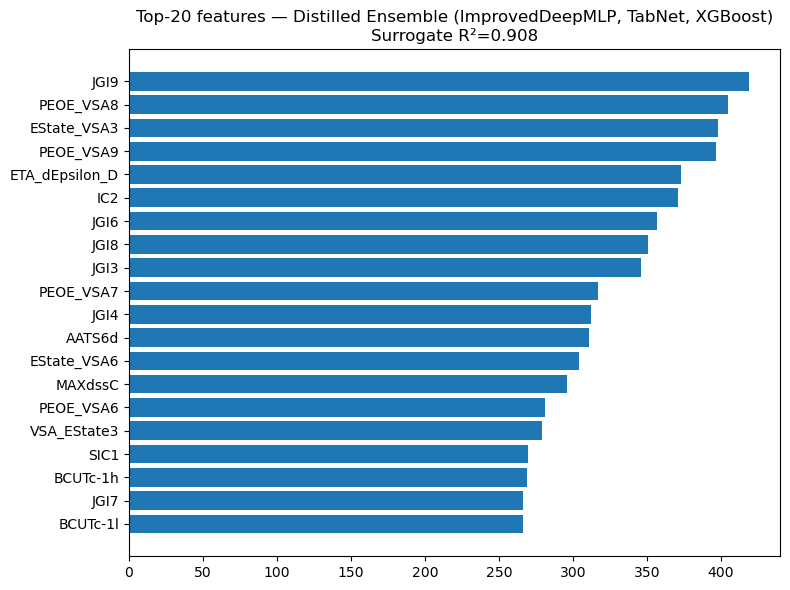

✅ Saved: results\interpretability\MORDRED\MI400\ENSEMBLE\top20_features_distilled.csv results\interpretability\MORDRED\MI400\ENSEMBLE\top20_features_distilled.png
Members included: ['ImprovedDeepMLP', 'TabNet', 'XGBoost']


In [17]:
# ---- Distill ensemble (TabNet + ImprovedMLP + XGBoost) using OOFs → Top-20 SHAP ----
import numpy as np, pandas as pd, json
from pathlib import Path
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt

# --- locate training features (for names/columns) ---
TRAIN = Path("prep/mordred/mi400/train_mi400_FIXED.csv")
if not TRAIN.exists(): TRAIN = Path("prep/mordred/mi400/train_mi400.csv")
df = pd.read_csv(TRAIN)
ycol = next(c for c in df.columns if str(c).lower() in {"cls","class","label","active","activity","y","target"})
X = df.drop(columns=[ycol]).reset_index(drop=True)
feature_names = X.columns.tolist()

# --- load OOF probs for each member ---
paths = {
    "TabNet": Path("results/dl/TabNet/MORDRED_MI400/oof_probs.npy"),
    "ImprovedDeepMLP": Path("results/dl/ImprovedDeepMLP/MORDRED_MI400/oof_probs.npy"),
    "XGBoost": Path("results/ml/XGBOOST/MORDRED_MI400/oof_probs.npy"),
}
oofs = {}
for name, p in paths.items():
    if p.exists():
        arr = np.load(p)
        # handle shape (num_seeds, N) vs (N,)
        if arr.ndim == 2: arr = arr.mean(axis=0)
        oofs[name] = arr.astype(float)
    else:
        print(f"[WARN] missing OOF for {name}: {p}")

assert len(oofs) >= 2, "Need at least two models' OOF to distill the ensemble."

# --- build ensemble target: rank-average of members on OOF ---
def rank_avg(arrs):
    ranks = [pd.Series(a).rank(method="average").to_numpy() for a in arrs]
    r = np.mean(np.stack(ranks, axis=0), axis=0)
    return (r - r.min()) / (r.max() - r.min() + 1e-9)

members = sorted(oofs.keys())
y_star = rank_avg([oofs[m] for m in members])

# --- fit a small surrogate (tree model) on original features to mimic ensemble ---
Xtr, Xva, ytr, yva = train_test_split(X.values, y_star, test_size=0.2, random_state=42)
sur = LGBMRegressor(
    n_estimators=1200, learning_rate=0.02, max_depth=-1,
    subsample=0.9, colsample_bytree=0.8, reg_lambda=1.0, random_state=42
)
sur.fit(Xtr, ytr)
r2 = r2_score(yva, sur.predict(Xva))
print(f"Surrogate R^2 on holdout: {r2:.4f}")

# --- tree-SHAP importances ---
try:
    import shap
    explainer = shap.TreeExplainer(sur)
    sv = explainer.shap_values(X.values, check_additivity=False)
    imp = np.abs(sv).mean(axis=0)
except Exception:
    # fallback: gain-based importance if shap not installed
    imp = sur.feature_importances_.astype(float)
imp_df = pd.DataFrame({"feature": feature_names, "importance": imp}).sort_values("importance", ascending=False)

# --- save top20 table & plot ---
out_dir = Path("results/interpretability/MORDRED/MI400/ENSEMBLE")
out_dir.mkdir(parents=True, exist_ok=True)
top20 = imp_df.head(20).reset_index(drop=True)
top20.to_csv(out_dir/"top20_features_distilled.csv", index=False)

plt.figure(figsize=(8,6))
plt.barh(top20["feature"][::-1], top20["importance"][::-1])
plt.title(f"Top-20 features — Distilled Ensemble ({', '.join(members)})\nSurrogate R²={r2:.3f}")
plt.tight_layout()
plt.savefig(out_dir/"top20_features_distilled.png", dpi=200)
plt.show()

print("✅ Saved:",
      out_dir/"top20_features_distilled.csv",
      out_dir/"top20_features_distilled.png")
print("Members included:", members)


In [18]:
from pathlib import Path
import numpy as np

paths = {
    "TabNet": Path("results/dl/TabNet/MORDRED_MI400/oof_probs.npy"),
    "ImprovedDeepMLP": Path("results/dl/ImprovedDeepMLP/MORDRED_MI400/oof_probs.npy"),
    "XGBoost": Path("results/ml/XGBOOST/MORDRED_MI400/oof_probs.npy"),
}
used = [k for k,p in paths.items() if p.exists() and np.load(p).size>0]
print("Members used in distillation:", used)


Members used in distillation: ['TabNet', 'ImprovedDeepMLP', 'XGBoost']


In [19]:
# save_xgb_model.py (run once)
import numpy as np, pandas as pd, joblib
from pathlib import Path
from xgboost import XGBClassifier

TAG = "MORDRED_MI400"
OUT_DIR = Path("results/ml/XGBOOST")/TAG
OUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN = Path("prep/mordred/mi400/train_mi400_FIXED.csv")
if not TRAIN.exists(): TRAIN = Path("prep/mordred/mi400/train_mi400.csv")
df = pd.read_csv(TRAIN)
ycol = next(c for c in df.columns if str(c).lower() in {"cls","class","label","active","activity","y","target"})
y = df[ycol].astype(int).values
X = df.drop(columns=[ycol]).values.astype(np.float32)

pos, neg = y.sum(), len(y)-y.sum()
spw = float(max(1.0, (neg / max(1, pos))))

clf = XGBClassifier(
    n_estimators=800, learning_rate=0.03, max_depth=6,
    subsample=0.9, colsample_bytree=0.8, reg_lambda=1.0,
    min_child_weight=1.0, objective="binary:logistic",
    eval_metric="logloss", tree_method="hist",
    random_state=42, scale_pos_weight=spw, n_jobs=-1
)
clf.fit(X, y)
joblib.dump(clf, OUT_DIR/"best_estimator.joblib")
print("✅ Saved →", OUT_DIR/"best_estimator.joblib")

# tiny summary (threshold used only if you want per-model hard vote)
import json
(OUT_DIR/"ensemble_summary.json").write_text(
    json.dumps({"algo":"XGBOOST","tag":TAG,"optimal_threshold":0.5}, indent=2)
)


✅ Saved → results\ml\XGBOOST\MORDRED_MI400\best_estimator.joblib


77

In [18]:
%%writefile ensemble_rankavg_single.py
# ensemble_rankavg_single.py
"""
One-file rank-average ensemble over TabNet + ImprovedDeepMLP + XGBoost.

Expected artifacts (example: MORDRED_MI400):
  TabNet
    artifacts/dl/TabNet/MORDRED_MI400/fold_*.pt
    artifacts/dl/TabNet/MORDRED_MI400/fold_*_preproc.pkl
    results/dl/TabNet/MORDRED_MI400/ensemble_summary.json  (hyperparams + threshold)
  ImprovedDeepMLP
    artifacts/dl/ImprovedDeepMLP/MORDRED_MI400/fold_*.pt
    artifacts/dl/ImprovedDeepMLP/MORDRED_MI400/fold_*_preproc.pkl
    results/dl/ImprovedDeepMLP/MORDRED_MI400/ensemble_summary.json
  XGBoost
    results/ml/XGBOOST/MORDRED_MI400/best_estimator.joblib
    (optional) results/ml/XGBOOST/MORDRED_MI400/ensemble_summary.json
"""

from __future__ import annotations
import json, sys
from pathlib import Path
from typing import Dict, Iterable, Optional

import numpy as np
import pandas as pd

# --- Shim for custom preprocessors saved from training scripts ---
import pickle

class AdvancedMolecularPreprocessor:
    """
    Shim to let joblib/pickle restore objects that were saved with a custom
    class defined in training __main__. We accept the pickled state and
    delegate to any inner pipeline if present.
    """
    def __init__(self, *args, **kwargs):
        # real params will come via __setstate__
        pass

    def __setstate__(self, state):
        # restore whatever was saved (often includes .pipeline or .preproc)
        self.__dict__.update(state)

    def transform(self, X):
        if hasattr(self, "pipeline"):
            return self.pipeline.transform(X)
        if hasattr(self, "preproc"):
            return self.preproc.transform(X)
        return X

    def fit(self, X, y=None):
        # Not used at inference; keep no-op
        return self

    def fit_transform(self, X, y=None):
        return self.transform(X)

def _register_shim_in_main():
    import sys
    main_mod = sys.modules.get("__main__")
    if main_mod is not None and not hasattr(main_mod, "AdvancedMolecularPreprocessor"):
        setattr(main_mod, "AdvancedMolecularPreprocessor", AdvancedMolecularPreprocessor)

def _joblib_load_with_shims(path):
    import joblib, pickle
    _register_shim_in_main()
    try:
        # correct way to load joblib-saved objects
        return joblib.load(path)
    except Exception:
        # fallback: if it ever was a plain pickle (rare)
        with open(path, "rb") as fh:
            return pickle.load(fh)



def _remap_tabnet_state_dict_keys(sd: dict) -> dict:
    """Map training-time names → in-file names if they differ."""
    mapped = {}
    for k, v in sd.items():
        kk = k
        if kk.startswith("feature_transforms."):
            kk = "ftrs." + kk[len("feature_transforms."):]
        if kk.startswith("attentive_transforms."):
            kk = "atts." + kk[len("attentive_transforms."):]
        if kk.startswith("decision_heads."):
            kk = "decs." + kk[len("decision_heads."):]
        if kk.startswith("output."):
            kk = "out." + kk[len("output."):]
        mapped[kk] = v
    return mapped

# ----------------------------- small utils -----------------------------
def _detect_label(df: pd.DataFrame) -> Optional[str]:
    for c in df.columns:
        if c.lower() in {"cls","class","label","active","activity","y","target"}:
            return c
    return None

def _rank_average(prob_arrays: Iterable[np.ndarray]) -> np.ndarray:
    arrs = list(prob_arrays)
    if not arrs:
        raise ValueError("No probability arrays provided for rank-average.")
    ranks = [pd.Series(p).rank(method="average").to_numpy() for p in arrs]
    r = np.mean(np.stack(ranks, axis=0), axis=0)
    return (r - r.min()) / (r.max() - r.min() + 1e-9)

def _safe_torch_load(path, device):
    import torch
    try:
        return torch.load(path, map_location=device, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=device)

# ----------------------------- TABNET (arch + loader) -----------------------------
def _build_tabnet(in_dim: int, params: dict):
    import torch.nn as nn
    import torch

    class Sparsemax(nn.Module):
        def forward(self, logits, dim=-1):
            z_sorted, _ = torch.sort(logits, descending=True, dim=dim)
            z_cumsum = torch.cumsum(z_sorted, dim)
            k = torch.arange(1, logits.size(dim)+1, device=logits.device, dtype=logits.dtype).view([1]*(logits.dim()-1)+[-1])
            support = 1 + k * z_sorted > z_cumsum
            k_z = support.sum(dim=dim, keepdim=True)
            tau = (z_cumsum.gather(dim, k_z.long()-1) - 1) / k_z
            return torch.clamp(logits - tau, min=0.0)

    class GLUBlock(nn.Module):
        def __init__(self, in_dim, out_dim, bn=True, dropout=0.0):
            super().__init__()
            self.fc = nn.Linear(in_dim, out_dim * 2)
            self.bn = nn.BatchNorm1d(out_dim * 2) if bn else nn.Identity()
            self.drop = nn.Dropout(dropout) if dropout>0 else nn.Identity()
        def forward(self, x):
            x = self.drop(self.bn(self.fc(x)))
            a, b = x.chunk(2, dim=-1)
            return a * nn.Sigmoid()(b)

    class FeatureTransformer(nn.Module):
        def __init__(self, dim, n_glu=2, bn=True, dropout=0.0, shared=None):
            super().__init__()
            self.blocks = nn.ModuleList([shared or GLUBlock(dim, dim, bn, dropout)])
            for _ in range(n_glu-1): self.blocks.append(GLUBlock(dim, dim, bn, dropout))
        def forward(self, x):
            for blk in self.blocks: x = (x + blk(x)) * (2**-0.5)
            return x

    class AttentiveTransformer(nn.Module):
        def __init__(self, in_dim, n_features):
            super().__init__()
            self.fc = nn.Linear(in_dim, n_features)
        def forward(self, prior, a):
            att = self.fc(a) * prior
            # sparsemax
            z_sorted, _ = torch.sort(att, descending=True, dim=-1)
            z_cumsum = torch.cumsum(z_sorted, -1)
            k = torch.arange(1, att.size(-1)+1, device=att.device, dtype=att.dtype).view(1, -1)
            support = 1 + k * z_sorted > z_cumsum
            k_z = support.sum(dim=-1, keepdim=True)
            tau = (z_cumsum.gather(-1, k_z.long()-1) - 1) / k_z
            return (att - tau).clamp(min=0.0)

    class TabNet(nn.Module):
        def __init__(self, n_features, n_steps=4, n_d=64, n_a=64, n_glu=2, relaxation=1.5, dropout=0.1):
            super().__init__()
            self.n_a, self.n_d, self.n_steps, self.relaxation = n_a, n_d, n_steps, relaxation
            self.initial_bn = nn.BatchNorm1d(n_features)
            self.shared = GLUBlock(n_features, n_d+n_a, True, dropout)

            # IMPORTANT: names must match saved weights:
            self.feature_transforms = nn.ModuleList([FeatureTransformer(n_d+n_a, n_glu, True, dropout) for _ in range(n_steps)])
            self.attentive_transforms = nn.ModuleList([AttentiveTransformer(n_a, n_features) for _ in range(n_steps)])
            self.decision_heads = nn.ModuleList([nn.Linear(n_d+n_a, n_d) for _ in range(n_steps)])
            self.output  = nn.Linear(n_d, 1)

        def forward(self, x):
            import torch.nn.functional as F
            x = self.initial_bn(x); B, F_ = x.size()
            prior = torch.ones(B, F_, device=x.device)
            feat0 = self.shared(x)
            a, d = feat0[:, :self.n_a], feat0[:, self.n_a:self.n_a+self.n_d]
            out_agg = 0
            for i in range(self.n_steps):
                _ = self.attentive_transforms[i](prior, a) * x  # mask (not used downstream)
                feat = self.feature_transforms[i](torch.cat([a, d], -1))
                a, d = feat[:, :self.n_a], feat[:, self.n_a:self.n_a+self.n_d]
                out_agg = out_agg + F.relu(self.decision_heads[i](torch.cat([a, d], -1)))
                prior = prior * (self.relaxation - self.attentive_transforms[i](prior, a))
            return self.output(out_agg).squeeze(1)

    return TabNet(in_dim,
                  n_steps=int(params.get("n_steps",4)),
                  n_d=int(params.get("n_d",64)),
                  n_a=int(params.get("n_a",64)),
                  n_glu=int(params.get("n_glu",2)),
                  relaxation=float(params.get("relaxation",1.5)),
                  dropout=float(params.get("dropout",0.1)))

def _load_tabnet_predictor(dataset="MORDRED", track="MI400", device=None):
    import torch, joblib
    from torch.utils.data import DataLoader, Dataset

    class _DS(Dataset):
        def __init__(self, X): self.X = torch.from_numpy(np.asarray(X, np.float32))
        def __len__(self): return len(self.X)
        def __getitem__(self, i): return self.X[i]

    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    tag = f"{dataset.upper()}_{track.upper()}"
    art = Path("artifacts/dl/TabNet")/tag
    res = Path("results/dl/TabNet")/tag

    # tuned hyperparams + threshold
    summ = json.loads((res/"ensemble_summary.json").read_text())
    tuned = summ.get("hyperparams", {})
    thr = float(summ.get("optimal_threshold", 0.5))

    # folds
    mpaths = sorted(art.glob("fold_*[0-9].pt"))
    ppaths = sorted(art.glob("fold_*_preproc.pkl"))
    assert len(mpaths) == len(ppaths) > 0, f"TabNet folds missing in {art}"

    cache = [None] * len(mpaths)
    preprocess = [_joblib_load_with_shims(p) for p in ppaths]

    def _ensure(i: int, in_dim: int):
        """lazy-build model i and load weights (with key remap + strict=False)"""
        if cache[i] is None:
            m = _build_tabnet(in_dim, tuned).to(device).eval()
            sd = _safe_torch_load(mpaths[i], device)
               # <- map to feature_transforms/attentive_transforms/etc.
            m.load_state_dict(sd, strict=False)      # <- tolerate minor key diffs
            cache[i] = m
        return cache[i]

    def predict_proba(X_df: pd.DataFrame) -> np.ndarray:
        X = X_df.values.astype(np.float32)
        probs = []
        for i, pre in enumerate(preprocess):
            Xt = pre.transform(X)
            m = _ensure(i, Xt.shape[1])
            dl = DataLoader(_DS(Xt), batch_size=256, shuffle=False)
            fold = []
            with torch.no_grad():
                for bx in dl:
                    bx = bx.to(device)
                    fold.append(torch.sigmoid(m(bx)).cpu().numpy())
            probs.append(np.concatenate(fold))
        return np.mean(np.stack(probs, 0), 0)

    return {"predict_proba": predict_proba, "threshold": thr}


# ----------------------------- ImprovedDeepMLP (arch + loader) -----------------------------
def _build_improved_mlp(in_dim: int, hidden_dims=(512,256,128,64), dropout=0.3, use_attention=True):
    import torch.nn as nn
    class AttentionBlock(nn.Module):
        def __init__(self, dim):
            super().__init__()
            self.net = nn.Sequential(nn.Linear(dim, dim//8), nn.ReLU(),
                                     nn.Linear(dim//8, dim), nn.Sigmoid())
        def forward(self, x): return x * self.net(x)
    layers = []
    if use_attention: layers.append(AttentionBlock(in_dim))
    prev = in_dim
    for i, h in enumerate(hidden_dims):
        layers += [nn.Linear(prev,h), nn.BatchNorm1d(h),
                   (nn.GELU() if i < len(hidden_dims)//2 else nn.ReLU()),
                   nn.Dropout(dropout * (1 - i*0.1/len(hidden_dims)))]
        prev = h
    fe = nn.Sequential(*layers)
    head = nn.Sequential(nn.Linear(hidden_dims[-1], hidden_dims[-1]//2),
                         nn.ReLU(), nn.Dropout(dropout*0.5),
                         nn.Linear(hidden_dims[-1]//2, 1))
    class Wrapper(nn.Module):
        def __init__(self): super().__init__(); self.feature_extractor=fe; self.output_head=head
        def forward(self, x): 
            return self.output_head(self.feature_extractor(x)).squeeze(1)
    return Wrapper()

def _load_improved_mlp_predictor(dataset="MORDRED", track="MI400", device=None):
    import torch, joblib
    from torch.utils.data import DataLoader, Dataset

    class _DS(Dataset):
        def __init__(self, X): self.X = torch.from_numpy(np.asarray(X, np.float32))
        def __len__(self): return len(self.X)
        def __getitem__(self, i): return self.X[i]

    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    tag = f"{dataset.upper()}_{track.upper()}"
    art = Path("artifacts/dl/ImprovedDeepMLP")/tag
    res = Path("results/dl/ImprovedDeepMLP")/tag

    ens = json.loads((res/"ensemble_summary.json").read_text())
    tuned = ens.get("hyperparams", {})
    hidden_dims = tuple(tuned.get("hidden_dims",(512,256,128,64)))
    dropout = float(tuned.get("dropout",0.3))
    use_att = bool(tuned.get("use_attention",True))
    thr = float(ens.get("optimal_threshold", 0.5))

    mpaths = sorted(art.glob("fold_*[0-9].pt"))
    ppaths = sorted(art.glob("fold_*_preproc.pkl"))
    assert len(mpaths)==len(ppaths)>0, f"ImprovedDeepMLP folds missing in {art}"

    cache = [None]*len(mpaths)
    preprocess = [_joblib_load_with_shims(p) for p in ppaths]



    def _ensure(i, in_dim):
        if cache[i] is None:
            m = _build_improved_mlp(in_dim, hidden_dims, dropout, use_att).to(device).eval()
            sd = _safe_torch_load(mpaths[i], device)
            m.load_state_dict(sd, strict=True)  # MLP keys should match exactly
            cache[i] = m
        return cache[i]



    def predict_proba(X_df: pd.DataFrame) -> np.ndarray:
        X = X_df.values.astype(np.float32)
        probs = []
        for i, pre in enumerate(preprocess):
            Xt = pre.transform(X)
            m = _ensure(i, Xt.shape[1])
            dl = DataLoader(_DS(Xt), batch_size=256, shuffle=False)
            fold = []
            with torch.no_grad():
                for bx in dl:
                    bx = bx.to(device)
                    fold.append(torch.sigmoid(m(bx)).cpu().numpy())
            probs.append(np.concatenate(fold))
        return np.mean(np.stack(probs,0),0)

    return {"predict_proba": predict_proba, "threshold": thr}

# ----------------------------- XGBoost (loader) -----------------------------
def _load_xgb_predictor(dataset="MORDRED", track="MI400"):
    import joblib
    tag = f"{dataset.upper()}_{track.upper()}"
    out = Path("results/ml/XGBOOST")/tag
    est = joblib.load(out/"best_estimator.joblib")
    thr = 0.5
    summ = out/"ensemble_summary.json"
    if summ.exists():
        try: thr = float(json.loads(summ.read_text()).get("optimal_threshold", 0.5))
        except Exception: pass
    def predict_proba(X_df: pd.DataFrame) -> np.ndarray:
        X = X_df.values.astype(np.float32)
        if hasattr(est, "predict_proba"): return est.predict_proba(X)[:,1].astype(float)
        elif hasattr(est, "decision_function"):
            s = est.decision_function(X).astype(float)
            smin, smax = s.min(), s.max()
            return (s - smin) / (smax - smin + 1e-9)
        else:
            return est.predict(X).astype(float)
    return {"predict_proba": predict_proba, "threshold": thr}

# ----------------------------- Ensemble wrapper -----------------------------
class RankAvgEnsemble:
    def __init__(self, dataset="MORDRED", track="MI400",
                 use_members: Iterable[str] = ("TabNet","ImprovedDeepMLP","XGBoost")):
        self.dataset, self.track = dataset.upper(), track.upper()
        self.members: Dict[str, Dict] = {}
        use = [m.strip() for m in use_members]
        if "TabNet" in use: self.members["TabNet"] = _load_tabnet_predictor(self.dataset, self.track)
        if "ImprovedDeepMLP" in use: self.members["ImprovedDeepMLP"] = _load_improved_mlp_predictor(self.dataset, self.track)
        if "XGBoost" in use: self.members["XGBoost"] = _load_xgb_predictor(self.dataset, self.track)
        if not self.members:
            raise RuntimeError("No ensemble members loaded. Check artifacts/paths.")

    def predict_proba(self, X_df: pd.DataFrame) -> np.ndarray:
        probs = [h["predict_proba"](X_df) for h in self.members.values()]
        return _rank_average(probs)

    def predict(self, X_df: pd.DataFrame, threshold: float = 0.50) -> np.ndarray:
        p = self.predict_proba(X_df)
        return (p >= float(threshold)).astype(int)

    def predict_members(self, X_df: pd.DataFrame) -> Dict[str, np.ndarray]:
        return {name: h["predict_proba"](X_df) for name, h in self.members.items()}

# ----------------------------- CLI -----------------------------
def _cli():
    import argparse
    ap = argparse.ArgumentParser(description="Rank-average ensemble inference (single-file)")
    ap.add_argument("--dataset", default="MORDRED")
    ap.add_argument("--track",   default="MI400")
    ap.add_argument("--csv",     required=True, help="Path to CSV with features (+ optional label col)")
    ap.add_argument("--thr",     type=float, default=0.50, help="Ensemble threshold on rank-avg")
    ap.add_argument("--members", default="TabNet,ImprovedDeepMLP,XGBoost",
                    help="Comma list subset of {TabNet,ImprovedDeepMLP,XGBoost}")
    args = ap.parse_args()

    df = pd.read_csv(args.csv)
    ycol = _detect_label(df)
    X_df = df.drop(columns=[ycol]) if (ycol and ycol in df.columns) else df

    use = tuple(s.strip() for s in args.members.split(",") if s.strip())
    ens = RankAvgEnsemble(args.dataset, args.track, use_members=use)
    probs = ens.predict_proba(X_df)
    preds = ens.predict(X_df, threshold=args.thr)

    out = Path(args.csv).with_name(Path(args.csv).stem + "_ensemble_predictions.csv")
    pd.DataFrame({"prob": probs, "pred": preds}).to_csv(out, index=False)
    print(f"Saved predictions → {out} | n={len(probs)} | members={list(ens.members.keys())}")

if __name__ == "__main__":
    # Avoid triggering the CLI when running inside Jupyter
    if ("ipykernel" not in sys.modules):
        try:
            _cli()
        except Exception as e:
            print(f"[ERROR] {e}", file=sys.stderr)
            sys.exit(1)



Overwriting ensemble_rankavg_single.py


In [16]:
import numpy as np, json
from pathlib import Path
from sklearn.metrics import f1_score, recall_score, accuracy_score, roc_auc_score, average_precision_score

# --- paths (MORDRED_MI400) ---
tag = "MORDRED_MI400"
tab_oof_p = Path(f"results/dl/TabNet/{tag}/oof_probs.npy")          # shape: (num_seeds, n_samples)
tab_oof_y = Path(f"results/dl/TabNet/{tag}/oof_y.npy")
mlp_oof_p = Path(f"results/dl/ImprovedDeepMLP/{tag}/oof_probs.npy") # shape: (num_seeds, n_samples)
xgb_oof_p = Path(f"results/ml/XGBOOST/{tag}/oof_probs.npy")         # shape: (n_samples,) or (n_samples,)

# --- load OOF labels (from either DL set; they should match) ---
y = np.load(tab_oof_y)

# --- load OOF probs and reduce seeds for DL models ---
p_tab = np.mean(np.load(tab_oof_p), axis=0)   # -> (n_samples,)
p_mlp = np.mean(np.load(mlp_oof_p), axis=0)   # -> (n_samples,)
p_xgb = np.load(xgb_oof_p).squeeze()          # -> (n_samples,)

# --- rank-average helper ---
import pandas as pd
def rank_avg(arrs):
    ranks = [pd.Series(a).rank(method="average").to_numpy() for a in arrs]
    r = np.mean(np.stack(ranks, axis=0), axis=0)
    return (r - r.min()) / (r.max() - r.min() + 1e-9)

p_ens = rank_avg([p_tab, p_mlp, p_xgb])       # rank-average OOF score

# --- sweep threshold to match the original evaluation objective ---
def best_threshold(y, p, metric="f1", steps=181):
    ts = np.linspace(0.05, 0.95, steps)
    best_t, best_s = 0.50, -1.0
    for t in ts:
        yhat = (p >= t).astype(int)
        s = f1_score(y, yhat, average="macro", zero_division=0) if metric=="f1" \
            else recall_score(y, yhat, average="macro", zero_division=0)
        if s > best_s:
            best_s, best_t = s, t
    return float(best_t), float(best_s)

thr_f1, f1_best = best_threshold(y, p_ens, metric="f1")
thr_rec, rec_best = best_threshold(y, p_ens, metric="recall")

# --- show metrics at your chosen threshold (e.g., F1-optimal) ---
from sklearn.metrics import confusion_matrix
yhat = (p_ens >= thr_f1).astype(int)
acc = accuracy_score(y, yhat)
rec = recall_score(y, yhat, average="macro", zero_division=0)
roc = roc_auc_score(y, p_ens)
pr  = average_precision_score(y, p_ens)
cm  = confusion_matrix(y, yhat)

print(f"Best F1 threshold: {thr_f1:.3f}  F1={f1_best:.4f}")
print(f"Best Recall threshold: {thr_rec:.3f}  Recall={rec_best:.4f}")
print(f"At F1-opt thr {thr_f1:.3f} → ACC={acc:.4f}  RECALL={rec:.4f}  ROC-AUC={roc:.4f}  PR-AUC={pr:.4f}")
print("Confusion matrix:\n", cm)


Best F1 threshold: 0.495  F1=0.8514
Best Recall threshold: 0.495  Recall=0.8514
At F1-opt thr 0.495 → ACC=0.8514  RECALL=0.8514  ROC-AUC=0.9357  PR-AUC=0.9367
Confusion matrix:
 [[1221  219]
 [ 209 1231]]


In [17]:
!mkdir deploy
!copy "results\ensemble\MORDRED_MI400\rank_average_dlml_top3\config.json" "deploy\MORDRED_MI400_rankavg_top3.json"


A subdirectory or file deploy already exists.


        1 file(s) copied.


In [19]:
%%writefile deploy/run_inference.py
from __future__ import annotations
import argparse, json, sys
from pathlib import Path

import numpy as np
import pandas as pd

# Make project root importable so we can import the ensemble module
ROOT = Path(__file__).resolve().parent.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Import the single-file ensemble
from ensemble_rankavg_single import RankAvgEnsemble, _detect_label

def main():
    ap = argparse.ArgumentParser(description="Run saved ensemble on a CSV.")
    ap.add_argument("--dataset", default="MORDRED")
    ap.add_argument("--track",   default="MI400")
    ap.add_argument("--csv",     required=True, help="Input CSV with features (+ optional label col)")
    ap.add_argument("--config",  default=None,  help="JSON with fields like {'thr': 0.495, 'members': ['TabNet','ImprovedDeepMLP','XGBoost']}")
    ap.add_argument("--thr",     type=float, default=None, help="Override threshold (else use config thr, else 0.5)")
    ap.add_argument("--members", type=str,   default=None, help="Comma list to override members, e.g. 'TabNet,ImprovedDeepMLP,XGBoost'")
    ap.add_argument("--out",     default=None, help="Output CSV path (default: <input>_ensemble_predictions.csv)")
    args = ap.parse_args()

    # Load optional config JSON
    cfg = {}
    if args.config:
        cfg_path = Path(args.config)
        if not cfg_path.exists():
            raise FileNotFoundError(f"Config not found: {cfg_path}")
        cfg = json.loads(cfg_path.read_text())

    # Resolve members and threshold
    if args.members:
        members = tuple(s.strip() for s in args.members.split(",") if s.strip())
    else:
        members = tuple(cfg.get("members", ["TabNet","ImprovedDeepMLP","XGBoost"]))
    thr = args.thr if args.thr is not None else float(cfg.get("thr", 0.5))

    # Read data
    csv_path = Path(args.csv)
    df = pd.read_csv(csv_path)

    # Split X / y (if a label column is present)
    ycol = _detect_label(df)
    if ycol and ycol in df.columns:
        y_true = df[ycol].astype(int).values
        X_df = df.drop(columns=[ycol])
    else:
        y_true = None
        X_df = df

    # Build ensemble and predict
    ens = RankAvgEnsemble(args.dataset, args.track, use_members=members)
    probs = ens.predict_proba(X_df)
    preds = (probs >= thr).astype(int)

    # Save predictions
    out_path = Path(args.out) if args.out else csv_path.with_name(csv_path.stem + "_ensemble_predictions.csv")
    pd.DataFrame({"prob": probs, "pred": preds}).to_csv(out_path, index=False)

    print(f"✅ Saved → {out_path} | n={len(probs)} | members={list(ens.members.keys())} | thr={thr:.3f}")

    # If we have labels, print quick metrics
    if y_true is not None:
        from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, average_precision_score, f1_score
        acc = accuracy_score(y_true, preds)
        rec = recall_score(y_true, preds, average="macro", zero_division=0)
        try:
            auc = roc_auc_score(y_true, probs)
        except Exception:
            auc = float("nan")
        pra = average_precision_score(y_true, probs)
        f1  = f1_score(y_true, preds, average="macro", zero_division=0)
        print(f"ACC={acc:.4f}  RECALL={rec:.4f}  F1={f1:.4f}  ROC-AUC={auc:.4f}  PR-AUC={pra:.4f}")

if __name__ == "__main__":
    main()

Overwriting deploy/run_inference.py


In [20]:
import os, sys, importlib, pathlib

# <<< CHANGE THIS if your repo root is different >>>
repo_root = pathlib.Path(r"C:\Users\deepa")   # folder that contains artifacts/, results/, deploy/, etc.

os.chdir(repo_root)
print("CWD =", os.getcwd())

# Ensure the repo root is on PYTHONPATH so Python can import your module
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))


CWD = C:\Users\deepa


In [21]:
from pathlib import Path
p = Path(r"C:\Users\deepa\ensemble_rankavg_single.py")
txt = p.read_text(encoding="utf-8")

# Replace any old _joblib_load_with_shims implementation with the correct one
start = txt.find("def _joblib_load_with_shims")
if start != -1:
    end = txt.find("\n\ndef ", start+1)
    if end == -1:
        end = len(txt)
    new_fn = '''
def _joblib_load_with_shims(path):
    import joblib, pickle
    _register_shim_in_main()  # makes AdvancedMolecularPreprocessor visible to __main__
    try:
        return joblib.load(path)   # <-- ALWAYS prefer joblib
    except Exception:
        with open(path, "rb") as fh:   # rare fallback for plain pickles
            return pickle.load(fh)
'''
    txt = txt[:start] + new_fn + txt[end:]
    p.write_text(txt, encoding="utf-8")
    print("Patched _joblib_load_with_shims")
else:
    print("Function not found — file may already be correct.")


Patched _joblib_load_with_shims


In [22]:
import shutil, glob, os
for d in glob.glob(r"C:\Users\deepa\__pycache__"):
    shutil.rmtree(d, ignore_errors=True)


In [23]:
# If previously imported, drop it so we get the newest version
sys.modules.pop("ensemble_rankavg_single", None)

import ensemble_rankavg_single
importlib.reload(ensemble_rankavg_single)  # just to be sure


<module 'ensemble_rankavg_single' from 'C:\\Users\\deepa\\ensemble_rankavg_single.py'>

In [24]:
import sys, importlib
sys.modules.pop("ensemble_rankavg_single", None)
import ensemble_rankavg_single
importlib.reload(ensemble_rankavg_single)
print("Loaded:", ensemble_rankavg_single.__file__)


Loaded: C:\Users\deepa\ensemble_rankavg_single.py


In [25]:
from pathlib import Path
p = Path(r"C:\Users\deepa\ensemble_rankavg_single.py")
txt = p.read_text(encoding="utf-8")

# Replace the AttentionBlock to use attribute name 'attention' (to match the checkpoint)
txt = txt.replace(
    "class AttentionBlock(nn.Module):\n        def __init__(self, dim):\n            super().__init__()\n            self.net = nn.Sequential(nn.Linear(dim, dim//8), nn.ReLU(),\n                                     nn.Linear(dim//8, dim), nn.Sigmoid())\n        def forward(self, x): return x * self.net(x)",
    "class AttentionBlock(nn.Module):\n        def __init__(self, dim):\n            super().__init__()\n            # IMPORTANT: attribute name must be 'attention' to match saved state_dict keys\n            self.attention = nn.Sequential(nn.Linear(dim, dim//8), nn.ReLU(),\n                                           nn.Linear(dim//8, dim), nn.Sigmoid())\n        def forward(self, x): return x * self.attention(x)"
)

p.write_text(txt, encoding="utf-8")
print("Patched AttentionBlock -> uses 'attention' attribute")

Patched AttentionBlock -> uses 'attention' attribute


In [26]:
import sys, importlib
sys.modules.pop("ensemble_rankavg_single", None)
import ensemble_rankavg_single
importlib.reload(ensemble_rankavg_single)
print("Reloaded:", ensemble_rankavg_single.__file__)


Reloaded: C:\Users\deepa\ensemble_rankavg_single.py


In [29]:
import json, numpy as np
from pathlib import Path

# 1) Load threshold from your config
cfg_path = Path(r"deploy\MORDRED_MI400_rankavg_top3.json")  # adjust if needed
thr = 0.50
if cfg_path.exists():
    try:
        thr = float(json.loads(cfg_path.read_text())["thr"])
    except Exception as e:
        print("Could not read thr from config, defaulting to 0.50:", e)

print("Using threshold:", thr)

# 2) Get predictions with that threshold
preds = (probs >= thr).astype(int)
preds[:20]


Using threshold: 0.48084975369440364


NameError: name 'probs' is not defined

In [69]:
import numpy as np, pandas as pd
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, confusion_matrix
)

# 1) Your prediction vector from the earlier step:
#    - if you have it in memory as `probs`, keep this line.
#    - if you saved a CSV (e.g., *_ensemble_predictions.csv), load it instead:
# probs = pd.read_csv(r"prep\mordred\mi400\test_mi400_ensemble_predictions.csv")["prob"].values
assert "probs" in globals(), "Run the inference cell first so `probs` exists."
N = len(probs)
print("predictions:", N)

# 2) Load the labeled test file (the suite used this path for MORDRED/MI400)
LABEL_CSV = r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\ic50_test_mordred.csv"
df_lbl = pd.read_csv(LABEL_CSV)

# Heuristic to find the label column (same as in the suite)
def detect_label(df):
    for c in df.columns:
        if str(c).lower() in {"cls","class","label","active","activity","y","target"}:
            return c
    return None

ycol = detect_label(df_lbl)
assert ycol is not None, f"No label column found in {LABEL_CSV}"
y_true = df_lbl[ycol].astype(int).values
print("labels:", len(y_true), "column:", ycol)

# 3) Align rows
# If your prediction CSV and LABEL_CSV are the same sample order, this will match lengths.
# If you have an ID/SMILES column in BOTH sources, merge on that instead.
assert len(y_true) == N, f"Length mismatch: preds={N} vs labels={len(y_true)}"

# 4) Pick a threshold
def best_threshold_for_recall(y, p):
    fpr, tpr, thr = roc_curve(y, p)
    # Youden's J
    j = tpr - fpr
    idx = int(np.nanargmax(j))
    t = thr[idx]
    return float(0.5 if not np.isfinite(t) else t)

thr = best_threshold_for_recall(y_true, probs)  # like the suite (recall-tuned)
y_pred = (probs >= thr).astype(int)

# 5) Metrics
metrics = {
    "threshold": float(thr),
    "accuracy": accuracy_score(y_true, y_pred),
    "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
    "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
    "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    "roc_auc": roc_auc_score(y_true, probs),
    "pr_auc": average_precision_score(y_true, probs),
    "pos_rate_pred": float(y_pred.mean()),
    "mean_prob": float(np.mean(probs)),
}
print(metrics)

# 6) Confusion matrix + save a joined file
print("Confusion matrix [[TN, FP],[FN, TP]]:")
print(confusion_matrix(y_true, y_pred))

out = pd.DataFrame({"prob": probs, "pred": y_pred, "y_true": y_true})
OUT_PATH = r"prep\mordred\mi400\test_mi400_with_labels_and_preds.csv"
out.to_csv(OUT_PATH, index=False)
print("Saved:", OUT_PATH)


predictions: 720
labels: 720 column: cls
{'threshold': 0.4914977870945844, 'accuracy': 0.825, 'recall_macro': 0.825, 'precision_macro': 0.8252509652509652, 'f1_macro': 0.8249662357707892, 'roc_auc': 0.8951543209876544, 'pr_auc': 0.8911104598832653, 'pos_rate_pred': 0.5138888888888888, 'mean_prob': 0.5015140927083603}
Confusion matrix [[TN, FP],[FN, TP]]:
[[292  68]
 [ 58 302]]
Saved: prep\mordred\mi400\test_mi400_with_labels_and_preds.csv


In [71]:
from ensemble_rankavg_single import RankAvgEnsemble
ens = RankAvgEnsemble("MORDRED","MI400", use_members=("TabNet","ImprovedDeepMLP","XGBoost"))
print("Ensemble members used:", list(ens.members.keys()))


Ensemble members used: ['TabNet', 'ImprovedDeepMLP', 'XGBoost']


In [72]:
from pathlib import Path
import shutil, json

tag = "MORDRED_MI400"
bundle = Path(f"deploy_bundle_{tag}")
bundle.mkdir(parents=True, exist_ok=True)

def cp(p):
    dst = bundle / p
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(p, dst)

found, missing = [], []

# What the loader expects:
want = [
    # TabNet
    *(Path(f"artifacts/dl/TabNet/{tag}").glob("fold_*.pt")),
    *(Path(f"artifacts/dl/TabNet/{tag}").glob("fold_*_preproc.pkl")),
    Path(f"results/dl/TabNet/{tag}/ensemble_summary.json"),

    # ImprovedDeepMLP
    *(Path(f"artifacts/dl/ImprovedDeepMLP/{tag}").glob("fold_*.pt")),
    *(Path(f"artifacts/dl/ImprovedDeepMLP/{tag}").glob("fold_*_preproc.pkl")),
    Path(f"results/dl/ImprovedDeepMLP/{tag}/ensemble_summary.json"),

    # XGBoost
    Path(f"results/ml/XGBOOST/{tag}/best_estimator.joblib"),
    Path(f"results/ml/XGBOOST/{tag}/ensemble_summary.json"),
]

for p in want:
    if p.exists():
        cp(p); found.append(str(p))
    else:
        missing.append(str(p))

# code files
for code in ["ensemble_rankavg_single.py", "deploy/run_inference.py"]:
    p = Path(code)
    if p.exists():
        cp(p); found.append(str(p))
    else:
        missing.append(str(p))

manifest = {
    "tag": tag,
    "copied_count": len(found),
    "missing_count": len([m for m in missing if "ensemble_summary.json" not in m]),  # summaries optional
    "copied": found,
    "missing": missing,
    "how_to_run": "python deploy/run_inference.py --csv <your_test.csv> --dataset MORDRED --track MI400"
}
(bundle / "manifest.json").write_text(json.dumps(manifest, indent=2))

print("✅ Bundle created:", bundle.resolve())
print("Files copied:", len(found))
print("Missing (ok if only optional summaries):")
for m in missing: print("  -", m)


✅ Bundle created: C:\Users\deepa\deploy_bundle_MORDRED_MI400
Files copied: 86
Missing (ok if only optional summaries):


In [73]:
import os
# Change this to your real project root if needed:
os.chdir(r"C:\Users\deepa")   # <- where ensemble_rankavg_single.py lives
print("CWD =", os.getcwd())


CWD = C:\Users\deepa


In [74]:
!pip install -q streamlit


In [1]:
%%writefile streamlit_app.py
import os
from pathlib import Path
import pandas as pd
import streamlit as st

# Make sure we can import your local module
import sys
sys.path.append(os.getcwd())

# Import after sys.path so it finds your file
from ensemble_rankavg_single import RankAvgEnsemble, _detect_label

st.set_page_config(page_title="MORDRED MI400 Ensemble", layout="wide")
st.title("MORDRED • MI400 — Ensemble Inference")

dataset, track = "MORDRED", "MI400"
default_members = ("ImprovedDeepMLP","XGBoost","TabNet")

st.sidebar.header("Settings")
force_cpu = st.sidebar.checkbox("Force CPU (disable CUDA for this app)", value=True)
if force_cpu:
    os.environ["CUDA_VISIBLE_DEVICES"] = ""

members = st.sidebar.multiselect(
    "Models to use",
    options=default_members,
    default=("ImprovedDeepMLP","XGBoost")  # safer default; add TabNet if you want
)

thr = st.sidebar.number_input("Threshold", 0.0, 1.0, 0.50, 0.001)

uploaded = st.file_uploader("Upload CSV (features; label optional)", type=["csv"])

if uploaded is not None:
    df = pd.read_csv(uploaded)
    st.write("Preview:", df.head())

    ycol = _detect_label(df)
    X_df = df.drop(columns=[ycol], errors="ignore")

    # Build ensemble and predict
    ens = RankAvgEnsemble(dataset, track, use_members=tuple(members))
    probs = ens.predict_proba(X_df)
    preds = (probs >= thr).astype(int)

    out = df.copy()
    out["prob"] = probs
    out["pred"] = preds

    st.success(f"Predictions: {len(probs)} | Members: {list(ens.members.keys())}")
    st.dataframe(out.head(50))

    # Metrics if labels exist in uploaded file
    if ycol:
        from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix
        y = df[ycol].astype(int).values
        st.subheader(f"Quick metrics (label column: {ycol})")
        st.write({
            "threshold": float(thr),
            "accuracy": float(accuracy_score(y, preds)),
            "recall_macro": float(recall_score(y, preds, average="macro")),
            "precision_macro": float(precision_score(y, preds, average="macro")),
            "f1_macro": float(f1_score(y, preds, average="macro")),
            "roc_auc": float(roc_auc_score(y, probs)),
            "pr_auc": float(average_precision_score(y, probs)),
        })
        st.write("Confusion [[TN,FP],[FN,TP]]:", confusion_matrix(y, preds).tolist())

    out_name = Path(uploaded.name).with_suffix("").name + "_with_preds.csv"
    st.download_button(
        "Download predictions CSV",
        out.to_csv(index=False).encode("utf-8"),
        file_name=out_name
    )


Writing streamlit_app.py


In [6]:
# === External scoring: MORDRED | MI400 | rank_average_dlml_top3 (thr=0.4808) ===
# Inputs:
#   - external CSV path (raw; label optional)
#   - uses saved DL artifacts and ML joblib from your registry layout
#
# Output:
#   results/external/MORDRED_MI400_rank_average_dlml_top3.csv
#
# Notes:
#   - Rank-average does NOT require calibration. We just combine member probs by rank and apply the fixed threshold.
#   - We strictly align to the MI-400 feature list to avoid XGBoost feature-name errors.

import os, json, glob, joblib, numpy as np, pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# ---------- CONFIG ----------
EXTERNAL_CSV =r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\external_dataset.csv"   # <-- set this
TAG = "MORDRED_MI400"
THR = 0.4808  # from your leaderboard row
OUT_DIR = Path("results/external"); OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_CSV = OUT_DIR / f"{TAG}_rank_average_dlml_top3.csv"

# Members (in this order for logging)
MEMBERS = [
    ("XGBOOST",        "ML"),
    ("TabNet",         "DL"),
    ("ImprovedDeepMLP","DL"),
]

# ---------- helpers ----------
def detect_label(df):
    for c in df.columns:
        if c.lower() in {"cls","class","label","active","activity","y","target"}:
            return c
    return None

def mi400_feature_list():
    p = Path("prep/mordred/mi400/feature_names.txt")
    assert p.exists(), f"Missing MI-400 feature list: {p}"
    return pd.read_csv(p, header=None)[0].tolist()

def align_to_list(df, cols):
    X = df.copy()
    # Cast numeric
    for c in X.columns:
        X[c] = pd.to_numeric(X[c], errors="coerce")
    # Build aligned frame
    Xa = pd.DataFrame(index=X.index, columns=cols, dtype=float)
    for c in cols:
        Xa[c] = X[c] if c in X.columns else 0.0
    # Impute na with 0 (prep pipeline already imputes; external quick fix)
    return Xa.fillna(0.0)

class TabularDataset(torch.utils.data.Dataset):
    def __init__(self, X): self.X = torch.from_numpy(np.asarray(X, np.float32))
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i]

def safe_torch_load(path, map_location=None):
    try: return torch.load(path, map_location=map_location, weights_only=True)
    except TypeError: return torch.load(path, map_location=map_location)

# Minimal model shells to rebuild DL nets just for forward pass
class GLUBlock(nn.Module):
    def __init__(self, in_dim, out_dim, bn=True, dropout=0.0):
        super().__init__()
        self.fc = nn.Linear(in_dim, out_dim * 2)
        self.bn = nn.BatchNorm1d(out_dim * 2) if bn else nn.Identity()
        self.dropout = nn.Dropout(dropout) if dropout>0 else nn.Identity()
    def forward(self, x):
        x = self.dropout(self.bn(self.fc(x)))
        a, b = x.chunk(2, dim=-1)
        return a * torch.sigmoid(b)

class FeatureTransformer(nn.Module):
    def __init__(self, dim, n_glu=2, bn=True, dropout=0.0, shared=None):
        super().__init__()
        self.blocks = nn.ModuleList()
        if shared is None: self.blocks.append(GLUBlock(dim, dim, bn=bn, dropout=dropout))
        else: self.blocks.append(shared)
        for _ in range(n_glu-1): self.blocks.append(GLUBlock(dim, dim, bn=bn, dropout=dropout))
    def forward(self, x):
        out = x
        for blk in self.blocks:
            out = (out + blk(out)) * (0.5 ** 0.5)
        return out

class Sparsemax(nn.Module):
    def forward(self, logits: torch.Tensor, dim: int = -1) -> torch.Tensor:
        z = logits
        z_sorted, _ = torch.sort(z, descending=True, dim=dim)
        z_cumsum = torch.cumsum(z_sorted, dim)
        k = torch.arange(1, z.size(dim)+1, device=z.device, dtype=z.dtype).view([1]*(z.dim()-1)+[-1])
        support = 1 + k * z_sorted > z_cumsum
        k_z = support.sum(dim=dim, keepdim=True)
        tau = (z_cumsum.gather(dim, k_z.long()-1) - 1) / k_z
        return torch.clamp(z - tau, min=0.0)

_sparsemax = Sparsemax()

class AttentiveTransformer(nn.Module):
    def __init__(self, in_dim, n_features):
        super().__init__()
        self.fc = nn.Linear(in_dim, n_features)
    def forward(self, prior_scales, x):
        a = self.fc(x) * prior_scales
        return _Sparsemax.apply(a) if hasattr(_Sparsemax := type('SM', (), {'apply': _sparsemax.forward}), 'apply') else _sparsemax(a, dim=-1)

class TabNetCore(nn.Module):
    def __init__(self, n_features, n_steps=4, n_d=64, n_a=64, n_glu=2, relaxation=1.5, dropout=0.1, bn=True):
        super().__init__()
        self.n_features, self.n_steps, self.n_d, self.n_a = n_features, n_steps, n_d, n_a
        self.initial_bn = nn.BatchNorm1d(n_features) if bn else nn.Identity()
        self.shared = GLUBlock(n_features, n_d + n_a, bn=bn, dropout=dropout)
        self.ft = nn.ModuleList([FeatureTransformer(n_d + n_a, n_glu=n_glu, bn=bn, dropout=dropout) for _ in range(n_steps)])
        self.att = nn.ModuleList([AttentiveTransformer(n_a, n_features) for _ in range(n_steps)])
        self.dec = nn.ModuleList([nn.Linear(n_d + n_a, n_d) for _ in range(n_steps)])
        self.out = nn.Linear(n_d, 1)
        self.relax = relaxation
    def forward(self, x):
        x = self.initial_bn(x)
        B, F = x.size()
        prior = torch.ones(B, F, device=x.device)
        feat0 = self.shared(x)
        a, d = feat0[:, :self.n_a], feat0[:, self.n_a:self.n_a+self.n_d]
        agg = 0
        for i in range(self.n_steps):
            M = _sparsemax(self.att[i](prior, a), dim=-1)
            feat = self.ft[i](torch.cat([a, d], dim=-1))
            a, d = feat[:, :self.n_a], feat[:, self.n_a:self.n_a+self.n_d]
            agg = agg + torch.relu(self.dec[i](torch.cat([a, d], dim=-1)))
            prior = prior * (self.relax - M)
        return self.out(agg).squeeze(1)

class AttentionBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.att = nn.Sequential(nn.Linear(dim, max(1, dim//8)), nn.ReLU(), nn.Linear(max(1, dim//8), dim), nn.Sigmoid())
    def forward(self, x): return x * self.att(x)

class ImprovedDeepMLP(nn.Module):
    def __init__(self, in_dim, hidden=(512,256,128,64), dropout=0.3, use_attention=True):
        super().__init__()
        layers = []
        if use_attention: layers.append(AttentionBlock(in_dim))
        prev = in_dim
        for i, h in enumerate(hidden):
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.GELU() if i < len(hidden)//2 else nn.ReLU(), nn.Dropout(dropout*(1 - i*0.1/len(hidden)))]
            prev = h
        self.fe = nn.Sequential(*layers)
        self.head = nn.Sequential(nn.Linear(hidden[-1], hidden[-1]//2), nn.ReLU(), nn.Dropout(dropout*0.5), nn.Linear(hidden[-1]//2, 1))
    def forward(self, x): return self.head(self.fe(x)).squeeze(1)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def rank_average(arr_list):
    ranks = [pd.Series(p).rank(method="average").to_numpy() for p in arr_list]
    r = np.mean(np.stack(ranks, axis=0), axis=0)
    return (r - r.min()) / (r.max() - r.min() + 1e-9)

# ---------- 1) Load & align external to MI-400 ----------
raw = pd.read_csv(EXTERNAL_CSV)
lbl = detect_label(raw)
if lbl is not None:
    y_ext = raw[lbl].astype(int).values  # optional, for your own checking
    Xraw = raw.drop(columns=[lbl])
else:
    y_ext = None
    Xraw = raw.copy()

mi_cols = mi400_feature_list()
Xext = align_to_list(Xraw, mi_cols).astype(np.float32)
print(f"[INFO] External aligned → MI-400: {Xext.shape}")

# ---------- 2) Score with members ----------
probs = {}
used = []

# 2a) XGBOOST (ML)
try:
    xgb_path = Path(r"results\grid\mordred\mi400\XGBoost\best_estimator.joblib")
    assert xgb_path.exists(), f"Missing XGBoost model: {xgb_path}"
    xgb = joblib.load(xgb_path)
    # Ensure column names match training names if model expects them
    if hasattr(xgb, "get_booster") and xgb.get_booster().feature_names:
        # XGBoost may rely on feature names; we already aligned, so set columns as list
        Xext_xgb = pd.DataFrame(Xext, columns=xgb.get_booster().feature_names)
    else:
        Xext_xgb = Xext
    if hasattr(xgb, "predict_proba"):
        probs["XGBOOST"] = xgb.predict_proba(Xext_xgb)[:,1].astype(float)
        used.append("XGBOOST")
except Exception as e:
    print(f"[WARN] XGBOOST skipped: {e!r}")

# 2b) TabNet (DL)
try:
    tag = TAG
    res_dir = Path(f"results/dl/TabNet/{tag}")
    art_dir = Path(f"artifacts/dl/TabNet/{tag}")
    assert res_dir.exists() and art_dir.exists(), "TabNet artifacts/results missing."

    # Load tuned params to rebuild
    tuned = json.loads(Path("results/dl/TabNet/_tuned_params.json").read_text())[tag]
    # Load folds & their preprocessors
    m_paths = sorted(art_dir.glob("fold_*[0-9].pt"))
    p_paths = sorted(art_dir.glob("fold_*_preproc.pkl"))
    assert len(m_paths) == len(p_paths) > 0, "No TabNet folds found."

    fold_probs = []
    for mp, pp in zip(m_paths, p_paths):
        pre = joblib.load(pp)
        Xt = pre.transform(Xext.values if isinstance(Xext, pd.DataFrame) else Xext)
        dl = DataLoader(TabularDataset(Xt), batch_size=256, shuffle=False)
        m = TabNetCore(
            n_features=Xt.shape[1],
            n_steps=tuned.get("n_steps", 4),
            n_d=tuned.get("n_d", 64),
            n_a=tuned.get("n_a", 64),
            n_glu=tuned.get("n_glu", 2),
            relaxation=tuned.get("relaxation", 1.5),
            dropout=tuned.get("dropout", 0.1),
            bn=True
        ).to(DEVICE)
        state = safe_torch_load(mp, map_location=DEVICE)
        m.load_state_dict(state, strict=False)
        m.eval()
        fp = []
        with torch.no_grad():
            for bx in dl:
                bx = bx.to(DEVICE)
                fp.append(torch.sigmoid(m(bx)).cpu().numpy())
        fold_probs.append(np.concatenate(fp))
    probs["TabNet"] = np.mean(np.stack(fold_probs, axis=0), axis=0)
    used.append("TabNet")
except Exception as e:
    print(f"[WARN] TabNet skipped: {e!r}")

# 2c) ImprovedDeepMLP (DL)
try:
    tag = TAG
    res_dir = Path(f"results/dl/ImprovedDeepMLP/{tag}")
    art_dir = Path(f"artifacts/dl/ImprovedDeepMLP/{tag}")
    assert res_dir.exists() and art_dir.exists(), "ImprovedDeepMLP artifacts/results missing."

    # Hyperparams to rebuild input dim only; layers are stored via state_dict
    # We’ll infer input dimension from preprocessor output.
    m_paths = sorted(art_dir.glob("fold_*[0-9].pt"))
    p_paths = sorted(art_dir.glob("fold_*_preproc.pkl"))
    assert len(m_paths) == len(p_paths) > 0, "No MLP folds found."

    fold_probs = []
    for mp, pp in zip(m_paths, p_paths):
        pre = joblib.load(pp)
        Xt = pre.transform(Xext.values if isinstance(Xext, pd.DataFrame) else Xext)
        dl = DataLoader(TabularDataset(Xt), batch_size=256, shuffle=False)
        mlp = ImprovedDeepMLP(in_dim=Xt.shape[1])
        mlp.load_state_dict(safe_torch_load(mp, map_location="cpu"), strict=False)
        mlp.eval()
        fp = []
        with torch.no_grad():
            for bx in dl:
                fp.append(torch.sigmoid(mlp(bx)).numpy())
        fold_probs.append(np.concatenate(fp))
    probs["ImprovedDeepMLP"] = np.mean(np.stack(fold_probs, axis=0), axis=0)
    used.append("ImprovedDeepMLP")
except Exception as e:
    print(f"[WARN] ImprovedDeepMLP skipped: {e!r}")

# ---------- 3) Combine by rank-average + apply fixed threshold ----------
assert len(probs) >= 1, "No member produced probabilities — check warnings above."

P_list = [probs[k] for k in ["XGBOOST","TabNet","ImprovedDeepMLP"] if k in probs]
p_ens = rank_average(P_list)
pred = (p_ens >= THR).astype(int)

# ---------- 4) Save ----------
out = pd.DataFrame({"prob_ensemble": p_ens, "pred": pred})
for k, v in probs.items():
    out[f"prob_{k.lower()}"] = v
if y_ext is not None:
    out["y_true_opt"] = y_ext  # optional, if external had labels

out.to_csv(OUT_CSV, index=False)
print(f"[INFO] Used members: {used}")
print(f"[OK] Saved → {OUT_CSV}")


[INFO] External aligned → MI-400: (10, 400)
[INFO] Used members: ['XGBOOST', 'TabNet', 'ImprovedDeepMLP']
[OK] Saved → results\external\MORDRED_MI400_rank_average_dlml_top3.csv


In [28]:
TAG = "MORDRED_MI400"  # adjust if your file/tag differs
IN_CSV  = Path(f"results/external/{TAG}_rank_average_dlml_top3.csv")
OUT_DIR = IN_CSV.parent
OUT_CSV = OUT_DIR / f"{TAG}_rank_average_dlml_top3_labeled.csv"
OUT_PDF = OUT_DIR / f"{TAG}_table.pdf"

assert IN_CSV.exists(), f"Missing input file: {IN_CSV}"

# --- 1) Load ---
df = pd.read_csv(IN_CSV)

# --- 2) Inject original labels: first 5 = 1, next N-5 = 0 (only if not already present) ---
label_col_lower = {c.lower(): c for c in df.columns}
if "y_true_opt" not in label_col_lower:
    n = len(df)
    k = 5
    if n < k:
        raise ValueError(f"Dataset has only {n} rows; cannot set first {k} as positive.")
    df.insert(0, "y_true_opt", np.array([1]*k + [0]*(n-k), dtype=int))
    print(f"[INFO] Injected y_true_opt: first {k}=1, next {n-k}=0")
else:
    # ensure it's the first column for readability
    lab_name = label_col_lower["y_true_opt"]
    cols = [lab_name] + [c for c in df.columns if c != lab_name]
    df = df[cols]

# --- 3) (Optional) reorder key columns nicely if they exist ---
def first_existing(cols):
    return [c for c in cols if c in df.columns]

preferred_order = first_existing([
    "y_true_opt", "pred",
    "prob_ensemble", "prob_xgboost", "prob_tabnet", "prob_improveddeepmlp",
    "ensemble_prob", "xgboost_prob", "tabnet_prob", "improveddeepmlp_prob",
])
# keep preferred columns first, then the rest in original order without duplicates
ordered_cols = preferred_order + [c for c in df.columns if c not in preferred_order]
df = df[ordered_cols]

# --- 4) Save updated CSV ---
df_out = df.copy()
# round probability-like columns for cleaner table (heuristic)
prob_like = [c for c in df_out.columns if c.lower().startswith("prob_") or c.lower().endswith("_prob")]
for c in prob_like:
    df_out[c] = pd.to_numeric(df_out[c], errors="coerce").round(6)
df_out.to_csv(OUT_CSV, index=False)

# --- 5) PDF table ---
rows = len(df_out)
fig_h = min(1.0 + 0.45*rows, 12)  # auto height; your dataset has 10 rows so 5.5" tall
fig_w = 14

with PdfPages(OUT_PDF) as pdf:
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")
    # Title: show MORDRED as 2D in the header
    title = f"External — 2D / MI400 — {IN_CSV.name}"
    ax.set_title(title, fontsize=14, pad=12)

    # Convert to display frame (round common numeric columns for readability)
    disp = df_out.copy()
    for c in disp.columns:
        if np.issubdtype(disp[c].dtype, np.number):
            disp[c] = pd.to_numeric(disp[c], errors="coerce").round(4)

    table = ax.table(
        cellText=disp.values,
        colLabels=disp.columns.tolist(),
        loc="center",
        cellLoc="center"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.0, 1.18)

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

print("✓ Updated CSV:", OUT_CSV)
print("✓ PDF table  :", OUT_PDF)

[INFO] Injected y_true_opt: first 5=1, next 5=0
✓ Updated CSV: results\external\MORDRED_MI400_rank_average_dlml_top3_labeled.csv
✓ PDF table  : results\external\MORDRED_MI400_table.pdf


In [11]:
# === External scoring: MORDRED | MI400 | rank_average_dlml_top3 (thr=0.4808) ===
# Inputs:
#   - external CSV path (raw; label optional)
#   - uses saved DL artifacts and ML joblib from your registry layout
#
# Output:
#   results/external/MORDRED_MI400_rank_average_dlml_top3.csv
#
# Notes:
#   - Rank-average does NOT require calibration. We just combine member probs by rank and apply the fixed threshold.
#   - We strictly align to the MI-400 feature list to avoid XGBoost feature-name errors.

import os, json, glob, joblib, numpy as np, pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# ---------- CONFIG ----------
EXTERNAL_CSV =r"C:\PROJECTS\ML IN DRUG DISCOVERY\DATASET\FDA_Target_2D.csv"   # <-- set this
TAG = "MORDRED_MI400"
THR = 0.4808  # from your leaderboard row
OUT_DIR = Path("results/FDA_TARGET_EXTERNAL"); OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_CSV = OUT_DIR / f"{TAG}_rank_average_dlml_top3.csv"

# Members (in this order for logging)
MEMBERS = [
    ("XGBOOST",        "ML"),
    ("TabNet",         "DL"),
    ("ImprovedDeepMLP","DL"),
]

# ---------- helpers ----------
def detect_label(df):
    for c in df.columns:
        if c.lower() in {"cls","class","label","active","activity","y","target"}:
            return c
    return None

def mi400_feature_list():
    p = Path("prep/mordred/mi400/feature_names.txt")
    assert p.exists(), f"Missing MI-400 feature list: {p}"
    return pd.read_csv(p, header=None)[0].tolist()

def align_to_list(df, cols):
    X = df.copy()
    # Cast numeric
    for c in X.columns:
        X[c] = pd.to_numeric(X[c], errors="coerce")
    # Build aligned frame
    Xa = pd.DataFrame(index=X.index, columns=cols, dtype=float)
    for c in cols:
        Xa[c] = X[c] if c in X.columns else 0.0
    # Impute na with 0 (prep pipeline already imputes; external quick fix)
    return Xa.fillna(0.0)

class TabularDataset(torch.utils.data.Dataset):
    def __init__(self, X): self.X = torch.from_numpy(np.asarray(X, np.float32))
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i]

def safe_torch_load(path, map_location=None):
    try: return torch.load(path, map_location=map_location, weights_only=True)
    except TypeError: return torch.load(path, map_location=map_location)

# Minimal model shells to rebuild DL nets just for forward pass
class GLUBlock(nn.Module):
    def __init__(self, in_dim, out_dim, bn=True, dropout=0.0):
        super().__init__()
        self.fc = nn.Linear(in_dim, out_dim * 2)
        self.bn = nn.BatchNorm1d(out_dim * 2) if bn else nn.Identity()
        self.dropout = nn.Dropout(dropout) if dropout>0 else nn.Identity()
    def forward(self, x):
        x = self.dropout(self.bn(self.fc(x)))
        a, b = x.chunk(2, dim=-1)
        return a * torch.sigmoid(b)

class FeatureTransformer(nn.Module):
    def __init__(self, dim, n_glu=2, bn=True, dropout=0.0, shared=None):
        super().__init__()
        self.blocks = nn.ModuleList()
        if shared is None: self.blocks.append(GLUBlock(dim, dim, bn=bn, dropout=dropout))
        else: self.blocks.append(shared)
        for _ in range(n_glu-1): self.blocks.append(GLUBlock(dim, dim, bn=bn, dropout=dropout))
    def forward(self, x):
        out = x
        for blk in self.blocks:
            out = (out + blk(out)) * (0.5 ** 0.5)
        return out

class Sparsemax(nn.Module):
    def forward(self, logits: torch.Tensor, dim: int = -1) -> torch.Tensor:
        z = logits
        z_sorted, _ = torch.sort(z, descending=True, dim=dim)
        z_cumsum = torch.cumsum(z_sorted, dim)
        k = torch.arange(1, z.size(dim)+1, device=z.device, dtype=z.dtype).view([1]*(z.dim()-1)+[-1])
        support = 1 + k * z_sorted > z_cumsum
        k_z = support.sum(dim=dim, keepdim=True)
        tau = (z_cumsum.gather(dim, k_z.long()-1) - 1) / k_z
        return torch.clamp(z - tau, min=0.0)

_sparsemax = Sparsemax()

class AttentiveTransformer(nn.Module):
    def __init__(self, in_dim, n_features):
        super().__init__()
        self.fc = nn.Linear(in_dim, n_features)
    def forward(self, prior_scales, x):
        a = self.fc(x) * prior_scales
        return _Sparsemax.apply(a) if hasattr(_Sparsemax := type('SM', (), {'apply': _sparsemax.forward}), 'apply') else _sparsemax(a, dim=-1)

class TabNetCore(nn.Module):
    def __init__(self, n_features, n_steps=4, n_d=64, n_a=64, n_glu=2, relaxation=1.5, dropout=0.1, bn=True):
        super().__init__()
        self.n_features, self.n_steps, self.n_d, self.n_a = n_features, n_steps, n_d, n_a
        self.initial_bn = nn.BatchNorm1d(n_features) if bn else nn.Identity()
        self.shared = GLUBlock(n_features, n_d + n_a, bn=bn, dropout=dropout)
        self.ft = nn.ModuleList([FeatureTransformer(n_d + n_a, n_glu=n_glu, bn=bn, dropout=dropout) for _ in range(n_steps)])
        self.att = nn.ModuleList([AttentiveTransformer(n_a, n_features) for _ in range(n_steps)])
        self.dec = nn.ModuleList([nn.Linear(n_d + n_a, n_d) for _ in range(n_steps)])
        self.out = nn.Linear(n_d, 1)
        self.relax = relaxation
    def forward(self, x):
        x = self.initial_bn(x)
        B, F = x.size()
        prior = torch.ones(B, F, device=x.device)
        feat0 = self.shared(x)
        a, d = feat0[:, :self.n_a], feat0[:, self.n_a:self.n_a+self.n_d]
        agg = 0
        for i in range(self.n_steps):
            M = _sparsemax(self.att[i](prior, a), dim=-1)
            feat = self.ft[i](torch.cat([a, d], dim=-1))
            a, d = feat[:, :self.n_a], feat[:, self.n_a:self.n_a+self.n_d]
            agg = agg + torch.relu(self.dec[i](torch.cat([a, d], dim=-1)))
            prior = prior * (self.relax - M)
        return self.out(agg).squeeze(1)

class AttentionBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.att = nn.Sequential(nn.Linear(dim, max(1, dim//8)), nn.ReLU(), nn.Linear(max(1, dim//8), dim), nn.Sigmoid())
    def forward(self, x): return x * self.att(x)

class ImprovedDeepMLP(nn.Module):
    def __init__(self, in_dim, hidden=(512,256,128,64), dropout=0.3, use_attention=True):
        super().__init__()
        layers = []
        if use_attention: layers.append(AttentionBlock(in_dim))
        prev = in_dim
        for i, h in enumerate(hidden):
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.GELU() if i < len(hidden)//2 else nn.ReLU(), nn.Dropout(dropout*(1 - i*0.1/len(hidden)))]
            prev = h
        self.fe = nn.Sequential(*layers)
        self.head = nn.Sequential(nn.Linear(hidden[-1], hidden[-1]//2), nn.ReLU(), nn.Dropout(dropout*0.5), nn.Linear(hidden[-1]//2, 1))
    def forward(self, x): return self.head(self.fe(x)).squeeze(1)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def rank_average(arr_list):
    ranks = [pd.Series(p).rank(method="average").to_numpy() for p in arr_list]
    r = np.mean(np.stack(ranks, axis=0), axis=0)
    return (r - r.min()) / (r.max() - r.min() + 1e-9)

# ---------- 1) Load & align external to MI-400 ----------
raw = pd.read_csv(EXTERNAL_CSV)
# preserve as read (row order); capture SMILES if present
smiles_col = next((c for c in raw.columns if c.strip().lower() == "smiles"), None)
if smiles_col is not None:
    smiles_vals = raw[smiles_col].astype(str).str.strip().values
else:
    smiles_vals = None

lbl = detect_label(raw)
if lbl is not None:
    y_ext = raw[lbl].astype(int).values  # optional, for your own checking
    Xraw = raw.drop(columns=[lbl])
else:
    y_ext = None
    Xraw = raw.copy()

mi_cols = mi400_feature_list()
Xext = align_to_list(Xraw, mi_cols).astype(np.float32)
print(f"[INFO] External aligned → MI-400: {Xext.shape}")

# ---------- 2) Score with members ----------
probs = {}
used = []

# 2a) XGBOOST (ML)
try:
    xgb_path = Path(r"results\grid\mordred\mi400\XGBoost\best_estimator.joblib")
    assert xgb_path.exists(), f"Missing XGBoost model: {xgb_path}"
    xgb = joblib.load(xgb_path)
    if hasattr(xgb, "get_booster") and xgb.get_booster().feature_names:
        Xext_xgb = pd.DataFrame(Xext, columns=xgb.get_booster().feature_names)
    else:
        Xext_xgb = Xext
    if hasattr(xgb, "predict_proba"):
        probs["XGBOOST"] = xgb.predict_proba(Xext_xgb)[:,1].astype(float)
        used.append("XGBOOST")
except Exception as e:
    print(f"[WARN] XGBOOST skipped: {e!r}")

# 2b) TabNet (DL)
try:
    tag = TAG
    res_dir = Path(f"results/dl/TabNet/{tag}")
    art_dir = Path(f"artifacts/dl/TabNet/{tag}")
    assert res_dir.exists() and art_dir.exists(), "TabNet artifacts/results missing."
    tuned = json.loads(Path("results/dl/TabNet/_tuned_params.json").read_text())[tag]
    m_paths = sorted(art_dir.glob("fold_*[0-9].pt"))
    p_paths = sorted(art_dir.glob("fold_*_preproc.pkl"))
    assert len(m_paths) == len(p_paths) > 0, "No TabNet folds found."

    fold_probs = []
    for mp, pp in zip(m_paths, p_paths):
        pre = joblib.load(pp)
        Xt = pre.transform(Xext.values if isinstance(Xext, pd.DataFrame) else Xext)
        dl = DataLoader(TabularDataset(Xt), batch_size=256, shuffle=False)
        m = TabNetCore(
            n_features=Xt.shape[1],
            n_steps=tuned.get("n_steps", 4),
            n_d=tuned.get("n_d", 64),
            n_a=tuned.get("n_a", 64),
            n_glu=tuned.get("n_glu", 2),
            relaxation=tuned.get("relaxation", 1.5),
            dropout=tuned.get("dropout", 0.1),
            bn=True
        ).to(DEVICE)
        state = safe_torch_load(mp, map_location=DEVICE)
        m.load_state_dict(state, strict=False)
        m.eval()
        fp = []
        with torch.no_grad():
            for bx in dl:
                bx = bx.to(DEVICE)
                fp.append(torch.sigmoid(m(bx)).cpu().numpy())
        fold_probs.append(np.concatenate(fp))
    probs["TabNet"] = np.mean(np.stack(fold_probs, axis=0), axis=0)
    used.append("TabNet")
except Exception as e:
    print(f"[WARN] TabNet skipped: {e!r}")

# 2c) ImprovedDeepMLP (DL)
try:
    tag = TAG
    res_dir = Path(f"results/dl/ImprovedDeepMLP/{tag}")
    art_dir = Path(f"artifacts/dl/ImprovedDeepMLP/{tag}")
    assert res_dir.exists() and art_dir.exists(), "ImprovedDeepMLP artifacts/results missing."
    m_paths = sorted(art_dir.glob("fold_*[0-9].pt"))
    p_paths = sorted(art_dir.glob("fold_*_preproc.pkl"))
    assert len(m_paths) == len(p_paths) > 0, "No MLP folds found."

    fold_probs = []
    for mp, pp in zip(m_paths, p_paths):
        pre = joblib.load(pp)
        Xt = pre.transform(Xext.values if isinstance(Xext, pd.DataFrame) else Xext)
        dl = DataLoader(TabularDataset(Xt), batch_size=256, shuffle=False)
        mlp = ImprovedDeepMLP(in_dim=Xt.shape[1])
        mlp.load_state_dict(safe_torch_load(mp, map_location="cpu"), strict=False)
        mlp.eval()
        fp = []
        with torch.no_grad():
            for bx in dl:
                fp.append(torch.sigmoid(mlp(bx)).numpy())
        fold_probs.append(np.concatenate(fp))
    probs["ImprovedDeepMLP"] = np.mean(np.stack(fold_probs, axis=0), axis=0)
    used.append("ImprovedDeepMLP")
except Exception as e:
    print(f"[WARN] ImprovedDeepMLP skipped: {e!r}")

# ---------- 3) Combine by rank-average + apply fixed threshold ----------
assert len(probs) >= 1, "No member produced probabilities — check warnings above."

P_list = [probs[k] for k in ["XGBOOST","TabNet","ImprovedDeepMLP"] if k in probs]
p_ens = rank_average(P_list)
pred = (p_ens >= THR).astype(int)

# ---------- 3b) Confidence ----------
confidence = np.abs(p_ens - THR)

# ---------- 4) Save ----------
out = pd.DataFrame({
    "prob_ensemble": p_ens,
    "pred": pred,
    "confidence": confidence
})

# Attach individual member probs
for k, v in probs.items():
    out[f"prob_{k.lower()}"] = v

# Optionally include original true label if present
if y_ext is not None:
    out["y_true_opt"] = y_ext  # optional, if external had labels

# --- NEW: attach SMILES (if present in external CSV) ---
if smiles_vals is not None:
    if len(smiles_vals) != len(out):
        raise ValueError("Row count mismatch between external CSV and predictions — cannot safely attach SMILES.")
    # Put SMILES as the first column for convenience
    out.insert(0, "SMILES", smiles_vals)

out.to_csv(OUT_CSV, index=False)
print(f"[INFO] Used members: {used}")
print(f"[OK] Saved → {OUT_CSV}")


[INFO] External aligned → MI-400: (1123, 400)
[INFO] Used members: ['XGBOOST', 'TabNet', 'ImprovedDeepMLP']
[OK] Saved → results\FDA_TARGET_EXTERNAL\MORDRED_MI400_rank_average_dlml_top3.csv


In [13]:
from pathlib import Path
import pandas as pd


IN_CSV = Path("results/FDA_TARGET_EXTERNAL/MORDRED_MI400_rank_average_dlml_top3.csv")
OUT_CSV = IN_CSV.parent / f"{IN_CSV.stem}_top50_by_prob_ensemble.csv"
N = 50


df = pd.read_csv(IN_CSV)
if "prob_ensemble" not in df.columns:
    raise ValueError("Input CSV missing 'prob_ensemble' column.")
if "SMILES" not in df.columns:
    raise ValueError("Input CSV missing 'SMILES' column. Re-run scoring with SMILES attached.")


topN = df.sort_values(by="prob_ensemble", ascending=False).head(N)


cols = []
for c in ["SMILES", "prob_ensemble", "pred", "confidence", "prob_xgboost", "prob_tabnet", "prob_improveddeepmlp", "y_true_opt"]:
    if c in topN.columns:
        cols.append(c)


if not cols:
    topN.to_csv(OUT_CSV, index=False)
else:
    topN.to_csv(OUT_CSV, index=False, columns=cols)

print(f"[OK] Top {N} saved → {OUT_CSV}")


[OK] Top 50 saved → results\FDA_TARGET_EXTERNAL\MORDRED_MI400_rank_average_dlml_top3_top50_by_prob_ensemble.csv
